# Building the quantum simulator engine — every ingredient of the simulator with its mathematics

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University in Kraków  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien) · [www](https://chaos.if.uj.edu.pl/marcinplodzien/)

*Quantum Many-Body Simulation — Chapter 3 — The matrix-free engine*

## 1. Introduction and motivation

Every notebook of these lecture notes runs on one file, `quantum_engine.py`. Notebooks 05–08 derived its core from first
principles: the state of $N$ spins-1/2 stored as a tensor with $N$ axes of length 2, operators that act on a few of those axes
through a single `einsum`, reduced density matrices, channels and measurements. The later chapters add time-evolution
algorithms, open-system integrators, metrology tools, random circuits, variational circuits and matrix product states. Each
notebook copies the functions it needs into a folded *Engine recap* cell, so a reader who opens notebook 33 meets
`oat_evolve` and `spin_squeezing` already written.

This notebook reads the engine from its first line to its last. For every building block it gives

1. the mathematics, derived as numbered display equations;
2. the production code, shown verbatim from the engine file;
3. the `einsum` string, read index by index, whenever the code contains one;
4. a minimal runnable example;
5. an independent check against dense linear algebra written with NumPy and SciPy alone (Kronecker products,
   `scipy.linalg.expm`, `numpy.linalg.eigh` and `svd`, partial traces computed by looping over bit strings).

A check deserves trust only if it would fail for the mistake one is likely to make. A test that compares a function with itself,
or uses inputs so symmetric that the wrong answer coincides with the right one, passes for buggy code as well. We therefore use
random complex states and operators without any symmetry, place two-qubit operators on non-adjacent qubits in reversed order,
and, for most checks, also evaluate a deliberately wrong variant of the computation, which we call a **mutant** (a wrong qubit
order, a missing complex conjugate, a transposed matrix, the opposite sign of $\hat Y$, $1-p$ in place of $\sqrt{1-p}$). The
mutant's error is printed next to the real error, and the check asserts that it is large. The register of all checks is
printed in Section 19 together with a table that maps every function to its equation, its check and the notebook that derives it.

The notebook serves two purposes. Read top to bottom, it closes Chapter 3 with a complete picture of the simulator. Used as a
reference, each section can be read on its own when a later notebook calls a function whose mathematics you want to see.

### Road map

| Section | Engine group | Functions |
|---|---|---|
| 2 | independent reference toolkit | NumPy/SciPy helpers used by every check |
| 3 | conventions and constants | qubit order, Pauli matrices, `H`, `S`, `T`, `CNOT`, `CZ`, `SWAP`, precision |
| 4 | rotation gates | `rx`, `ry`, `rz`, `rpp`, `rxx`, `ryy`, `rzz`, `controlled` |
| 5 | the core primitive | `apply_gate` |
| 6 | states | `zero_state`, `product_state`, `basis_state`, GHZ, Dicke, W, cluster, Bell, Haar |
| 7 | density tensors | `to_dm`, `dm_matrix`, `apply_gate_dm`, `apply_gates_dm`, `apply_kraus_dm` |
| 8 | reduced density matrices and observables | `rdm`, `rdm_dm`, `expect_local`, Pauli strings, `all_local_expectations` |
| 9 | entropies, fidelities, negativity | purity, entropies, Schmidt values, fidelities, trace distance, partial transpose, negativity |
| 10 | measurement | `measure_qubit`, `reset_qubit`, `sample_bitstrings` |
| 11 | quantum channels | Kraus sets, `kraus_from_jump`, `apply_kraus_mcwf` |
| 12 | Hamiltonians | `heisenberg_terms`, `apply_hamiltonian`, `energy`, `dense_hamiltonian` |
| 13 | time evolution | TEBD, exact evolution, Lanczos, Chebyshev, Krylov |
| 14 | open systems | `lindblad_rhs`, RK4 and Trotter steps, trajectories |
| 15 | collective spins and metrology | `apply_collective`, QFI, spin moments, squeezing, one-axis twisting |
| 16 | randomness and magic | Haar unitaries, brick-wall circuits, Cliffords, classical shadows, stabilizer Rényi entropy |
| 17 | variational tools | hardware-efficient ansatz, parameter shift, SPSA, Adam |
| 18 | matrix product states | conversion, canonical forms, observables, MPO, DMRG and TEBD ingredients |
| 19 | summary | register of checks, function table |

### What you will learn

*Physics*

* the conventions that tie the tensor indices to physical spins, and why the Kronecker product fixes them;
* the closed form of every rotation gate, the action of unitaries and Kraus channels on density matrices, the Bloch-vector form of the standard noise channels;
* the formulas behind entanglement entropies, negativity, the quantum Fisher information, spin squeezing and the stabilizer Rényi entropy.

*Numerical methods*

* the programmatic construction of `einsum` strings and their cost $O(2^k\,2^N)$;
* the error orders of Trotter–Suzuki, RK4 and the Kraus splitting of the Lindblad equation, measured and compared with theory;
* Lanczos, Chebyshev and Krylov propagation, Haar sampling with the QR phase fix, the Walsh–Hadamard trick, the parameter-shift rule.

*Implementation practice*

* writing tests that are independent of the code under test and that fail for realistic bugs (mutation testing);
* statistical checks of stochastic code with standard errors;
* reading production code: docstrings with a `MATH` part, static qubit labels, `jit`, `vmap` and `lax.scan` where they pay off.

### Prerequisites

* [01 — JAX](../ch01_computational_toolbox/01_jax_from_scratch.ipynb) and [02 — Index notation and einsum](../ch01_computational_toolbox/02_einsum_from_scratch.ipynb);
* [05 — Matrix-free operators](05_matrix_free_operators.ipynb), [06 — States, observables and entanglement](06_states_observables_entanglement.ipynb),
  [07 — Density matrices and quantum channels](07_density_matrices_and_quantum_channels.ipynb), [08 — Measurements](08_measurements.ipynb).

Sections 13–18 summarise material that later notebooks derive in full; each of these sections names the notebook to read for the complete derivation.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import string
from functools import partial

import math
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # the 52 einsum index labels a-z, A-Z

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. The independent reference toolkit

Every check below compares an engine function with a reference computed by a different route. The reference toolkit of this
section uses NumPy and SciPy only and never calls an engine function. A few later checks compare two engine functions with each
other (quantum trajectories against the density-tensor step, MPS observables against the state-vector functions) or use one
engine function to build a test input; in every such case the function on the reference side has passed its own independent
check in an earlier section, and the text says so. Three ideas carry the whole toolkit.

**Operators on chosen qubits from Pauli strings.** The $4^k$ Pauli strings $\hat P=\hat\sigma^{a_1}\otimes\dots\otimes\hat\sigma^{a_k}$,
with $\hat\sigma^{0}=\mathbb{1}$, $\hat\sigma^{1}=\hat X$, $\hat\sigma^{2}=\hat Y$, $\hat\sigma^{3}=\hat Z$, are orthogonal with respect to the trace inner product,

$$ \mathrm{Tr}\big(\hat P^\dagger \hat Q\big) = 2^k\,\delta_{PQ}, \tag{1} $$

and there are $4^k$ of them, as many as the dimension of the space of $2^k\times 2^k$ matrices. Every operator $\hat U$ on $k$ qubits is therefore a
linear combination of Pauli strings, and taking the trace of $\hat P^\dagger\hat U$ with Eq. (1) gives the coefficients:

$$ \hat U=\sum_{P} c_P\,\hat P, \qquad c_P=\frac{1}{2^k}\,\mathrm{Tr}\big(\hat P^\dagger \hat U\big). \tag{2} $$

To place $\hat U$ on the qubits $(q_1,\dots,q_k)$ of an $N$-qubit register we put the $j$-th Pauli factor of every string at
position $q_j$ of an $N$-fold Kronecker product and fill the remaining positions with $\mathbb{1}$:

$$ \hat U_{q_1\dots q_k}=\sum_{P} c_P\;\bigotimes_{q=0}^{N-1}\hat\sigma^{(q)}, \qquad \hat\sigma^{(q_j)}=\hat\sigma^{a_j},\quad \hat\sigma^{(q)}=\mathbb{1}\ \ \text{otherwise}. \tag{3} $$

This construction uses no index arithmetic; the qubit $q_j$ is addressed only by its position in a Kronecker product. It is
the textbook definition of an operator acting on chosen subsystems, and it is independent of the `einsum` machinery we test.

**Bits from the binary representation.** The basis state number $i$ of an $N$-qubit register is the bit string
`np.binary_repr(i, N)`, read from the left (qubit 0) to the right (qubit $N-1$). Section 3 shows why this is the ordering of the Kronecker product.

**Partial trace by looping over bit strings.** For a density matrix $\rho_{ij}$ of $N$ qubits and a subset $A$ of kept qubits,
the reduced density matrix sums over all pairs of basis states whose bits agree outside $A$:

$$ (\rho_A)_{a a'}=\sum_{i,j}\rho_{ij}\;\big[\,i_A=a,\ j_A=a',\ i_{\bar A}=j_{\bar A}\,\big], \tag{4} $$

where $i_A$ is the bit string of $i$ restricted to $A$ (in the order in which $A$ is listed), $\bar A$ is the complement, and the
bracket is 1 when all conditions hold and 0 otherwise. The loop costs $O(4^N)$ Python operations, which is acceptable for $N\le 8$.

The cell below implements these references together with random test inputs and the function `check`, which prints the error,
the error of the mutant when one is given, and records the result.

In [2]:
# ==============================================================================
# INDEPENDENT REFERENCE TOOLKIT  (NumPy / SciPy only -- no engine function is called here)
# ==============================================================================
import itertools
from functools import reduce
import scipy.linalg as sla
from scipy.stats import unitary_group

NP_I = np.eye(2, dtype=complex)
NP_X = np.array([[0, 1], [1, 0]], dtype=complex)
NP_Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
NP_Z = np.array([[1, 0], [0, -1]], dtype=complex)
NP_PAULIS = [NP_I, NP_X, NP_Y, NP_Z]          # sigma^0 .. sigma^3
NP_H = np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2)   # Hadamard
NP_SDG = np.diag([1, -1j])                     # S^dagger


def kron_all(mats):
    """Kronecker product of a list of matrices, left to right:  mats[0] (x) mats[1] (x) ..."""
    return reduce(np.kron, mats, np.ones((1, 1), dtype=complex))


def embed_dense(U, qubits, N):
    """Dense 2^N x 2^N matrix of the k-qubit operator U acting on `qubits` (any order, any positions).

    MATH   Eq. (2)-(3):  U = sum_P c_P P,  c_P = Tr(P^dag U)/2^k;  the j-th Pauli factor goes to position qubits[j]
           of an N-fold Kronecker product.  No index arithmetic: positions in a Kronecker product only.
    """
    U = np.asarray(U, dtype=complex)
    k = len(qubits)
    full = np.zeros((2 ** N, 2 ** N), dtype=complex)
    for idx in itertools.product(range(4), repeat=k):
        c = np.trace(kron_all([NP_PAULIS[i] for i in idx]).conj().T @ U) / 2 ** k
        if abs(c) < 1e-15:
            continue
        factors = [NP_I] * N
        for i, q in zip(idx, qubits):
            factors[q] = NP_PAULIS[i]
        full += c * kron_all(factors)
    return full


def ptrace_bits(R, keep, N):
    """Partial trace of a dense 2^N x 2^N matrix, keeping `keep` (in the listed order), Eq. (4), by brute force."""
    R = np.asarray(R)
    rest = [q for q in range(N) if q not in keep]
    lab = [np.binary_repr(i, N) for i in range(2 ** N)]               # lab[i][q] = bit of qubit q
    out = np.zeros((2 ** len(keep), 2 ** len(keep)), dtype=complex)
    for i, si in enumerate(lab):
        for j, sj in enumerate(lab):
            if all(si[q] == sj[q] for q in rest):
                out[int("".join(si[q] for q in keep), 2), int("".join(sj[q] for q in keep), 2)] += R[i, j]
    return out


def ptranspose_bits(R, A, N):
    """Partial transpose on the qubits A of a dense matrix:  <i|R^{T_A}|j> = <i'|R|j'>, where i' takes the A-bits of j
    and j' the A-bits of i (bit strings exchanged on A only).  Brute force over all (i, j)."""
    R = np.asarray(R)
    lab = [np.binary_repr(i, N) for i in range(2 ** N)]
    out = np.zeros_like(R)
    for i, si in enumerate(lab):
        for j, sj in enumerate(lab):
            ip = "".join(sj[q] if q in A else si[q] for q in range(N))
            jp = "".join(si[q] if q in A else sj[q] for q in range(N))
            out[i, j] = R[int(ip, 2), int(jp, 2)]
    return out


def rand_state(seed, N):
    """Random complex state VECTOR of length 2^N (no symmetry at all)."""
    rng = np.random.default_rng(seed)
    v = rng.normal(size=2 ** N) + 1j * rng.normal(size=2 ** N)
    return v / np.linalg.norm(v)


def rand_matrix(seed, d):
    """Random complex d x d matrix: neither Hermitian, nor unitary, nor symmetric."""
    rng = np.random.default_rng(seed)
    return rng.normal(size=(d, d)) + 1j * rng.normal(size=(d, d))


def rand_herm(seed, d):
    """Random Hermitian matrix with complex off-diagonal entries (so that h^T != h)."""
    G = rand_matrix(seed, d)
    return (G + G.conj().T) / 2


def rand_dm(seed, N):
    """Random full-rank mixed state rho = G G^dag / Tr(G G^dag) of N qubits (complex coherences)."""
    G = rand_matrix(seed, 2 ** N)
    R = G @ G.conj().T
    return R / np.trace(R).real


def rand_unitary(seed, d):
    """Haar-random unitary from SciPy (an implementation independent of the engine's haar_unitary)."""
    return unitary_group.rvs(d, random_state=seed)


def maxdiff(a, b):
    """Largest element-wise deviation between two arrays of equal size (any shapes)."""
    return float(np.max(np.abs(np.asarray(a).reshape(-1) - np.asarray(b).reshape(-1))))


def as_tensor(v, N):
    """Vector of length 2^N -> engine tensor of shape (2,)*N with the engine's complex dtype."""
    return jnp.asarray(np.asarray(v).reshape((2,) * N), dtype=CDTYPE)


# ------------------------------------------------------------------------------
# The register of checks:  name, error, tolerance, error of the mutant
# ------------------------------------------------------------------------------
CHECKS = []
SECTION = "2"


def check(name, err, tol, mutant=None, mutant_factor=10.0):
    """Print and record one check.  Asserts err < tol and, if a mutant is given, mutant > mutant_factor * tol
    (factor 10 for deterministic checks; statistical and counting checks pass mutant_factor=1: the mutant must fail
    the same test).  The factor is recorded, so that the register of Section 19 can report the two kinds separately."""
    err = float(err)
    line = f"{'PASS' if err < tol else 'FAIL'}  {name:<50s} error {err:8.1e}  tol {tol:7.0e}"
    if mutant is not None:
        mutant = float(mutant)
        line += f"   mutant {mutant:8.1e}"
    resolved = mutant is None or mutant > mutant_factor * tol
    if not resolved:
        line += "   (mutant NOT resolved)"
    print(line)
    assert err < tol, name
    # The mutant margins are designed for double precision. With PRECISION = "single" every tolerance is 10^6 times
    # wider, and a mutant that differs by 1e-3 can no longer be resolved: it is reported, not asserted.
    assert resolved or PRECISION != "double", f"{name}: the check does not distinguish the mutant"
    CHECKS.append(dict(section=SECTION, name=name, err=err, tol=tol, mutant=mutant, stat=mutant_factor < 10.0, resolved=resolved))


# self-test of the toolkit on cases whose answer is known by hand
check("embed: Z on qubit 1 of 2 = 1 (x) Z", maxdiff(embed_dense(NP_Z, [1], 2), np.kron(NP_I, NP_Z)), 1e-14,
      mutant=maxdiff(embed_dense(NP_Z, [1], 2), np.kron(NP_Z, NP_I)))
R_test = np.kron(np.diag([0.7, 0.3]), np.array([[0.5, 0.5j], [-0.5j, 0.5]]))
check("ptrace_bits: Tr_1 (rho_0 (x) rho_1) = rho_0", maxdiff(ptrace_bits(R_test, [0], 2), np.diag([0.7, 0.3])), 1e-14)
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]   # fixed categorical colour order for all figures

PASS  embed: Z on qubit 1 of 2 = 1 (x) Z                 error  0.0e+00  tol   1e-14   mutant  2.0e+00
PASS  ptrace_bits: Tr_1 (rho_0 (x) rho_1) = rho_0        error  0.0e+00  tol   1e-14


Both self-tests pass. The mutant of the first one places $\hat Z$ on the wrong factor of the Kronecker product, and its error of 2 shows
that the comparison distinguishes the two positions. The tolerances of all later checks are multiples of `TOL`; statistical checks use five standard
errors instead. The notebook is written for double precision. With `PRECISION = "single"` it still runs and every check passes, but the tolerances
grow from $10^{-10}$ to $10^{-4}$ times the multiples, a few step sizes switch to values that stay above the round-off floor, and mutants that differ
from the correct result by less than about $10^{-2}$ can no longer be resolved; `check` then reports them instead of asserting.

## 3. Conventions, constants and precision

### 3.1 Qubit order and the flat index

A state of $N$ qubits is

$$ \vert\psi\rangle=\sum_{s_0,\dots,s_{N-1}\in\{0,1\}}\psi[s_0,\dots,s_{N-1}]\;\vert s_0\rangle\otimes\vert s_1\rangle\otimes\dots\otimes\vert s_{N-1}\rangle . $$

The engine stores the amplitudes $\psi[s_0,\dots,s_{N-1}]$ in an array of shape `(2,)*N`: **tensor axis $q$ is qubit $q$**. The
familiar vector of length $2^N$ is `psi.reshape(-1)`. NumPy and JAX store arrays in C order (the last index runs fastest), so the
reshape assigns to the multi-index the flat index

$$ i = s_0\,2^{N-1}+s_1\,2^{N-2}+\dots+s_{N-1}\,2^{0}. \tag{5} $$

Qubit 0 is the most significant bit (a "big-endian" convention). The Kronecker product forces this choice. For two matrices the definition of $A\otimes B$ is

$$ (A\otimes B)_{(a b),(a' b')}=A_{a a'}\,B_{b b'}, \qquad (a b)=2a+b, \tag{6} $$

so the index of the left factor varies slowest. A Kronecker product $\hat O_0\otimes\hat O_1\otimes\dots$ written in the order of the
qubits therefore acts on vectors whose flat index is Eq. (5). Every function of the engine follows this convention, and every
two-qubit matrix is written in the basis $\vert 00\rangle,\vert 01\rangle,\vert 10\rangle,\vert 11\rangle$ with the **first listed qubit as the left Kronecker factor**.

### 3.2 Pauli matrices and spin operators

With $\vert 0\rangle=(1,0)^T$ and $\vert 1\rangle=(0,1)^T$ the Pauli matrices are

$$ \hat X=\begin{pmatrix}0&1\\1&0\end{pmatrix},\qquad \hat Y=\begin{pmatrix}0&-i\\ i&0\end{pmatrix},\qquad \hat Z=\begin{pmatrix}1&0\\0&-1\end{pmatrix}. $$

The state $\vert 0\rangle$ is the $+1$ eigenstate of $\hat Z$, called spin up. The products of Pauli matrices follow

$$ \hat\sigma^a\hat\sigma^b=\delta_{ab}\,\mathbb{1}+i\sum_{c}\varepsilon_{abc}\,\hat\sigma^c, \tag{7} $$

with $\varepsilon_{abc}$ the totally antisymmetric symbol ($\varepsilon_{xyz}=1$). In particular $\hat X\hat Y=i\hat Z$, and this relation fixes the sign of $\hat Y$:
with $\hat Y^T=-\hat Y$ in its place one would get $\hat X\hat Y^T=-i\hat Z$. The spin-1/2 operators are

$$ \hat S^a=\tfrac12\,\hat\sigma^a \qquad (\hbar=1). \tag{8} $$

The engine writes Hamiltonians in the Pauli convention, $\hat H=\sum J\,\hat X\hat X+\dots$, and collective spins with the factor $\tfrac12$ of Eq. (8)
(Section 15). The engine's ladder operators are

$$ \mathtt{SM}=\hat\sigma^-=\vert 1\rangle\langle 0\vert=\begin{pmatrix}0&0\\1&0\end{pmatrix}=\tfrac12\big(\hat X-i\hat Y\big), \qquad \mathtt{SP}=\hat\sigma^+=\vert 0\rangle\langle 1\vert=\tfrac12\big(\hat X+i\hat Y\big). \tag{8a} $$

We use $\hat\sigma^\pm=(\hat X\pm i\hat Y)/2$, so that $\hat\sigma^-=\vert 1\rangle\langle 0\vert$ lowers spin up $\vert 0\rangle$ to spin down $\vert 1\rangle$ and $\hat\sigma^+=\vert 0\rangle\langle 1\vert$ raises it.
With Eq. (8) these are the spin ladder operators, $\hat\sigma^\pm=\hat S^x\pm i\hat S^y=\hat S^\pm$. In the quantum-information reading of the computational basis, $\vert 1\rangle$ is the excited state
and $\vert 0\rangle$ the ground state, and the decay of an excitation, $\vert 1\rangle\to\vert 0\rangle$ (amplitude damping, spontaneous emission, Section 11), has the jump operator
$\vert 0\rangle\langle 1\vert=\hat\sigma^+$, the matrix the engine calls `SP`. Quantum-optics texts call the same operator $\hat\sigma^-=\vert g\rangle\langle e\vert$: they take
$\hat\sigma^z=\vert e\rangle\langle e\vert-\vert g\rangle\langle g\vert$, which is $-\hat Z$ when the ground state is $\vert 0\rangle$. Whenever a
jump operator or a hopping term is copied from the literature, the matrix has to be chosen by the direction of the transition it describes, whatever its name.
`P0` and `P1` are the projectors $\vert 0\rangle\langle 0\vert$ and $\vert 1\rangle\langle 1\vert$.

### 3.3 Clifford gates and two-qubit constants

The Hadamard gate $\hat H_{\mathrm{d}}=(\hat X+\hat Z)/\sqrt2$ (engine name `H`) exchanges the $\hat X$ and $\hat Z$ eigenbases, the phase gate is $\hat S=\mathrm{diag}(1,i)$ with $\hat S^2=\hat Z$,
and $\hat T=\mathrm{diag}(1,e^{i\pi/4})$ with $\hat T^2=\hat S$. The controlled gates are sums over the state of the control qubit (the first one):

$$ \mathrm{CNOT}=\vert 0\rangle\langle 0\vert\otimes\mathbb{1}+\vert 1\rangle\langle 1\vert\otimes\hat X, \qquad \mathrm{CZ}=\vert 0\rangle\langle 0\vert\otimes\mathbb{1}+\vert 1\rangle\langle 1\vert\otimes\hat Z. \tag{9} $$

The SWAP gate exchanges the two qubits. Its expansion in Pauli strings follows from Eq. (2): $\mathrm{Tr}(\mathrm{SWAP})=2$ and
$\mathrm{Tr}(\mathrm{SWAP}\,\hat\sigma^a\otimes\hat\sigma^a)=\mathrm{Tr}(\hat\sigma^a\hat\sigma^a)=2$ for $a=x,y,z$, while all other traces vanish, so

$$ \mathrm{SWAP}=\tfrac12\big(\mathbb{1}+\hat X\otimes\hat X+\hat Y\otimes\hat Y+\hat Z\otimes\hat Z\big). \tag{10} $$

(The trace $\mathrm{Tr}(\mathrm{SWAP}\,\hat A\otimes\hat B)=\mathrm{Tr}(\hat A\hat B)$ is checked by writing both sides in components.) The engine also stores
$\hat X\otimes\hat X$, $\hat Y\otimes\hat Y$, $\hat Z\otimes\hat Z$ as `XX`, `YY`, `ZZ`. Here are all the constants, verbatim from the engine.

In [3]:
# ==============================================================================
# Functions of quantum_engine.py derived in this notebook
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
H = jnp.array([[1, 1], [1, -1]], dtype=CDTYPE) / jnp.sqrt(2.0)      # Hadamard: Z-basis <-> X-basis
S = jnp.array([[1, 0], [0, 1j]], dtype=CDTYPE)                      # phase gate, S^2 = Z
SDG = S.conj().T
T = jnp.array([[1, 0], [0, jnp.exp(1j * jnp.pi / 4)]], dtype=CDTYPE)  # pi/8 gate, T^2 = S (non-Clifford!)
TDG = T.conj().T
SP = jnp.array([[0, 1], [0, 0]], dtype=CDTYPE)  # sigma^+ = |0><1| = (X + iY)/2 : spin raising |1> -> |0>, the decay jump operator
SM = SP.conj().T                                # sigma^- = |1><0| = (X - iY)/2 : spin lowering |0> -> |1>
P0 = jnp.array([[1, 0], [0, 0]], dtype=CDTYPE)  # projector |0><0|
P1 = jnp.array([[0, 0], [0, 1]], dtype=CDTYPE)  # projector |1><1|
PAULI = {"I": I2, "X": X, "Y": Y, "Z": Z}
CNOT = jnp.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0]], dtype=CDTYPE)
CZ = jnp.diag(jnp.array([1, 1, 1, -1], dtype=CDTYPE))
SWAP = jnp.array([[1, 0, 0, 0], [0, 0, 1, 0], [0, 1, 0, 0], [0, 0, 0, 1]], dtype=CDTYPE)
XX = jnp.kron(X, X)
YY = jnp.kron(Y, Y)
ZZ = jnp.kron(Z, Z)


The checks compare every constant with an independent NumPy construction. The mutants are the four classic slips: the opposite
sign of $\hat Y$, the control of CNOT on the second qubit, a Kronecker product read in the reversed (little-endian) order, and the
quantum-optics $\vert 0\rangle\langle 1\vert$ in place of the engine's `SM`. The check of `CZ` has no control-qubit mutant, because $\mathrm{CZ}$ is symmetric under the
exchange of the two qubits and the wrong control gives the same matrix.

In [4]:
# ==============================================================================
# CHECKS: conventions and constants
# ==============================================================================
SECTION = "3"
# Eq. (5)-(6): the flat index of |s_0 s_1 s_2 s_3> = |1011> built by Kronecker products is 8+2+1 = 11
e0, e1 = np.array([1, 0], complex), np.array([0, 1], complex)
v_1011 = kron_all([e1[:, None], e0[:, None], e1[:, None], e1[:, None]]).ravel()
check("kron |1011> has its 1 at flat index 11", abs(v_1011[11] - 1), 1e-14,
      mutant=abs(v_1011[int("1101", 2)] - 1))                     # little-endian reading: index 13
# Eq. (7): Pauli algebra; X Y = i Z fixes the sign of Y
for (A, B, C, name) in [(X, Y, Z, "XY = iZ"), (Y, Z, X, "YZ = iX"), (Z, X, Y, "ZX = iY")]:
    check(f"Pauli algebra {name}", maxdiff(A @ B, 1j * C), 10 * TOL)
check("Y matches NumPy", maxdiff(Y, NP_Y), 10 * TOL, mutant=maxdiff(X @ Y.T, 1j * Z))
# Clifford relations and ladder operators
check("H = (X + Z)/sqrt2,  H X H = Z", maxdiff(H, NP_H) + maxdiff(H @ X @ H, Z), 10 * TOL)
check("S^2 = Z,  S S^dag = 1", maxdiff(S @ S, Z) + maxdiff(S @ SDG, I2), 10 * TOL)
check("T^2 = S,  T T^dag = 1", maxdiff(T @ T, S) + maxdiff(T @ TDG, I2), 10 * TOL)
check("sigma^- |0> = |1>,  sigma^+ = (sigma^-)^dag", maxdiff(SM @ e0, e1) + maxdiff(SP, np.asarray(SM).conj().T), 10 * TOL,
      mutant=maxdiff(np.outer(e0, e1) @ e0, e1))                      # quantum-optics sigma^- = |0><1| annihilates |0>
check("SM = (X - iY)/2, SP = (X + iY)/2, Eq. (8a)", maxdiff(SM, (NP_X - 1j * NP_Y) / 2) + maxdiff(SP, (NP_X + 1j * NP_Y) / 2), 10 * TOL,
      mutant=maxdiff(SM, (NP_X + 1j * NP_Y) / 2))
check("P0 + P1 = 1,  P0 - P1 = Z", maxdiff(P0 + P1, I2) + maxdiff(P0 - P1, Z), 10 * TOL)
# Eq. (9)-(10): two-qubit constants from projectors and Pauli strings
NP_P0, NP_P1 = np.diag([1, 0]).astype(complex), np.diag([0, 1]).astype(complex)
check("CNOT = |0><0| (x) 1 + |1><1| (x) X", maxdiff(CNOT, np.kron(NP_P0, NP_I) + np.kron(NP_P1, NP_X)), 10 * TOL,
      mutant=maxdiff(CNOT, np.kron(NP_I, NP_P0) + np.kron(NP_X, NP_P1)))   # control on the second qubit
check("CZ = |0><0| (x) 1 + |1><1| (x) Z", maxdiff(CZ, np.kron(NP_P0, NP_I) + np.kron(NP_P1, NP_Z)), 10 * TOL)
swap_ref = 0.5 * (np.eye(4) + np.kron(NP_X, NP_X) + np.kron(NP_Y, NP_Y) + np.kron(NP_Z, NP_Z))
check("SWAP = (1 + XX + YY + ZZ)/2", maxdiff(SWAP, swap_ref), 10 * TOL)
check("XX, YY, ZZ are Kronecker products", maxdiff(XX, np.kron(NP_X, NP_X)) + maxdiff(YY, np.kron(NP_Y, NP_Y))
      + maxdiff(ZZ, np.kron(NP_Z, NP_Z)), 10 * TOL)

PASS  kron |1011> has its 1 at flat index 11             error  0.0e+00  tol   1e-14   mutant  1.0e+00
PASS  Pauli algebra XY = iZ                              error  0.0e+00  tol   1e-09
PASS  Pauli algebra YZ = iX                              error  0.0e+00  tol   1e-09
PASS  Pauli algebra ZX = iY                              error  0.0e+00  tol   1e-09
PASS  Y matches NumPy                                    error  0.0e+00  tol   1e-09   mutant  2.0e+00
PASS  H = (X + Z)/sqrt2,  H X H = Z                      error  2.2e-16  tol   1e-09
PASS  S^2 = Z,  S S^dag = 1                              error  0.0e+00  tol   1e-09
PASS  T^2 = S,  T T^dag = 1                              error  2.2e-16  tol   1e-09
PASS  sigma^- |0> = |1>,  sigma^+ = (sigma^-)^dag        error  0.0e+00  tol   1e-09   mutant  1.0e+00
PASS  SM = (X - iY)/2, SP = (X + iY)/2, Eq. (8a)         error  0.0e+00  tol   1e-09   mutant  1.0e+00
PASS  P0 + P1 = 1,  P0 - P1 = Z                          error  0.0e+00  tol  

All constants agree with their independent definitions, and the mutants are far off. The reversed bit order puts the
amplitude of $\vert 1011\rangle$ at index 13, $\hat X\hat Y^T=-i\hat Z$ differs from $i\hat Z$ by 2, a CNOT controlled by the wrong qubit
differs in four entries, and the quantum-optics lowering operator $\vert 0\rangle\langle 1\vert$ annihilates $\vert 0\rangle$ instead of mapping it to $\vert 1\rangle$.

### 3.4 Precision and the einsum alphabet

The Configuration cell defines `PRECISION`. With `"double"` (the default) the engine enables 64-bit floats in JAX and uses
`RDTYPE = float64`, `CDTYPE = complex128` and the check tolerance `TOL = 1e-10`; with `"single"` it uses 32-bit types and `TOL = 1e-4`.
Every engine constant and state is created with `CDTYPE`, so the whole notebook switches precision through this one line.
The constant `_LETTERS` holds the 52 ASCII letters available as `einsum` labels. A $k$-qubit gate on a state of $N$ qubits needs $N+k$ letters, and
a $k$-qubit Kraus channel on a density tensor with $2N$ axes needs $2N+2k+1$. Memory runs out long before the alphabet: in double precision a state of
$N=30$ qubits occupies $16\cdot2^{30}$ bytes $\approx17$ GB, and a density tensor of $N=14$ qubits $16\cdot4^{14}$ bytes $\approx4.3$ GB.

In [5]:
# ==============================================================================
# Precision configuration in use
# ==============================================================================
print(f"PRECISION = {PRECISION!r}: RDTYPE = {jnp.dtype(RDTYPE).name}, CDTYPE = {jnp.dtype(CDTYPE).name}, TOL = {TOL:g}")
print(f"machine epsilon of RDTYPE = {jnp.finfo(RDTYPE).eps:.2e};  number of einsum labels = {len(_LETTERS)}")
print("X.dtype =", X.dtype, "  (every engine constant carries CDTYPE)")

PRECISION = 'double': RDTYPE = float64, CDTYPE = complex128, TOL = 1e-10
machine epsilon of RDTYPE = 2.22e-16;  number of einsum labels = 52
X.dtype = complex128   (every engine constant carries CDTYPE)


The machine epsilon $2.2\times10^{-16}$ of double precision sets the floor for every error printed below; errors of order
$10^{-15}$ to $10^{-13}$ are round-off accumulated over a few hundred operations.

## 4. Rotation gates

### 4.1 The exponential of an operator that squares to one

Let $\hat P$ satisfy $\hat P^2=\mathbb{1}$, as every Pauli matrix and every Pauli string does. Then $\hat P^{2n}=\mathbb{1}$ and $\hat P^{2n+1}=\hat P$, and the
exponential series splits into even and odd powers:

$$ \begin{aligned} e^{-i\alpha\hat P} &= \sum_{n=0}^{\infty}\frac{(-i\alpha)^n}{n!}\,\hat P^{\,n} \\ &= \sum_{n\ \mathrm{even}}\frac{(-i\alpha)^n}{n!}\,\mathbb{1}+\sum_{n\ \mathrm{odd}}\frac{(-i\alpha)^n}{n!}\,\hat P \\ &= \sum_{m=0}^{\infty}\frac{(-1)^m\alpha^{2m}}{(2m)!}\,\mathbb{1}-i\sum_{m=0}^{\infty}\frac{(-1)^m\alpha^{2m+1}}{(2m+1)!}\,\hat P \\ &= \cos\alpha\;\mathbb{1}-i\sin\alpha\;\hat P . \end{aligned} \tag{11} $$

The third line uses $(-i)^{2m}=(-1)^m$ and $(-i)^{2m+1}=-i(-1)^m$. The rotation gates are defined with $\alpha=\theta/2$:

$$ \hat R_P(\theta)=e^{-i\theta\hat P/2}=\cos\tfrac{\theta}{2}\,\mathbb{1}-i\sin\tfrac{\theta}{2}\,\hat P . \tag{12} $$

The factor $\tfrac12$ makes $\hat R_P(\theta)=e^{-i\theta\hat S^P}$ a rotation of the spin by the angle $\theta$, with $\hat S^P=\hat P/2$ from Eq. (8). Inserting the
three Pauli matrices into Eq. (12) gives, with $c=\cos(\theta/2)$ and $s=\sin(\theta/2)$,

$$ \hat R_x(\theta)=\begin{pmatrix}c&-is\\-is&c\end{pmatrix},\qquad \hat R_y(\theta)=\begin{pmatrix}c&-s\\ s&c\end{pmatrix},\qquad \hat R_z(\theta)=\begin{pmatrix}e^{-i\theta/2}&0\\0&e^{i\theta/2}\end{pmatrix}. \tag{13} $$

For $\hat R_y$ the product $-i\sin(\theta/2)\hat Y$ has entries $-i\cdot(-i)s=-s$ above the diagonal and $-i\cdot i\,s=s$ below it, so $\hat R_y$ is real.

### 4.2 Two-qubit Pauli rotations and controlled gates

For $\hat P\otimes\hat P$ the mixed-product rule of the Kronecker product gives $(\hat P\otimes\hat P)^2=\hat P^2\otimes\hat P^2=\mathbb{1}_4$, so Eq. (11) applies again:

$$ \hat R_{PP}(\theta)=e^{-i\theta\,\hat P\otimes\hat P/2}=\cos\tfrac{\theta}{2}\,\mathbb{1}_4-i\sin\tfrac{\theta}{2}\,\hat P\otimes\hat P . \tag{14} $$

These are the native entangling gates of trapped ions ($\hat X\otimes\hat X$) and the Trotter factors of spin chains. $\hat R_{ZZ}$ is diagonal with entries
$e^{-i\theta/2},e^{i\theta/2},e^{i\theta/2},e^{-i\theta/2}$. A controlled gate applies $\hat U$ to the second qubit when the first is in $\vert 1\rangle$:

$$ C(\hat U)=\vert 0\rangle\langle 0\vert\otimes\mathbb{1}+\vert 1\rangle\langle 1\vert\otimes\hat U=\begin{pmatrix}\mathbb{1}&0\\0&\hat U\end{pmatrix}. \tag{15} $$

The engine functions return these matrices for a traced angle `theta`, so they can be compiled and differentiated.

In [6]:
# ==============================================================================
# Functions of quantum_engine.py derived in this notebook
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
XX = jnp.kron(X, X)
YY = jnp.kron(Y, Y)
ZZ = jnp.kron(Z, Z)
def rx(theta):
    """Rotation about x:  Rx(theta) = exp(-i theta X/2) = cos(theta/2) 1 - i sin(theta/2) X.

    Derivation: for any operator with P^2 = 1 the exponential series splits into even/odd
    parts,  exp(-i a P) = cos(a) 1 - i sin(a) P.   Here a = theta/2.
    `theta` may be a traced JAX scalar, so the gate is differentiable (jax.grad) and jit-able.
    """
    c, s = jnp.cos(theta / 2), jnp.sin(theta / 2)
    return jnp.array([[c, -1j * s], [-1j * s, c]], dtype=CDTYPE)

def ry(theta):
    """Rotation about y:  Ry(theta) = exp(-i theta Y/2) = [[cos, -sin], [sin, cos]](theta/2)  (real matrix)."""
    c, s = jnp.cos(theta / 2), jnp.sin(theta / 2)
    return jnp.array([[c, -s], [s, c]], dtype=CDTYPE)

def rz(theta):
    """Rotation about z:  Rz(theta) = exp(-i theta Z/2) = diag(e^{-i theta/2}, e^{+i theta/2})."""
    e = jnp.exp(-0.5j * theta)
    return jnp.array([[e, 0], [0, jnp.conj(e)]], dtype=CDTYPE)

def rpp(theta, PP):
    """Two-qubit Pauli rotation  exp(-i theta PP/2)  for any product PP of two Pauli matrices (XX, YY, ZZ, XY, ...).

    Because (P x Q)^2 = 1 the same closed form as for single-qubit rotations holds:
        exp(-i theta PP/2) = cos(theta/2) 1_4 - i sin(theta/2) PP.
    These are the native entangling gates of trapped ions (XX) and the building blocks
    of Trotterised spin-chain evolution.
    """
    return jnp.cos(theta / 2) * jnp.eye(4, dtype=CDTYPE) - 1j * jnp.sin(theta / 2) * PP

def rxx(theta):
    """exp(-i theta X(x)X / 2)."""
    return rpp(theta, XX)

def ryy(theta):
    """exp(-i theta Y(x)Y / 2)."""
    return rpp(theta, YY)

def rzz(theta):
    """exp(-i theta Z(x)Z / 2)  -- diagonal: diag(e^{-i t/2}, e^{+i t/2}, e^{+i t/2}, e^{-i t/2})."""
    return rpp(theta, ZZ)

def controlled(U):
    """Controlled-U = |0><0| (x) 1 + |1><1| (x) U  as a 4x4 block matrix (control = first qubit)."""
    return jnp.block([[jnp.eye(2, dtype=CDTYPE), jnp.zeros((2, 2), CDTYPE)],
                      [jnp.zeros((2, 2), CDTYPE), U]])


The checks compare each gate with `scipy.linalg.expm` of the defining generator at an angle without special values. The mutant
drops the factor $\tfrac12$ in the exponent, the most common slip with rotation gates. For `controlled` the mutant places the control on the
second qubit. `rpp` accepts any $4\times4$ matrix that squares to one; the check uses $\hat X\otimes\hat Y$, whose mutant $\hat Y\otimes\hat X$ (the two factors exchanged) is a
different operator. The last check differentiates through `rx` with `jax.grad`: for $\vert\psi(\theta)\rangle=\hat R_x(\theta)\vert 0\rangle$ we have
$\langle\hat Z\rangle=\cos^2(\theta/2)-\sin^2(\theta/2)=\cos\theta$, so the derivative must be $-\sin\theta$.

In [7]:
# ==============================================================================
# CHECKS: rotation gates against scipy.linalg.expm
# ==============================================================================
SECTION = "4"
theta = 0.7371                                                     # no special value
for f, P, name in [(rx, NP_X, "rx"), (ry, NP_Y, "ry"), (rz, NP_Z, "rz")]:
    check(f"{name}(theta) = expm(-i theta P/2)", maxdiff(f(theta), sla.expm(-0.5j * theta * P)), 10 * TOL,
          mutant=maxdiff(f(theta), sla.expm(-1j * theta * P)))
for f, P, name in [(rxx, NP_X, "rxx"), (ryy, NP_Y, "ryy"), (rzz, NP_Z, "rzz")]:
    check(f"{name}(theta) = expm(-i theta PP/2)", maxdiff(f(theta), sla.expm(-0.5j * theta * np.kron(P, P))), 10 * TOL,
          mutant=maxdiff(f(theta), sla.expm(-1j * theta * np.kron(P, P))))
U_rand = rand_unitary(11, 2)
check("controlled(U) = P0 (x) 1 + P1 (x) U", maxdiff(controlled(jnp.asarray(U_rand, CDTYPE)),
      np.kron(NP_P0, NP_I) + np.kron(NP_P1, U_rand)), 10 * TOL,
      mutant=maxdiff(controlled(jnp.asarray(U_rand, CDTYPE)), np.kron(NP_I, NP_P0) + np.kron(U_rand, NP_P1)))
check("controlled(X) = CNOT", maxdiff(controlled(X), CNOT), 10 * TOL)
XY_np = np.kron(NP_X, NP_Y)                                            # rpp accepts any 4x4 matrix with (PP)^2 = 1, e.g. X (x) Y
check("rpp(theta, X (x) Y) = expm(-i theta XY/2)", maxdiff(rpp(theta, jnp.asarray(XY_np, CDTYPE)), sla.expm(-0.5j * theta * XY_np)), 10 * TOL,
      mutant=maxdiff(rpp(theta, jnp.asarray(XY_np, CDTYPE)), sla.expm(-0.5j * theta * np.kron(NP_Y, NP_X))))

# differentiability: d<Z>/dtheta for Rx(theta)|0>
def z_after_rx(th):
    """<0| Rx(th)^dag Z Rx(th) |0> = cos(th), written with the 2x2 matrices only."""
    v = rx(th) @ jnp.array([1, 0], dtype=CDTYPE)
    return jnp.real(jnp.vdot(v, Z @ v))

check("jax.grad of <Z> after rx = -sin(theta)", abs(jax.grad(z_after_rx)(theta) + np.sin(theta)), 10 * TOL,
      mutant=abs(jax.grad(z_after_rx)(theta) + np.sin(theta / 2)))

PASS  rx(theta) = expm(-i theta P/2)                     error  5.6e-17  tol   1e-09   mutant  3.1e-01
PASS  ry(theta) = expm(-i theta P/2)                     error  5.6e-17  tol   1e-09   mutant  3.1e-01


PASS  rz(theta) = expm(-i theta P/2)                     error  0.0e+00  tol   1e-09   mutant  3.7e-01


PASS  rxx(theta) = expm(-i theta PP/2)                   error  5.6e-17  tol   1e-09   mutant  3.1e-01
PASS  ryy(theta) = expm(-i theta PP/2)                   error  5.6e-17  tol   1e-09   mutant  3.1e-01
PASS  rzz(theta) = expm(-i theta PP/2)                   error  0.0e+00  tol   1e-09   mutant  3.7e-01


PASS  controlled(U) = P0 (x) 1 + P1 (x) U                error  0.0e+00  tol   1e-09   mutant  3.8e-01
PASS  controlled(X) = CNOT                               error  0.0e+00  tol   1e-09
PASS  rpp(theta, X (x) Y) = expm(-i theta XY/2)          error  5.6e-17  tol   1e-09   mutant  7.2e-01


PASS  jax.grad of <Z> after rx = -sin(theta)             error  0.0e+00  tol   1e-09   mutant  3.1e-01


Each gate matches the matrix exponential of its generator to round-off, and the mutant with $e^{-i\theta\hat P}$ is off by about $0.3$ at this angle.
The derivative obtained by automatic differentiation through `rx` equals $-\sin\theta$, which confirms that the angle enters
as $\theta/2$ and that the gate is differentiable in JAX.

## 5. The core primitive: `apply_gate`

### 5.1 A local operator as a contraction with one tensor axis

The operator $\hat U_q$ that acts with the $2\times2$ matrix $U$ on qubit $q$ and with the identity on all other qubits has the matrix elements

$$ \langle s'\vert\hat U_q\vert s\rangle=U[s'_q,s_q]\prod_{p\neq q}\delta_{s'_p s_p}, \tag{16} $$

because a Kronecker product of matrices has as its elements the products of the factors' elements (Eq. 6), and the identity factors
contribute Kronecker deltas. Acting on a state, the deltas remove all sums except the one over the bit of qubit $q$:

$$ \begin{aligned} \psi'[s'_0,\dots,s'_{N-1}] &= \sum_{s}\langle s'\vert\hat U_q\vert s\rangle\,\psi[s_0,\dots,s_{N-1}] \\ &= \sum_{b=0}^{1}U[s'_q,b]\;\psi[s'_0,\dots,s'_{q-1},b,s'_{q+1},\dots,s'_{N-1}]. \end{aligned} \tag{17} $$

For a two-qubit operator on the qubits $(q_1,q_2)$ we first reshape the $4\times4$ matrix into a tensor with four indices. By Eq. (6), with the
first listed qubit as the left Kronecker factor,

$$ U[a_1,a_2,b_1,b_2]=U_{(2a_1+a_2),\,(2b_1+b_2)}, \tag{18} $$

which is exactly what `U.reshape(2,2,2,2)` does in C order. The same argument as in Eq. (17) then gives

$$ \psi'[\dots,a_1,\dots,a_2,\dots]=\sum_{b_1,b_2}U[a_1,a_2,b_1,b_2]\;\psi[\dots,b_1,\dots,b_2,\dots], \tag{19} $$

with $a_1,b_1$ in position $q_1$ and $a_2,b_2$ in position $q_2$. Nothing requires $q_1<q_2$ or $\vert q_1-q_2\vert=1$. For $k$ qubits the
pattern is the same with $k$ output and $k$ input indices.

### 5.2 The einsum string of `apply_gate`

`apply_gate` writes Eq. (19) as an `einsum` string, constructed by the program from the static list `qubits`:

1. label the $N$ axes of $\psi$ with the letters `a, b, c, ...` (the list `inp`);
2. take $k$ fresh letters for the output indices of the target qubits (`new`);
3. the output labels `out` are `inp` with the label of each target axis replaced by its fresh letter;
4. the gate tensor carries the fresh letters followed by the old letters of the targets, in the order of `qubits`.

Letters that appear in the gate and in $\psi$ but not in the output (the old labels of the targets) are summed, which is the sum over
$b_1,b_2$ in Eq. (19). To see the strings that the engine really builds, the cell below wraps `jnp.einsum` for a moment and records every
subscript string it receives.

In [8]:
# ==============================================================================
# Functions of quantum_engine.py derived in this notebook
# ==============================================================================
# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


In [9]:
# ==============================================================================
# The einsum strings that apply_gate builds (recorded from the real calls)
# ==============================================================================
from contextlib import contextmanager


@contextmanager
def einsum_spy():
    """Temporarily wrap jnp.einsum and record the subscript strings that engine functions pass to it."""
    seen, original = [], jnp.einsum

    def spy(subscripts, *operands, **kwargs):
        seen.append(subscripts)
        return original(subscripts, *operands, **kwargs)

    jnp.einsum = spy
    try:
        yield seen
    finally:
        jnp.einsum = original


for n, qs in [(3, (1,)), (4, (1, 3)), (4, (3, 1)), (5, (0, 4, 2))]:
    with einsum_spy() as seen:
        apply_gate(jnp.zeros((2,) * n, CDTYPE), jnp.eye(2 ** len(qs), dtype=CDTYPE), qs)
    print(f"N = {n}, qubits = {str(qs):10s} ->  {seen[0]}")

N = 3, qubits = (1,)       ->  db,abc->adc
N = 4, qubits = (1, 3)     ->  efbd,abcd->aecf
N = 4, qubits = (3, 1)     ->  efdb,abcd->afce


N = 5, qubits = (0, 4, 2)  ->  fghaec,abcde->fbhdg


Reading the third line, `efdb,abcd->afce` for $N=4$ and `qubits=(3,1)`, index by index:

* $\psi$ carries `abcd`, one letter per qubit;
* the fresh letters are `e` for the first listed qubit (3) and `f` for the second (1);
* the gate tensor `efdb` is $U[a_1,a_2,b_1,b_2]$ of Eq. (18) with $a_1=$`e`, $a_2=$`f` (outputs) and $b_1=$`d`, $b_2=$`b` (the old labels of qubits 3 and 1);
* the output `afce` keeps `a` and `c` and puts `f` on axis 1 and `e` on axis 3; the letters `b` and `d` are summed.

Because qubit 3 is listed first, it is the most significant bit of the $4\times4$ matrix. Exchanging the order of `qubits` therefore
applies the matrix $\mathrm{SWAP}\,U\,\mathrm{SWAP}$, a different operator unless $U$ is symmetric under the exchange of the qubits.

### 5.3 Cost

The output has $2^N$ entries and each is a sum of $2^k$ products (the sum over the $k$ old indices). The work and the memory are

$$ \text{operations}=2^k\cdot 2^N, \qquad \text{memory}=O(2^N), \tag{20} $$

against $4^N$ for the multiplication by a dense $2^N\times2^N$ matrix. The function works for any array whose axes have length 2:
for a rank-$2N$ density tensor the bra axes are simply further axes, which Section 7 uses. `U` need not be unitary, so projectors,
Kraus operators and Hamiltonian terms use the same primitive.

### 5.4 Checks against the Pauli-string embedding

A random complex state of $N=5$ qubits and random complex matrices without symmetry (neither unitary nor Hermitian) are applied on
one qubit, on neighbours, on non-adjacent qubits in both orders and on three scattered qubits. The references are the embeddings of
Eq. (3). The mutants are the little-endian position ($q\to N-1-q$), the reversed qubit pair, and the transposed three-qubit matrix.

In [10]:
# ==============================================================================
# CHECKS: apply_gate against the dense embedding of Eq. (3)
# ==============================================================================
SECTION = "5"
N = 5
v = rand_state(1, N)
psi = as_tensor(v, N)
U1, U2, U3 = rand_matrix(2, 2), rand_matrix(3, 4), rand_matrix(4, 8)       # no symmetry at all
for U, qs, mut_qs, mut_U in [(U1, [3], [1], U1), (U2, [2, 3], None, None), (U2, [1, 3], None, None),
                             (U2, [4, 1], [1, 4], U2), (U3, [0, 4, 2], [0, 4, 2], U3.T)]:
    ref = embed_dense(U, qs, N) @ v
    out = apply_gate(psi, jnp.asarray(U, CDTYPE), qs)
    mutant = None
    if mut_qs is not None:
        mutant = maxdiff(apply_gate(psi, jnp.asarray(mut_U, CDTYPE), mut_qs), ref)
    check(f"apply_gate {len(qs)}-qubit on {qs}", maxdiff(out, ref), 100 * TOL, mutant=mutant)

PASS  apply_gate 1-qubit on [3]                          error  1.2e-16  tol   1e-08   mutant  1.1e+00
PASS  apply_gate 2-qubit on [2, 3]                       error  1.2e-16  tol   1e-08
PASS  apply_gate 2-qubit on [1, 3]                       error  3.0e-16  tol   1e-08
PASS  apply_gate 2-qubit on [4, 1]                       error  2.2e-16  tol   1e-08   mutant  2.2e+00
PASS  apply_gate 3-qubit on [0, 4, 2]                    error  2.5e-16  tol   1e-08   mutant  1.6e+00


Every placement agrees with the dense embedding to round-off, and each mutant differs by an amount of order one. The reversed pair
`[1, 4]` in place of `[4, 1]` is the important case. A simulator that sorts the qubits, or a test that uses only symmetric gates such as CZ, would
pass a weaker test and still apply the wrong operator.

### 5.5 Measured cost

Eq. (20) predicts a time proportional to $2^N$ at fixed $k$. The cell below times compiled one-, two- and three-qubit gates for
$N=12,\dots,20$ (`jax.jit` compiles the function once per shape; `block_until_ready` waits for the asynchronous computation; we take the
best of five runs after the compilation).

k = 1: N=12:   0.024 ms  N=14:   0.102 ms  N=16:   0.217 ms  N=18:   0.700 ms  N=20:   4.075 ms
k = 2: N=12:   0.028 ms  N=14:   0.154 ms  N=16:   0.266 ms  N=18:   0.843 ms  N=20:   3.987 ms
k = 3: N=12:   0.133 ms  N=14:   0.158 ms  N=16:   0.333 ms  N=18:   0.631 ms  N=20:   4.200 ms


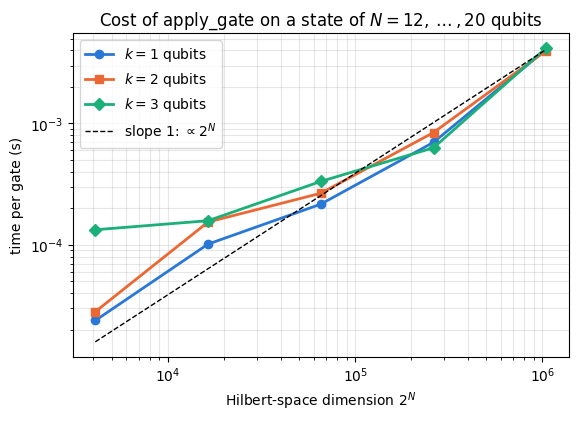

In [11]:
# ==============================================================================
# Timing apply_gate: time versus 2^N for k = 1, 2, 3
# ==============================================================================
def best_time(fn, *args, repeats=5):
    """Best wall time of `repeats` calls after one warm-up call (which includes the compilation)."""
    fn(*args).block_until_ready()
    ts = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        fn(*args).block_until_ready()
        ts.append(time.perf_counter() - t0)
    return min(ts)


Ns = [12, 14, 16, 18, 20]
targets = {1: (3,), 2: (1, 7), 3: (0, 9, 4)}
timings = {k: [] for k in targets}
for n in Ns:
    psi_big = jnp.ones((2,) * n, dtype=CDTYPE) / 2 ** (n / 2)
    for k, qs in targets.items():
        f = jax.jit(lambda p, U, qs=qs: apply_gate(p, U, qs))
        timings[k].append(best_time(f, psi_big, jnp.eye(2 ** k, dtype=CDTYPE)))
for k in targets:
    print(f"k = {k}: " + "  ".join(f"N={n}: {t * 1e3:7.3f} ms" for n, t in zip(Ns, timings[k])))

fig, ax = plt.subplots(figsize=(6.4, 4.2))
D = np.array([2.0 ** n for n in Ns])
for (k, ts), c, m in zip(timings.items(), PALETTE, "osD"):
    ax.loglog(D, ts, marker=m, color=c, lw=2, label=f"$k={k}$ qubits")
ax.loglog(D, timings[1][-1] * D / D[-1], "k--", lw=1, label=r"slope 1: $\propto 2^N$")
ax.set_xlabel(r"Hilbert-space dimension $2^N$")
ax.set_ylabel("time per gate (s)")
ax.set_title(r"Cost of apply_gate on a state of $N=12,\dots,20$ qubits")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.show()

Over the measured range the dimension grows by a factor 256, and the time grows by a smaller factor at small $N$ and roughly in proportion to $2^N$ at large $N$. For small $N$
a fixed cost per call (launching the compiled program) adds to the work and flattens the curves. At the largest sizes the step between two points can be steeper than the slope-1 line,
when the state (16.8 MB at $N=20$ in double precision) no longer fits into the processor cache and every amplitude has to come from main memory. A dense matrix would grow like $4^N$.
The three values of $k$ take times much closer to each other than the factor $2^k$ of Eq. (20) suggests: a gate on a state vector performs only $2^k$ multiplications per amplitude, and
for $k\le3$ the time is set mainly by reading and writing the $2^N$ amplitudes (the computation is memory bound). The absolute numbers depend on the machine and its load; the growth with $2^N$ is the transferable result.

## 6. States

### 6.1 Product states and the counting of parameters

A product state $\vert v_0\rangle\otimes\vert v_1\rangle\otimes\dots\otimes\vert v_{N-1}\rangle$ has, by Eq. (6), the amplitudes

$$ \psi[s_0,s_1,\dots,s_{N-1}]=v_0[s_0]\,v_1[s_1]\cdots v_{N-1}[s_{N-1}]. \tag{21} $$

It is fixed by $N$ vectors of two complex numbers, $2N$ numbers in total, while a general state needs all $2^N$ amplitudes. The difference is
visible in the matrix obtained by grouping the first $\ell$ axes into a row index and the remaining ones into a column index,
$M_{(s_0\dots s_{\ell-1}),(s_\ell\dots s_{N-1})}=\psi[s_0,\dots,s_{N-1}]$. For a product state Eq. (21) factorises $M$ into a column times a row,

$$ M=\big(v_0\otimes\dots\otimes v_{\ell-1}\big)\,\big(v_\ell\otimes\dots\otimes v_{N-1}\big)^T, \tag{22} $$

a matrix of rank 1 for every cut $\ell$. A state whose $M$ has rank larger than 1 at some cut is entangled across that cut, and Section 9 turns the
singular values of $M$ into the entanglement entropy. `product_state` builds Eq. (21) as an outer product with an `einsum` in which
no letter is summed (`a,b,c->abc` for three qubits). The characters `0`, `1` are the $\hat Z$ eigenstates, `+`, `-` those of $\hat X$, and `r`, `l` the
$+1$ and $-1$ eigenstates of $\hat Y$, $(\vert 0\rangle\pm i\vert 1\rangle)/\sqrt2$.

### 6.2 Entangled reference states

The Greenberger–Horne–Zeilinger (GHZ) state is

$$ \vert\mathrm{GHZ}_N\rangle=\tfrac{1}{\sqrt2}\big(\vert 0\dots0\rangle+\vert 1\dots1\rangle\big). \tag{23} $$

`ghz_circuit` prepares it as hardware does. A Hadamard on qubit 0 produces $(\vert 0\rangle+\vert 1\rangle)\vert 0\dots0\rangle/\sqrt2$, and each $\mathrm{CNOT}_{q-1,q}$
copies the bit of qubit $q-1$ into qubit $q$ in both branches of the superposition:

$$ \tfrac{1}{\sqrt2}\big(\vert 0\dots0\rangle+\vert 1\dots1\rangle\big)_{0..q-1}\vert 0\rangle_q \;\xrightarrow{\ \mathrm{CNOT}_{q-1,q}\ }\; \tfrac{1}{\sqrt2}\big(\vert 0\dots0\rangle+\vert 1\dots1\rangle\big)_{0..q}. \tag{24} $$

The Dicke state with $k$ excitations is the normalised equal superposition of the $\binom{N}{k}$ basis states with exactly $k$ ones,

$$ \vert D_N^k\rangle=\binom{N}{k}^{-1/2}\sum_{s:\ \sum_q s_q=k}\vert s\rangle, \qquad \Big(\sum_q\hat Z_q\Big)\vert D_N^k\rangle=(N-2k)\,\vert D_N^k\rangle, \tag{25} $$

where the eigenvalue follows because each 0 contributes $+1$ and each 1 contributes $-1$. The W state is $\vert D_N^1\rangle$. The one-dimensional
cluster state is $\vert C\rangle=\prod_q\mathrm{CZ}_{q,q+1}\,\vert +\rangle^{\otimes N}$. Its stabilisers follow from the identity
$\mathrm{CZ}\,(\hat X\otimes\mathbb{1})\,\mathrm{CZ}=\hat X\otimes\hat Z$, which we derive from Eq. (9) and $\hat X\vert 0\rangle\langle 0\vert\hat X=\vert 1\rangle\langle 1\vert$:

$$ \begin{aligned} (\hat X\otimes\mathbb{1})\,\mathrm{CZ}\,(\hat X\otimes\mathbb{1}) &= \vert 1\rangle\langle 1\vert\otimes\mathbb{1}+\vert 0\rangle\langle 0\vert\otimes\hat Z, \\ \mathrm{CZ}\,(\hat X\otimes\mathbb{1})\,\mathrm{CZ} &= (\hat X\otimes\mathbb{1})\big(\vert 1\rangle\langle 1\vert\otimes\mathbb{1}+\vert 0\rangle\langle 0\vert\otimes\hat Z\big)\big(\vert 0\rangle\langle 0\vert\otimes\mathbb{1}+\vert 1\rangle\langle 1\vert\otimes\hat Z\big) \\ &= (\hat X\otimes\mathbb{1})\big(\vert 1\rangle\langle 1\vert\otimes\hat Z+\vert 0\rangle\langle 0\vert\otimes\hat Z\big)=\hat X\otimes\hat Z . \end{aligned} $$

Conjugating $\hat X_q$ with all CZ gates of the chain thus attaches $\hat Z$ to both neighbours, and since $\hat X_q\vert +\rangle^{\otimes N}=\vert +\rangle^{\otimes N}$,

$$ \hat K_q\vert C\rangle=\vert C\rangle, \qquad \hat K_q=\hat Z_{q-1}\hat X_q\hat Z_{q+1}, \tag{26} $$

with the missing neighbour omitted at the ends of an open chain. The four Bell states are

$$ \vert\Phi^\pm\rangle=\tfrac{1}{\sqrt2}\big(\vert 00\rangle\pm\vert 11\rangle\big), \qquad \vert\Psi^\pm\rangle=\tfrac{1}{\sqrt2}\big(\vert 01\rangle\pm\vert 10\rangle\big). \tag{27} $$

### 6.3 Haar-random states

A Haar-random state is a unit vector whose direction is uniformly distributed, so that no basis is preferred. `haar_state` draws a vector $g$ of
$D=2^N$ independent standard complex Gaussian numbers and normalises it. The joint density of $g$ is proportional to
$\exp(-\sum_i\vert g_i\vert^2)=\exp(-\Vert g\Vert^2)$, which is unchanged under $g\to\hat Ug$ for every unitary $\hat U$ because $\Vert\hat Ug\Vert=\Vert g\Vert$;
hence the direction $g/\Vert g\Vert$ is uniformly distributed. Notebook 10 shows that the weight $x=\vert\psi_s\vert^2$ of one basis state then has the
density $p(x)=(D-1)(1-x)^{D-2}$ on $[0,1]$. Its moments follow from the Beta integral $\int_0^1x^n(1-x)^{D-2}\,dx=n!\,(D-2)!/(D+n-1)!$:

$$ \begin{aligned} \mathbb{E}\big[\vert\psi_s\vert^2\big] &= (D-1)\,\frac{1!\,(D-2)!}{D!}=\frac{(D-1)!}{D!}=\frac{1}{D}, \\ \mathbb{E}\big[\vert\psi_s\vert^4\big] &= (D-1)\,\frac{2!\,(D-2)!}{(D+1)!}=\frac{2\,(D-1)!}{(D+1)!}=\frac{2}{D(D+1)}. \end{aligned} \tag{28} $$

Here are the state constructors and the helper `normalize`.

In [12]:
# ==============================================================================
# Functions of quantum_engine.py derived in this notebook
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
H = jnp.array([[1, 1], [1, -1]], dtype=CDTYPE) / jnp.sqrt(2.0)      # Hadamard: Z-basis <-> X-basis
CNOT = jnp.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0]], dtype=CDTYPE)
CZ = jnp.diag(jnp.array([1, 1, 1, -1], dtype=CDTYPE))

# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
def zero_state(N):
    """|00...0>: a rank-N tensor of zeros with a single 1 at index (0,0,...,0).
    JAX arrays are immutable: `.at[idx].set(v)` returns an updated COPY (functional style)."""
    return jnp.zeros((2,) * N, dtype=CDTYPE).at[(0,) * N].set(1.0)

_KETS = {"0": [1, 0], "1": [0, 1], "+": [1, 1], "-": [1, -1], "r": [1, 1j], "l": [1, -1j]}
def product_state(spec):
    """Product state from a string, one character per qubit:  product_state('01+-') = |0>|1>|+>|->.
    ('r','l' = the +1/-1 eigenstates of Y.)

    MATH    psi[s_0,...,s_{N-1}] = v0[s_0] v1[s_1] ... v_{N-1}[s_{N-1}]
    EINSUM  an outer product = einsum with NO summed index:  "a,b,c->abc".
    A product state needs only 2N numbers; entanglement is what makes all 2^N necessary.
    """
    vecs = [jnp.array(_KETS[c], dtype=CDTYPE) / jnp.linalg.norm(jnp.array(_KETS[c], dtype=CDTYPE))
            for c in spec]
    n = len(vecs)
    sub = ",".join(_LETTERS[i] for i in range(n)) + "->" + _LETTERS[:n]
    return jnp.einsum(sub, *vecs)

def basis_state(bits):
    """Computational basis state |b_0 b_1 ... b_{N-1}> from a list of bits."""
    bits = tuple(int(b) for b in bits)
    return jnp.zeros((2,) * len(bits), dtype=CDTYPE).at[bits].set(1.0)

def ghz_state(N):
    """GHZ state (|0...0> + |1...1>)/sqrt(2): two non-zero entries of the rank-N tensor."""
    psi = jnp.zeros((2,) * N, dtype=CDTYPE)
    return psi.at[(0,) * N].set(1 / jnp.sqrt(2.0)).at[(1,) * N].set(1 / jnp.sqrt(2.0))

def ghz_circuit(N):
    """The same GHZ state, prepared the way hardware does it: H on qubit 0, then a CNOT cascade.
        |0..0> -H-> (|0>+|1>)|0..0>/sqrt2 -CNOTs-> (|0..0>+|1..1>)/sqrt2."""
    psi = apply_gate(zero_state(N), H, [0])
    for q in range(1, N):
        psi = apply_gate(psi, CNOT, [q - 1, q])
    return psi

def dicke_state(N, k):
    """Symmetric Dicke state |D_N^k>: equal superposition of all basis states with exactly k ones.
    Implementation: mask of the flat indices with popcount == k, normalised by sqrt(binom(N,k))."""
    idx = np.arange(2 ** N)
    pop = np.array([bin(i).count("1") for i in idx])
    v = (pop == k).astype(np.complex128)
    return jnp.asarray(v / np.linalg.norm(v), dtype=CDTYPE).reshape((2,) * N)

def w_state(N):
    """W state = Dicke state with one excitation: (|10..0> + |01..0> + ... + |0..01>)/sqrt(N)."""
    return dicke_state(N, 1)

def cluster_state(N, periodic=False):
    """1D cluster (graph) state: |+>^N followed by CZ on every bond.  Stabilisers K_i = Z_{i-1} X_i Z_{i+1}."""
    psi = product_state("+" * N)
    for q in range(N - 1):
        psi = apply_gate(psi, CZ, [q, q + 1])
    if periodic and N > 2:
        psi = apply_gate(psi, CZ, [N - 1, 0])
    return psi

def bell_state(kind="phi+"):
    """The four Bell states as (2,2) tensors: phi+- = (|00> +- |11>)/sqrt2, psi+- = (|01> +- |10>)/sqrt2."""
    a = 1 / np.sqrt(2)
    v = {"phi+": [a, 0, 0, a], "phi-": [a, 0, 0, -a], "psi+": [0, a, a, 0], "psi-": [0, a, -a, 0]}[kind]
    return jnp.array(v, dtype=CDTYPE).reshape(2, 2)

def haar_state(key, N):
    """Haar-random pure state: a complex Gaussian vector, normalised.
    (The Gaussian measure is unitarily invariant, so the direction is uniformly distributed.)
    `key` is an explicit JAX PRNG key -- same key, same state: reproducible science."""
    k1, k2 = jax.random.split(key)
    v = jax.random.normal(k1, (2,) * N) + 1j * jax.random.normal(k2, (2,) * N)
    return (v / jnp.linalg.norm(v)).astype(CDTYPE)

def normalize(psi):
    """psi / ||psi||  (Frobenius norm of the tensor = 2-norm of the state vector)."""
    return psi / jnp.linalg.norm(psi)


The checks build every state independently with Kronecker products of NumPy vectors or with dense operators. For the Dicke state we test the
eigenvalue of Eq. (25), the number of non-zero amplitudes and the symmetry under an arbitrary permutation of the qubits. For the cluster state we
test all stabilisers of Eq. (26). For the Haar states we test the moments of Eq. (28) on 20000 states of $N=3$ qubits, generated in one call with
`jax.vmap` over PRNG keys, within five standard errors. The second moment $1/D$ holds for any distribution that treats the basis states alike, so it cannot detect a
wrong ensemble; the fourth moment can. Its mutant is the value $3/(D(D+2))$ of a normalised *real* Gaussian vector, the result of forgetting the imaginary part: then $x=\vert\psi_s\vert^2$ follows the Beta
distribution with parameters $(\tfrac12,\tfrac{D-1}{2})$, whose second moment is $\tfrac12\cdot\tfrac32\big/\big(\tfrac D2(\tfrac D2+1)\big)=3/(D(D+2))$. The last lines count the parameters of Eq. (22): the rank of the matrix $M$ at the middle cut.

In [13]:
# ==============================================================================
# CHECKS: state constructors
# ==============================================================================
SECTION = "6"
with einsum_spy() as seen:
    product_state("01+")
print("product_state('01+') uses the einsum", seen)

kets = {"0": [1, 0], "1": [0, 1], "+": [1, 1], "-": [1, -1], "r": [1, 1j], "l": [1, -1j]}
spec = "0+r1-l"
ref = kron_all([np.array(kets[c], complex)[:, None] / np.linalg.norm(kets[c]) for c in spec]).ravel()
check("product_state('0+r1-l') vs Kronecker product", maxdiff(product_state(spec), ref), 10 * TOL,
      mutant=maxdiff(product_state(spec[::-1]), ref))
bits = [1, 0, 1, 1, 0]
ref = np.zeros(32, complex); ref[int("10110", 2)] = 1.0
check("basis_state([1,0,1,1,0]) = e_22", maxdiff(basis_state(bits), ref), 10 * TOL,
      mutant=maxdiff(basis_state(bits[::-1]), ref))
check("zero_state(4) = e_0", maxdiff(zero_state(4), np.eye(16)[0]), 10 * TOL)
ghz_ref = (np.eye(64)[0] + np.eye(64)[63]) / np.sqrt(2)
check("ghz_state(6) vs (e_0 + e_63)/sqrt2", maxdiff(ghz_state(6), ghz_ref), 10 * TOL)
check("ghz_circuit(6) = ghz_state(6)", maxdiff(ghz_circuit(6), ghz_ref), 10 * TOL)

N, k = 6, 2
d = np.asarray(dicke_state(N, k)).reshape(-1)
Ztot = sum(embed_dense(NP_Z, [q], N) for q in range(N))
check("Dicke(6,2): eigenvalue N-2k of sum_q Z_q", np.linalg.norm(Ztot @ d - (N - 2 * k) * d), 100 * TOL,
      mutant=np.linalg.norm(Ztot @ np.asarray(dicke_state(N, N - k)).reshape(-1) - (N - 2 * k) * d))
check("Dicke(6,2): binom(6,2)=15 equal amplitudes", abs(np.sum(np.abs(d) > 1e-12) - 15) + maxdiff(np.abs(d[np.abs(d) > 1e-12]), 1 / np.sqrt(15)), 10 * TOL)
perm = [3, 0, 5, 1, 4, 2]
check("Dicke(6,2): symmetric under a qubit permutation", maxdiff(jnp.transpose(dicke_state(N, k), perm), dicke_state(N, k)), 10 * TOL)
check("w_state(5) = Dicke(5,1)", maxdiff(w_state(5), dicke_state(5, 1)), 10 * TOL)

for periodic in (False, True):
    c = np.asarray(cluster_state(N, periodic=periodic)).reshape(-1)
    plus = np.asarray(product_state("+" * N)).reshape(-1)
    err, err_mut = 0.0, 0.0
    for q in range(N):
        factors = [NP_I] * N
        factors[q] = NP_X
        for p in (q - 1, q + 1):
            if 0 <= p < N:
                factors[p] = NP_Z
            elif periodic:
                factors[p % N] = NP_Z
        Kq = kron_all(factors)
        err = max(err, np.linalg.norm(Kq @ c - c))
        err_mut = max(err_mut, np.linalg.norm(Kq @ plus - plus))
    check(f"cluster_state(6, periodic={periodic}): K_q|C> = |C>", err, 100 * TOL, mutant=err_mut)

bell_ref = {"phi+": [1, 0, 0, 1], "phi-": [1, 0, 0, -1], "psi+": [0, 1, 1, 0], "psi-": [0, 1, -1, 0]}
err = max(maxdiff(bell_state(kd), np.array(r) / np.sqrt(2)) for kd, r in bell_ref.items())
check("bell_state: the four Bell states", err, 10 * TOL,
      mutant=maxdiff(bell_state("psi-"), np.array(bell_ref["psi+"]) / np.sqrt(2)))

# Haar moments, Eq. (28), with 20000 states of N = 3 qubits generated by one vmap
N, n_states = 3, 20000
Dh = 2 ** N
haar_batch = jax.vmap(lambda kk: haar_state(kk, N))(jax.random.split(jax.random.PRNGKey(7), n_states))
w2 = np.abs(np.asarray(haar_batch[:, 0, 0, 0])) ** 2              # |psi_{000}|^2
w4 = np.abs(np.asarray(haar_batch[:, 1, 0, 1])) ** 4              # |psi_{101}|^4
# mutant of the fourth moment: a REAL Gaussian vector (imaginary part forgotten) has E|psi_s|^4 = 3/(D(D+2)) instead
for name, sample, exact, wrong in [("E|psi_000|^2 = 1/D", w2, 1 / Dh, None),
                                   ("E|psi_101|^4 = 2/(D(D+1))", w4, 2 / (Dh * (Dh + 1)), 3 / (Dh * (Dh + 2)))]:
    se = sample.std() / np.sqrt(n_states)
    print(f"      {name}: sample {sample.mean():.5f} +- {se:.5f}, exact {exact:.5f}")
    check(f"Haar moment {name} (5 standard errors)", abs(sample.mean() - exact), 5 * se,
          mutant=None if wrong is None else abs(sample.mean() - wrong), mutant_factor=1)
check("haar_state: normalised, reproducible for the same key",
      abs(jnp.linalg.norm(haar_batch[0]) - 1) + maxdiff(haar_state(jax.random.split(jax.random.PRNGKey(7), n_states)[0], N), haar_batch[0]), 10 * TOL)
check("normalize(2 psi) = psi", maxdiff(normalize(2.0 * haar_batch[1]), haar_batch[1]), 10 * TOL)

# parameter counting, Eq. (22): rank of the matrix M at the middle cut of N = 8 qubits
for name, st in [("product |0+r1-l+0>", product_state("0+r1-l+0")), ("GHZ_8", ghz_state(8)),
                 ("Haar, N=8", haar_state(jax.random.PRNGKey(3), 8))]:
    M = np.asarray(st).reshape(2 ** 4, 2 ** 4)
    print(f"      rank of M at the middle cut, {name:20s}: {np.linalg.matrix_rank(M, tol=1e-3 * np.sqrt(TOL))}")

product_state('01+') uses the einsum ['a,b,c->abc']
PASS  product_state('0+r1-l') vs Kronecker product       error  2.8e-17  tol   1e-09   mutant  5.0e-01
PASS  basis_state([1,0,1,1,0]) = e_22                    error  0.0e+00  tol   1e-09   mutant  1.0e+00
PASS  zero_state(4) = e_0                                error  0.0e+00  tol   1e-09


PASS  ghz_state(6) vs (e_0 + e_63)/sqrt2                 error  0.0e+00  tol   1e-09
PASS  ghz_circuit(6) = ghz_state(6)                      error  0.0e+00  tol   1e-09
PASS  Dicke(6,2): eigenvalue N-2k of sum_q Z_q           error  0.0e+00  tol   1e-08   mutant  2.8e+00
PASS  Dicke(6,2): binom(6,2)=15 equal amplitudes         error  0.0e+00  tol   1e-09
PASS  Dicke(6,2): symmetric under a qubit permutation    error  0.0e+00  tol   1e-09
PASS  w_state(5) = Dicke(5,1)                            error  0.0e+00  tol   1e-09
PASS  cluster_state(6, periodic=False): K_q|C> = |C>     error  0.0e+00  tol   1e-08   mutant  1.4e+00


PASS  cluster_state(6, periodic=True): K_q|C> = |C>      error  0.0e+00  tol   1e-08   mutant  1.4e+00
PASS  bell_state: the four Bell states                   error  0.0e+00  tol   1e-09   mutant  1.4e+00


      E|psi_000|^2 = 1/D: sample 0.12522 +- 0.00078, exact 0.12500
PASS  Haar moment E|psi_000|^2 = 1/D (5 standard errors) error  2.2e-04  tol   4e-03
      E|psi_101|^4 = 2/(D(D+1)): sample 0.02727 +- 0.00033, exact 0.02778
PASS  Haar moment E|psi_101|^4 = 2/(D(D+1)) (5 standard errors) error  5.1e-04  tol   2e-03   mutant  1.0e-02


PASS  haar_state: normalised, reproducible for the same key error  0.0e+00  tol   1e-09
PASS  normalize(2 psi) = psi                             error  0.0e+00  tol   1e-09


      rank of M at the middle cut, product |0+r1-l+0>  : 1
      rank of M at the middle cut, GHZ_8               : 2
      rank of M at the middle cut, Haar, N=8           : 16


All constructors pass, and every mutant (reversed product string, reversed bit list, the Dicke state with $N-k$ excitations, the stabilisers applied to
$\vert +\rangle^{\otimes N}$ before the CZ gates, $\vert\Psi^+\rangle$ in place of $\vert\Psi^-\rangle$) is rejected. The Haar sample reproduces both moments of
Eq. (28) within the statistical error, and its fourth moment lies many standard errors away from the real-Gaussian value $3/80=0.0375$. The rank of the matrix $M$ at the middle cut is 1 for the product state, as Eq. (22) requires, 2 for GHZ and
the maximal $2^4=16$ for the Haar state, which uses all $2^N$ parameters.

## 7. Density tensors

### 7.1 Pure states as density tensors

A density operator $\hat\rho$ of $N$ qubits has the matrix elements $\rho[s_0,\dots,s_{N-1};s'_0,\dots,s'_{N-1}]$. The engine stores them in a tensor
with $2N$ axes of length 2, the $N$ ket axes first and the $N$ bra axes after them. For a pure state $\hat\rho=\vert\psi\rangle\langle\psi\vert$,

$$ \rho[s;s']=\psi[s]\,\psi^*[s'], \tag{29} $$

an outer product (`to_dm` uses `tensordot(psi, psi.conj(), axes=0)`). Because the ket axes come first, the C-ordered reshape of this tensor into a
$2^N\times2^N$ array (`dm_matrix`) puts the ket bits into the row index and the bra bits into the column index, each by Eq. (5). The density matrix is the
ordinary $\rho_{ij}$, and no data are moved.

### 7.2 Unitaries on density tensors

Under a unitary the density matrix transforms as $\hat\rho\to\hat U\hat\rho\hat U^\dagger$. In components, with $(\hat U^\dagger)_{b'a'}=U^*_{a'b'}$,

$$ \begin{aligned} (\hat U\hat\rho\hat U^\dagger)[a;a'] &= \sum_{b,b'}U[a,b]\;\rho[b;b']\;(\hat U^\dagger)[b';a'] \\ &= \sum_{b,b'}U[a,b]\;U^*[a',b']\;\rho[b;b']. \end{aligned} \tag{30} $$

The second line has the form of Eq. (17) twice: $U$ contracted with a ket axis and the complex conjugate $U^*$ (without transpose) contracted with the
corresponding bra axis. `apply_gate_dm` therefore calls `apply_gate` twice, on the axes `qubits` and on the axes `N + q`. In the language of vectorisation,
the density tensor is a state of $2N$ qubits on which $\hat U\otimes\hat U^*$ acts. The cost is $O(2^k\,4^N)$.

### 7.3 Kraus channels on density tensors

A quantum channel in Kraus form (notebook 07; Nielsen & Chuang, Ch. 8) maps

$$ \hat\rho\;\to\;\sum_m\hat K_m\,\hat\rho\,\hat K_m^\dagger . \tag{31} $$

By Eq. (30) applied to each term, $\hat K_m$ acts on the ket axes and $\hat K_m^*$ on the bra axes, and the sum over $m$ is one more summed index.
`apply_kraus_dm` puts all of it into a single `einsum` whose first two operands are the stack of Kraus matrices and its complex conjugate, both carrying
the Kraus label as their first index.

In [14]:
# ==============================================================================
# Functions of quantum_engine.py derived in this notebook
# ==============================================================================
# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)

def apply_gate_dm(rho, U, qubits):
    """Unitary on a density tensor:  rho -> U rho U^dagger.

    MATH   rho'[a..;a'..] = sum_{b,b'} U[a,b] rho[b..;b'..] U^*[a',b']
           i.e. U acts on the KET axis q and the complex conjugate U^* on the BRA axis N+q.
           (A density matrix is "a state vector of 2N qubits": vectorisation |rho>> and
           U (x) U^* acting on it.)
    IMPLEMENTATION  two calls of `apply_gate` -- the same einsum machinery, no new code.
    COST   O(2^k 4^N).
    """
    N = rho.ndim // 2
    rho = apply_gate(rho, U, qubits)                                         # U    on ket axes
    return apply_gate(rho, jnp.conj(jnp.asarray(U)), [N + q for q in qubits])  # U^*  on bra axes

def apply_kraus_dm(rho, kraus, qubits):
    """Quantum channel in Kraus form:  rho -> sum_m K_m rho K_m^dagger,   sum_m K_m^dag K_m = 1.

    EINSUM TRANSLATION  (N=2, channel on qubit 0; g = Kraus index, summed!)
        "gea,gfc,abcd->ebfd"   with operands  K, K^*, rho      [a=ket0, b=ket1, c=bra0, d=bra1; e, f = new ket0, bra0]
    All Kraus branches are summed INSIDE one einsum -- no Python loop over m.
    `kraus` has shape (M, 2^k, 2^k).
    """
    qubits = tuple(int(q) for q in qubits)
    k, N = len(qubits), rho.ndim // 2
    K = jnp.asarray(kraus, dtype=rho.dtype).reshape((-1,) + (2,) * (2 * k))
    n = rho.ndim
    inp = list(_LETTERS[:n])
    new_k, new_b, m = _LETTERS[n:n + k], _LETTERS[n + k:n + 2 * k], _LETTERS[n + 2 * k]
    out = inp.copy()
    for a, b, q in zip(new_k, new_b, qubits):
        out[q], out[N + q] = a, b
    ket_old = "".join(inp[q] for q in qubits)
    bra_old = "".join(inp[N + q] for q in qubits)
    sub = f"{m}{new_k}{ket_old},{m}{new_b}{bra_old},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, K, jnp.conj(K), rho)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
def to_dm(psi):
    """Pure state -> density TENSOR  rho[s..; s'..] = psi[s..] psi^*[s'..]   (rank 2N).
    An outer product: einsum "ab,AB->abAB" -- here via the equivalent tensordot(axes=0)."""
    return jnp.tensordot(psi, jnp.conj(psi), axes=0)

def dm_matrix(rho):
    """View a rank-2N density tensor as an ordinary 2^N x 2^N matrix (a reshape, no copy of meaning)."""
    d = int(round(np.sqrt(rho.size)))
    return rho.reshape(d, d)


# ----------------------------------------------------------------------------
# 9. Time evolution: TEBD / Trotter-Suzuki, Chebyshev, Krylov, exact
# ----------------------------------------------------------------------------
def apply_gates_dm(rho, gates):
    """Same circuit on a density tensor (U on kets, U^* on bras)."""
    for qubits, U in gates:
        rho = apply_gate_dm(rho, U, qubits)
    return rho


In [15]:
with einsum_spy() as seen:
    apply_kraus_dm(to_dm(zero_state(2)), jnp.stack([I2, X]) / jnp.sqrt(2.0), [0])
print("apply_kraus_dm, N = 2, channel on qubit 0:", seen[0])
with einsum_spy() as seen:
    apply_kraus_dm(to_dm(zero_state(3)), jnp.stack([jnp.eye(4, dtype=CDTYPE)]), [2, 0])
print("apply_kraus_dm, N = 3, channel on qubits (2, 0):", seen[0])

apply_kraus_dm, N = 2, channel on qubit 0: gea,gfc,abcd->ebfd


apply_kraus_dm, N = 3, channel on qubits (2, 0): kghca,kijfd,abcdef->hbgjei


In the first string, `gea,gfc,abcd->ebfd`, the density tensor carries `ab` (kets of qubits 0, 1) and `cd` (their bras). The Kraus stack `gea` is
$K[m,\text{new},\text{old}]$ with $m=$`g`, the new ket label `e` and the old ket label `a`; the conjugate stack `gfc` carries the same `g`, the new bra
label `f` and the old bra label `c`. The output `ebfd` replaces `a` by `e` and `c` by `f`. The letters `a`, `c` and the Kraus index `g` are summed, which
is Eq. (31) with Eq. (30) in every term.

The checks use a random full-rank mixed state with complex coherences, a random two-qubit unitary on the reversed pair $(3,0)$ and a random
two-qubit channel. The channel comes from a random isometry $V$ of shape $8\times4$, a matrix with orthonormal columns (the first four columns of a random $8\times8$ unitary), cut into
two $4\times4$ blocks $\hat K_0,\hat K_1$, which satisfy $\sum_m\hat K_m^\dagger\hat K_m=V^\dagger V=\mathbb{1}$. The mutants apply $U$ (instead of $U^*$) to the bra axes and
pass the conjugated Kraus operators, the two ways to lose the complex conjugate.

In [16]:
# ==============================================================================
# CHECKS: density tensors
# ==============================================================================
SECTION = "7"
N = 4
v = rand_state(5, N)
check("dm_matrix(to_dm(psi)) = |psi><psi|", maxdiff(dm_matrix(to_dm(as_tensor(v, N))), np.outer(v, v.conj())), 10 * TOL,
      mutant=maxdiff(dm_matrix(to_dm(as_tensor(v, N))), np.outer(v, v)))
R = rand_dm(6, N)
rho = jnp.asarray(R.reshape((2,) * (2 * N)), CDTYPE)
U = rand_unitary(7, 4)
E = embed_dense(U, [3, 0], N)
Uj = jnp.asarray(U, CDTYPE)
mut = apply_gate(apply_gate(rho, Uj, [3, 0]), Uj, [N + 3, N + 0])          # U instead of U^* on the bra axes
check("apply_gate_dm on (3,0) = E rho E^dag", maxdiff(dm_matrix(apply_gate_dm(rho, Uj, [3, 0])), E @ R @ E.conj().T), 100 * TOL,
      mutant=maxdiff(dm_matrix(mut), E @ R @ E.conj().T))
gates = [((1,), jnp.asarray(rand_unitary(8, 2), CDTYPE)), ((2, 3), Uj), ((0, 2), CNOT)]
Etot = np.eye(2 ** N)
for qs, G in gates:
    Etot = embed_dense(G, list(qs), N) @ Etot
check("apply_gates_dm: three-gate circuit", maxdiff(dm_matrix(apply_gates_dm(rho, gates)), Etot @ R @ Etot.conj().T), 100 * TOL)
Vis = rand_unitary(9, 8)[:, :4]                                            # isometry: Vis^dag Vis = 1_4
Ks = np.stack([Vis[:4], Vis[4:]])
check("random Kraus set: sum K^dag K = 1", maxdiff(sum(Km.conj().T @ Km for Km in Ks), np.eye(4)), 100 * TOL)
ref = sum(embed_dense(Km, [3, 1], N) @ R @ embed_dense(Km, [3, 1], N).conj().T for Km in Ks)
check("apply_kraus_dm on (3,1) = sum_m E_m rho E_m^dag", maxdiff(dm_matrix(apply_kraus_dm(rho, jnp.asarray(Ks, CDTYPE), [3, 1])), ref), 100 * TOL,
      mutant=maxdiff(dm_matrix(apply_kraus_dm(rho, jnp.asarray(Ks.conj(), CDTYPE), [3, 1])), ref))

PASS  dm_matrix(to_dm(psi)) = |psi><psi|                 error  1.4e-17  tol   1e-09   mutant  2.3e-01


PASS  apply_gate_dm on (3,0) = E rho E^dag               error  2.4e-17  tol   1e-08   mutant  1.1e-01


PASS  apply_gates_dm: three-gate circuit                 error  2.1e-17  tol   1e-08
PASS  random Kraus set: sum K^dag K = 1                  error  5.6e-16  tol   1e-08


PASS  apply_kraus_dm on (3,1) = sum_m E_m rho E_m^dag    error  1.4e-17  tol   1e-08   mutant  7.2e-02


The pure-state density tensor, the unitary on a reversed qubit pair, a three-gate circuit and the random channel all agree with the dense formulas. The conjugation mutants
fail by $0.07$ to $0.23$, far above the tolerance, which shows that the checks see a missing conjugate on the bra side.

## 8. Reduced density matrices and observables

### 8.1 The partial trace as an einsum

Group the axes of a pure state into those of a subsystem $A$ (multi-index $a$) and those of the rest $B$ (multi-index $b$). The reduced density
matrix $\hat\rho_A=\mathrm{Tr}_B\vert\psi\rangle\langle\psi\vert$ follows from Eq. (29) by setting the bra indices of $B$ equal to the ket indices and summing:

$$ \rho_A[a;a']=\sum_{b}\psi[a,b]\;\psi^*[a',b]. \tag{32} $$

`rdm` writes Eq. (32) as an `einsum` with two operands, $\psi$ and $\psi^*$. Both carry the same letters on the axes of $B$ (summed, hence traced out) and
different letters on the axes of $A$ (kept, as rows and columns). The full $\vert\psi\rangle\langle\psi\vert$ with $4^N$ entries is never formed; the cost is
$O(2^N\,2^{\vert A\vert})$. The rows and columns of the result follow the order in which `keep` lists the qubits. For a density tensor the trace over
$B$ is a letter that appears twice in the single operand:

$$ \rho_A[a;a']=\sum_{b}\rho[a,b;\,a',b]. \tag{33} $$

### 8.2 Local observables, Pauli strings and Bloch vectors

For an operator $\hat O$ acting on $A$, Eq. (17) and Eq. (32) give

$$ \begin{aligned} \langle\psi\vert\hat O_A\vert\psi\rangle &= \sum_{a,a',b}\psi^*[a',b]\;O[a',a]\;\psi[a,b] \\ &= \sum_{a,a'}O[a',a]\;\rho_A[a;a']=\mathrm{Tr}\big(\hat O\,\hat\rho_A\big). \end{aligned} \tag{34} $$

A local expectation value needs only the small reduced matrix, and one reduced matrix serves all observables on $A$. A Pauli string
$\hat P=\hat P_0\otimes\hat P_1\otimes\dots$ is applied factor by factor ($N$ single-qubit contractions), and one inner product finishes the job:

$$ \langle\hat P\rangle=\langle\psi\vert\big(\hat P\vert\psi\rangle\big), \qquad \mathrm{Tr}\big(\hat P\hat\rho\big)=\sum_{s}\big(\hat P\hat\rho\big)[s;s]. \tag{35} $$

`jnp.vdot` conjugates its first argument, which is the bra. For a density tensor, $\hat P$ acts on the ket axes only, and the trace follows. Finally a
single-qubit density matrix can be written as $\hat\rho_q=\tfrac12(\mathbb{1}+\vec r_q\cdot\vec{\hat\sigma})$; since $\mathrm{Tr}(\hat\sigma^a\hat\sigma^b)=2\delta_{ab}$, the components of the Bloch vector are

$$ r_q^a=\mathrm{Tr}\big(\hat\rho_q\,\hat\sigma^a\big)=\langle\hat\sigma^a_q\rangle, \qquad a=x,y,z, \tag{36} $$

which `all_local_expectations` returns for all qubits as an array of shape $(N,3)$.

In [17]:
# ==============================================================================
# Functions of quantum_engine.py derived in this notebook
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
PAULI = {"I": I2, "X": X, "Y": Y, "Z": Z}

# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
def dm_matrix(rho):
    """View a rank-2N density tensor as an ordinary 2^N x 2^N matrix (a reshape, no copy of meaning)."""
    d = int(round(np.sqrt(rho.size)))
    return rho.reshape(d, d)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm(psi, keep):
    """Reduced density matrix of the qubits `keep` from a PURE state:  rho_A = Tr_B |psi><psi|.

    MATH
        rho_A[a, a'] = sum_{b}  psi[a, b] psi^*[a', b]          (a: indices of A, b: of the rest B)
    EINSUM TRANSLATION   N=3, keep=(0,):   "abc,Abc->aA"   with operands psi, psi^*
        * letters of B (b,c) appear in BOTH operands and not in the output  -> summed = traced out
        * the kept axis gets a different letter in the second operand       -> stays open (a and A)
    The full |psi><psi| (4^N numbers) is never formed; cost O(2^N 2^|A|).
    Returns a (2^|A|, 2^|A|) matrix with row/column order following `keep`.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    a = list(_LETTERS[:n])
    b = a.copy()
    for new, q in zip(_LETTERS[n:n + k], keep):
        b[q] = new
    sub = f"{''.join(a)},{''.join(b)}->{''.join(a[q] for q in keep)}{''.join(b[q] for q in keep)}"
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)

def rdm_dm(rho, keep):
    """Partial trace of a density TENSOR (rank 2N), keeping the qubits `keep`.

    MATH      rho_A[a,a'] = sum_b rho[a,b ; a',b]
    EINSUM    N=2, keep=(0,):  "abAb->aA"   -- the letter b is REPEATED inside one operand and absent
              from the output: that is a trace over that pair of axes.
    """
    keep = tuple(int(q) for q in keep)
    N = rho.ndim // 2
    ket = list(_LETTERS[:N])
    bra = [(_LETTERS[N + q] if q in keep else ket[q]) for q in range(N)]
    sub = f"{''.join(ket)}{''.join(bra)}->{''.join(ket[q] for q in keep)}{''.join(bra[q] for q in keep)}"
    return jnp.einsum(sub, rho).reshape(2 ** len(keep), 2 ** len(keep))

def expect_local(psi, O, qubits):
    """<psi| O_qubits |psi> for a k-local operator O (2^k x 2^k matrix).

    MATH   <O> = Tr(rho_A O)  with A = `qubits`: a local observable only sees the local state.
    Cost O(2^N) for the RDM + O(4^k) for the small trace.  One RDM serves ALL observables on A
    (e.g. <X>,<Y>,<Z> from a single 2x2 matrix).
    """
    return jnp.real(jnp.trace(rdm(psi, qubits) @ jnp.asarray(O, dtype=CDTYPE)))

def expect_local_dm(rho, O, qubits):
    """Tr(rho O_qubits) for a density tensor, via its reduced density matrix."""
    return jnp.real(jnp.trace(rdm_dm(rho, qubits) @ jnp.asarray(O, dtype=CDTYPE)))

def apply_pauli_string(psi, ops):
    """Apply a Pauli string P = P_0 x P_1 x ... to psi.
    `ops` is a dict {qubit: 'X'|'Y'|'Z'} or a string like 'XIZY' (one letter per qubit; 'I' skipped).
    N single-qubit einsums -- cost O(N 2^N) -- instead of one 2^N x 2^N matrix."""
    if isinstance(ops, str):
        ops = {q: p for q, p in enumerate(ops) if p != "I"}
    for q, p in ops.items():
        psi = apply_gate(psi, PAULI[p], [q])
    return psi

def expect_pauli_string(psi, ops):
    """<psi|P|psi> = <psi | (P psi)> : apply the string, then ONE inner product (jnp.vdot conjugates its
    first argument).  Works for strings of any weight, e.g. the N-body correlator <X X ... X>."""
    return jnp.real(jnp.vdot(psi, apply_pauli_string(psi, ops)))

def expect_pauli_string_dm(rho, ops):
    """Tr(P rho): apply P to the KET axes only, then take the full trace."""
    return jnp.real(jnp.trace(dm_matrix(apply_pauli_string(rho, ops))))

def all_local_expectations(psi):
    """Bloch vectors of all qubits: array (N,3) with rows (<X_q>, <Y_q>, <Z_q>), from the 1-qubit RDMs."""
    out = []
    for q in range(psi.ndim):
        r = rdm(psi, [q])
        out.append(jnp.stack([jnp.real(jnp.trace(r @ P)) for P in (X, Y, Z)]))
    return jnp.stack(out)


In [18]:
for n, keep in [(3, (0,)), (3, (2, 0))]:
    with einsum_spy() as seen:
        rdm(zero_state(n), keep)
    print(f"rdm,    N = {n}, keep = {str(keep):7s} ->  {seen[0]}   (operands psi, psi^*)")
with einsum_spy() as seen:
    rdm_dm(to_dm(zero_state(2)), (0,))
print(f"rdm_dm, N = 2, keep = (0,)    ->  {seen[0]}")

rdm,    N = 3, keep = (0,)    ->  abc,dbc->ad   (operands psi, psi^*)
rdm,    N = 3, keep = (2, 0)  ->  abc,ebd->cade   (operands psi, psi^*)
rdm_dm, N = 2, keep = (0,)    ->  abcb->ac


The string `abc,ebd->cade` reads as follows. The first operand $\psi$ carries `abc`. The conjugate carries `ebd`: the kept qubits 2 and 0 received the
fresh letters `d` and `e`, while qubit 1 keeps its letter `b`. Since `b` appears in both operands and not in the output, it is summed (traced out). The output
`cade` lists the ket letters of the kept qubits in the order of `keep` (`c` for qubit 2, then `a` for qubit 0), followed by their bra letters, so the
row index of the $4\times4$ result has qubit 2 as its most significant bit. In `abcb->ac` the repeated `b` inside one operand is the trace of Eq. (33).

The checks compare `rdm` and `rdm_dm` with the bit-string partial trace of Eq. (4) for a reversed and scattered `keep`, with the mutant that lists the
same qubits in increasing order. The observables are compared with $v^\dagger\hat O v$ for dense operators; the mutants are the reversed qubit pair, the
reversed Pauli string, $\hat Y^T$ in place of $\hat Y$ (the trace with a transposed operator), and the Bloch vectors of the complex-conjugate state,
whose $y$ components have the opposite sign.

In [19]:
# ==============================================================================
# CHECKS: reduced density matrices and observables
# ==============================================================================
SECTION = "8"
N = 5
v = rand_state(12, N)
psi = as_tensor(v, N)
Rv = np.outer(v, v.conj())
check("rdm(psi, keep=(3,0)) vs bit-string partial trace", maxdiff(rdm(psi, (3, 0)), ptrace_bits(Rv, [3, 0], N)), 100 * TOL,
      mutant=maxdiff(rdm(psi, (0, 3)), ptrace_bits(Rv, [3, 0], N)))
R4 = rand_dm(13, 4)
rho4 = jnp.asarray(R4.reshape((2,) * 8), CDTYPE)
check("rdm_dm(rho, keep=(2,1,3)) vs bit-string partial trace", maxdiff(rdm_dm(rho4, (2, 1, 3)), ptrace_bits(R4, [2, 1, 3], 4)), 100 * TOL,
      mutant=maxdiff(rdm_dm(rho4, (1, 2, 3)), ptrace_bits(R4, [2, 1, 3], 4)))
O = rand_herm(14, 4)
EO = embed_dense(O, [4, 1], N)
check("expect_local(O on (4,1)) = <v|O|v>", abs(expect_local(psi, jnp.asarray(O, CDTYPE), (4, 1)) - (v.conj() @ EO @ v).real), 100 * TOL,
      mutant=abs(expect_local(psi, jnp.asarray(O, CDTYPE), (1, 4)) - (v.conj() @ EO @ v).real))
check("expect_local_dm(O on (2,0)) = Tr(rho O)", abs(expect_local_dm(rho4, jnp.asarray(O, CDTYPE), (2, 0))
      - np.trace(R4 @ embed_dense(O, [2, 0], 4)).real), 100 * TOL)
pstr = "XIYZY"
Pd = kron_all([{"I": NP_I, "X": NP_X, "Y": NP_Y, "Z": NP_Z}[c] for c in pstr])
check("expect_pauli_string('XIYZY')", abs(expect_pauli_string(psi, pstr) - (v.conj() @ Pd @ v).real), 100 * TOL,
      mutant=abs(expect_pauli_string(psi, pstr[::-1]) - (v.conj() @ Pd @ v).real))
check("apply_pauli_string with a dict {4:'Y', 0:'X'}", maxdiff(apply_pauli_string(psi, {4: "Y", 0: "X"}),
      kron_all([NP_X, NP_I, NP_I, NP_I, NP_Y]) @ v), 100 * TOL)
P4 = kron_all([NP_Y, NP_X, NP_Z, NP_I])
P4_mut = kron_all([NP_Y.T, NP_X, NP_Z, NP_I])
check("expect_pauli_string_dm('YXZI') = Tr(P rho)", abs(expect_pauli_string_dm(rho4, "YXZI") - np.trace(P4 @ R4).real), 100 * TOL,
      mutant=abs(expect_pauli_string_dm(rho4, "YXZI") - np.trace(P4_mut @ R4).real))
bloch_ref = np.array([[(v.conj() @ embed_dense(P, [q], N) @ v).real for P in (NP_X, NP_Y, NP_Z)] for q in range(N)])
check("all_local_expectations = Bloch vectors", maxdiff(all_local_expectations(psi), bloch_ref), 100 * TOL,
      mutant=maxdiff(all_local_expectations(jnp.conj(psi)), bloch_ref))
print("Bloch vectors (rows: qubits 0..4; columns <X>, <Y>, <Z>):\n", np.round(np.asarray(all_local_expectations(psi)), 4))

PASS  rdm(psi, keep=(3,0)) vs bit-string partial trace   error  5.6e-17  tol   1e-08   mutant  1.4e-01


PASS  rdm_dm(rho, keep=(2,1,3)) vs bit-string partial trace error  0.0e+00  tol   1e-08   mutant  5.2e-02
PASS  expect_local(O on (4,1)) = <v|O|v>                 error  2.2e-16  tol   1e-08   mutant  6.8e-01


PASS  expect_local_dm(O on (2,0)) = Tr(rho O)            error  2.2e-16  tol   1e-08


PASS  expect_pauli_string('XIYZY')                       error  2.9e-17  tol   1e-08   mutant  7.6e-02
PASS  apply_pauli_string with a dict {4:'Y', 0:'X'}      error  0.0e+00  tol   1e-08
PASS  expect_pauli_string_dm('YXZI') = Tr(P rho)         error  0.0e+00  tol   1e-08   mutant  1.4e-02


PASS  all_local_expectations = Bloch vectors             error  1.1e-16  tol   1e-08   mutant  3.5e-01
Bloch vectors (rows: qubits 0..4; columns <X>, <Y>, <Z>):
 [[ 0.1482  0.0426  0.0846]
 [-0.2789  0.1397 -0.1344]
 [-0.081   0.1747 -0.2554]
 [ 0.3506 -0.0081 -0.1128]
 [ 0.1024 -0.0154 -0.305 ]]


All reduced matrices and expectation values agree with the dense references. Listing the kept qubits in a different order permutes rows and
columns of $\hat\rho_A$, and the mutant shows that this is a different matrix. The Bloch vectors of the random state are short (lengths well below 1)
because a random state is strongly entangled and every qubit alone is close to maximally mixed.

## 9. Entropies, fidelities and negativity

### 9.1 Purity and von Neumann entropy

For a Hermitian $\hat\rho$ the purity is

$$ \mathrm{Tr}\,\hat\rho^2=\sum_{i,j}\rho_{ij}\,\rho_{ji}=\sum_{i,j}\vert\rho_{ij}\vert^2, \tag{37} $$

which equals 1 for pure states and $1/d$ for the maximally mixed state $\mathbb{1}/d$. With the eigenvalues $\lambda_i$ of $\hat\rho$ the von Neumann entropy is

$$ S(\hat\rho)=-\mathrm{Tr}\,\hat\rho\log_2\hat\rho=-\sum_i\lambda_i\log_2\lambda_i , \tag{38} $$

with $0\log 0=0$. The engine clips the eigenvalues at $10^{-16}$ before taking the logarithm, which changes $S$ by less than $10^{-14}$ per eigenvalue.

### 9.2 Schmidt decomposition and entanglement entropies

Group the axes of $A$ into a row index and those of $B$ into a column index, $M_{a,b}=\psi[a,b]$, and compute the singular value decomposition
$M=U\,\mathrm{diag}(\lambda_1,\lambda_2,\dots)\,V^\dagger$ (Press *et al.* 2007, Sec. 2.6). Writing it out in components gives the Schmidt decomposition (Nielsen & Chuang, Sec. 2.5), and inserting it into Eq. (32) gives the reduced matrix:

$$ \vert\psi\rangle=\sum_k\lambda_k\,\vert u_k\rangle_A\vert v_k^*\rangle_B, \qquad \hat\rho_A=MM^\dagger=U\,\mathrm{diag}(\lambda_k^2)\,U^\dagger . \tag{39} $$

Here $\vert u_k\rangle$ is the $k$-th column of $U$, $\vert v_k^*\rangle$ has the components $V^*_{bk}$, and $V^\dagger V=\mathbb{1}$ was used. The eigenvalues of $\hat\rho_A$ are the squared
Schmidt values, so the entanglement entropy and the second Rényi entropy follow from one SVD without forming any density matrix:

$$ S_A=-\sum_k\lambda_k^2\log_2\lambda_k^2, \qquad S_2(A)=-\log_2\mathrm{Tr}\,\hat\rho_A^2=-\log_2\sum_k\lambda_k^4 . \tag{40} $$

### 9.3 Fidelity and trace distance

For pure states the fidelity is $F=\vert\langle\psi\vert\phi\rangle\vert^2$, and for mixed states the Uhlmann fidelity (Uhlmann 1976; Jozsa 1994) is

$$ F(\hat\rho,\hat\sigma)=\Big(\mathrm{Tr}\sqrt{\sqrt{\hat\rho}\,\hat\sigma\sqrt{\hat\rho}}\Big)^2, \tag{41} $$

which reduces to $\vert\langle\psi\vert\phi\rangle\vert^2$ when both states are pure. The trace distance is half the sum of the absolute eigenvalues of the Hermitian difference,

$$ D(\hat\rho,\hat\sigma)=\tfrac12\Vert\hat\rho-\hat\sigma\Vert_1=\tfrac12\sum_i\vert\mu_i\vert, \qquad \mu_i=\text{eigenvalues of }\hat\rho-\hat\sigma . \tag{42} $$

For two pure states the difference $\vert\psi\rangle\langle\psi\vert-\vert\phi\rangle\langle\phi\vert$ acts in the plane spanned by the two vectors, so it has at most two
non-zero eigenvalues. Its trace vanishes and the trace of its square is $2-2F$, so the eigenvalues are $\pm\mu$ with

$$ \begin{aligned} \mu_1+\mu_2 &= 0, \qquad \mu_1^2+\mu_2^2=\mathrm{Tr}\big(\vert\psi\rangle\langle\psi\vert-\vert\phi\rangle\langle\phi\vert\big)^2=2-2F, \\ \mu &= \sqrt{1-F}, \qquad D=\tfrac12\,(\mu+\mu)=\sqrt{1-F}. \end{aligned} \tag{43} $$

This relation between two different functions of the engine gives an independent check.

### 9.4 Partial transpose and negativity

The partial transpose on $A$ exchanges the ket and bra indices of the qubits in $A$ only:

$$ \rho^{T_A}[a,b;\,a',b']=\rho[a',b;\,a,b']. \tag{44} $$

In the tensor form this is a permutation of axes (ket axis $q$ with bra axis $N+q$ for $q\in A$). The partial transpose has unit trace but may have
negative eigenvalues $\mu_i$, which certify entanglement (the Peres criterion, Peres 1996). With $\sum_i\mu_i=1$ the negativity (Vidal and Werner 2002) is

$$ \mathcal{N}=\frac{\Vert\hat\rho^{T_A}\Vert_1-1}{2}=\frac{\sum_i\vert\mu_i\vert-\sum_i\mu_i}{2}=\sum_{\mu_i<0}\vert\mu_i\vert, \qquad E_{\mathcal N}=\log_2\Vert\hat\rho^{T_A}\Vert_1=\log_2(2\mathcal N+1). \tag{45} $$

As an analytic test case we take the Werner state (Werner 1989) of visibility $v$, $\hat\rho_v=v\,\vert\Psi^-\rangle\langle\Psi^-\vert+(1-v)\,\mathbb{1}/4$, written with the singlet;
it is related to the $\vert\Phi^+\rangle$ form $\rho_W(v)$ of notebook 19 (Section 11) by the local unitary $\mathbb 1\otimes(-iY)$, which leaves the spectrum of the partial transpose unchanged. By Eq. (10) the singlet projector is
$\vert\Psi^-\rangle\langle\Psi^-\vert=\tfrac12(\mathbb{1}-\mathrm{SWAP})=\tfrac14(\mathbb{1}-\hat X\hat X-\hat Y\hat Y-\hat Z\hat Z)$. Transposing the first factor leaves $\hat X$ and $\hat Z$ unchanged
and flips the sign of $\hat Y$ ($\hat Y^T=-\hat Y$), so

$$ \big(\vert\Psi^-\rangle\langle\Psi^-\vert\big)^{T_A}=\tfrac14\big(\mathbb{1}-\hat X\hat X+\hat Y\hat Y-\hat Z\hat Z\big). \tag{46} $$

The three commuting operators $\hat X\hat X,\hat Y\hat Y,\hat Z\hat Z$ have the eigenvalues $(1,-1,1)$ on $\vert\Phi^+\rangle$ and $(-1,1,1)$, $(1,1,-1)$, $(-1,-1,-1)$ on
$\vert\Phi^-\rangle,\vert\Psi^+\rangle,\vert\Psi^-\rangle$. Inserting them into Eq. (46) gives the eigenvalue $-\tfrac12$ on $\vert\Phi^+\rangle$ and $+\tfrac12$ on the other three. Adding $(1-v)/4$ for the
identity part yields the eigenvalues of $\hat\rho_v^{T_A}$ and the negativity:

$$ \mu=\frac{1+v}{4}\ (\text{three times}),\qquad \mu=\frac{1-3v}{4}, \qquad \mathcal N(v)=\max\Big(0,\frac{3v-1}{4}\Big). \tag{47} $$

The Werner state is entangled for $v>1/3$. `as_dm_tensor` accepts either form of a density matrix; its docstring records a defect it fixed:
transposing the whole $2^N\times2^N$ matrix leaves the spectrum unchanged and reports zero negativity for every state.

In [20]:
# ==============================================================================
# Functions of quantum_engine.py derived in this notebook
# ==============================================================================
# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
def dm_matrix(rho):
    """View a rank-2N density tensor as an ordinary 2^N x 2^N matrix (a reshape, no copy of meaning)."""
    d = int(round(np.sqrt(rho.size)))
    return rho.reshape(d, d)


# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def purity(rho_mat):
    """Tr(rho^2): 1 for pure states, 1/d for the maximally mixed state in dimension d."""
    return jnp.real(jnp.trace(rho_mat @ rho_mat))

def von_neumann_entropy(rho_mat, base=2.0):
    """S(rho) = -Tr(rho log rho) = -sum_i lambda_i log lambda_i  (in bits for base=2).
    Eigenvalues are clipped at 1e-16 because 0*log(0) := 0 but log(0) = -inf numerically."""
    lam = jnp.clip(jnp.linalg.eigvalsh(rho_mat), 1e-16, None)
    return -jnp.sum(lam * jnp.log(lam)) / jnp.log(base)

def schmidt_values(psi, subsystem):
    """Schmidt coefficients of the bipartition A|B with A = `subsystem`.

    MATH   Group the tensor axes into a matrix  M[(a),(b)] = psi[a,b]  of shape (2^|A|, 2^|B|).
           Its SVD  M = U diag(lambda) V^dag  IS the Schmidt decomposition
               |psi> = sum_k lambda_k |u_k>_A |v_k>_B ,     rho_A has eigenvalues lambda_k^2.
    IMPLEMENTATION   transpose (A axes first) -> reshape -> svd.   No density matrix needed.
    """
    A = tuple(int(q) for q in subsystem)
    B = tuple(q for q in range(psi.ndim) if q not in A)
    M = jnp.transpose(psi, A + B).reshape(2 ** len(A), -1)
    return jnp.linalg.svd(M, compute_uv=False)

def entanglement_entropy(psi, subsystem, base=2.0):
    """Entanglement entropy S_A = -sum_k p_k log p_k with p_k = lambda_k^2 (squared Schmidt values).
    Product state: 0.  Bell/GHZ across any cut: 1 bit.  Random state: ~ |A| - 1/(2 ln2) 2^{|A|-|B|} (Page)."""
    p = jnp.clip(schmidt_values(psi, subsystem) ** 2, 1e-16, None)
    return -jnp.sum(p * jnp.log(p)) / jnp.log(base)

def renyi2_entropy(psi, subsystem, base=2.0):
    """Second Renyi entropy S_2 = -log Tr(rho_A^2) = -log sum_k lambda_k^4  (experimentally accessible)."""
    p = schmidt_values(psi, subsystem) ** 2
    return -jnp.log(jnp.sum(p ** 2)) / jnp.log(base)

def fidelity_pure(psi, phi):
    """F = |<psi|phi>|^2 between two pure states."""
    return jnp.abs(jnp.vdot(psi, phi)) ** 2

def _sqrtm_psd(A):
    """Square root of a positive semi-definite matrix via eigendecomposition: V sqrt(w) V^dag."""
    w, v = jnp.linalg.eigh(A)
    return (v * jnp.sqrt(jnp.clip(w, 0, None))) @ v.conj().T

def fidelity_dm(rho, sigma):
    """Uhlmann fidelity F(rho,sigma) = (Tr sqrt( sqrt(rho) sigma sqrt(rho) ))^2 for dense matrices."""
    s = _sqrtm_psd(rho)
    w = jnp.linalg.eigvalsh(s @ sigma @ s)
    return jnp.sum(jnp.sqrt(jnp.clip(w, 0, None))) ** 2

def trace_distance(rho, sigma):
    """D = (1/2)||rho - sigma||_1 = (1/2) sum_i |eigenvalue_i(rho - sigma)|  (Hermitian difference)."""
    return 0.5 * jnp.sum(jnp.abs(jnp.linalg.eigvalsh(rho - sigma)))

def as_dm_tensor(rho):
    """Accept a density matrix in EITHER form and return the rank-2N tensor (2,)*2N.

    Both conventions are in use: `rdm` and `dm_matrix` return a (2^N, 2^N) MATRIX, while
    `to_dm` and the channel functions work with the rank-2N TENSOR (N ket axes, then N bra axes).
    A (2^N, 2^N) matrix with N > 1 is unambiguous, because a density tensor has every axis of length 2.
    Passing the matrix form straight to `partial_transpose` used to transpose the WHOLE matrix, which
    leaves the eigenvalues alone and silently reports zero negativity -- hence this conversion.
    """
    rho = jnp.asarray(rho)
    if rho.ndim == 2 and rho.shape[0] > 2:                  # (2^N, 2^N) matrix with N > 1
        d = rho.shape[0]
        N = int(round(math.log2(d)))
        if 2 ** N != d:
            raise ValueError(f"density matrix of dimension {d} is not a power of two")
        return rho.reshape((2,) * (2 * N))
    if any(s != 2 for s in rho.shape) or rho.ndim % 2:
        raise ValueError(f"not a density matrix or density tensor: shape {rho.shape}")
    return rho

def partial_transpose(rho, qubits):
    """Partial transpose on subsystem A = `qubits`, for a density tensor OR a (2^N, 2^N) matrix.
    In tensor form it is trivial: SWAP the ket axis q with the bra axis N+q for q in A.
    (With a 2^N x 2^N matrix this requires painful index gymnastics -- here: one `transpose`.)
    RETURNS the rank-2N tensor; wrap in `dm_matrix` for the matrix form."""
    rho = as_dm_tensor(rho)
    N = rho.ndim // 2
    perm = list(range(2 * N))
    for q in qubits:
        perm[q], perm[N + q] = perm[N + q], perm[q]
    return jnp.transpose(rho, perm)

def negativity(rho, qubits):
    """Entanglement negativity (Peres-Horodecki / PPT criterion).
        N(rho) = (||rho^{T_A}||_1 - 1)/2 = sum of |negative eigenvalues| of the partial transpose,
        E_N    = log2 ||rho^{T_A}||_1 = log2(2N+1)      (logarithmic negativity).
    N > 0  =>  entangled (for 2x2 and 2x3 systems also <=).   Returns (N, E_N)."""
    lam = jnp.linalg.eigvalsh(dm_matrix(partial_transpose(rho, qubits)))
    neg = jnp.sum(jnp.abs(lam) - lam) / 2
    return neg, jnp.log2(2 * neg + 1)


In [21]:
# ==============================================================================
# CHECKS: entropies, fidelities, partial transpose, negativity
# ==============================================================================
SECTION = "9"
R3 = rand_dm(21, 3)
lam = np.linalg.eigvalsh(R3)
check("purity = sum |rho_ij|^2", abs(purity(jnp.asarray(R3, CDTYPE)) - np.sum(np.abs(R3) ** 2)), 100 * TOL)
check("purity(1/8) = 1/8", abs(purity(jnp.eye(8, dtype=CDTYPE) / 8) - 1 / 8), 100 * TOL)
check("von_neumann_entropy vs eigvalsh (bits)", abs(von_neumann_entropy(jnp.asarray(R3, CDTYPE)) + np.sum(lam * np.log2(lam))), 100 * TOL,
      mutant=abs(von_neumann_entropy(jnp.asarray(R3, CDTYPE)) + np.sum(lam * np.log(lam))))   # natural log
N = 5
v = rand_state(22, N)
psi = as_tensor(v, N)
rhoA = ptrace_bits(np.outer(v, v.conj()), [4, 1], N)
pA = np.sort(np.linalg.eigvalsh(rhoA))[::-1]
check("schmidt_values(A=(4,1))^2 = eigenvalues of rho_A", maxdiff(np.asarray(schmidt_values(psi, (4, 1))) ** 2, pA), 100 * TOL,
      mutant=maxdiff(np.asarray(schmidt_values(psi, (4, 2))) ** 2, pA))
check("entanglement_entropy(A=(4,1)) vs eigvalsh", abs(entanglement_entropy(psi, (4, 1)) + np.sum(pA * np.log2(pA))), 100 * TOL)
check("renyi2_entropy(A=(4,1)) = -log2 Tr rho_A^2", abs(renyi2_entropy(psi, (4, 1)) + np.log2(np.trace(rhoA @ rhoA).real)), 100 * TOL)
check("GHZ_6: S_A = 1 bit across any cut", abs(entanglement_entropy(ghz_state(6), (0, 2, 5)) - 1.0), 100 * TOL)

w = rand_state(23, N)
check("fidelity_pure = |<v|w>|^2", abs(fidelity_pure(psi, as_tensor(w, N)) - abs(np.vdot(v, w)) ** 2), 100 * TOL)
S3 = rand_dm(24, 3)
sq_R = sla.sqrtm(R3)
F_ref = np.trace(sla.sqrtm(sq_R @ S3 @ sq_R)).real ** 2
check("fidelity_dm vs scipy.linalg.sqrtm", abs(fidelity_dm(jnp.asarray(R3, CDTYPE), jnp.asarray(S3, CDTYPE)) - F_ref), 1e4 * TOL,
      mutant=abs(np.trace(R3 @ S3).real - F_ref))                     # overlap Tr(rho sigma) is not the fidelity
Pv, Pw = np.outer(v, v.conj()), np.outer(w, w.conj())
F_pure = abs(np.vdot(v, w)) ** 2
check("fidelity_dm(pure, pure) = |<v|w>|^2", abs(fidelity_dm(jnp.asarray(Pv, CDTYPE), jnp.asarray(Pw, CDTYPE)) - F_pure), 1e4 * TOL)
check("trace_distance(pure, pure) = sqrt(1 - F), Eq. (43)", abs(trace_distance(jnp.asarray(Pv, CDTYPE), jnp.asarray(Pw, CDTYPE)) - np.sqrt(1 - F_pure)), 100 * TOL,
      mutant=abs(trace_distance(jnp.asarray(Pv, CDTYPE), jnp.asarray(Pw, CDTYPE)) - (1 - F_pure)))
D_nuc = 0.5 * np.linalg.norm(R3 - S3, "nuc")                         # trace norm = sum of singular values (another route)
check("trace_distance(rho, sigma) = (1/2) nuclear norm, Eq. (42)", abs(trace_distance(jnp.asarray(R3, CDTYPE), jnp.asarray(S3, CDTYPE)) - D_nuc), 100 * TOL,
      mutant=abs(trace_distance(jnp.asarray(R3, CDTYPE), jnp.asarray(S3, CDTYPE)) - 2 * D_nuc))   # factor 1/2 forgotten
sq_e = np.asarray(_sqrtm_psd(jnp.asarray(R3, CDTYPE)))
check("_sqrtm_psd(rho) = scipy sqrtm(rho)", maxdiff(sq_e, sq_R), 1e3 * TOL,
      mutant=maxdiff(np.asarray(_sqrtm_psd(jnp.asarray(R3.T, CDTYPE))), sq_R))   # square root of the transpose

rho3 = jnp.asarray(R3.reshape((2,) * 6), CDTYPE)
check("partial_transpose(A=(2,0)) vs bit-string transpose", maxdiff(dm_matrix(partial_transpose(rho3, (2, 0))), ptranspose_bits(R3, [2, 0], 3)), 100 * TOL,
      mutant=maxdiff(R3.T, ptranspose_bits(R3, [2, 0], 3)))
check("partial_transpose accepts the matrix form", maxdiff(partial_transpose(jnp.asarray(R3, CDTYPE), (2, 0)), partial_transpose(rho3, (2, 0))), 100 * TOL)
try:
    as_dm_tensor(jnp.eye(6))
    raised = False
except ValueError as exc:
    raised = True
    print("      as_dm_tensor(6x6) raises ValueError:", exc)
check("as_dm_tensor rejects a 6x6 matrix", 0.0 if raised else 1.0, 0.5)
lam_pt = np.linalg.eigvalsh(ptranspose_bits(R3, [2, 0], 3))
neg_ref = np.sum(np.abs(lam_pt) - lam_pt) / 2                         # Eq. (45) from the bit-string partial transpose
lam_T = np.linalg.eigvalsh(R3.T)
check("negativity(rho, A=(2,0)) of a random complex rho, Eq. (45)", abs(negativity(rho3, (2, 0))[0] - neg_ref), 100 * TOL,
      mutant=abs(np.sum(np.abs(lam_T) - lam_T) / 2 - neg_ref))
print(f"      negativity of the random 3-qubit state across (2,0)|(1): {neg_ref:.4f}")

psi_m = np.array([0, 1, -1, 0]) / np.sqrt(2)
err, err_mut = 0.0, 0.0
for v_w in np.linspace(0, 1, 11):                                   # Werner visibility
    Rw = v_w * np.outer(psi_m, psi_m) + (1 - v_w) * np.eye(4) / 4
    neg, logneg = negativity(jnp.asarray(Rw, CDTYPE), [0])
    exact = max(0.0, (3 * v_w - 1) / 4)
    err = max(err, abs(neg - exact), abs(logneg - np.log2(2 * exact + 1)))
    lam_full = np.linalg.eigvalsh(Rw.T)                              # mutant: transpose of the whole matrix
    err_mut = max(err_mut, abs(np.sum(np.abs(lam_full) - lam_full) / 2 - exact))
check("negativity of Werner states, Eq. (47), v = 0..1", err, 100 * TOL, mutant=err_mut)

PASS  purity = sum |rho_ij|^2                            error  2.8e-17  tol   1e-08
PASS  purity(1/8) = 1/8                                  error  0.0e+00  tol   1e-08


PASS  von_neumann_entropy vs eigvalsh (bits)             error  0.0e+00  tol   1e-08   mutant  7.4e-01
PASS  schmidt_values(A=(4,1))^2 = eigenvalues of rho_A   error  2.2e-16  tol   1e-08   mutant  5.4e-02
PASS  entanglement_entropy(A=(4,1)) vs eigvalsh          error  2.2e-16  tol   1e-08
PASS  renyi2_entropy(A=(4,1)) = -log2 Tr rho_A^2         error  1.1e-15  tol   1e-08


PASS  GHZ_6: S_A = 1 bit across any cut                  error  3.2e-14  tol   1e-08
PASS  fidelity_pure = |<v|w>|^2                          error  1.2e-17  tol   1e-08
PASS  fidelity_dm vs scipy.linalg.sqrtm                  error  2.0e-15  tol   1e-06   mutant  5.3e-01


PASS  fidelity_dm(pure, pure) = |<v|w>|^2                error  1.2e-09  tol   1e-06
PASS  trace_distance(pure, pure) = sqrt(1 - F), Eq. (43) error  3.3e-16  tol   1e-08   mutant  3.6e-03
PASS  trace_distance(rho, sigma) = (1/2) nuclear norm, Eq. (42) error  5.6e-17  tol   1e-08   mutant  4.9e-01
PASS  _sqrtm_psd(rho) = scipy sqrtm(rho)                 error  3.6e-16  tol   1e-07   mutant  2.0e-01
PASS  partial_transpose(A=(2,0)) vs bit-string transpose error  0.0e+00  tol   1e-08   mutant  1.2e-01
PASS  partial_transpose accepts the matrix form          error  0.0e+00  tol   1e-08


      as_dm_tensor(6x6) raises ValueError: density matrix of dimension 6 is not a power of two
PASS  as_dm_tensor rejects a 6x6 matrix                  error  0.0e+00  tol   5e-01
PASS  negativity(rho, A=(2,0)) of a random complex rho, Eq. (45) error  1.2e-16  tol   1e-08   mutant  2.7e-02
      negativity of the random 3-qubit state across (2,0)|(1): 0.0269


PASS  negativity of Werner states, Eq. (47), v = 0..1    error  3.3e-16  tol   1e-08   mutant  5.0e-01


The entropies agree with the eigenvalue formulas, and the mutant in natural units is off by the factor $\ln 2$. The Schmidt values of the subsystem $\{4,1\}$
reproduce the spectrum of the bit-string partial trace, while the neighbouring subsystem $\{4,2\}$ has a different spectrum. For two full-rank states the Uhlmann
fidelity agrees with the SciPy matrix square roots to round-off. For two pure states the error is several orders of magnitude larger (still far below the tolerance):
the zero eigenvalues of a projector come out of `eigh` as round-off of order $10^{-16}$, and the square root turns them into numbers of order $10^{-8}$, which is why the
tolerance of the fidelity checks is wider. The helper `_sqrtm_psd` behind `fidelity_dm` and `kraus_from_jump` matches `scipy.linalg.sqrtm`, while the square root of the transposed
matrix, $\sqrt{\rho^T}=(\sqrt\rho)^T$, does not. The pure-state relation $D=\sqrt{1-F}$ of Eq. (43) connects two separate engine functions and holds to round-off, and for two mixed
states the trace distance equals half the sum of the singular values of $\hat\rho-\hat\sigma$ (the nuclear norm), a route that does not use eigenvalues. The negativity of the random
complex three-qubit state across the cut $\{2,0\}\vert\{1\}$ is small but non-zero and agrees with the spectrum of the bit-string partial transpose. The Werner negativities follow
Eq. (47) for all eleven values of $v$. In both cases the full transpose, the bug that `as_dm_tensor` guards against, returns zero.

## 10. Measurement

### 10.1 Born rule and collapse for one qubit

A projective measurement of $\hat Z$ on qubit $q$ has the outcomes $m=0$ (eigenvalue $+1$) and $m=1$ (eigenvalue $-1$) with the projectors $\hat\Pi_0=\vert 0\rangle\langle 0\vert$ and
$\hat\Pi_1=\vert 1\rangle\langle 1\vert$ acting on qubit $q$. By Eq. (34) the Born probabilities are diagonal elements of the single-qubit reduced matrix, and the state
after the measurement is the normalised projection:

$$ p(m)=\langle\psi\vert\hat\Pi_m^{(q)}\vert\psi\rangle=\big(\hat\rho_q\big)_{mm}, \qquad \vert\psi\rangle\;\to\;\frac{\hat\Pi_m^{(q)}\vert\psi\rangle}{\sqrt{p(m)}} . \tag{48} $$

To measure another Pauli operator $\hat P=\hat U^\dagger\hat Z\hat U$ we use its projectors $\hat U^\dagger\hat\Pi_m\hat U$, which gives

$$ \frac{\hat U^\dagger\hat\Pi_m\hat U\vert\psi\rangle}{\sqrt{p(m)}}=\hat U^\dagger\,\frac{\hat\Pi_m\big(\hat U\vert\psi\rangle\big)}{\sqrt{p(m)}}, \qquad p(m)=\big\Vert\hat\Pi_m\hat U\vert\psi\rangle\big\Vert^2 . \tag{49} $$

One rotates with $\hat U$, measures $\hat Z$ and rotates back with $\hat U^\dagger$. For $\hat X$ the rotation is $\hat U=\hat H_{\mathrm d}$. For $\hat Y$ it is $\hat U=\hat H_{\mathrm d}\hat S^\dagger$, since
$\hat S^\dagger\hat Y\hat S=\hat X$ (a direct multiplication of $2\times2$ matrices) and then $\hat H_{\mathrm d}\hat X\hat H_{\mathrm d}=\hat Z$. The engine draws a uniform number $u\in[0,1)$ and
returns the outcome $m=1$ if $u\ge p(0)$. The selection of the projector uses `jnp.where`, so the function contains no Python `if` on random data and can be
compiled and batched over keys (notebook 08).

### 10.2 Sampling complete bit strings

Measuring all qubits in $\hat Z$ returns the bit string $s$ with probability

$$ p(s)=\big\vert\psi[s_0,\dots,s_{N-1}]\big\vert^2, \qquad s_q=\big\lfloor i/2^{\,N-1-q}\big\rfloor \bmod 2 , \tag{50} $$

where the second formula inverts Eq. (5) and is implemented with the bit shift `(i >> (N-1-q)) & 1`. `sample_bitstrings` draws the flat indices $i$ with
`jax.random.categorical` from the log-probabilities and unpacks them; an optional string of bases rotates each qubit first as in Eq. (49).

In [22]:
# ==============================================================================
# Functions of quantum_engine.py derived in this notebook
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
H = jnp.array([[1, 1], [1, -1]], dtype=CDTYPE) / jnp.sqrt(2.0)      # Hadamard: Z-basis <-> X-basis
S = jnp.array([[1, 0], [0, 1j]], dtype=CDTYPE)                      # phase gate, S^2 = Z
SDG = S.conj().T
P0 = jnp.array([[1, 0], [0, 0]], dtype=CDTYPE)  # projector |0><0|
P1 = jnp.array([[0, 0], [0, 1]], dtype=CDTYPE)  # projector |1><1|

# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm(psi, keep):
    """Reduced density matrix of the qubits `keep` from a PURE state:  rho_A = Tr_B |psi><psi|.

    MATH
        rho_A[a, a'] = sum_{b}  psi[a, b] psi^*[a', b]          (a: indices of A, b: of the rest B)
    EINSUM TRANSLATION   N=3, keep=(0,):   "abc,Abc->aA"   with operands psi, psi^*
        * letters of B (b,c) appear in BOTH operands and not in the output  -> summed = traced out
        * the kept axis gets a different letter in the second operand       -> stays open (a and A)
    The full |psi><psi| (4^N numbers) is never formed; cost O(2^N 2^|A|).
    Returns a (2^|A|, 2^|A|) matrix with row/column order following `keep`.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    a = list(_LETTERS[:n])
    b = a.copy()
    for new, q in zip(_LETTERS[n:n + k], keep):
        b[q] = new
    sub = f"{''.join(a)},{''.join(b)}->{''.join(a[q] for q in keep)}{''.join(b[q] for q in keep)}"
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)


# ----------------------------------------------------------------------------
# 6. Measurements (Born rule, collapse, sampling)
# ----------------------------------------------------------------------------
_BASIS_ROT = {"Z": I2, "X": H, "Y": H @ SDG}  # U maps the eigenbasis of the Pauli to |0>,|1>:  P = U^dag Z U
def measure_qubit(key, psi, q, basis="Z"):
    """Projective measurement of qubit q in the eigenbasis of X, Y or Z.  Returns (outcome, post-state).

    MATH   Born rule      p(0) = <psi|P0_q|psi> = (rho_q)[0,0]          (only the 1-qubit RDM is needed)
           collapse       |psi> -> P_m|psi> / sqrt(p(m))
           other bases    measuring P = U^dag Z U  ==  rotate with U, measure Z, rotate back with U^dag
                          (X: U = H;   Y: U = H S^dag).
    outcome 0 <-> eigenvalue +1,   outcome 1 <-> eigenvalue -1.
    JAX    no Python `if` on random data: `jnp.where` selects the projector, so the function is
           jit/vmap-able (vmap over keys = many independent shots).
    """
    U = _BASIS_ROT[basis]
    psi = apply_gate(psi, U, [q])
    p0 = jnp.real(rdm(psi, [q])[0, 0])
    outcome = (jax.random.uniform(key) >= p0).astype(jnp.int32)
    proj = jnp.where(outcome == 0, P0, P1)
    psi = apply_gate(psi, proj, [q])
    psi = psi / jnp.linalg.norm(psi)
    return outcome, apply_gate(psi, U.conj().T, [q])

def reset_qubit(key, psi, q):
    """Active reset: measure qubit q in Z and apply X if the outcome was 1 -> qubit ends in |0>,
    disentangled from the rest (used in teleportation-like protocols, autoencoders, reservoirs)."""
    outcome, psi = measure_qubit(key, psi, q)
    return apply_gate(psi, jnp.where(outcome == 1, X, I2), [q])

def sample_bitstrings(key, psi, shots, bases=None):
    """Sample `shots` outcomes of measuring ALL qubits (no collapse bookkeeping needed).

    MATH   p(s) = |psi[s]|^2 ; optional per-qubit bases string like 'XZY' rotates first.
    IMPLEMENTATION   `jax.random.categorical` draws flat indices from log-probabilities; the bits are
    unpacked with shifts:  s_q = (i >> (N-1-q)) & 1   (qubit 0 = most significant bit).
    Returns an int array of shape (shots, N).
    """
    N = psi.ndim
    if bases is not None:
        for q, b in enumerate(bases):
            psi = apply_gate(psi, _BASIS_ROT[b], [q])
    logp = jnp.log(jnp.clip(jnp.abs(psi.reshape(-1)) ** 2, 1e-300, None))
    idx = jax.random.categorical(key, logp, shape=(shots,))
    return (idx[:, None] >> jnp.arange(N - 1, -1, -1)[None, :]) & 1


The probability checks are statistical: we draw 50000 outcomes with `jax.vmap` over keys and compare the frequency of $m=0$ with the dense value
$\langle v\vert\hat U^\dagger\hat\Pi_0\hat U\vert v\rangle$, where $\hat U$ is embedded on the measured qubit. The mutant compares the same frequencies with the probability of a
wrong basis ($\hat X$ for a $\hat Z$ measurement, $\hat Y$ for $\hat X$, $\hat Z$ for $\hat Y$). The post-measurement state is deterministic for a given key and is compared with Eq. (49) built from dense
matrices; its mutant forgets the rotation back. The sampler is tested with 40000 shots of a random three-qubit state; the largest $z$-score of the eight
frequencies must stay below 5, while the mutant assigns the probabilities to the bit-reversed strings.

In [23]:
# ==============================================================================
# CHECKS: measurement
# ==============================================================================
SECTION = "10"
N, q = 4, 2
v = rand_state(31, N)
psi = as_tensor(v, N)
U_basis = {"Z": NP_I, "X": NP_H, "Y": NP_H @ NP_SDG}                # NumPy matrices, not the engine constants
check("reference: H S^dag Y S H = Z (Y-basis rotation)", maxdiff(U_basis["Y"] @ NP_Y @ U_basis["Y"].conj().T, NP_Z), 10 * TOL)


def p0_dense(v, q, basis, N):
    """Born probability of outcome 0 for measuring the Pauli `basis` on qubit q, from dense matrices, Eq. (49)."""
    E = embed_dense(U_basis[basis].conj().T @ NP_P0 @ U_basis[basis], [q], N)
    return (v.conj() @ E @ v).real


n_shots = 50000
keys = jax.random.split(jax.random.PRNGKey(11), n_shots)
for basis in ("Z", "X", "Y"):
    outcomes, _ = jax.vmap(lambda kk: measure_qubit(kk, psi, q, basis))(keys)
    freq0 = float(jnp.mean(outcomes == 0))
    p0 = p0_dense(v, q, basis, N)
    se = np.sqrt(p0 * (1 - p0) / n_shots)
    other = {"Z": "X", "X": "Y", "Y": "Z"}[basis]                   # mutant: the Born probability of a wrong basis
    check(f"measure_qubit basis {basis}: frequency of m=0 (5 SE)", abs(freq0 - p0), 5 * se,
          mutant=abs(freq0 - p0_dense(v, q, other, N)), mutant_factor=1)

m, post = measure_qubit(jax.random.PRNGKey(5), psi, q, "Y")
m = int(m)
Ub = embed_dense(U_basis["Y"], [q], N)
Pm = embed_dense([NP_P0, NP_P1][m], [q], N)
proj = Pm @ Ub @ v
ref = Ub.conj().T @ proj / np.linalg.norm(proj)
check(f"measure_qubit post-state (Y basis, outcome {m}), Eq. (49)", maxdiff(post, ref), 100 * TOL,
      mutant=maxdiff(post, proj / np.linalg.norm(proj)))              # forgot to rotate back

reset = reset_qubit(jax.random.PRNGKey(6), psi, 1)
check("reset_qubit: <Z_1> = 1 and norm 1 afterwards", abs(expect_local(reset, Z, [1]) - 1) + abs(jnp.linalg.norm(reset) - 1), 100 * TOL)

N3, shots = 3, 40000
v3 = rand_state(32, N3)
bits = np.asarray(sample_bitstrings(jax.random.PRNGKey(12), as_tensor(v3, N3), shots))
idx = np.array([int("".join(map(str, b)), 2) for b in bits])        # Eq. (5) applied to the returned bits
counts = np.bincount(idx, minlength=8)
probs = np.abs(v3) ** 2
z_scores = (counts - shots * probs) / np.sqrt(shots * probs * (1 - probs))
probs_rev = np.array([probs[int(np.binary_repr(i, 3)[::-1], 2)] for i in range(8)])
z_mut = (counts - shots * probs_rev) / np.sqrt(shots * probs_rev * (1 - probs_rev))
check("sample_bitstrings: max |z| of 8 frequencies", np.max(np.abs(z_scores)), 5.0, mutant=np.max(np.abs(z_mut)), mutant_factor=1)
check("sample_bitstrings in bases 'XYZ' of |+>|r>|0>: always 000",
      np.sum(np.asarray(sample_bitstrings(jax.random.PRNGKey(13), product_state("+r0"), 500, bases="XYZ"))), 0.5)

PASS  reference: H S^dag Y S H = Z (Y-basis rotation)    error  2.2e-16  tol   1e-09


PASS  measure_qubit basis Z: frequency of m=0 (5 SE)     error  7.2e-04  tol   1e-02   mutant  1.4e-01
PASS  measure_qubit basis X: frequency of m=0 (5 SE)     error  1.8e-03  tol   1e-02   mutant  4.0e-02
PASS  measure_qubit basis Y: frequency of m=0 (5 SE)     error  1.8e-03  tol   1e-02   mutant  1.9e-01


PASS  measure_qubit post-state (Y basis, outcome 1), Eq. (49) error  5.6e-17  tol   1e-08   mutant  7.5e-01
PASS  reset_qubit: <Z_1> = 1 and norm 1 afterwards       error  3.3e-16  tol   1e-08


PASS  sample_bitstrings: max |z| of 8 frequencies        error  1.2e+00  tol   5e+00   mutant  1.7e+02


PASS  sample_bitstrings in bases 'XYZ' of |+>|r>|0>: always 000 error  0.0e+00  tol   5e-01


The three single-qubit bases reproduce their Born probabilities within five standard errors, and the post-measurement state for the outcome drawn
with this key equals the dense formula (49). The bit-string sampler passes the $z$-score test, with the largest deviation within the usual range of
eight Gaussian variables, while the bit-reversed assignment fails by tens of standard errors. The product state $\vert +\rangle\vert r\rangle\vert 0\rangle$, measured in
its own eigenbases, always yields 000.

## 11. Quantum channels

### 11.1 Completeness and the standard noise channels

A channel $\mathcal E(\hat\rho)=\sum_m\hat K_m\hat\rho\hat K_m^\dagger$ preserves the trace of every $\hat\rho$ if and only if the Kraus operators are complete. The cyclic property of the trace shows it:

$$ \mathrm{Tr}\,\mathcal E(\hat\rho)=\mathrm{Tr}\Big(\sum_m\hat K_m^\dagger\hat K_m\,\hat\rho\Big)=\mathrm{Tr}\,\hat\rho\ \ \text{for all }\hat\rho \quad\Longleftrightarrow\quad \sum_m\hat K_m^\dagger\hat K_m=\mathbb{1}. \tag{51} $$

The depolarising channel with probability $p$ applies each of the three Pauli matrices with probability $p/3$; its Kraus operators are
$\sqrt{1-p}\,\mathbb{1}$ and $\sqrt{p/3}\,\hat\sigma^a$. Each Kraus operator enters quadratically, so the square roots are required, and the completeness sum is
$(1-p)+3\cdot p/3=1$. To find its action on the Bloch vector we use $\hat\sigma^a\hat\sigma^b\hat\sigma^a=-\hat\sigma^b$ for $a\neq b$ and $+\hat\sigma^b$ for $a=b$ (from Eq. 7), so
$\sum_a\hat\sigma^a\hat\sigma^b\hat\sigma^a=-\hat\sigma^b$ and $\sum_a\hat\sigma^a\mathbb{1}\hat\sigma^a=3\,\mathbb{1}$. For $\hat\rho=\tfrac12(\mathbb{1}+\vec r\cdot\vec{\hat\sigma})$:

$$ \begin{aligned} \mathcal E_{\mathrm{dep}}(\hat\rho) &= (1-p)\,\tfrac12\big(\mathbb{1}+\vec r\cdot\vec{\hat\sigma}\big)+\tfrac{p}{3}\,\tfrac12\big(3\,\mathbb{1}-\vec r\cdot\vec{\hat\sigma}\big) \\ &= \tfrac12\Big(\mathbb{1}+\big(1-\tfrac{4p}{3}\big)\,\vec r\cdot\vec{\hat\sigma}\Big). \end{aligned} \tag{52} $$

The Bloch vector shrinks uniformly by $1-4p/3$. The same algebra for the dephasing channel $(1-p)\hat\rho+p\hat Z\hat\rho\hat Z$ and the bit-flip channel
$(1-p)\hat\rho+p\hat X\hat\rho\hat X$ gives

$$ \text{dephasing: } (r_x,r_y,r_z)\to\big((1-2p)r_x,(1-2p)r_y,r_z\big), \qquad \text{bit flip: } (r_x,r_y,r_z)\to\big(r_x,(1-2p)r_y,(1-2p)r_z\big). \tag{53} $$

The phase-flip channel is the dephasing channel. Amplitude damping with probability $g$ (decay $\vert 1\rangle\to\vert 0\rangle$) has
$\hat K_0=\mathrm{diag}(1,\sqrt{1-g})$ and $\hat K_1=\sqrt g\,\vert 0\rangle\langle 1\vert=\sqrt g\,\hat\sigma^+$. Multiplying out $\hat K_0\hat\rho\hat K_0^\dagger+\hat K_1\hat\rho\hat K_1^\dagger$ entry by entry gives

$$ \rho_{11}\to(1-g)\,\rho_{11},\qquad \rho_{00}\to\rho_{00}+g\,\rho_{11},\qquad \rho_{01}\to\sqrt{1-g}\,\rho_{01}, \qquad (r_x,r_y,r_z)\to\big(\sqrt{1-g}\,r_x,\sqrt{1-g}\,r_y,(1-g)\,r_z+g\big). \tag{54} $$

### 11.2 Kraus operators from a jump operator, and trajectories

A Lindblad jump operator $\hat L$ with rate $\gamma$ acting for a time step $dt$ defines the Kraus pair

$$ \hat K_1=\sqrt{\gamma\,dt}\;\hat L, \qquad \hat K_0=\sqrt{\mathbb{1}-\gamma\,dt\,\hat L^\dagger\hat L}, \qquad \hat K_0^\dagger\hat K_0+\hat K_1^\dagger\hat K_1=\mathbb{1}-\gamma\,dt\,\hat L^\dagger\hat L+\gamma\,dt\,\hat L^\dagger\hat L=\mathbb{1}. \tag{55} $$

The square root is the matrix square root of a positive semidefinite matrix, which requires $\gamma\,dt\,\Vert\hat L^\dagger\hat L\Vert\le1$ (spectral norm). Under this
condition completeness holds exactly, for every step size; beyond it the engine clips the negative eigenvalues of $\mathbb{1}-\gamma\,dt\,\hat L^\dagger\hat L$ to zero
(through the helper `_sqrtm_psd` of Section 9), and completeness fails. Expanding $\hat K_0=\mathbb{1}-\tfrac12\gamma\,dt\,\hat L^\dagger\hat L+O(dt^2)$ gives

$$ \sum_m\hat K_m\hat\rho\hat K_m^\dagger=\hat\rho+\gamma\,dt\Big(\hat L\hat\rho\hat L^\dagger-\tfrac12\big\{\hat L^\dagger\hat L,\hat\rho\big\}\Big)+O(dt^2), \tag{56} $$

the Lindblad dissipator of Section 14 to first order. Finally, a channel can act on a pure state stochastically (notebook 17; the quantum-jump method of Dalibard, Castin and Mølmer 1992) by choosing the branch $m$
with probability $p_m=\Vert\hat K_m\vert\psi\rangle\Vert^2=\mathrm{Tr}(\hat K_m\hat\rho_A\hat K_m^\dagger)$ and continuing with $\hat K_m\vert\psi\rangle/\sqrt{p_m}$. The average over the random branch is

$$ \mathbb{E}\big[\vert\psi'\rangle\langle\psi'\vert\big]=\sum_m p_m\,\frac{\hat K_m\vert\psi\rangle\langle\psi\vert\hat K_m^\dagger}{p_m}=\sum_m\hat K_m\vert\psi\rangle\langle\psi\vert\hat K_m^\dagger , \tag{57} $$

exactly the channel. `apply_kraus_mcwf` computes all $p_m$ from the small reduced matrix with the `einsum` `mab,bc,mac->m`, which is
$\sum_{a,b,c}K_m[a,b]\,\rho_A[b,c]\,K_m^*[a,c]=\mathrm{Tr}(\hat K_m\hat\rho_A\hat K_m^\dagger)$, the letter `m` being the only free index.

In [24]:
# ==============================================================================
# Functions of quantum_engine.py derived in this notebook
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)

# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm(psi, keep):
    """Reduced density matrix of the qubits `keep` from a PURE state:  rho_A = Tr_B |psi><psi|.

    MATH
        rho_A[a, a'] = sum_{b}  psi[a, b] psi^*[a', b]          (a: indices of A, b: of the rest B)
    EINSUM TRANSLATION   N=3, keep=(0,):   "abc,Abc->aA"   with operands psi, psi^*
        * letters of B (b,c) appear in BOTH operands and not in the output  -> summed = traced out
        * the kept axis gets a different letter in the second operand       -> stays open (a and A)
    The full |psi><psi| (4^N numbers) is never formed; cost O(2^N 2^|A|).
    Returns a (2^|A|, 2^|A|) matrix with row/column order following `keep`.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    a = list(_LETTERS[:n])
    b = a.copy()
    for new, q in zip(_LETTERS[n:n + k], keep):
        b[q] = new
    sub = f"{''.join(a)},{''.join(b)}->{''.join(a[q] for q in keep)}{''.join(b[q] for q in keep)}"
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)


# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def _sqrtm_psd(A):
    """Square root of a positive semi-definite matrix via eigendecomposition: V sqrt(w) V^dag."""
    w, v = jnp.linalg.eigh(A)
    return (v * jnp.sqrt(jnp.clip(w, 0, None))) @ v.conj().T


# ----------------------------------------------------------------------------
# 7. Noise channels (Kraus operators): density matrix and quantum-trajectory forms
# ----------------------------------------------------------------------------
def kraus_depolarizing(p):
    """Depolarising channel  rho -> (1-p) rho + (p/3)(X rho X + Y rho Y + Z rho Z).
    Kraus: sqrt(1-p) 1, sqrt(p/3) X, sqrt(p/3) Y, sqrt(p/3) Z.   Bloch vector shrinks by 1 - 4p/3."""
    return jnp.stack([jnp.sqrt(1 - p) * I2, jnp.sqrt(p / 3) * X, jnp.sqrt(p / 3) * Y, jnp.sqrt(p / 3) * Z])

def kraus_dephasing(p):
    """Dephasing (phase-flip) channel  rho -> (1-p) rho + p Z rho Z : coherences rho_01 -> (1-2p) rho_01."""
    return jnp.stack([jnp.sqrt(1 - p) * I2, jnp.sqrt(p) * Z])

def kraus_bit_flip(p):
    """Bit-flip channel  rho -> (1-p) rho + p X rho X."""
    return jnp.stack([jnp.sqrt(1 - p) * I2, jnp.sqrt(p) * X])

def kraus_phase_flip(p):
    """Phase-flip channel (identical to dephasing)."""
    return kraus_dephasing(p)

def kraus_amplitude_damping(g):
    """Amplitude damping (T1 decay |1> -> |0> with probability g):
        K0 = [[1,0],[0,sqrt(1-g)]]   (no decay -- but the amplitude of |1> shrinks: 'no click' is information)
        K1 = [[0,sqrt(g)],[0,0]]     (decay event = sqrt(g) |0><1| = sqrt(g) sigma^+, engine SP)."""
    K0 = jnp.array([[1, 0], [0, jnp.sqrt(1 - g)]], dtype=CDTYPE)
    K1 = jnp.array([[0, jnp.sqrt(g)], [0, 0]], dtype=CDTYPE)
    return jnp.stack([K0, K1])

def kraus_from_jump(L, gamma_dt):
    """Kraus pair generated by a Lindblad jump operator L acting for a short time dt (rate gamma):
        K1 = sqrt(gamma dt) L                      'a jump happened'
        K0 = sqrt(1 - gamma dt L^dag L)            'no jump'  (~ exp(-gamma dt L^dag L / 2))
    Completeness K0^dag K0 + K1^dag K1 = 1 holds EXACTLY whenever gamma dt ||L^dag L|| <= 1, so that
    1 - gamma dt L^dag L is positive semidefinite and its square root exists; the map is then trace preserving.
    For larger steps the negative eigenvalues are clipped by _sqrtm_psd and completeness FAILS (decay L = |0><1| = SP,
    gamma dt = 1.5: error 0.5).  It reproduces the Lindblad dissipator up to O(dt^2)."""
    L = jnp.asarray(L, dtype=CDTYPE)
    K0 = _sqrtm_psd(jnp.eye(L.shape[0], dtype=CDTYPE) - gamma_dt * (L.conj().T @ L))
    return jnp.stack([K0, jnp.sqrt(gamma_dt) * L])

def apply_kraus_mcwf(key, psi, kraus, qubits):
    """Apply a channel to a PURE state stochastically (quantum trajectory / Monte-Carlo wave function).

    MATH   choose branch m with probability  p_m = ||K_m psi||^2 = Tr(K_m rho_A K_m^dag)
           then  |psi> -> K_m|psi> / sqrt(p_m).
           Averaging |psi><psi| over many trajectories gives exactly  sum_m K_m rho K_m^dag.
    WHY    memory O(2^N) instead of O(4^N): open systems at the price of closed ones (times #trajectories,
           which are embarrassingly parallel -> jax.vmap over keys).
    IMPLEMENTATION   probabilities come from the SMALL reduced density matrix (einsum "mab,bc,mac->m");
           `K[m]` with a traced integer m is a gather, so everything stays jit-compatible.
    """
    K = jnp.asarray(kraus, dtype=CDTYPE)
    r = rdm(psi, qubits)
    probs = jnp.real(jnp.einsum("mab,bc,mac->m", K, r, jnp.conj(K)))
    m = jax.random.categorical(key, jnp.log(jnp.clip(probs, 1e-300, None)))
    psi = apply_gate(psi, K[m], qubits)
    return psi / jnp.linalg.norm(psi)


The checks test completeness, the Bloch-vector maps of Eqs. (52)–(54) on a random single-qubit state, the first-order agreement of Eq. (56) and its $dt^2$ remainder,
and the trajectory average of Eq. (57) with 4000 trajectories. The mutants are the naive shrink factor $1-p$ of the depolarising channel (instead of $1-4p/3$), the coherence
factor $1-p$ of the dephasing channel (instead of $1-2p$), $1-g$ instead of $\sqrt{1-g}$ for the coherences under amplitude damping, the linearised no-jump operator
$\hat K_0=\mathbb{1}-\tfrac12\gamma\,dt\,\hat L^\dagger\hat L$ in place of the matrix square root of Eq. (55), and, for the trajectories, the state without the channel. A completeness
mutant of the depolarising channel replaces $\sqrt{1-p}$ by $1-p$.

In [25]:
# ==============================================================================
# CHECKS: Kraus channels
# ==============================================================================
SECTION = "11"
p, g = 0.23, 0.37
L_rand = rand_matrix(41, 2)
L_rand = L_rand / np.linalg.norm(L_rand, 2)                          # spectral norm 1 -> gamma dt <= 1 is safe
sets = {"depolarizing": kraus_depolarizing(p), "dephasing": kraus_dephasing(p), "bit flip": kraus_bit_flip(p),
        "phase flip": kraus_phase_flip(p), "amplitude damping": kraus_amplitude_damping(g),
        "from_jump(L random)": kraus_from_jump(L_rand, 0.05)}
LdL = L_rand.conj().T @ L_rand
K_lin = np.stack([NP_I - 0.5 * 0.05 * LdL, np.sqrt(0.05) * L_rand])  # mutant: K0 linearised instead of the matrix square root
for name, K in sets.items():
    K = np.asarray(K)
    mut = maxdiff(sum(Km.conj().T @ Km for Km in K_lin), NP_I) if name.startswith("from_jump") else None
    check(f"completeness {name}", maxdiff(sum(Km.conj().T @ Km for Km in K), NP_I), 100 * TOL, mutant=mut)
K_bad = np.stack([(1 - p) * NP_I, np.sqrt(p / 3) * NP_X, np.sqrt(p / 3) * NP_Y, np.sqrt(p / 3) * NP_Z])
print(f"      mutant with (1-p) instead of sqrt(1-p): completeness error {maxdiff(sum(Km.conj().T @ Km for Km in K_bad), NP_I):.2e}")

r = np.array([0.31, -0.52, 0.64])                                     # |r| < 1: a mixed qubit state
rho1 = 0.5 * (NP_I + r[0] * NP_X + r[1] * NP_Y + r[2] * NP_Z)


def bloch_after(K):
    """Bloch vector of the single-qubit state after the channel K, computed with apply_kraus_dm."""
    out = np.asarray(apply_kraus_dm(jnp.asarray(rho1, CDTYPE), K, [0]))
    return np.array([np.trace(out @ P).real for P in (NP_X, NP_Y, NP_Z)])


s = np.sqrt(1 - g)
check("depolarizing: r -> (1-4p/3) r, Eq. (52)", maxdiff(bloch_after(kraus_depolarizing(p)), (1 - 4 * p / 3) * r), 100 * TOL,
      mutant=maxdiff(bloch_after(kraus_depolarizing(p)), (1 - p) * r))
check("dephasing: (x,y) -> (1-2p)(x,y), Eq. (53)", maxdiff(bloch_after(kraus_dephasing(p)), [(1 - 2 * p) * r[0], (1 - 2 * p) * r[1], r[2]]), 100 * TOL,
      mutant=maxdiff(bloch_after(kraus_dephasing(p)), [(1 - p) * r[0], (1 - p) * r[1], r[2]]))
check("bit flip: (y,z) -> (1-2p)(y,z), Eq. (53)", maxdiff(bloch_after(kraus_bit_flip(p)), [r[0], (1 - 2 * p) * r[1], (1 - 2 * p) * r[2]]), 100 * TOL,
      mutant=maxdiff(bloch_after(kraus_bit_flip(p)), [(1 - 2 * p) * r[0], (1 - 2 * p) * r[1], r[2]]))   # dephasing map instead
check("amplitude damping, Eq. (54)", maxdiff(bloch_after(kraus_amplitude_damping(g)), [s * r[0], s * r[1], (1 - g) * r[2] + g]), 100 * TOL,
      mutant=maxdiff(bloch_after(kraus_amplitude_damping(g)), [(1 - g) * r[0], (1 - g) * r[1], (1 - g) * r[2] + g]))

# Eq. (56): the remainder is O(dt^2) -> dividing gamma dt by 10 divides it by 100
D_L = L_rand @ rho1 @ L_rand.conj().T - 0.5 * (L_rand.conj().T @ L_rand @ rho1 + rho1 @ L_rand.conj().T @ L_rand)
rem = []
gdts = (1e-2, 1e-3) if PRECISION == "double" else (4e-2, 1e-2)           # the remainder must stay above round-off
for gdt in gdts:
    out = np.asarray(apply_kraus_dm(jnp.asarray(rho1, CDTYPE), kraus_from_jump(L_rand, gdt), [0]))
    rem.append(maxdiff(out, rho1 + gdt * D_L))
print(f"      remainder of Eq. (56): {rem[0]:.2e} (gamma dt = {gdts[0]:g}), {rem[1]:.2e} ({gdts[1]:g}), ratio {rem[0] / rem[1]:.1f}")
ratio_dt2 = (gdts[0] / gdts[1]) ** 2                                  # O(dt^2): 100 for a step ratio of 10
check(f"kraus_from_jump: remainder ratio = {ratio_dt2:.0f} (order dt^2)", abs(rem[0] / rem[1] / ratio_dt2 - 1), 0.05 if PRECISION == "double" else 0.1)
K_over = np.asarray(kraus_from_jump(SP, 1.5))                         # decay L = |0><1|; gamma dt ||L^dag L|| = 1.5 > 1
print(f"      gamma dt = 1.5 for L = sigma^+: completeness error {maxdiff(sum(Km.conj().T @ Km for Km in K_over), NP_I):.2f} (condition violated)")

# Eq. (57): trajectory average of apply_kraus_mcwf vs apply_kraus_dm, amplitude damping on qubit 1 of N = 3
N = 3
v = rand_state(42, N)
psi = as_tensor(v, N)
K_ad = kraus_amplitude_damping(0.4)
n_traj = 4000
traj = jax.jit(jax.vmap(lambda kk: apply_kraus_mcwf(kk, psi, K_ad, [1])))(jax.random.split(jax.random.PRNGKey(21), n_traj))
rho_dm = apply_kraus_dm(to_dm(psi), K_ad, [1])
for P, name in [(X, "X_1"), (Z, "Z_1"), (Y, "Y_2")]:
    qq = 2 if name == "Y_2" else 1
    vals = np.asarray(jax.vmap(lambda ph: expect_local(ph, P, [qq]))(traj))
    exact = float(expect_local_dm(rho_dm, P, [qq]))
    no_channel = float(expect_local(psi, P, [qq]))                    # mutant: the channel not applied at all
    check(f"MCWF average <{name}> vs apply_kraus_dm (5 SE)", abs(vals.mean() - exact), 5 * vals.std() / np.sqrt(n_traj),
          mutant=None if name == "Y_2" else abs(vals.mean() - no_channel), mutant_factor=1)

PASS  completeness depolarizing                          error  0.0e+00  tol   1e-08
PASS  completeness dephasing                             error  0.0e+00  tol   1e-08
PASS  completeness bit flip                              error  0.0e+00  tol   1e-08
PASS  completeness phase flip                            error  0.0e+00  tol   1e-08
PASS  completeness amplitude damping                     error  0.0e+00  tol   1e-08
PASS  completeness from_jump(L random)                   error  6.7e-16  tol   1e-08   mutant  3.5e-04
      mutant with (1-p) instead of sqrt(1-p): completeness error 1.77e-01


PASS  depolarizing: r -> (1-4p/3) r, Eq. (52)            error  5.6e-17  tol   1e-08   mutant  4.9e-02
PASS  dephasing: (x,y) -> (1-2p)(x,y), Eq. (53)          error  1.1e-16  tol   1e-08   mutant  1.2e-01
PASS  bit flip: (y,z) -> (1-2p)(y,z), Eq. (53)           error  0.0e+00  tol   1e-08   mutant  2.9e-01
PASS  amplitude damping, Eq. (54)                        error  1.1e-16  tol   1e-08   mutant  8.5e-02
      remainder of Eq. (56): 2.92e-06 (gamma dt = 0.01), 2.90e-08 (0.001), ratio 100.5
PASS  kraus_from_jump: remainder ratio = 100 (order dt^2) error  5.3e-03  tol   5e-02
      gamma dt = 1.5 for L = sigma^+: completeness error 0.50 (condition violated)


PASS  MCWF average <X_1> vs apply_kraus_dm (5 SE)        error  9.3e-04  tol   8e-03   mutant  8.0e-02
PASS  MCWF average <Z_1> vs apply_kraus_dm (5 SE)        error  1.3e-03  tol   1e-02   mutant  2.5e-01
PASS  MCWF average <Y_2> vs apply_kraus_dm (5 SE)        error  1.1e-03  tol   9e-03


All six Kraus sets are complete, while the set with $1-p$ in place of $\sqrt{1-p}$ misses completeness by $p-p^2\approx0.18$ and the linearised no-jump operator misses it
by a term of order $(\gamma\,dt)^2$. The Bloch vector of the random qubit transforms exactly as Eqs. (52)–(54) predict, and the mutant formulas are rejected. The remainder of
Eq. (56) drops by a factor 100 when $\gamma\,dt$ drops by 10, which is the $O(dt^2)$ scaling. With $\gamma\,dt=1.5$ the condition of Eq. (55) is violated and completeness fails,
so the step must be small enough in practice. The trajectory averages agree with the density-tensor channel within the statistical error of 4000 trajectories, and those of
qubit 1 differ from the values before the channel by many standard errors. The check of $\langle\hat Y_2\rangle$ has no mutant: a channel on qubit 1 does not change the reduced
state of qubit 2, which is what this line confirms.

## 12. Hamiltonians as lists of local terms

The engine writes spin Hamiltonians in the Pauli convention,

$$ \hat H=\sum_{\langle ij\rangle}\big(J_{xx}\hat X_i\hat X_j+J_{yy}\hat Y_i\hat Y_j+J_{zz}\hat Z_i\hat Z_j\big)+\sum_i\big(h_x\hat X_i+h_y\hat Y_i+h_z\hat Z_i\big), \tag{58} $$

where $\langle ij\rangle$ runs over the bonds of an open chain, a ring (`periodic=True`) or any list of pairs (`bonds`). The Hamiltonian is a Python list of
local terms `[(qubits, h), ...]`, with $h$ a $4\times4$ or $2\times2$ matrix, and the action on a state is the sum of local actions:

$$ \hat H\vert\psi\rangle=\sum_k\hat h_k\vert\psi\rangle, \qquad E=\langle\psi\vert\hat H\vert\psi\rangle, \qquad \text{cost }O\big(n_{\mathrm{terms}}\,2^k\,2^N\big). \tag{59} $$

Each $\hat h_k$ is applied with `apply_gate`; the einsum does not require unitarity. For validation on small systems `dense_hamiltonian` builds the
$2^N\times2^N$ matrix from the matrix-free action itself: its column $j$ is $\hat H$ applied to the basis vector $e_j$,

$$ H_{ij}=\langle e_i\vert\hat H\vert e_j\rangle=\big(\hat H e_j\big)_i , \tag{60} $$

and `jax.vmap` applies $\hat H$ to all $2^N$ basis vectors in one call.

In [26]:
# ==============================================================================
# Functions of quantum_engine.py derived in this notebook
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
XX = jnp.kron(X, X)
YY = jnp.kron(Y, Y)
ZZ = jnp.kron(Z, Z)

# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 8. Hamiltonians as lists of local terms;  H|psi>  matrix-free
# ----------------------------------------------------------------------------
def heisenberg_terms(N, Jxx=1.0, Jyy=1.0, Jzz=1.0, hx=0.0, hy=0.0, hz=0.0, periodic=False, bonds=None):
    """Spin-1/2 Hamiltonian in Pauli convention
        H = sum_<ij> (Jxx X_i X_j + Jyy Y_i Y_j + Jzz Z_i Z_j) + sum_i (hx X_i + hy Y_i + hz Z_i)
    returned as a LIST of local terms [(qubits, small_matrix), ...]  -- this list *is* our Hamiltonian.
      Heisenberg: Jxx=Jyy=Jzz     XXZ: Jxx=Jyy!=Jzz     XY: Jzz=0     TFIM: only Jzz and hx.
    `bonds` overrides the default open chain (any graph: ladders, 2D lattices, all-to-all, ...)."""
    if bonds is None:
        bonds = [(i, i + 1) for i in range(N - 1)] + ([(N - 1, 0)] if periodic and N > 2 else [])
    terms = [((i, j), Jxx * XX + Jyy * YY + Jzz * ZZ) for (i, j) in bonds]
    if hx != 0 or hy != 0 or hz != 0:
        terms += [((i,), hx * X + hy * Y + hz * Z) for i in range(N)]
    return terms

def apply_hamiltonian(terms, psi):
    """H|psi> = sum_k h_k|psi>, every term applied with `apply_gate` (h_k is Hermitian, not unitary --
    the einsum does not care).  Cost O(#terms * 2^N).  This matrix-vector product is ALL that Lanczos,
    Chebyshev and Krylov methods need, which is why they scale to N ~ 25-30."""
    out = jnp.zeros_like(psi)
    for qubits, h in terms:
        out = out + apply_gate(psi, h, qubits)
    return out

def energy(terms, psi):
    """<psi|H|psi> = Re <psi | (H psi)>."""
    return jnp.real(jnp.vdot(psi, apply_hamiltonian(terms, psi)))

def dense_hamiltonian(terms, N):
    """Dense 2^N x 2^N matrix for VALIDATION on small N -- built from the matrix-free action:
    column j of H is H|e_j>.   `jax.vmap` applies H to all basis vectors at once."""
    eye = jnp.eye(2 ** N, dtype=CDTYPE).reshape((2 ** N,) + (2,) * N)
    cols = jax.vmap(lambda e: apply_hamiltonian(terms, e).reshape(-1))(eye)
    return cols.T


The reference is Eq. (58) assembled from Kronecker products of NumPy Pauli matrices, with all six couplings different from each other and from zero, on a
ring of five spins (so that the bond $(4,0)$ wraps around). The mutant is the open chain, which lacks that bond. A second check uses a custom bond list.

In [27]:
# ==============================================================================
# CHECKS: Hamiltonians
# ==============================================================================
SECTION = "12"
N = 5
cpl = dict(Jxx=0.9, Jyy=1.1, Jzz=0.7, hx=0.3, hy=-0.2, hz=0.45)


def heisenberg_dense(N, bonds, Jxx, Jyy, Jzz, hx, hy, hz):
    """Eq. (58) from Kronecker products of NumPy Pauli matrices (independent reference)."""
    Hd = np.zeros((2 ** N, 2 ** N), dtype=complex)
    for i, j in bonds:
        for J, P in [(Jxx, NP_X), (Jyy, NP_Y), (Jzz, NP_Z)]:
            f = [NP_I] * N
            f[i], f[j] = P, P
            Hd += J * kron_all(f)
    for i in range(N):
        for hcoef, P in [(hx, NP_X), (hy, NP_Y), (hz, NP_Z)]:
            f = [NP_I] * N
            f[i] = P
            Hd += hcoef * kron_all(f)
    return Hd


ring = [(i, i + 1) for i in range(N - 1)] + [(N - 1, 0)]
H_ref = heisenberg_dense(N, ring, **cpl)
H_mf = dense_hamiltonian(heisenberg_terms(N, periodic=True, **cpl), N)
check("dense_hamiltonian(ring) vs Kronecker sum, Eq. (58)", maxdiff(H_mf, H_ref), 100 * TOL,
      mutant=maxdiff(dense_hamiltonian(heisenberg_terms(N, periodic=False, **cpl), N), H_ref))
ladder = [(0, 2), (1, 3), (0, 1), (2, 3), (3, 4)]
check("custom bonds (ladder + tail)", maxdiff(dense_hamiltonian(heisenberg_terms(N, bonds=ladder, **cpl), N),
      heisenberg_dense(N, ladder, **cpl)), 100 * TOL)
v = rand_state(51, N)
terms = heisenberg_terms(N, periodic=True, **cpl)
check("apply_hamiltonian = H v", maxdiff(apply_hamiltonian(terms, as_tensor(v, N)), H_ref @ v), 100 * TOL)
check("energy = <v|H|v>", abs(energy(terms, as_tensor(v, N)) - (v.conj() @ H_ref @ v).real), 100 * TOL)
print(f"      {len(terms)} local terms represent a {2 ** N} x {2 ** N} Hamiltonian; it is Hermitian to {maxdiff(H_ref, H_ref.conj().T):.0e}")

PASS  dense_hamiltonian(ring) vs Kronecker sum, Eq. (58) error  0.0e+00  tol   1e-08   mutant  2.0e+00
PASS  custom bonds (ladder + tail)                       error  0.0e+00  tol   1e-08


PASS  apply_hamiltonian = H v                            error  4.6e-16  tol   1e-08
PASS  energy = <v|H|v>                                   error  0.0e+00  tol   1e-08
      10 local terms represent a 32 x 32 Hamiltonian; it is Hermitian to 0e+00


The matrix-free Hamiltonian reproduces the Kronecker-product sum of Eq. (58) exactly, also on a ring and on an arbitrary bond list; the open-chain
mutant misses the wrap-around bond. Ten local terms of size $4\times4$ or $2\times2$ store the same information as the $32\times32$ matrix, and for
$N=30$ the list still has 60 entries while the matrix would need $2^{60}$ of them.

## 13. Time evolution

This section collects the ingredients of the four propagators of the engine. Notebooks 12–14 derive each of them in full and compare their
accuracy and cost; here we state the key equations and verify each propagator against `scipy.linalg.expm` of the dense Hamiltonian.

### 13.1 Exponentials of small Hermitian matrices

Every Trotter gate is the exponential of a $2\times2$ or $4\times4$ Hermitian matrix. With the eigendecomposition $h=V\,\mathrm{diag}(w)\,V^\dagger$ and $V^\dagger V=\mathbb{1}$,
the powers are $h^n=V\,\mathrm{diag}(w^n)\,V^\dagger$, and the exponential series gives

$$ e^{-i\tau h}=\sum_n\frac{(-i\tau)^n}{n!}\,V\,\mathrm{diag}(w^n)\,V^\dagger=V\,\mathrm{diag}\big(e^{-i\tau w}\big)\,V^\dagger . \tag{61} $$

The engine has two identical copies of this function, `_expm_herm` (used by the state-vector code) and `expm_herm` (used by the MPS code).

### 13.2 Trotter–Suzuki splitting and TEBD

For $\hat H=\sum_k\hat h_k$ with non-commuting terms the exponential does not factorise. The Baker–Campbell–Hausdorff formula gives for two terms

$$ e^{-i\hat A\,dt}\,e^{-i\hat B\,dt}=\exp\Big(-i(\hat A+\hat B)\,dt-\tfrac12[\hat A,\hat B]\,dt^2+O(dt^3)\Big), \tag{62} $$

so the product of the factors makes an error $O(dt^2)$ per step, and $O(dt)$ after the $t/dt$ steps needed to reach a fixed time $t$ (the product formula converges as $dt\to0$, Trotter 1959). The engine offers three formulas
for one step $\hat S(dt)$:

$$ \begin{aligned} \hat S_1(dt) &= \prod_k e^{-i\hat h_k dt}, \\ \hat S_2(dt) &= \prod_{k=1}^{K}e^{-i\hat h_k dt/2}\prod_{k=K}^{1}e^{-i\hat h_k dt/2}, \\ \hat S_4(dt) &= \hat S_2(s\,dt)^2\,\hat S_2\big((1-4s)\,dt\big)\,\hat S_2(s\,dt)^2, \qquad s=\frac{1}{4-4^{1/3}}. \end{aligned} \tag{63} $$

The symmetric product $\hat S_2$ satisfies $\hat S_2(dt)\,\hat S_2(-dt)=\mathbb{1}$, because the second product undoes the first factor by factor. If we write
$\hat S_2(dt)=\exp\big(\hat C_1dt+\hat C_2dt^2+\hat C_3dt^3+\dots\big)$, this identity requires the exponent to be odd in $dt$, so $\hat C_2=0$ and

$$ \hat S_2(dt)=e^{-i\hat H\,dt+O(dt^3)}, \qquad \text{global errors: } O(dt)\ (\hat S_1),\quad O(dt^2)\ (\hat S_2),\quad O(dt^4)\ (\hat S_4). \tag{64} $$

The fourth-order composition $\hat S_4$ is Suzuki's fractal decomposition (Suzuki 1990).

`tebd_gates` returns the list of small gates of one step, `apply_gates` applies a list with `apply_gate`, and `tebd_evolve` repeats the step with
`lax.scan`, which compiles the step once and loops inside the compiled program, optionally recording an observable after each step. Every factor is unitary,
so the norm is conserved to round-off; the Trotter error affects the phase and the direction of the state. `exact_evolve` is the dense reference
$\vert\psi(t)\rangle=V e^{-iwt}V^\dagger\vert\psi\rangle$ from the full diagonalisation of `dense_hamiltonian`, at the cost $O(8^N)$.

In [28]:
# ==============================================================================
# Functions of quantum_engine.py derived in this notebook
# ==============================================================================
# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 8. Hamiltonians as lists of local terms;  H|psi>  matrix-free
# ----------------------------------------------------------------------------
def apply_hamiltonian(terms, psi):
    """H|psi> = sum_k h_k|psi>, every term applied with `apply_gate` (h_k is Hermitian, not unitary --
    the einsum does not care).  Cost O(#terms * 2^N).  This matrix-vector product is ALL that Lanczos,
    Chebyshev and Krylov methods need, which is why they scale to N ~ 25-30."""
    out = jnp.zeros_like(psi)
    for qubits, h in terms:
        out = out + apply_gate(psi, h, qubits)
    return out

def dense_hamiltonian(terms, N):
    """Dense 2^N x 2^N matrix for VALIDATION on small N -- built from the matrix-free action:
    column j of H is H|e_j>.   `jax.vmap` applies H to all basis vectors at once."""
    eye = jnp.eye(2 ** N, dtype=CDTYPE).reshape((2 ** N,) + (2,) * N)
    cols = jax.vmap(lambda e: apply_hamiltonian(terms, e).reshape(-1))(eye)
    return cols.T


# ----------------------------------------------------------------------------
# 9. Time evolution: TEBD / Trotter-Suzuki, Chebyshev, Krylov, exact
# ----------------------------------------------------------------------------
def _expm_herm(h, tau):
    """exp(-i tau h) for a SMALL Hermitian matrix: h = V w V^dag  =>  V exp(-i tau w) V^dag."""
    w, v = jnp.linalg.eigh(jnp.asarray(h, dtype=CDTYPE))
    return (v * jnp.exp(-1j * tau * w)) @ v.conj().T

def tebd_gates(terms, dt, order=2):
    """Gate sequence of ONE Trotter-Suzuki (TEBD) step for H = sum_k h_k.

    MATH   exp(-i H dt) cannot be split exactly because [h_k, h_l] != 0, but (BCH formula):
        order 1:  prod_k e^{-i h_k dt}                                       local error O(dt^2), global O(dt)
        order 2:  prod_k e^{-i h_k dt/2} * prod_k(reversed) e^{-i h_k dt/2}  local O(dt^3), global O(dt^2)
        order 4:  S2(s dt)^2 S2((1-4s) dt) S2(s dt)^2,  s = 1/(4 - 4^{1/3})  (Suzuki)   global O(dt^4)
    Each factor is a 2x2 or 4x4 unitary -> applied by einsum; this is TEBD on a full state vector.
    Every order is exactly unitary: the norm is conserved to machine precision; the ERROR is in the phase
    /direction of the state, and it is controlled by dt.
    """
    if order == 1:
        return [(q, _expm_herm(h, dt)) for q, h in terms]
    if order == 2:
        half = [(q, _expm_herm(h, dt / 2)) for q, h in terms]
        return half + half[::-1]
    if order == 4:
        s = 1.0 / (4.0 - 4.0 ** (1.0 / 3.0))
        seq = []
        for w in (s, s, 1 - 4 * s, s, s):
            seq += tebd_gates(terms, w * dt, order=2)
        return seq
    raise ValueError("order must be 1, 2 or 4")

def apply_gates(psi, gates):
    """Apply a list [(qubits, U), ...] in order -- a quantum circuit is a Python loop over einsums.
    Under `jax.jit` the loop is unrolled at trace time and XLA fuses it into one program."""
    for qubits, U in gates:
        psi = apply_gate(psi, U, qubits)
    return psi

def tebd_evolve(psi, terms, dt, n_steps, order=2, observe=None):
    """Evolve for n_steps*dt with TEBD and record `observe(psi)` after every step.

    JAX    `lax.scan(step, carry, xs, length)` compiles the step ONCE and loops inside XLA
           (a Python for-loop under jit would unroll n_steps copies of the graph).
           Returns (final_state, stacked_observables).
    """
    gates = tebd_gates(terms, dt, order)

    def step(psi, _):
        psi = apply_gates(psi, gates)
        return psi, (observe(psi) if observe is not None else 0.0)

    return lax.scan(step, psi, None, length=n_steps)

def exact_evolve(psi, terms, t):
    """Dense reference for small N: full diagonalisation H = V w V^dag, |psi(t)> = V e^{-i w t} V^dag |psi>.
    O(8^N) time, O(4^N) memory -- the wall that matrix-free methods avoid; used only to validate them."""
    N = psi.ndim
    w, v = jnp.linalg.eigh(dense_hamiltonian(terms, N))
    return ((v * jnp.exp(-1j * t * w)) @ (v.conj().T @ psi.reshape(-1))).reshape((2,) * N)


# ----------------------------------------------------------------------------
# 15. Variational circuits: ansatz, gradients, optimizers
# ----------------------------------------------------------------------------
def expm_herm(h, tau):
    """exp(-i tau h) for a small Hermitian matrix via its eigendecomposition h = V w V^dag."""
    w, v = jnp.linalg.eigh(jnp.asarray(h, dtype=CDTYPE))
    return (v * jnp.exp(-1j * tau * w)) @ v.conj().T


PASS  _expm_herm(h, tau) = expm(-i tau h)                error  6.1e-16  tol   1e-08   mutant  1.2e+00
PASS  expm_herm = _expm_herm                             error  0.0e+00  tol   1e-08


PASS  exact_evolve vs scipy expm                         error  8.7e-16  tol   1e-08   mutant  4.1e-01


PASS  apply_gates(tebd_gates(order=1)) = product of the dense factors error  1.3e-16  tol   1e-08   mutant  2.2e-02


      order 1: errors 1.14e-01  5.64e-02  2.78e-02  1.38e-02   fitted slope 1.02
PASS  TEBD order 1: global error ~ dt^1                  error  1.9e-02  tol   2e-01
      order 2: errors 5.82e-03  1.47e-03  3.68e-04  9.19e-05   fitted slope 2.00
PASS  TEBD order 2: global error ~ dt^2                  error  4.7e-03  tol   2e-01
      order 4: errors 6.24e-06  3.91e-07  2.45e-08  1.53e-09   fitted slope 4.00
PASS  TEBD order 4: global error ~ dt^4                  error  2.6e-03  tol   2e-01


PASS  tebd_evolve observe: <Z_0>(t) at the last step     error  1.8e-10  tol   1e-05
PASS  TEBD conserves the norm                            error  1.1e-14  tol   1e-08


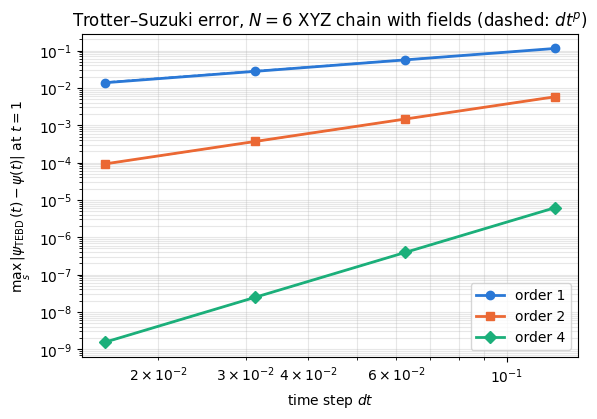

In [29]:
# ==============================================================================
# CHECKS: small exponentials, exact evolution, Trotter orders
# ==============================================================================
SECTION = "13"
h4 = rand_herm(61, 4)
tau = 0.37
check("_expm_herm(h, tau) = expm(-i tau h)", maxdiff(_expm_herm(jnp.asarray(h4, CDTYPE), tau), sla.expm(-1j * tau * h4)), 100 * TOL,
      mutant=maxdiff(_expm_herm(jnp.asarray(h4, CDTYPE), -tau), sla.expm(-1j * tau * h4)))
check("expm_herm = _expm_herm", maxdiff(expm_herm(jnp.asarray(h4, CDTYPE), tau), _expm_herm(jnp.asarray(h4, CDTYPE), tau)), 100 * TOL)

N = 6
cpl6 = dict(Jxx=1.0, Jyy=0.8, Jzz=0.6, hx=0.5, hy=0.0, hz=0.3)
terms6 = heisenberg_terms(N, **cpl6)
H6 = heisenberg_dense(N, [(i, i + 1) for i in range(N - 1)], **cpl6)
v0 = rand_state(62, N)
psi0 = as_tensor(v0, N)
t_final = 1.0
v_exact = sla.expm(-1j * t_final * H6) @ v0
check("exact_evolve vs scipy expm", maxdiff(exact_evolve(psi0, terms6, t_final), v_exact), 100 * TOL,
      mutant=maxdiff(exact_evolve(psi0, terms6, -t_final), v_exact))

gates1 = tebd_gates(terms6, 0.1, order=1)                             # one first-order step: a list of small gates
S1_dense = reduce(lambda M, g: embed_dense(np.asarray(g[1]), list(g[0]), N) @ M, gates1, np.eye(2 ** N))   # first gate acts first
check("apply_gates(tebd_gates(order=1)) = product of the dense factors", maxdiff(apply_gates(psi0, gates1), S1_dense @ v0), 100 * TOL,
      mutant=maxdiff(apply_gates(psi0, gates1[::-1]), S1_dense @ v0))  # the same gates in the reversed order

steps_list = {1: [8, 16, 32, 64], 2: [8, 16, 32, 64], 4: [8, 16, 32, 64] if PRECISION == "double" else [2, 4, 8]}
# (single precision: the fourth-order error reaches the round-off floor of float32, about 1e-6, already at 16 steps)
trotter_err, dts = {}, {}
for order, n_list in steps_list.items():
    dts[order] = t_final / np.array(n_list)
    trotter_err[order] = [maxdiff(tebd_evolve(psi0, terms6, t_final / n, n, order=order)[0], v_exact) for n in n_list]
for order, errs in trotter_err.items():
    slope = np.polyfit(np.log(dts[order]), np.log(errs), 1)[0]
    print(f"      order {order}: errors " + "  ".join(f"{e:.2e}" for e in errs) + f"   fitted slope {slope:.2f}")
    check(f"TEBD order {order}: global error ~ dt^{order}", abs(slope - order), 0.25)

z0 = lambda p: expect_local(p, Z, [0])
out, z_hist = tebd_evolve(psi0, terms6, t_final / 64, 64, order=4, observe=z0)
z_exact = (v_exact.conj() @ embed_dense(NP_Z, [0], N) @ v_exact).real
check("tebd_evolve observe: <Z_0>(t) at the last step", abs(z_hist[-1] - z_exact), 1e5 * TOL)
check("TEBD conserves the norm", abs(jnp.linalg.norm(out) - 1), 100 * TOL)

fig, ax = plt.subplots(figsize=(6.4, 4.2))
for (order, errs), c, m in zip(trotter_err.items(), PALETTE, "osD"):
    ax.loglog(dts[order], errs, marker=m, color=c, lw=2, label=f"order {order}")
    ax.loglog(dts[order], errs[0] * (dts[order] / dts[order][0]) ** order, color=c, ls="--", lw=1)
ax.set_xlabel(r"time step $dt$")
ax.set_ylabel(r"$\max_s\,\vert\psi_{\mathrm{TEBD}}(t)-\psi(t)\vert$ at $t=1$")
ax.set_title(r"Trotter–Suzuki error, $N=6$ XYZ chain with fields (dashed: $dt^{p}$)")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.show()

`apply_gates` applies the list in the order in which it is written, the first gate acting first; the same gates in the reversed order give a different operator, because the
terms do not commute. The measured slopes reproduce the orders 1, 2 and 4 of Eq. (64), and the errors lie on the dashed $dt^p$ lines over the whole range. The fourth-order
formula reaches an error of about $10^{-9}$ with 64 steps, at the price of five $\hat S_2$ steps per step. The observable recorded by `lax.scan` after the last step equals
$\langle\hat Z_0\rangle$ of the exact state within the Trotter error, and the norm is conserved to round-off, as expected for a product of unitaries.

### 13.3 Lanczos: the Krylov space and the ground state

The Lanczos iteration (Lanczos 1950) builds an orthonormal basis $\vert v_0\rangle,\dots,\vert v_{m-1}\rangle$ of the Krylov space $\mathrm{span}\{\vert v\rangle,\hat H\vert v\rangle,\dots,\hat H^{m-1}\vert v\rangle\}$ by the three-term recurrence

$$ \beta_j\vert v_{j+1}\rangle=\hat H\vert v_j\rangle-\alpha_j\vert v_j\rangle-\beta_{j-1}\vert v_{j-1}\rangle, \qquad \alpha_j=\langle v_j\vert\hat H\vert v_j\rangle,\quad \beta_j=\big\Vert\hat H\vert v_j\rangle-\alpha_j\vert v_j\rangle-\beta_{j-1}\vert v_{j-1}\rangle\big\Vert . \tag{65} $$

In this basis $\hat H$ is the tridiagonal matrix $T=V^\dagger\hat HV$ with $\alpha_j$ on the diagonal and $\beta_j$ beside it. The extremal eigenvalues of the small matrix $T$
converge first to those of $\hat H$; `lanczos_ground_state` restarts the iteration from the current approximation of the lowest eigenvector, and
`spectral_bounds` returns the lowest and highest eigenvalue of a short run. Only the product $\hat H\vert v\rangle$ is required, so the method is matrix-free. In floating
point the vectors lose their mutual orthogonality once the first Ritz values have converged, and the engine reorthogonalises against all previous vectors (`reorth=True`). Notebook 11 derives the
recurrence and its convergence.

In [30]:
# ==============================================================================
# Functions of quantum_engine.py derived in this notebook
# ==============================================================================
# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
def haar_state(key, N):
    """Haar-random pure state: a complex Gaussian vector, normalised.
    (The Gaussian measure is unitarily invariant, so the direction is uniformly distributed.)
    `key` is an explicit JAX PRNG key -- same key, same state: reproducible science."""
    k1, k2 = jax.random.split(key)
    v = jax.random.normal(k1, (2,) * N) + 1j * jax.random.normal(k2, (2,) * N)
    return (v / jnp.linalg.norm(v)).astype(CDTYPE)


# ----------------------------------------------------------------------------
# 8. Hamiltonians as lists of local terms;  H|psi>  matrix-free
# ----------------------------------------------------------------------------
def apply_hamiltonian(terms, psi):
    """H|psi> = sum_k h_k|psi>, every term applied with `apply_gate` (h_k is Hermitian, not unitary --
    the einsum does not care).  Cost O(#terms * 2^N).  This matrix-vector product is ALL that Lanczos,
    Chebyshev and Krylov methods need, which is why they scale to N ~ 25-30."""
    out = jnp.zeros_like(psi)
    for qubits, h in terms:
        out = out + apply_gate(psi, h, qubits)
    return out


# ----------------------------------------------------------------------------
# 9. Time evolution: TEBD / Trotter-Suzuki, Chebyshev, Krylov, exact
# ----------------------------------------------------------------------------
def lanczos(matvec, v0, m=60, reorth=True):
    """m-step Lanczos iteration: orthonormal basis V of the Krylov space span{v, Hv, H^2 v, ...}
    in which H is TRIDIAGONAL:   T = V^dag H V = tridiag(beta, alpha, beta).

    Recurrence     w = H v_j - alpha_j v_j - beta_{j-1} v_{j-1},   alpha_j = <v_j|H|v_j>,   beta_j = ||w||.
    `reorth=True`  re-orthogonalises against all previous vectors (cures the loss of orthogonality of
                   floating-point Lanczos at the price of O(m^2) inner products).
    Only `matvec` (H|psi>) is needed -> matrix-free.  Returns (alphas, betas, V[m, 2,..,2]).
    """
    v = v0 / jnp.linalg.norm(v0)
    V, alphas, betas = [v], [], []
    w = matvec(v)
    for j in range(m):
        a = jnp.real(jnp.vdot(V[j], w))
        alphas.append(a)
        w = w - a * V[j] - (betas[-1] * V[j - 1] if j > 0 else 0.0)
        if reorth:
            for u in V:
                w = w - jnp.vdot(u, w) * u
        b = jnp.linalg.norm(w)
        if j == m - 1 or float(b) < 1e-12:
            break
        betas.append(b)
        V.append(w / b)
        w = matvec(V[-1])
    return np.array(alphas, dtype=float), np.array(betas, dtype=float), jnp.stack(V)

def lanczos_ground_state(terms, N, m=80, key=None, restarts=3):
    """Ground state (E_0, |psi_0>) from restarted Lanczos: diagonalise the small T, map its lowest
    eigenvector back with V, use it as the next start vector.  Extremal eigenvalues converge first."""
    key = jax.random.PRNGKey(0) if key is None else key
    v = haar_state(key, N)
    mv = jax.jit(lambda p: apply_hamiltonian(terms, p))
    E = None
    for _ in range(restarts):
        a, b, V = lanczos(mv, v, m)
        w, S_ = np.linalg.eigh(np.diag(a) + np.diag(b, 1) + np.diag(b, -1))
        v = jnp.tensordot(jnp.asarray(S_[:, 0], dtype=CDTYPE), V, axes=1)
        v = v / jnp.linalg.norm(v)
        E = w[0]
    return float(E), v

def spectral_bounds(terms, N, m=40, key=None):
    """Cheap estimate of (E_min, E_max) from a short Lanczos run -- needed to rescale H into [-1,1]
    for the Chebyshev expansion."""
    key = jax.random.PRNGKey(1) if key is None else key
    a, b, _ = lanczos(jax.jit(lambda p: apply_hamiltonian(terms, p)), haar_state(key, N), m)
    w = np.linalg.eigvalsh(np.diag(a) + np.diag(b, 1) + np.diag(b, -1))
    return float(w[0]), float(w[-1])


In [31]:
# ==============================================================================
# CHECKS: Lanczos
# ==============================================================================
mv = jax.jit(lambda p: apply_hamiltonian(terms6, p))
alphas, betas, Vk = lanczos(mv, psi0, m=20)
Vm = np.asarray(Vk).reshape(len(alphas), -1)                         # rows = Lanczos vectors
T_tri = np.diag(alphas) + np.diag(betas, 1) + np.diag(betas, -1)
check("Lanczos vectors orthonormal: V V^dag = 1", maxdiff(Vm.conj() @ Vm.T, np.eye(len(alphas))), 100 * TOL)
check("Lanczos: V^dag H V = tridiagonal T", maxdiff(Vm.conj() @ H6 @ Vm.T, T_tri), 1e3 * TOL)
w6, U6 = np.linalg.eigh(H6)
E0, gs = lanczos_ground_state(terms6, N, m=40)
check("lanczos_ground_state: E_0 vs numpy eigh", abs(E0 - w6[0]), 1e3 * TOL, mutant=abs(E0 - w6[1]))
check("lanczos_ground_state: |<gs|gs_exact>|^2 = 1", abs(abs(np.vdot(U6[:, 0], np.asarray(gs).reshape(-1))) ** 2 - 1), 1e3 * TOL)
Emin, Emax = spectral_bounds(terms6, N)
check("spectral_bounds vs eigh (E_min, E_max)", max(abs(Emin - w6[0]), abs(Emax - w6[-1])), 1e3 * TOL)

PASS  Lanczos vectors orthonormal: V V^dag = 1           error  4.4e-16  tol   1e-08
PASS  Lanczos: V^dag H V = tridiagonal T                 error  2.3e-15  tol   1e-07


PASS  lanczos_ground_state: E_0 vs numpy eigh            error  7.1e-15  tol   1e-07   mutant  4.5e-01
PASS  lanczos_ground_state: |<gs|gs_exact>|^2 = 1        error  2.2e-16  tol   1e-07
PASS  spectral_bounds vs eigh (E_min, E_max)             error  7.1e-15  tol   1e-07


Twenty Lanczos vectors are orthonormal to round-off, and in their basis the dense Hamiltonian is the tridiagonal matrix built from the returned $\alpha_j$ and $\beta_j$.
The ground-state energy agrees with `numpy.linalg.eigh` to round-off and is clearly distinguished from the first excited level; the eigenvector has unit
overlap with the exact one, and the short run of `spectral_bounds` already finds both ends of the spectrum.

### 13.4 Chebyshev propagation

Rescale the Hamiltonian so that its spectrum lies in $[-1,1]$: $\hat H=a\hat x+b$ with $a=(E_{\max}-E_{\min})/2$ and $b=(E_{\max}+E_{\min})/2$ (the engine enlarges $a$ by 2 percent for
safety). The Jacobi–Anger expansion in Chebyshev polynomials (the propagator of Tal-Ezer and Kosloff 1984) $T_k(x)=\cos(k\arccos x)$ and Bessel functions $J_k$ gives

$$ e^{-i\hat Ht}=e^{-ibt}\,e^{-iat\,\hat x}=e^{-ibt}\sum_{k=0}^{\infty}(2-\delta_{k0})\,(-i)^k\,J_k(at)\;T_k(\hat x), \tag{66} $$

and the vectors $\vert\phi_k\rangle=T_k(\hat x)\vert\psi\rangle$ follow from the Chebyshev recurrence

$$ \vert\phi_0\rangle=\vert\psi\rangle,\qquad \vert\phi_1\rangle=\hat x\vert\psi\rangle,\qquad \vert\phi_{k+1}\rangle=2\hat x\vert\phi_k\rangle-\vert\phi_{k-1}\rangle . \tag{67} $$

Since $J_k(at)$ decays faster than exponentially once $k>at$, about $at+20$ terms reach machine precision, and there is no time-step error. The expansion
converges only if the spectrum of $\hat x$ really lies in $[-1,1]$; wrong spectral bounds make $T_k(\hat x)$ grow exponentially. Notebook 13 derives Eq. (66).

### 13.5 Krylov propagation

Project the evolution on the $m$-dimensional Krylov space of Eq. (65) (Park and Light 1986; error analysis: Hochbruck and Lubich 1997), started from $\vert v_0\rangle=\vert\psi\rangle/\Vert\psi\Vert$:

$$ \vert\psi(t)\rangle\approx\Vert\psi\Vert\;V\,e^{-iTt}\,e_1=\Vert\psi\Vert\sum_{j}c_j\vert v_j\rangle, \qquad c=S\,e^{-iwt}\,S^T e_1, \tag{68} $$

with $T=S\,\mathrm{diag}(w)\,S^T$ the eigendecomposition of the real tridiagonal matrix. The formula is exact for every polynomial of degree below $m$ in $\hat H$ and
accurate as long as $\vert t\vert$ times the spectral width is small compared with $m$. Notebook 14 derives it and compares all propagators.

In [32]:
# ==============================================================================
# Functions of quantum_engine.py derived in this notebook
# ==============================================================================
# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 8. Hamiltonians as lists of local terms;  H|psi>  matrix-free
# ----------------------------------------------------------------------------
def apply_hamiltonian(terms, psi):
    """H|psi> = sum_k h_k|psi>, every term applied with `apply_gate` (h_k is Hermitian, not unitary --
    the einsum does not care).  Cost O(#terms * 2^N).  This matrix-vector product is ALL that Lanczos,
    Chebyshev and Krylov methods need, which is why they scale to N ~ 25-30."""
    out = jnp.zeros_like(psi)
    for qubits, h in terms:
        out = out + apply_gate(psi, h, qubits)
    return out


# ----------------------------------------------------------------------------
# 9. Time evolution: TEBD / Trotter-Suzuki, Chebyshev, Krylov, exact
# ----------------------------------------------------------------------------
def lanczos(matvec, v0, m=60, reorth=True):
    """m-step Lanczos iteration: orthonormal basis V of the Krylov space span{v, Hv, H^2 v, ...}
    in which H is TRIDIAGONAL:   T = V^dag H V = tridiag(beta, alpha, beta).

    Recurrence     w = H v_j - alpha_j v_j - beta_{j-1} v_{j-1},   alpha_j = <v_j|H|v_j>,   beta_j = ||w||.
    `reorth=True`  re-orthogonalises against all previous vectors (cures the loss of orthogonality of
                   floating-point Lanczos at the price of O(m^2) inner products).
    Only `matvec` (H|psi>) is needed -> matrix-free.  Returns (alphas, betas, V[m, 2,..,2]).
    """
    v = v0 / jnp.linalg.norm(v0)
    V, alphas, betas = [v], [], []
    w = matvec(v)
    for j in range(m):
        a = jnp.real(jnp.vdot(V[j], w))
        alphas.append(a)
        w = w - a * V[j] - (betas[-1] * V[j - 1] if j > 0 else 0.0)
        if reorth:
            for u in V:
                w = w - jnp.vdot(u, w) * u
        b = jnp.linalg.norm(w)
        if j == m - 1 or float(b) < 1e-12:
            break
        betas.append(b)
        V.append(w / b)
        w = matvec(V[-1])
    return np.array(alphas, dtype=float), np.array(betas, dtype=float), jnp.stack(V)

def chebyshev_evolve(psi, terms, t, bounds, tol=1e-13, safety=1.02):
    """exp(-iHt)|psi> by Chebyshev expansion (Tal-Ezer & Kosloff) -- no Trotter error.

    MATH   rescale  Ht = (H - b)/a  with a = (Emax-Emin)/2, b = (Emax+Emin)/2   => spectrum in [-1,1]
           Jacobi-Anger:   e^{-i a t x} = sum_k (2 - delta_k0) (-i)^k J_k(a t) T_k(x)
           =>  e^{-iHt}|psi> = e^{-i b t} sum_k c_k |phi_k>,    c_k = (2-delta_k0)(-i)^k J_k(a t)
           recurrence     |phi_0> = |psi>, |phi_1> = Ht|psi>, |phi_{k+1}> = 2 Ht|phi_k> - |phi_{k-1}>.
    CONVERGENCE   J_k(at) decays super-exponentially for k > a t: the number of terms is ~ a t + O(10),
           and the error can be pushed to machine precision.  Memory: 3 vectors.
    JAX    the recurrence is a `lax.scan` whose carry is (phi_{k-1}, phi_k, accumulated sum).
    """
    from scipy.special import jv
    Emin, Emax = bounds
    a, b = safety * (Emax - Emin) / 2.0, (Emax + Emin) / 2.0
    K = int(np.ceil(a * abs(t))) + 20
    while abs(jv(K, a * t)) > tol:
        K += 10
    coef = jnp.asarray([(1 if k == 0 else 2) * ((-1j) ** k) * jv(k, a * t) for k in range(K + 1)], dtype=CDTYPE)

    def Ht(p):
        return (apply_hamiltonian(terms, p) - b * p) / a

    T0, T1 = psi, Ht(psi)
    acc0 = coef[0] * T0 + coef[1] * T1

    def body(carry, c):
        Tm, Tc, acc = carry
        Tn = 2 * Ht(Tc) - Tm
        return (Tc, Tn, acc + c * Tn), None

    (_, _, acc), _ = lax.scan(body, (T0, T1, acc0), coef[2:])
    return jnp.exp(-1j * b * t) * acc

def krylov_evolve(psi, terms, t, m=30):
    """exp(-iHt)|psi> in an m-dimensional Krylov space:
        |psi(t)> ~ ||psi|| * V exp(-i T t) e_1 ,      T = V^dag H V  (tridiagonal, from Lanczos).
    Exact for polynomials of degree < m in H; accurate as long as  |t| * (spectral width)  <~  m.
    For long times: chain several short Krylov steps."""
    nrm = jnp.linalg.norm(psi)
    a, b, V = lanczos(jax.jit(lambda p: apply_hamiltonian(terms, p)), psi, m)
    w, S_ = np.linalg.eigh(np.diag(a) + np.diag(b, 1) + np.diag(b, -1))
    c = S_ @ (np.exp(-1j * t * w) * S_[0, :])
    return nrm * jnp.tensordot(jnp.asarray(c, dtype=CDTYPE), V, axes=1)


In [33]:
# ==============================================================================
# CHECKS: Chebyshev and Krylov against scipy expm
# ==============================================================================
t2 = 2.0
v_t2 = sla.expm(-1j * t2 * H6) @ v0
bounds = spectral_bounds(terms6, N)
bad = (0.5 * bounds[0], 0.5 * bounds[1])                             # mutant: spectrum not inside [-1, 1]
check("chebyshev_evolve vs expm (t = 2)", maxdiff(chebyshev_evolve(psi0, terms6, t2, bounds), v_t2), 1e3 * TOL,
      mutant=maxdiff(chebyshev_evolve(psi0, terms6, t2, bad), v_t2))
for m in (8, 12, 16, 24, 32):
    print(f"      krylov_evolve, m = {m:2d}: error {maxdiff(krylov_evolve(psi0, terms6, t2, m=m), v_t2):.2e}")
check("krylov_evolve (m = 32) vs expm (t = 2)", maxdiff(krylov_evolve(psi0, terms6, t2, m=32), v_t2), 1e3 * TOL,
      mutant=maxdiff(krylov_evolve(psi0, terms6, -t2, m=32), v_t2))     # mutant: e^{+iHt}, the sign of the exponent

PASS  chebyshev_evolve vs expm (t = 2)                   error  3.7e-16  tol   1e-07   mutant  5.0e+00
      krylov_evolve, m =  8: error 3.09e-01


      krylov_evolve, m = 12: error 3.55e-01
      krylov_evolve, m = 16: error 2.56e-02


      krylov_evolve, m = 24: error 1.45e-06
      krylov_evolve, m = 32: error 6.40e-13


PASS  krylov_evolve (m = 32) vs expm (t = 2)             error  6.4e-13  tol   1e-07   mutant  2.6e-01


With the correct bounds the Chebyshev series reproduces the exact state to round-off. With bounds that are too narrow by a factor 2 the polynomials
$T_k(\hat x)$ are evaluated outside $[-1,1]$, where they grow exponentially with $k$, and the error of the mutant exceeds the norm of the state itself. The Krylov
error is of order $0.3$ for $m\le12$ and then falls by more than ten orders of magnitude between $m=16$ and $m=32$, the super-exponential convergence derived in notebook 14
(it sets in once $m$ exceeds a threshold of order $a\,t$, with $a$ the half-width of the spectrum). The mutant with the opposite sign of the exponent, $e^{+i\hat Ht}$, is rejected.

## 14. Open systems: the Lindblad equation

### 14.1 The right-hand side on a density tensor

The Gorini–Kossakowski–Sudarshan–Lindblad (GKSL) master equation (Gorini, Kossakowski and Sudarshan 1976; Lindblad 1976) for a system coupled to a memoryless environment is

$$ \frac{d\hat\rho}{dt}=\mathcal L(\hat\rho)=-i\big[\hat H,\hat\rho\big]+\sum_j\gamma_j\Big(\hat L_j\hat\rho\hat L_j^\dagger-\tfrac12\hat L_j^\dagger\hat L_j\hat\rho-\tfrac12\hat\rho\hat L_j^\dagger\hat L_j\Big). \tag{69} $$

Every term is a product of a local operator with $\hat\rho$ from the left or from the right, and both are single contractions:

$$ \begin{aligned} (\hat O\hat\rho)[a;a'] &= \sum_b O[a,b]\,\rho[b;a'] &&\to\ O\ \text{on the ket axis}, \\ (\hat\rho\hat O)[a;a'] &= \sum_b\rho[a;b]\,O[b,a']=\sum_b O^T[a',b]\,\rho[a;b] &&\to\ O^T\ \text{on the bra axis}, \\ (\hat L\hat\rho\hat L^\dagger)[a;a'] &= \sum_{b,b'}L[a,b]\,L^*[a',b']\,\rho[b;b'] &&\to\ L\ \text{on the ket axis},\ L^*\ \text{on the bra axis}. \end{aligned} \tag{70} $$

The transpose in the second line is easy to forget, and it matters whenever $O^T\neq O$, for example for a Hamiltonian with a $\hat Y$ field. `lindblad_rhs` evaluates
Eq. (69) with Eq. (70) and `apply_gate` only.

For an independent check we write Eq. (69) as a matrix acting on the vectorised density matrix. The C-ordered reshape of the density tensor into a vector
has the components $\mathrm{vec}(\rho)_{(a a')}=\rho[a;a']$. By Eq. (6),

$$ \mathrm{vec}\big(\hat A\hat\rho\hat B\big)_{(a a')}=\sum_{b,b'}A[a,b]\,B[b',a']\,\rho[b;b']=\sum_{b,b'}\big(A\otimes B^T\big)_{(a a'),(b b')}\,\mathrm{vec}(\rho)_{(b b')}, \tag{71} $$

and applying Eq. (71) to each term of Eq. (69) gives the Liouvillian superoperator

$$ \mathcal L=-i\big(H\otimes\mathbb{1}-\mathbb{1}\otimes H^T\big)+\sum_j\gamma_j\Big(L_j\otimes L_j^*-\tfrac12\,L_j^\dagger L_j\otimes\mathbb{1}-\tfrac12\,\mathbb{1}\otimes\big(L_j^\dagger L_j\big)^T\Big), \tag{72} $$

a $4^N\times4^N$ matrix, whose exponential `scipy.linalg.expm` computes for $N=3$. The solution $\mathrm{vec}\,\rho(t)=e^{\mathcal Lt}\,\mathrm{vec}\,\rho(0)$ is the reference for the integrators.

### 14.2 Integrators

`lindblad_rk4_step` is the classical fourth-order Runge–Kutta step (Press *et al.* 2007, Sec. 17.1) for $\dot\rho=\mathcal L(\rho)$:

$$ \begin{aligned} k_1&=\mathcal L(\rho),\quad k_2=\mathcal L\big(\rho+\tfrac{dt}{2}k_1\big),\quad k_3=\mathcal L\big(\rho+\tfrac{dt}{2}k_2\big),\quad k_4=\mathcal L\big(\rho+dt\,k_3\big), \\ \rho(t+dt)&=\rho+\tfrac{dt}{6}\big(k_1+2k_2+2k_3+k_4\big)+O(dt^5). \end{aligned} \tag{73} $$

Its global error is $O(dt^4)$. Every $k_i$ is traceless and Hermitian, because $\mathcal L$ maps Hermitian matrices to traceless Hermitian ones (Eq. 69: the trace of a
commutator vanishes, and $\mathrm{Tr}(\hat L\hat\rho\hat L^\dagger)=\mathrm{Tr}(\hat L^\dagger\hat L\hat\rho)$ cancels the anticommutator term), so an RK4 step preserves the trace and the Hermiticity
exactly, up to round-off. Positivity is preserved only approximately, because a polynomial in $dt\,\mathcal L$ is in general not a completely positive map. `lindblad_trotter_step_dm` applies the unitary Trotter gates and then, for
each jump operator, the Kraus pair of Eq. (55); every step is completely positive and trace preserving, and the splitting is first order in $dt$ for the dissipator.
`lindblad_trotter_step_mcwf` applies the same step to a pure state with `apply_kraus_mcwf`; by Eq. (57) its trajectory average equals the density-tensor step
exactly, so the two differ only by the statistical error. Notebooks 16 and 17 derive and benchmark these integrators.

In [34]:
# ==============================================================================
# Functions of quantum_engine.py derived in this notebook
# ==============================================================================
# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)

def apply_gate_dm(rho, U, qubits):
    """Unitary on a density tensor:  rho -> U rho U^dagger.

    MATH   rho'[a..;a'..] = sum_{b,b'} U[a,b] rho[b..;b'..] U^*[a',b']
           i.e. U acts on the KET axis q and the complex conjugate U^* on the BRA axis N+q.
           (A density matrix is "a state vector of 2N qubits": vectorisation |rho>> and
           U (x) U^* acting on it.)
    IMPLEMENTATION  two calls of `apply_gate` -- the same einsum machinery, no new code.
    COST   O(2^k 4^N).
    """
    N = rho.ndim // 2
    rho = apply_gate(rho, U, qubits)                                         # U    on ket axes
    return apply_gate(rho, jnp.conj(jnp.asarray(U)), [N + q for q in qubits])  # U^*  on bra axes

def apply_kraus_dm(rho, kraus, qubits):
    """Quantum channel in Kraus form:  rho -> sum_m K_m rho K_m^dagger,   sum_m K_m^dag K_m = 1.

    EINSUM TRANSLATION  (N=2, channel on qubit 0; g = Kraus index, summed!)
        "gea,gfc,abcd->ebfd"   with operands  K, K^*, rho      [a=ket0, b=ket1, c=bra0, d=bra1; e, f = new ket0, bra0]
    All Kraus branches are summed INSIDE one einsum -- no Python loop over m.
    `kraus` has shape (M, 2^k, 2^k).
    """
    qubits = tuple(int(q) for q in qubits)
    k, N = len(qubits), rho.ndim // 2
    K = jnp.asarray(kraus, dtype=rho.dtype).reshape((-1,) + (2,) * (2 * k))
    n = rho.ndim
    inp = list(_LETTERS[:n])
    new_k, new_b, m = _LETTERS[n:n + k], _LETTERS[n + k:n + 2 * k], _LETTERS[n + 2 * k]
    out = inp.copy()
    for a, b, q in zip(new_k, new_b, qubits):
        out[q], out[N + q] = a, b
    ket_old = "".join(inp[q] for q in qubits)
    bra_old = "".join(inp[N + q] for q in qubits)
    sub = f"{m}{new_k}{ket_old},{m}{new_b}{bra_old},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, K, jnp.conj(K), rho)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm(psi, keep):
    """Reduced density matrix of the qubits `keep` from a PURE state:  rho_A = Tr_B |psi><psi|.

    MATH
        rho_A[a, a'] = sum_{b}  psi[a, b] psi^*[a', b]          (a: indices of A, b: of the rest B)
    EINSUM TRANSLATION   N=3, keep=(0,):   "abc,Abc->aA"   with operands psi, psi^*
        * letters of B (b,c) appear in BOTH operands and not in the output  -> summed = traced out
        * the kept axis gets a different letter in the second operand       -> stays open (a and A)
    The full |psi><psi| (4^N numbers) is never formed; cost O(2^N 2^|A|).
    Returns a (2^|A|, 2^|A|) matrix with row/column order following `keep`.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    a = list(_LETTERS[:n])
    b = a.copy()
    for new, q in zip(_LETTERS[n:n + k], keep):
        b[q] = new
    sub = f"{''.join(a)},{''.join(b)}->{''.join(a[q] for q in keep)}{''.join(b[q] for q in keep)}"
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)


# ----------------------------------------------------------------------------
# 7. Noise channels (Kraus operators): density matrix and quantum-trajectory forms
# ----------------------------------------------------------------------------
def apply_kraus_mcwf(key, psi, kraus, qubits):
    """Apply a channel to a PURE state stochastically (quantum trajectory / Monte-Carlo wave function).

    MATH   choose branch m with probability  p_m = ||K_m psi||^2 = Tr(K_m rho_A K_m^dag)
           then  |psi> -> K_m|psi> / sqrt(p_m).
           Averaging |psi><psi| over many trajectories gives exactly  sum_m K_m rho K_m^dag.
    WHY    memory O(2^N) instead of O(4^N): open systems at the price of closed ones (times #trajectories,
           which are embarrassingly parallel -> jax.vmap over keys).
    IMPLEMENTATION   probabilities come from the SMALL reduced density matrix (einsum "mab,bc,mac->m");
           `K[m]` with a traced integer m is a gather, so everything stays jit-compatible.
    """
    K = jnp.asarray(kraus, dtype=CDTYPE)
    r = rdm(psi, qubits)
    probs = jnp.real(jnp.einsum("mab,bc,mac->m", K, r, jnp.conj(K)))
    m = jax.random.categorical(key, jnp.log(jnp.clip(probs, 1e-300, None)))
    psi = apply_gate(psi, K[m], qubits)
    return psi / jnp.linalg.norm(psi)


# ----------------------------------------------------------------------------
# 9. Time evolution: TEBD / Trotter-Suzuki, Chebyshev, Krylov, exact
# ----------------------------------------------------------------------------
def apply_gates(psi, gates):
    """Apply a list [(qubits, U), ...] in order -- a quantum circuit is a Python loop over einsums.
    Under `jax.jit` the loop is unrolled at trace time and XLA fuses it into one program."""
    for qubits, U in gates:
        psi = apply_gate(psi, U, qubits)
    return psi

def apply_gates_dm(rho, gates):
    """Same circuit on a density tensor (U on kets, U^* on bras)."""
    for qubits, U in gates:
        rho = apply_gate_dm(rho, U, qubits)
    return rho


# ----------------------------------------------------------------------------
# 10. Open systems: Lindblad master equation (density tensor) and quantum trajectories (MCWF)
# ----------------------------------------------------------------------------
def lindblad_rhs(rho, terms, jumps):
    """Right-hand side of the Lindblad (GKSL) master equation, matrix-free:
        d rho/dt = -i[H, rho] + sum_j gamma_j ( L_j rho L_j^dag - (1/2){L_j^dag L_j, rho} ).
    `jumps` = [(qubits, L, gamma), ...].

    KEY TRICK   left multiplication  O rho  acts on KET axes with O;
                right multiplication rho O  acts on BRA axes with O^T     [ (rho O)_{ab} = sum_c rho_{ac} O_{cb} ].
                So every term is again `apply_gate` on a rank-2N tensor.
    """
    N = rho.ndim // 2
    out = jnp.zeros_like(rho)
    for q, h in terms:
        bq = [N + x for x in q]
        out = out - 1j * (apply_gate(rho, h, q) - apply_gate(rho, jnp.asarray(h).T, bq))
    for q, L, g in jumps:
        L = jnp.asarray(L, dtype=CDTYPE)
        bq = [N + x for x in q]
        LdL = L.conj().T @ L
        out = out + g * (apply_gate(apply_gate(rho, L, q), jnp.conj(L), bq)
                         - 0.5 * apply_gate(rho, LdL, q) - 0.5 * apply_gate(rho, LdL.T, bq))
    return out

def lindblad_rk4_step(rho, terms, jumps, dt):
    """Classical 4th-order Runge-Kutta step for d rho/dt = L(rho): local error O(dt^5).
    TRACE   conserved to round-off: every term of the Lindblad generator is traceless and the step is a linear
            combination of generator evaluations.  This holds even beyond the stability limit, so a correct trace
            does NOT certify a healthy run.
    POSITIVITY   not guaranteed: small negative eigenvalues appear for moderate dt, and the run blows up once
            dt * ||L|| exceeds the RK4 stability bound."""
    f = lambda r: lindblad_rhs(r, terms, jumps)
    k1 = f(rho)
    k2 = f(rho + 0.5 * dt * k1)
    k3 = f(rho + 0.5 * dt * k2)
    k4 = f(rho + dt * k3)
    return rho + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)

def lindblad_trotter_step_dm(rho, gates, jump_kraus):
    """Trotterised Lindblad step on a density tensor: unitary TEBD gates, then one Kraus channel per
    jump operator (`jump_kraus` = [(qubits, kraus_from_jump(L, gamma*dt)), ...]).
    Completely positive and trace preserving by construction, first order in the dissipator."""
    rho = apply_gates_dm(rho, gates)
    for q, K in jump_kraus:
        rho = apply_kraus_dm(rho, K, q)
    return rho

def lindblad_trotter_step_mcwf(key, psi, gates, jump_kraus):
    """The SAME step unravelled on a pure state (Monte-Carlo wave function): each Kraus channel is
    sampled with `apply_kraus_mcwf`.  The trajectory average equals `lindblad_trotter_step_dm` exactly,
    so DM-vs-MCWF comparisons test only the statistical error ~ 1/sqrt(n_traj).
    JAX: scan over time steps, vmap over trajectory keys."""
    psi = apply_gates(psi, gates)
    keys = jax.random.split(key, max(len(jump_kraus), 1))
    for k, (q, K) in zip(keys, jump_kraus):
        psi = apply_kraus_mcwf(k, psi, K, q)
    return psi


The checks use $N=3$ with a $\hat Y$ field in the Hamiltonian (so that $H^T\neq H$), a random single-qubit jump operator on qubit 2 and a random two-qubit jump
operator on the reversed pair $(2,0)$. The mutant of the right-hand side drops the transpose of Eq. (70). The integrators are compared with $e^{\mathcal Lt}$ at
several time steps to measure their orders.

PASS  lindblad_rhs vs Liouvillian, Eq. (72)              error  1.1e-16  tol   1e-08   mutant  2.4e-01
PASS  lindblad_rhs: traceless and Hermitian              error  8.3e-17  tol   1e-08


      RK4    errors 7.28e-05  4.19e-06  2.46e-07  1.49e-08   slope 4.09
      Trotter-Kraus 1.09e-03  5.24e-04  2.57e-04  1.27e-04   slope 1.03
PASS  lindblad_rk4_step: global error ~ dt^4             error  8.6e-02  tol   3e-01
PASS  lindblad_rk4_step: trace preserved                 error  1.2e-18  tol   1e-08
PASS  lindblad_trotter_step_dm: global error ~ dt        error  3.2e-02  tol   3e-01
PASS  Trotter-Kraus step: trace preserved                error  1.5e-13  tol   1e-08


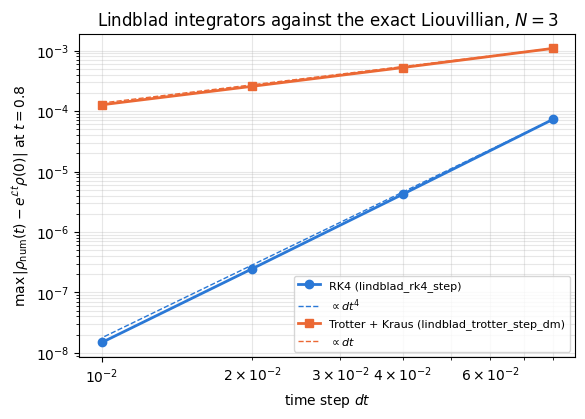

In [35]:
# ==============================================================================
# CHECKS: Lindblad right-hand side and integrators against the Liouvillian of Eq. (72)
# ==============================================================================
SECTION = "14"
N = 3
cpl3 = dict(Jxx=1.0, Jyy=0.7, Jzz=0.4, hx=0.3, hy=0.5, hz=-0.2)
terms3 = heisenberg_terms(N, **cpl3)
H3 = heisenberg_dense(N, [(0, 1), (1, 2)], **cpl3)
L1 = 0.6 * rand_matrix(71, 2)
L2 = 0.3 * rand_matrix(72, 4)
jumps = [((2,), jnp.asarray(L1, CDTYPE), 0.3), ((2, 0), jnp.asarray(L2, CDTYPE), 0.2)]
Id = np.eye(2 ** N)


def liouvillian(Hd, jump_list, transpose=True):
    """Eq. (72): the 4^N x 4^N superoperator acting on vec(rho) (C order).  transpose=False builds the mutant."""
    tr = (lambda A: A.T) if transpose else (lambda A: A)
    Lsup = -1j * (np.kron(Hd, Id) - np.kron(Id, tr(Hd)))
    for qs, L, g in jump_list:
        E = embed_dense(L, list(qs), N)
        EdE = E.conj().T @ E
        Lsup += g * (np.kron(E, E.conj()) - 0.5 * np.kron(EdE, Id) - 0.5 * np.kron(Id, tr(EdE)))
    return Lsup


Lsup = liouvillian(H3, jumps)
R0 = rand_dm(73, N)
rho0 = jnp.asarray(R0.reshape((2,) * (2 * N)), CDTYPE)
rhs = np.asarray(lindblad_rhs(rho0, terms3, jumps)).reshape(-1)
check("lindblad_rhs vs Liouvillian, Eq. (72)", maxdiff(rhs, Lsup @ R0.reshape(-1)), 100 * TOL,
      mutant=maxdiff(rhs, liouvillian(H3, jumps, transpose=False) @ R0.reshape(-1)))
rhs_mat = rhs.reshape(2 ** N, 2 ** N)
check("lindblad_rhs: traceless and Hermitian", abs(np.trace(rhs_mat)) + maxdiff(rhs_mat, rhs_mat.conj().T), 100 * TOL)

t_open = 0.8
R_exact = (sla.expm(Lsup * t_open) @ R0.reshape(-1)).reshape(2 ** N, 2 ** N)


def run_steps(step, rho, n):
    """n repetitions of a one-argument step function, compiled once with lax.scan."""
    return jax.jit(lambda r: lax.scan(lambda c, _: (step(c), None), r, None, length=n)[0])(rho)


steps_open = [10, 20, 40, 80]
err_rk4, err_trot = [], []
for n in steps_open:
    dt = t_open / n
    r_rk = run_steps(lambda r: lindblad_rk4_step(r, terms3, jumps, dt), rho0, n)
    err_rk4.append(maxdiff(dm_matrix(r_rk), R_exact))
    gates = tebd_gates(terms3, dt, order=2)
    jk = [(qs, kraus_from_jump(L, g * dt)) for qs, L, g in jumps]
    r_tr = run_steps(lambda r: lindblad_trotter_step_dm(r, gates, jk), rho0, n)
    err_trot.append(maxdiff(dm_matrix(r_tr), R_exact))
dts_open = t_open / np.array(steps_open)
s_rk = np.polyfit(np.log(dts_open), np.log(err_rk4), 1)[0]
s_tr = np.polyfit(np.log(dts_open), np.log(err_trot), 1)[0]
print("      RK4    errors " + "  ".join(f"{e:.2e}" for e in err_rk4) + f"   slope {s_rk:.2f}")
print("      Trotter-Kraus " + "  ".join(f"{e:.2e}" for e in err_trot) + f"   slope {s_tr:.2f}")
check("lindblad_rk4_step: global error ~ dt^4", abs(s_rk - 4), 0.3)
check("lindblad_rk4_step: trace preserved", abs(np.trace(np.asarray(dm_matrix(r_rk))) - 1), 100 * TOL)
check("lindblad_trotter_step_dm: global error ~ dt", abs(s_tr - 1), 0.3)
check("Trotter-Kraus step: trace preserved", abs(np.trace(np.asarray(dm_matrix(r_tr))) - 1), 100 * TOL)

fig, ax = plt.subplots(figsize=(6.4, 4.2))
ax.loglog(dts_open, err_rk4, "o-", color=PALETTE[0], lw=2, label="RK4 (lindblad_rk4_step)")
ax.loglog(dts_open, err_rk4[0] * (dts_open / dts_open[0]) ** 4, "--", color=PALETTE[0], lw=1, label=r"$\propto dt^4$")
ax.loglog(dts_open, err_trot, "s-", color=PALETTE[1], lw=2, label="Trotter + Kraus (lindblad_trotter_step_dm)")
ax.loglog(dts_open, err_trot[0] * (dts_open / dts_open[0]), "--", color=PALETTE[1], lw=1, label=r"$\propto dt$")
ax.set_xlabel(r"time step $dt$")
ax.set_ylabel(r"$\max\,\vert\rho_{\mathrm{num}}(t)-e^{\mathcal{L}t}\rho(0)\vert$ at $t=0.8$")
ax.set_title(r"Lindblad integrators against the exact Liouvillian, $N=3$")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8)
plt.show()

The right-hand side agrees with the Liouvillian to round-off, it is traceless and Hermitian as Eq. (69) requires, and the mutant without the transpose fails.
The two integrators show their orders: RK4 converges as $dt^4$ and the Kraus splitting as $dt$, and both preserve the trace to round-off. For the
same step the Kraus splitting is less accurate but guarantees a positive state, which matters for long runs with large $dt$.

The last check unravels the same Trotter–Kraus step into 2000 pure-state trajectories (amplitude damping $\hat\sigma^+=\vert 0\rangle\langle 1\vert$ on every qubit), with `lax.scan` over the
time steps and `jax.vmap` over the trajectory keys, and compares $\langle\hat Z_q\rangle$ with the density-tensor evolution.

In [36]:
# ==============================================================================
# CHECK: quantum trajectories reproduce the density-tensor step (statistically)
# ==============================================================================
gamma, dt, n_steps, n_traj = 0.4, 0.05, 30, 2000
gates = tebd_gates(terms3, dt, order=2)
jk = [((q,), kraus_from_jump(SP, gamma * dt)) for q in range(N)]
psi_start = product_state("1+1")


@jax.jit
def trajectory_z(key):
    """One quantum trajectory of n_steps Trotter-Kraus steps; returns <Z_q> for all q at the end."""
    def step(p, k):
        return lindblad_trotter_step_mcwf(k, p, gates, jk), None
    p, _ = lax.scan(step, psi_start, jax.random.split(key, n_steps))
    return jnp.stack([expect_local(p, Z, [q]) for q in range(N)])


z_traj = np.asarray(jax.vmap(trajectory_z)(jax.random.split(jax.random.PRNGKey(31), n_traj)))
r = to_dm(psi_start)
for _ in range(n_steps):
    r = lindblad_trotter_step_dm(r, gates, jk)
z_dm = np.array([float(expect_local_dm(r, Z, [q])) for q in range(N)])
r_u = to_dm(psi_start)                                               # mutant: the same steps without the jump operators
for _ in range(n_steps):
    r_u = lindblad_trotter_step_dm(r_u, gates, [])
z_u = np.array([float(expect_local_dm(r_u, Z, [q])) for q in range(N)])
se = z_traj.std(0) / np.sqrt(n_traj)
for q in range(N):
    print(f"      <Z_{q}>: trajectories {z_traj[:, q].mean():+.4f} +- {se[q]:.4f}   density tensor {z_dm[q]:+.4f}   without jumps {z_u[q]:+.4f}")
check("MCWF trajectories vs density tensor, max |z|", np.max(np.abs(z_traj.mean(0) - z_dm) / se), 5.0,
      mutant=np.max(np.abs(z_traj.mean(0) - z_u) / se), mutant_factor=1)

      <Z_0>: trajectories +0.3092 +- 0.0064   density tensor +0.3073   without jumps +0.0655
      <Z_1>: trajectories -0.0776 +- 0.0144   density tensor -0.0940   without jumps -0.8505
      <Z_2>: trajectories +0.3107 +- 0.0062   density tensor +0.3075   without jumps +0.0664
PASS  MCWF trajectories vs density tensor, max |z|       error  1.1e+00  tol   5e+00   mutant  5.4e+01


The trajectory averages agree with the density-tensor evolution within the statistical error, with a memory cost of $2^N$ per trajectory instead of $4^N$, and they differ by many
standard errors from the evolution without the jump operators (the mutant). The density-tensor step used as the reference here was checked against the exact Liouvillian above.

## 15. Collective spins and metrology

### 15.1 Collective operators and the quantum Fisher information

For $N$ spins-1/2 the collective spin and the generator without the factor $\tfrac12$ are

$$ \hat J_a=\tfrac12\sum_{q=0}^{N-1}\hat\sigma^a_q, \qquad \hat G=\sum_{q=0}^{N-1}\hat P_q=2\hat J_P . \tag{74} $$

`apply_collective` returns $\hat G\vert\psi\rangle$ with $N$ single-qubit contractions, and `collective_dense` builds the dense $\hat J_P$ for small systems. When a phase
$\theta$ is imprinted by $e^{-i\theta\hat J}$ on a pure state, the quantum Fisher information (QFI) is four times the variance of the generator (notebook 29):

$$ F_Q=4\,\mathrm{Var}(\hat J)=\langle\hat G^2\rangle-\langle\hat G\rangle^2, \qquad \langle\hat G^2\rangle=\langle\phi\vert\phi\rangle,\quad \langle\hat G\rangle=\langle\psi\vert\phi\rangle,\quad \vert\phi\rangle=\hat G\vert\psi\rangle . \tag{75} $$

The second form uses that $\hat G$ is Hermitian, so $\langle\psi\vert\hat G^2\vert\psi\rangle=\Vert\hat G\psi\Vert^2$, and needs one application of $\hat G$. The QFI bounds the precision of any
estimate of $\theta$ from $M$ repetitions by the quantum Cramér–Rao bound $\Delta\theta\ge1/\sqrt{MF_Q}$. Two cases can be evaluated by hand with $\hat P=\hat Z$. For $\vert +\rangle^{\otimes N}$
the cross terms vanish, $\langle\hat Z_q\hat Z_{q'}\rangle=\langle\hat Z_q\rangle\langle\hat Z_{q'}\rangle=0$ for $q\neq q'$, so $\langle\hat G^2\rangle=\sum_q\langle\hat Z_q^2\rangle=N$ and $\langle\hat G\rangle=0$. For the GHZ state both
branches are eigenstates of $\hat G$ with eigenvalues $\pm N$, so $\langle\hat G^2\rangle=N^2$ and $\langle\hat G\rangle=0$:

$$ F_Q\big(\vert +\rangle^{\otimes N}\big)=N, \qquad F_Q\big(\vert\mathrm{GHZ}_N\rangle\big)=N^2 . \tag{76} $$

These are the standard quantum limit and the Heisenberg limit. For a mixed state $\hat\rho=\sum_m\lambda_m\vert m\rangle\langle m\vert$ the QFI is given by the symmetric-logarithmic-derivative formula

$$ F_Q=2\sum_{m,n:\ \lambda_m+\lambda_n>0}\frac{(\lambda_m-\lambda_n)^2}{\lambda_m+\lambda_n}\,\big\vert\langle m\vert\hat J\vert n\rangle\big\vert^2 , \tag{77} $$

which `qfi_mixed` evaluates from a dense eigendecomposition. As an independent check we use its geometric meaning (Braunstein and Caves): the QFI is the
curvature of the Uhlmann fidelity of Eq. (41) between neighbouring states $\hat\rho_\theta=e^{-i\theta\hat J}\hat\rho\,e^{i\theta\hat J}$,

$$ F_Q=\lim_{\theta\to0}\frac{8\big(1-\sqrt{F(\hat\rho,\hat\rho_\theta)}\big)}{\theta^2}, \tag{78} $$

which we evaluate at a small $\theta$ with matrix square roots from SciPy.

### 15.2 Spin moments, squeezing and one-axis twisting

`spin_moments` returns the mean spin $\langle\hat J_a\rangle$ and the symmetrised covariance matrix

$$ C_{ab}=\tfrac12\big\langle\hat J_a\hat J_b+\hat J_b\hat J_a\big\rangle-\langle\hat J_a\rangle\langle\hat J_b\rangle, \qquad \tfrac12\big\langle\hat J_a\hat J_b+\hat J_b\hat J_a\big\rangle=\mathrm{Re}\,\langle\phi_a\vert\phi_b\rangle,\quad \vert\phi_a\rangle=\hat J_a\vert\psi\rangle . \tag{79} $$

The second identity holds because $\langle\phi_a\vert\phi_b\rangle=\langle\psi\vert\hat J_a\hat J_b\vert\psi\rangle$ and $\langle\psi\vert\hat J_b\hat J_a\vert\psi\rangle$ is its complex conjugate. The Wineland squeezing parameter (Wineland *et al.* 1994) compares the
smallest variance perpendicular to the mean spin with that of a coherent spin state,

$$ \xi^2=\frac{N\,\min_{\vec n\perp\langle\vec J\rangle}\mathrm{Var}(\vec n\cdot\hat{\vec J})}{\vert\langle\vec J\rangle\vert^2}, \tag{80} $$

where the minimum runs over unit vectors in the plane perpendicular to the mean spin; the engine projects $C$ onto that plane and takes the smaller eigenvalue
of the $2\times2$ result. One-axis twisting $e^{-i\chi t\hat J_z^2}$ (Kitagawa and Ueda 1993) is diagonal in the computational basis: $\hat J_z\vert s\rangle=m(s)\vert s\rangle$ with $m(s)=\sum_q(\tfrac12-s_q)$, so

$$ \psi[s]\;\to\;e^{-i\chi t\,m(s)^2}\,\psi[s] , \tag{81} $$

an exact $O(2^N)$ operation. The engine assembles $m(s)$ by broadcasting $N$ arrays of shape $(1,\dots,2,\dots,1)$. Notebooks 29, 30 and 33 derive and use these tools.

In [37]:
# ==============================================================================
# Functions of quantum_engine.py derived in this notebook
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)

# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 11. Collective spins, spin squeezing, quantum Fisher information
# ----------------------------------------------------------------------------
def apply_collective(psi, P, qubits=None):
    """(sum_q P_q)|psi> for a single-qubit operator P -- N einsums, O(N 2^N).  Note: NO factor 1/2 here;
    the collective spin is J_a = (1/2) sum_q sigma^a_q."""
    qubits = range(psi.ndim) if qubits is None else qubits
    out = jnp.zeros_like(psi)
    for q in qubits:
        out = out + apply_gate(psi, P, [q])
    return out

def qfi_pure(psi, P=Z, qubits=None):
    """Quantum Fisher information of a pure state for the phase imprinted by exp(-i theta J),
    J = (1/2) sum_q P_q:
        F_Q = 4 Var(J) = <G^2> - <G>^2   with G = sum_q P_q = 2J.
    Cramer-Rao: Delta theta >= 1/sqrt(M F_Q).  Product states F_Q <= N (standard quantum limit);
    GHZ: F_Q = N^2 (Heisenberg limit).   Matrix-free: |phi> = G|psi>,  <G^2> = <phi|phi>,  <G> = <psi|phi>."""
    phi = apply_collective(psi, P, qubits)
    return jnp.real(jnp.vdot(phi, phi)) - jnp.real(jnp.vdot(psi, phi)) ** 2

def qfi_mixed(rho_mat, G_mat, tol=1e-12):
    """QFI of a MIXED state (symmetric-logarithmic-derivative formula), rho = sum_m l_m |m><m|:
        F_Q = 2 sum_{m,n : l_m+l_n>0} (l_m - l_n)^2/(l_m + l_n) |<m|G|n>|^2       (G = generator, e.g. J).
    Reduces to 4 Var(G) for pure states.  Dense eigendecomposition -> use on small / reduced states."""
    lam, v = jnp.linalg.eigh(rho_mat)
    G = v.conj().T @ G_mat @ v
    num = (lam[:, None] - lam[None, :]) ** 2
    den = lam[:, None] + lam[None, :]
    return 2 * jnp.sum(jnp.where(den > tol, num / jnp.where(den > tol, den, 1.0), 0.0) * jnp.abs(G) ** 2)

def collective_dense(P, n):
    """Dense J = (1/2) sum_q P_q on n qubits (input of `qfi_mixed`), built from the matrix-free action
    on the basis vectors (vmap), exactly like `dense_hamiltonian`."""
    eye = jnp.eye(2 ** n, dtype=CDTYPE).reshape((2 ** n,) + (2,) * n)
    return 0.5 * jax.vmap(lambda e: apply_collective(e, P).reshape(-1))(eye).T

def spin_moments(psi):
    """Mean collective spin <J_a> (shape 3) and symmetrised covariance matrix
        C_ab = (1/2)<J_a J_b + J_b J_a> - <J_a><J_b>          (shape 3x3).
    Trick: |phi_a> = J_a|psi>  =>  <J_a J_b> = <phi_a|phi_b>, and its real part is the symmetrised moment."""
    phis = [0.5 * apply_collective(psi, P) for P in (X, Y, Z)]
    mean = jnp.stack([jnp.real(jnp.vdot(psi, p)) for p in phis])
    second = jnp.stack([jnp.stack([jnp.real(jnp.vdot(a, b)) for b in phis]) for a in phis])
    return mean, second - jnp.outer(mean, mean)

def spin_squeezing(psi):
    """Wineland spin-squeezing parameter
        xi^2_R = N * min_{n_perp} Var(J_{n_perp}) / |<J>|^2 .
    xi^2 < 1: phase sensitivity beyond the standard quantum limit (and the state is entangled).
    Implementation: project the 3x3 covariance onto the plane perpendicular to the mean spin and take
    the smaller eigenvalue of the resulting 2x2 matrix."""
    N = psi.ndim
    mean, cov = spin_moments(psi)
    L = jnp.linalg.norm(mean)
    n = mean / L
    a = jnp.where(jnp.abs(n[2]) < 0.9, jnp.array([0.0, 0.0, 1.0]), jnp.array([1.0, 0.0, 0.0]))
    e1 = jnp.cross(n, a)
    e1 = e1 / jnp.linalg.norm(e1)
    e2 = jnp.cross(n, e1)
    B = jnp.stack([e1, e2])
    vmin = jnp.linalg.eigvalsh(B @ cov @ B.T)[0]
    return N * vmin / L ** 2

def oat_evolve(psi, chi_t):
    """One-axis twisting  exp(-i chi t J_z^2)  applied EXACTLY.
    J_z is diagonal in the computational basis with eigenvalue m(s) = sum_q (1/2 - s_q), so the evolution
    multiplies each amplitude by a phase exp(-i chi t m^2): O(2^N), no Trotter error, no gates.
    m(s) is assembled by BROADCASTING N arrays of shape (1,..,2,..,1) -- a tensor-network-free way of
    writing a sum over sites.   [Note: chi sum_{i<j} Z_i Z_j = 2 chi J_z^2 - chi N/2.]"""
    N = psi.ndim
    m = sum(jnp.array([0.5, -0.5]).reshape([2 if a == q else 1 for a in range(N)]) for q in range(N))
    return psi * jnp.exp(-1j * chi_t * m ** 2)


The checks compare every quantity with dense matrices built from Kronecker products. The squeezing check finds the minimum of Eq. (80) by scanning the angle in
the perpendicular plane; its mutant minimises over the fixed $x$–$y$ plane of the laboratory frame instead of the plane perpendicular to the mean spin. The state is a
one-axis-twisted coherent state, rotated so that its mean spin points in a generic direction, which is the situation where the two planes differ.

In [38]:
# ==============================================================================
# CHECKS: collective spins and metrology
# ==============================================================================
SECTION = "15"
N = 4
v = rand_state(81, N)
psi = as_tensor(v, N)
J_np = {a: 0.5 * sum(embed_dense(P, [q], N) for q in range(N)) for a, P in zip("xyz", (NP_X, NP_Y, NP_Z))}
check("apply_collective(Y) = sum_q Y_q v", maxdiff(apply_collective(psi, Y), 2 * J_np["y"] @ v), 100 * TOL)
check("collective_dense(Z) = J_z", maxdiff(collective_dense(Z, N), J_np["z"]), 100 * TOL)
var_y = (v.conj() @ J_np["y"] @ J_np["y"] @ v).real - (v.conj() @ J_np["y"] @ v).real ** 2
check("qfi_pure(Y) = 4 Var(J_y)", abs(qfi_pure(psi, Y) - 4 * var_y), 100 * TOL, mutant=abs(qfi_pure(psi, Y) - var_y))
check("qfi_pure: GHZ_6 -> N^2 = 36, |+>^6 -> N = 6", abs(qfi_pure(ghz_state(6), Z) - 36) + abs(qfi_pure(product_state("+" * 6), Z) - 6), 100 * TOL)

N = 3
ghz3 = (np.eye(8)[0] + np.eye(8)[7]) / np.sqrt(2)
Rq = 0.7 * np.outer(ghz3, ghz3) + 0.3 * rand_dm(82, N)                # GHZ_3 mixed with a random full-rank state
Jz3 = 0.5 * sum(embed_dense(NP_Z, [q], N) for q in range(N))
th = 2e-3
Uth = sla.expm(-1j * th * Jz3)
sR = sla.sqrtm(Rq)
root_F = np.trace(sla.sqrtm(sR @ (Uth @ Rq @ Uth.conj().T) @ sR)).real
FQ_bures = 8 * (1 - root_F) / th ** 2
FQ_engine = float(qfi_mixed(jnp.asarray(Rq, CDTYPE), collective_dense(Z, N)))
print(f"      QFI of the noisy GHZ_3 state: qfi_mixed {FQ_engine:.6f}, fidelity curvature Eq. (78) {FQ_bures:.6f}")
check("qfi_mixed vs Bures curvature, Eq. (78) (relative)", abs(FQ_engine - FQ_bures) / FQ_engine, 1e-4,
      mutant=abs(float(qfi_mixed(jnp.asarray(Rq, CDTYPE), 2 * collective_dense(Z, N))) - FQ_bures) / FQ_engine)
psi4 = as_tensor(rand_state(83, 4), 4)
check("qfi_mixed(pure state) = qfi_pure", abs(qfi_mixed(dm_matrix(to_dm(psi4)), collective_dense(Y, 4)) - qfi_pure(psi4, Y)), 1e4 * TOL)

N = 6
css = product_state("+" * N)
sq_state = oat_evolve(css, 0.2)
for q in range(N):                                                    # rotate the collective spin to a generic direction
    sq_state = apply_gate(apply_gate(sq_state, rx(0.4), [q]), rz(0.3), [q])
vs = np.asarray(sq_state).reshape(-1)
J6 = [0.5 * sum(embed_dense(P, [q], N) for q in range(N)) for P in (NP_X, NP_Y, NP_Z)]
mean_ref = np.array([(vs.conj() @ Jm @ vs).real for Jm in J6])
cov_ref = np.array([[0.5 * (vs.conj() @ (Ja @ Jb + Jb @ Ja) @ vs).real - mean_ref[a] * mean_ref[b]
                     for b, Jb in enumerate(J6)] for a, Ja in enumerate(J6)])
mean_e, cov_e = spin_moments(sq_state)
check("spin_moments: mean and covariance, Eq. (79)", maxdiff(mean_e, mean_ref) + maxdiff(cov_e, cov_ref), 100 * TOL)
n_hat = mean_ref / np.linalg.norm(mean_ref)
e1, e2 = np.linalg.svd(n_hat[None, :])[2][1:]                         # orthonormal basis of the plane perpendicular to n
phis = np.linspace(0, np.pi, 20001)
var_perp = [(np.cos(f) * e1 + np.sin(f) * e2) @ cov_ref @ (np.cos(f) * e1 + np.sin(f) * e2) for f in phis]
xi2_ref = N * min(var_perp) / np.linalg.norm(mean_ref) ** 2
xi2_mut = N * np.linalg.eigvalsh(cov_ref[:2, :2])[0] / np.linalg.norm(mean_ref) ** 2   # fixed x-y plane instead of the plane perpendicular to <J>
print(f"      xi^2: engine {float(spin_squeezing(sq_state)):.6f}, angle scan {xi2_ref:.6f}, fixed x-y plane (mutant) {xi2_mut:.6f}")
check("spin_squeezing vs angle scan in the perpendicular plane", abs(spin_squeezing(sq_state) - xi2_ref), 1e-6, mutant=abs(spin_squeezing(sq_state) - xi2_mut))
check("spin_squeezing(coherent state) = 1", abs(spin_squeezing(css) - 1), 100 * TOL)
v_css = np.asarray(css).reshape(-1)
check("oat_evolve vs expm(-i chi t J_z^2)", maxdiff(oat_evolve(css, 0.2), sla.expm(-0.2j * J6[2] @ J6[2]) @ v_css), 100 * TOL,
      mutant=maxdiff(oat_evolve(css, 0.2), sla.expm(-0.2j * J6[2]) @ v_css))

PASS  apply_collective(Y) = sum_q Y_q v                  error  7.9e-17  tol   1e-08


PASS  collective_dense(Z) = J_z                          error  0.0e+00  tol   1e-08
PASS  qfi_pure(Y) = 4 Var(J_y)                           error  4.4e-16  tol   1e-08   mutant  1.9e+00
PASS  qfi_pure: GHZ_6 -> N^2 = 36, |+>^6 -> N = 6        error  1.1e-14  tol   1e-08


      QFI of the noisy GHZ_3 state: qfi_mixed 6.045531, fidelity curvature Eq. (78) 6.045525
PASS  qfi_mixed vs Bures curvature, Eq. (78) (relative)  error  1.1e-06  tol   1e-04   mutant  3.0e+00


PASS  qfi_mixed(pure state) = qfi_pure                   error  5.3e-15  tol   1e-06


PASS  spin_moments: mean and covariance, Eq. (79)        error  1.8e-15  tol   1e-08


      xi^2: engine 0.451550, angle scan 0.451550, fixed x-y plane (mutant) 0.481258
PASS  spin_squeezing vs angle scan in the perpendicular plane error  1.4e-09  tol   1e-06   mutant  3.0e-02
PASS  spin_squeezing(coherent state) = 1                 error  0.0e+00  tol   1e-08
PASS  oat_evolve vs expm(-i chi t J_z^2)                 error  2.4e-17  tol   1e-08   mutant  2.3e-01


The collective operators, both QFI formulas and the spin moments agree with the dense references. The SLD formula (77) and the fidelity curvature (78)
are different routes to the QFI; they agree to the relative accuracy $O(\theta^2)$ of the finite angle, and doubling the generator multiplies the QFI by four, which the
mutant detects. One-axis twisting for $\chi t=0.2$ squeezes the coherent spin state to $\xi^2<1$; the engine value matches the angle scan, while the variance minimised in a
fixed plane, the mutant, gives a different number because that plane is tilted against the mean spin.

## 16. Randomness, Clifford gates, classical shadows and magic

### 16.1 Haar-random unitaries and the QR phase fix

Let $G$ be a $d\times d$ matrix of independent standard complex Gaussian entries (a Ginibre matrix). Its distribution is invariant under $G\to\hat VG$ for every unitary $\hat V$.
The QR decomposition (Press *et al.* 2007, Sec. 2.10) $G=QR$ ($Q$ unitary, $R$ upper triangular) is unique only up to a diagonal unitary $\Lambda$, since $G=(Q\Lambda)(\Lambda^\dagger R)$ is another valid factorisation. The
library convention fixes this freedom in a way that depends on $G$, so the distribution of $Q$ is not invariant. Mezzadri's recipe removes the dependence by
making the diagonal of $R$ real and positive:

$$ \hat U=Q\,\Lambda, \qquad \Lambda=\mathrm{diag}\Big(\frac{R_{11}}{\vert R_{11}\vert},\dots,\frac{R_{dd}}{\vert R_{dd}\vert}\Big), \tag{82} $$

and the resulting $\hat U$ is Haar distributed. Two consequences of the invariance provide a statistical test. Multiplying by a global phase leaves the Haar
measure unchanged, so $\mathbb{E}[\mathrm{Tr}\,\hat U]=e^{i\varphi}\mathbb{E}[\mathrm{Tr}\,\hat U]$ for all $\varphi$, hence $\mathbb{E}[\mathrm{Tr}\,\hat U]=0$. The second moments of a Haar unitary are
$\mathbb{E}[U_{ij}U^*_{kl}]=\delta_{ik}\delta_{jl}/d$, from which

$$ \mathbb{E}\big[\mathrm{Tr}\,\hat U\big]=0, \qquad \mathbb{E}\big[\vert\mathrm{Tr}\,\hat U\vert^2\big]=\sum_{i,k}\mathbb{E}\big[U_{ii}U^*_{kk}\big]=\sum_{i,k}\frac{\delta_{ik}}{d}=1 . \tag{83} $$

A random brick-wall circuit applies Haar-random two-qubit gates on the even bonds, then on the odd bonds, and so on. After a depth of order $N$ it produces
states whose half-chain entanglement approaches the Page value for a random state of two subsystems of dimensions $m\le n$ (notebooks 06 and 10):

$$ S_{\mathrm{Page}}=\frac{1}{\ln2}\Big(\sum_{k=n+1}^{mn}\frac1k-\frac{m-1}{2n}\Big)\ \text{bits}. \tag{84} $$

### 16.2 Single-qubit Clifford gates

The Clifford group maps Pauli matrices to Pauli matrices under conjugation, $\hat C\hat\sigma^a\hat C^\dagger=\pm\hat\sigma^{\pi(a)}$ for a permutation $\pi$. Up to a global phase there are 24
single-qubit Cliffords: the image of $\hat X$ can be any of the six operators $\pm\hat X,\pm\hat Y,\pm\hat Z$; conjugation preserves anticommutation, so the image of $\hat Z$ can be any of the
four signed Pauli matrices that anticommute with the image of $\hat X$; and the image of
$\hat Y=-i\hat Z\hat X$ is then fixed, giving $6\times4=24$. The engine generates them by closing $\{\hat H_{\mathrm d},\hat S\}$ under multiplication (a breadth-first search),
with a canonical global phase that makes matrices comparable.

In [39]:
# ==============================================================================
# Functions of quantum_engine.py derived in this notebook
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
H = jnp.array([[1, 1], [1, -1]], dtype=CDTYPE) / jnp.sqrt(2.0)      # Hadamard: Z-basis <-> X-basis
S = jnp.array([[1, 0], [0, 1j]], dtype=CDTYPE)                      # phase gate, S^2 = Z

# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 12. Random unitaries, Clifford group, brick-wall circuits
# ----------------------------------------------------------------------------
def haar_unitary(key, d):
    """Haar-random d x d unitary (Mezzadri's recipe): QR-decompose a complex Ginibre matrix and fix the
    phases of R's diagonal -- without the phase fix the distribution is NOT Haar."""
    k1, k2 = jax.random.split(key)
    G = (jax.random.normal(k1, (d, d)) + 1j * jax.random.normal(k2, (d, d))) / jnp.sqrt(2.0)
    Q, R = jnp.linalg.qr(G)
    ph = jnp.diagonal(R) / jnp.abs(jnp.diagonal(R))
    return Q * ph[None, :]

def brickwall(key, psi, depth, periodic=False):
    """Random brick-wall circuit: layers of Haar-random 2-qubit gates on even bonds, then odd bonds, ...
    Depth ~ N turns a product state into a (nearly) Haar-random state: volume-law entanglement (Page)."""
    N = psi.ndim
    for layer in range(depth):
        bonds = [(i, i + 1) for i in range(layer % 2, N - 1, 2)]
        if periodic and N % 2 == 0 and layer % 2 == 1:
            bonds.append((N - 1, 0))
        key, *ks = jax.random.split(key, len(bonds) + 1)
        for k, b in zip(ks, bonds):
            psi = apply_gate(psi, haar_unitary(k, 4), b)
    return psi

def single_qubit_cliffords():
    """The 24 single-qubit Clifford gates (modulo global phase), generated by closing {H, S} under
    multiplication (breadth-first search; a canonical phase makes matrices comparable)."""
    found = [np.eye(2, dtype=complex)]
    gens = [np.asarray(H), np.asarray(S)]

    def canon(U):
        i = np.flatnonzero(np.abs(U.reshape(-1)) > 1e-9)[0]
        return U * np.exp(-1j * np.angle(U.reshape(-1)[i]))

    frontier = [found[0]]
    while frontier:
        nxt = []
        for U in frontier:
            for g in gens:
                V = canon(g @ U)
                if not any(np.allclose(V, W) for W in found):
                    found.append(V)
                    nxt.append(V)
        frontier = nxt
    return jnp.asarray(np.stack(found), dtype=CDTYPE)


PASS  haar_unitary(8): U^dag U = 1                       error  8.9e-16  tol   1e-08


      haar_unitary   : E[Tr U] = +0.0068-0.0042i   E|Tr U|^2 = 0.9906
      QR without fix : E[Tr U] = -0.8406-0.0025i   E|Tr U|^2 = 1.3502
PASS  Haar d=2: |E[Tr U]| = 0 (5 SE)                     error  8.0e-03  tol   2e-02   mutant  8.4e-01
PASS  Haar d=2: E|Tr U|^2 = 1 (5 SE)                     error  9.4e-03  tol   4e-02   mutant  3.5e-01


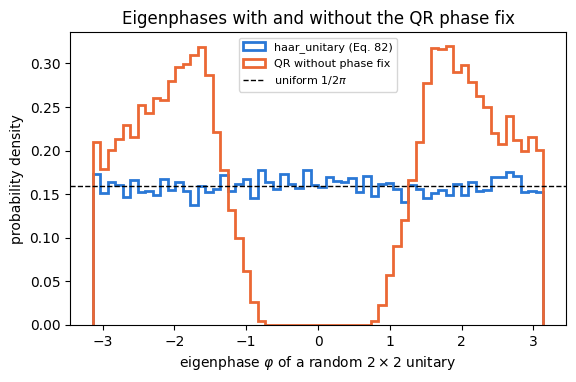

PASS  brickwall(N=2, depth=1) = one Haar gate            error  5.6e-17  tol   1e-08   mutant  4.3e-01


      half-chain entropy, N = 10, depth 10: [3.081 3.151 3.358 3.472]   mean 3.266   Page value Eq. (84): 4.2795


      half-chain entropy, N = 10, depth 40: [4.251 4.284 4.282 4.262]   mean 4.270   Page value Eq. (84): 4.2795
PASS  brickwall(N=10, depth 40): mean S_A = Page value (5 SE) error  9.7e-03  tol   3e-02
PASS  24 single-qubit Cliffords                          error  0.0e+00  tol   5e-01
PASS  C sigma C^dag is +-Pauli for all 24 x 3            error  0.0e+00  tol   5e-01   mutant  2.0e+00
PASS  Cliffords pairwise distinct up to a phase          error  0.0e+00  tol   5e-01
PASS  Cliffords closed under multiplication              error  0.0e+00  tol   5e-01


In [40]:
# ==============================================================================
# CHECKS: Haar unitaries, brick-wall circuits, Cliffords
# ==============================================================================
SECTION = "16"
U8 = np.asarray(haar_unitary(jax.random.PRNGKey(91), 8))
check("haar_unitary(8): U^dag U = 1", maxdiff(U8.conj().T @ U8, np.eye(8)), 100 * TOL)


def qr_without_phase_fix(key, d):
    """MUTANT: the QR factor of a Ginibre matrix without Eq. (82)."""
    k1, k2 = jax.random.split(key)
    G = (jax.random.normal(k1, (d, d)) + 1j * jax.random.normal(k2, (d, d))) / jnp.sqrt(2.0)
    return jnp.linalg.qr(G)[0]


n_u = 20000
kk = jax.random.split(jax.random.PRNGKey(92), n_u)
traces = {name: np.asarray(jnp.trace(jax.vmap(lambda k_: f(k_, 2))(kk), axis1=1, axis2=2))
          for name, f in [("haar_unitary", haar_unitary), ("QR without fix", qr_without_phase_fix)]}
for name, tr in traces.items():
    print(f"      {name:15s}: E[Tr U] = {tr.mean().real:+.4f}{tr.mean().imag:+.4f}i   E|Tr U|^2 = {np.mean(np.abs(tr) ** 2):.4f}")
tr = traces["haar_unitary"]
se_tr = np.abs(tr).std() / np.sqrt(n_u)
check("Haar d=2: |E[Tr U]| = 0 (5 SE)", abs(tr.mean()), 5 * se_tr, mutant=abs(traces["QR without fix"].mean()), mutant_factor=1)
se2 = (np.abs(tr) ** 2).std() / np.sqrt(n_u)
check("Haar d=2: E|Tr U|^2 = 1 (5 SE)", abs(np.mean(np.abs(tr) ** 2) - 1), 5 * se2,
      mutant=abs(np.mean(np.abs(traces["QR without fix"]) ** 2) - 1), mutant_factor=1)

fig, ax = plt.subplots(figsize=(6.4, 3.8))
for (name, f), c in zip([("haar_unitary (Eq. 82)", haar_unitary), ("QR without phase fix", qr_without_phase_fix)], PALETTE):
    phases = np.angle(np.linalg.eigvals(np.asarray(jax.vmap(lambda k_: f(k_, 2))(kk[:8000])))).ravel()
    ax.hist(phases, bins=60, range=(-np.pi, np.pi), density=True, histtype="step", lw=2, color=c, label=name)
ax.axhline(1 / (2 * np.pi), color="k", ls="--", lw=1, label=r"uniform $1/2\pi$")
ax.set_xlabel(r"eigenphase $\varphi$ of a random $2\times2$ unitary")
ax.set_ylabel(r"probability density")
ax.set_title("Eigenphases with and without the QR phase fix")
ax.legend(fontsize=8)
plt.show()

key_bw = jax.random.PRNGKey(93)
psi2 = as_tensor(rand_state(94, 2), 2)
_, k_gate = jax.random.split(key_bw, 2)                              # brickwall: key, *ks = split(key, #bonds + 1)
# structural check: it reuses haar_unitary (tested above) with the key that brickwall derives, and tests the bond placement
U_bw = np.asarray(haar_unitary(k_gate, 4))
check("brickwall(N=2, depth=1) = one Haar gate", maxdiff(brickwall(key_bw, psi2, 1), U_bw @ np.asarray(psi2).reshape(-1)), 100 * TOL,
      mutant=maxdiff(brickwall(key_bw, psi2, 1), U_bw.T @ np.asarray(psi2).reshape(-1)))   # transposed gate
m_dim = n_dim = 2 ** 5
S_page = (np.sum(1.0 / np.arange(n_dim + 1, m_dim * n_dim + 1)) - (m_dim - 1) / (2 * n_dim)) / np.log(2)
for depth in (10, 40):
    S_bw = np.array([float(entanglement_entropy(brickwall(k_, zero_state(10), depth), range(5)))
                     for k_ in jax.random.split(jax.random.PRNGKey(95), 4)])
    print(f"      half-chain entropy, N = 10, depth {depth:2d}: {np.round(S_bw, 3)}   mean {S_bw.mean():.3f}   Page value Eq. (84): {S_page:.4f}")
check("brickwall(N=10, depth 40): mean S_A = Page value (5 SE)", abs(S_bw.mean() - S_page), 5 * S_bw.std() / np.sqrt(len(S_bw)))

Cl = np.asarray(single_qubit_cliffords())
paulis_pm = [s * P for P in (NP_X, NP_Y, NP_Z) for s in (1, -1)]
is_pauli = lambda M: any(maxdiff(M, P) < 1e3 * TOL for P in paulis_pm)
check("24 single-qubit Cliffords", abs(len(Cl) - 24), 0.5)
check("C sigma C^dag is +-Pauli for all 24 x 3", sum(not is_pauli(C @ P @ C.conj().T) for C in Cl for P in (NP_X, NP_Y, NP_Z)), 0.5,
      mutant=sum(not is_pauli(M @ P @ M.conj().T) for M in [np.asarray(T)] for P in (NP_X, NP_Y, NP_Z)), mutant_factor=1)
overl = np.abs(np.einsum("iab,jab->ij", Cl.conj(), Cl)) / 2                 # |Tr(C_i^dag C_j)|/2 = 1 iff equal up to phase
check("Cliffords pairwise distinct up to a phase", np.sum(overl > 1 - 1e3 * TOL) - 24, 0.5)
closed = all(np.max(np.abs(np.einsum("iab,ab->i", Cl.conj(), A @ B))) / 2 > 1 - 1e3 * TOL for A in Cl for B in Cl)
check("Cliffords closed under multiplication", 0.0 if closed else 1.0, 0.5)

With the phase fix the trace of a random $2\times2$ unitary has mean zero and second moment one, as Eq. (83) requires, and the eigenphases are uniformly
distributed. Without the fix the QR factor has a strongly biased trace, and its eigenphases avoid a wide window around $\varphi=0$. These matrices are unitary but far from Haar distributed.
The brick-wall circuit is reproduced gate by gate for $N=2$, and for $N=10$ it brings the half-chain entanglement from the product state to the Page value. After depth 10 the entropy is still
well below it, after depth 40 the mean of four circuits agrees with Eq. (84) within its statistical error.
The Clifford set has 24 elements that map every Pauli matrix to a Pauli matrix with a sign, are pairwise different and form a group; the $\hat T$ gate, the mutant, maps
$\hat X$ to $(\hat X+\hat Y)/\sqrt2$.

### 16.3 Classical shadows from random Pauli measurements

A classical shadow (Huang, Kueng and Preskill) is collected by measuring every qubit in a basis $\hat X$, $\hat Y$ or $\hat Z$ chosen uniformly at random. For one qubit and one basis
$\hat P$ with eigenprojectors $\hat\Pi_\pm=\tfrac12(\mathbb{1}\pm\hat P)$, the measured projector, averaged over the outcomes, is

$$ \sum_\pm\mathrm{Tr}\big(\hat\Pi_\pm\hat\rho\big)\,\hat\Pi_\pm=\sum_\pm\frac{1\pm\langle\hat P\rangle}{2}\,\frac{\mathbb{1}\pm\hat P}{2}=\frac{\mathbb{1}+\langle\hat P\rangle\hat P}{2}. $$

Averaging over the three bases and using $\sum_P\langle\hat P\rangle\hat P=2\hat\rho-\mathbb{1}$ (the Bloch form of $\hat\rho$) defines the measurement channel $\mathcal M$ and its inverse:

$$ \mathcal M(\hat\rho)=\frac{\mathbb{1}}{2}+\frac{2\hat\rho-\mathbb{1}}{6}=\frac{\hat\rho+\mathbb{1}}{3}, \qquad \mathcal M^{-1}(\hat A)=3\hat A-\mathrm{Tr}(\hat A)\,\mathbb{1}. \tag{85} $$

Applying $\mathcal M^{-1}$ to the measured projector $\hat U^\dagger\vert b\rangle\langle b\vert\hat U$ of each qubit gives a snapshot whose average is the state,

$$ \hat\rho_{\mathrm{snap}}=\bigotimes_{q}\Big(3\,\hat U_q^\dagger\vert b_q\rangle\langle b_q\vert\hat U_q-\mathbb{1}\Big), \qquad \mathbb{E}\big[\hat\rho_{\mathrm{snap}}\big]=\hat\rho . \tag{86} $$

For a Pauli string the trace with each factor is $3(-1)^{b_q}$ if the measured basis equals the Pauli factor on that qubit and 0 otherwise (the identity part is
traceless against a Pauli matrix), so the single-snapshot estimator is

$$ \hat o=\prod_{q\in\mathrm{supp}(P)}3\,\delta_{\mathrm{basis}_q,P_q}\,(-1)^{b_q} . \tag{87} $$

### 16.4 Stabilizer Rényi entropy

The stabilizer Rényi entropy (Leone, Oliviero and Hamma) measures how far a state is from the stabilizer states, the states reachable by Clifford circuits:

$$ M_\alpha=\frac{1}{1-\alpha}\log_2\Big(\frac{1}{2^N}\sum_{P}\langle\hat P\rangle^{2\alpha}\Big), \tag{88} $$

with the sum over all $4^N$ Pauli strings and $\langle\hat P\rangle^{2\alpha}$ understood as $\vert\langle\hat P\rangle\vert^{2\alpha}$. Every Pauli string is, up to a phase $i^{a\cdot b}$ that makes it Hermitian, a product
$\hat X^{a}\hat Z^{b}$ with bit strings $a,b$, where $\hat Z^b\vert s\rangle=(-1)^{b\cdot s}\vert s\rangle$ and $\hat X^a\vert s\rangle=\vert s\oplus a\rangle$. Hence

$$ \langle\psi\vert\hat X^a\hat Z^b\vert\psi\rangle=\sum_s(-1)^{b\cdot s}\,\psi^*[s\oplus a]\,\psi[s]=\sum_s(-1)^{b\cdot s}f_a[s], \qquad f_a[s]=\psi^*[s\oplus a]\,\psi[s] . \tag{89} $$

The sum over $s$ with the signs $(-1)^{b\cdot s}$ is the Walsh–Hadamard transform of $f_a$, which is the matrix $\big(\begin{smallmatrix}1&1\\1&-1\end{smallmatrix}\big)$ applied to every tensor axis.
One transform gives all $2^N$ values of $b$ at once, so the cost drops from $O(8^N)$ to $O(N\,4^N)$. Notebook 27 derives the method; notebook 24 treats classical shadows.

In [41]:
# ==============================================================================
# Functions of quantum_engine.py derived in this notebook
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
H = jnp.array([[1, 1], [1, -1]], dtype=CDTYPE) / jnp.sqrt(2.0)      # Hadamard: Z-basis <-> X-basis
S = jnp.array([[1, 0], [0, 1j]], dtype=CDTYPE)                      # phase gate, S^2 = Z
SDG = S.conj().T
PAULI = {"I": I2, "X": X, "Y": Y, "Z": Z}

# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def apply_pauli_string(psi, ops):
    """Apply a Pauli string P = P_0 x P_1 x ... to psi.
    `ops` is a dict {qubit: 'X'|'Y'|'Z'} or a string like 'XIZY' (one letter per qubit; 'I' skipped).
    N single-qubit einsums -- cost O(N 2^N) -- instead of one 2^N x 2^N matrix."""
    if isinstance(ops, str):
        ops = {q: p for q, p in enumerate(ops) if p != "I"}
    for q, p in ops.items():
        psi = apply_gate(psi, PAULI[p], [q])
    return psi

def expect_pauli_string(psi, ops):
    """<psi|P|psi> = <psi | (P psi)> : apply the string, then ONE inner product (jnp.vdot conjugates its
    first argument).  Works for strings of any weight, e.g. the N-body correlator <X X ... X>."""
    return jnp.real(jnp.vdot(psi, apply_pauli_string(psi, ops)))


# ----------------------------------------------------------------------------
# 6. Measurements (Born rule, collapse, sampling)
# ----------------------------------------------------------------------------
_BASIS_ROT = {"Z": I2, "X": H, "Y": H @ SDG}  # U maps the eigenbasis of the Pauli to |0>,|1>:  P = U^dag Z U

# ----------------------------------------------------------------------------
# 13. Classical shadows (random Pauli measurements)
# ----------------------------------------------------------------------------
def collect_pauli_shadows(key, psi, n_shadows):
    """Randomised-measurement data set (Huang, Kueng, Preskill 2020).
    Each snapshot: draw a basis b_q in {X,Y,Z} for every qubit, rotate, measure all qubits once.
    Returns (bases, bits), int arrays of shape (n_shadows, N); basis code 0=X, 1=Y, 2=Z.
    JAX: one snapshot is a pure function of its key  ->  `vmap` over keys gives all snapshots in parallel;
         `rots[bases[q]]` selects the rotation with a traced index (gather), so no Python branching."""
    N = psi.ndim
    rots = jnp.stack([_BASIS_ROT["X"], _BASIS_ROT["Y"], _BASIS_ROT["Z"]])

    def one(k):
        kb, ks = jax.random.split(k)
        bases = jax.random.randint(kb, (N,), 0, 3)
        phi = psi
        for q in range(N):
            phi = apply_gate(phi, rots[bases[q]], [q])
        logp = jnp.log(jnp.clip(jnp.abs(phi.reshape(-1)) ** 2, 1e-300, None))
        idx = jax.random.categorical(ks, logp)
        bits = (idx >> jnp.arange(N - 1, -1, -1)) & 1
        return bases, bits

    return jax.vmap(one)(jax.random.split(key, n_shadows))

def shadow_estimate_pauli(bases, bits, ops):
    """Estimate <P> of a Pauli string `ops` = {qubit: 'X'|'Y'|'Z'} from Pauli shadows.
        single-snapshot estimator   o = prod_{q in supp(P)}  3 * [b_q == P_q] * (-1)^{bit_q}
    (the factor 3 per qubit inverts the measurement channel; a snapshot contributes only if all its bases
    match on the support -- probability 3^{-k} -- hence variance ~ 3^k for weight-k strings).
    Returns (mean, standard error)."""
    code = {"X": 0, "Y": 1, "Z": 2}
    val = jnp.ones(bases.shape[0])
    for q, p in ops.items():
        val = val * 3.0 * (bases[:, q] == code[p]) * (1 - 2 * bits[:, q])
    return jnp.mean(val), jnp.std(val) / jnp.sqrt(val.shape[0])

def shadow_snapshot_dm(bases_row, bits_row):
    """Single-snapshot state estimate  rho_hat = (x)_q ( 3 U_q^dag |b_q><b_q| U_q - 1 )  (dense; small N).
    E[rho_hat] = rho: averaging snapshots reconstructs the state."""
    rots = [_BASIS_ROT["X"], _BASIS_ROT["Y"], _BASIS_ROT["Z"]]
    out = jnp.ones((1, 1), dtype=CDTYPE)
    for b, s in zip(np.asarray(bases_row), np.asarray(bits_row)):
        U = rots[int(b)]
        ket = U.conj().T[:, int(s)]
        out = jnp.kron(out, 3 * jnp.outer(ket, ket.conj()) - I2)
    return out


# ----------------------------------------------------------------------------
# 14. Stabilizer Renyi entropy ("magic") via the fast Walsh-Hadamard transform
# ----------------------------------------------------------------------------
def _wht_all_axes(f):
    """Unnormalised Walsh-Hadamard transform over all N binary axes:
        F[b] = sum_s (-1)^{b.s} f[s]
    In tensor language it is simply [[1,1],[1,-1]] applied to EVERY axis: N einsums, O(N 2^N)."""
    Hun = jnp.array([[1, 1], [1, -1]], dtype=f.dtype)
    for q in range(f.ndim):
        f = apply_gate(f, Hun, [q])
    return f

def stabilizer_renyi_entropy(psi, alpha=2, batch=256):
    """Stabilizer Renyi entropy  M_alpha = (1-alpha)^{-1} log2( sum_P <P>^{2 alpha} / 2^N )  (sum over 4^N Paulis).
    M = 0 iff stabilizer state; M > 0 quantifies non-Clifford resources ("magic").

    ALGORITHM   write P = i^{a.b} X^a Z^b (bit strings a,b).  Then
                    <P_{a,b}> = phase * sum_s (-1)^{b.s} psi^*[s XOR a] psi[s]  =  phase * WHT_b[ f_a ],
                f_a[s] = psi^*[s XOR a] psi[s].   One WHT yields all 2^N Z-patterns for a given X-pattern a
                => O(N 4^N) instead of O(8^N); |phase| = 1 drops out of <P>^{2 alpha}.
    JAX         vmap over a batch of X-patterns a (index XOR is a gather), python loop over batches to cap memory."""
    N = psi.ndim
    flat = psi.reshape(-1)
    idx = jnp.arange(2 ** N)

    def for_a(a):
        f = (jnp.conj(flat[idx ^ a]) * flat).reshape((2,) * N)
        return jnp.sum(jnp.abs(_wht_all_axes(f)) ** (2 * alpha))

    total = 0.0
    fa = jax.jit(jax.vmap(for_a))
    for start in range(0, 2 ** N, batch):
        total = total + jnp.sum(fa(idx[start:start + batch]))
    return jnp.log2(total / 2 ** N) / (1 - alpha)

def stabilizer_renyi_entropy_bruteforce(psi, alpha=2):
    """The definition, literally: loop over all 4^N Pauli strings (tiny N only).  Used to validate the WHT version."""
    import itertools
    N = psi.ndim
    tot = 0.0
    for s in itertools.product("IXYZ", repeat=N):
        tot += abs(float(expect_pauli_string(psi, "".join(s)))) ** (2 * alpha)   # (<P>^2)^alpha = |<P>|^(2 alpha): abs matters for non-integer alpha
    return float(np.log2(tot / 2 ** N) / (1 - alpha))


The snapshot formula (86) is tested exactly: for two qubits we enumerate all nine basis pairs and all four outcomes with their exact Born probabilities from
dense matrices and sum the engine snapshots with these weights. The mutant omits the $-\mathbb{1}$ of Eq. (86). The estimator (87) is tested statistically with 30000
snapshots. The magic checks compare the fast transform with `scipy.linalg.hadamard`, the entropy with an independent NumPy sum over all $4^N$ Kronecker-product
Pauli strings, the single-qubit value $M_2=\log_2(4/3)$ of $\hat T\vert +\rangle$ (from Eq. (88) with $\langle\hat X\rangle=\langle\hat Y\rangle=1/\sqrt2$, $\langle\hat Z\rangle=0$), and $M_2=0$ for the cluster state.

In [42]:
# ==============================================================================
# CHECKS: classical shadows and stabilizer Renyi entropy
# ==============================================================================
v2 = rand_state(101, 2)
rho_v2 = np.outer(v2, v2.conj())
rot_np = [U_basis["X"], U_basis["Y"], U_basis["Z"]]                  # basis code 0 = X, 1 = Y, 2 = Z
avg, avg_mut = np.zeros((4, 4), complex), np.zeros((4, 4), complex)
for b0, b1 in itertools.product(range(3), repeat=2):
    Ub = np.kron(rot_np[b0], rot_np[b1])
    probs_b = np.abs(Ub @ v2) ** 2
    for s_idx in range(4):
        bits_row = [s_idx >> 1, s_idx & 1]
        avg += probs_b[s_idx] / 9 * np.asarray(shadow_snapshot_dm(np.array([b0, b1]), np.array(bits_row)))
        kets = [rot_np[b].conj().T[:, s] for b, s in zip((b0, b1), bits_row)]
        avg_mut += probs_b[s_idx] / 9 * kron_all([3 * np.outer(k_, k_.conj()) for k_ in kets])
check("shadow snapshots average exactly to rho, Eq. (86)", maxdiff(avg, rho_v2), 100 * TOL, mutant=maxdiff(avg_mut, rho_v2))

N = 4
v4 = rand_state(102, N)
bases_s, bits_s = collect_pauli_shadows(jax.random.PRNGKey(103), as_tensor(v4, N), 30000)
for ops in [{0: "X", 2: "Z"}, {1: "Y", 3: "Y"}, {2: "Z"}]:
    est, se_s = shadow_estimate_pauli(bases_s, bits_s, ops)
    Pd = kron_all([{"X": NP_X, "Y": NP_Y, "Z": NP_Z}[ops[q]] if q in ops else NP_I for q in range(N)])
    exact = (v4.conj() @ Pd @ v4).real
    print(f"      shadow estimate of {ops}: {float(est):+.4f} +- {float(se_s):.4f}   exact {exact:+.4f}")
    check(f"shadow_estimate_pauli {ops} (5 SE)", abs(est - exact), 5 * se_s)

f_test = rand_state(104, 4)
check("_wht_all_axes vs scipy.linalg.hadamard", maxdiff(_wht_all_axes(as_tensor(f_test, 4)), sla.hadamard(16) @ f_test), 100 * TOL)


def sre_numpy(v, N, alpha):
    """Eq. (88) by brute force with Kronecker-product Pauli strings (independent of the engine)."""
    tot = sum(abs(np.vdot(v, kron_all([NP_PAULIS[i] for i in idx]) @ v)) ** (2 * alpha)
              for idx in itertools.product(range(4), repeat=N))
    return np.log2(tot / 2 ** N) / (1 - alpha)


v3 = rand_state(105, 3)
for alpha in (2, 0.5):
    check(f"stabilizer_renyi_entropy (alpha={alpha}) vs NumPy brute force", abs(stabilizer_renyi_entropy(as_tensor(v3, 3), alpha=alpha) - sre_numpy(v3, 3, alpha)), 1e3 * TOL)
check("stabilizer_renyi_entropy_bruteforce = fast version", abs(stabilizer_renyi_entropy_bruteforce(as_tensor(v3, 3)) - stabilizer_renyi_entropy(as_tensor(v3, 3))), 1e3 * TOL)
check("M_2(T|+>) = log2(4/3)", abs(stabilizer_renyi_entropy(apply_gate(product_state("+"), T, [0])) - np.log2(4 / 3)), 1e3 * TOL,
      mutant=abs(stabilizer_renyi_entropy(product_state("+")) - np.log2(4 / 3)))
check("M_2(cluster state, N=5) = 0", abs(stabilizer_renyi_entropy(cluster_state(5))), 1e3 * TOL)

PASS  shadow snapshots average exactly to rho, Eq. (86)  error  5.0e-16  tol   1e-08   mutant  2.1e+00


      shadow estimate of {0: 'X', 2: 'Z'}: -0.0690 +- 0.0175   exact -0.0789
PASS  shadow_estimate_pauli {0: 'X', 2: 'Z'} (5 SE)      error  9.9e-03  tol   9e-02
      shadow estimate of {1: 'Y', 3: 'Y'}: -0.2226 +- 0.0174   exact -0.2134
PASS  shadow_estimate_pauli {1: 'Y', 3: 'Y'} (5 SE)      error  9.2e-03  tol   9e-02
      shadow estimate of {2: 'Z'}: +0.0326 +- 0.0100   exact +0.0424
PASS  shadow_estimate_pauli {2: 'Z'} (5 SE)              error  9.8e-03  tol   5e-02
PASS  _wht_all_axes vs scipy.linalg.hadamard             error  3.1e-16  tol   1e-08
PASS  stabilizer_renyi_entropy (alpha=2) vs NumPy brute force error  4.4e-16  tol   1e-07
PASS  stabilizer_renyi_entropy (alpha=0.5) vs NumPy brute force error  8.9e-16  tol   1e-07


PASS  stabilizer_renyi_entropy_bruteforce = fast version error  2.2e-16  tol   1e-07
PASS  M_2(T|+>) = log2(4/3)                              error  1.3e-15  tol   1e-07   mutant  4.2e-01


PASS  M_2(cluster state, N=5) = 0                        error  5.0e-15  tol   1e-07


The exact average of the engine snapshots over all bases and outcomes reproduces the two-qubit state to round-off, which verifies Eq. (86) without statistical
noise, while snapshots without the $-\mathbb{1}$ do not average to the state. The Pauli estimates from 30000 snapshots agree with the exact values within their
standard errors; the weight-2 strings have larger errors than the weight-1 string because only one snapshot in nine matches both bases. The Walsh–Hadamard
transform and both versions of the stabilizer entropy agree with independent NumPy computations; the $\hat T$ state carries $\log_2(4/3)\approx0.415$ bits of magic and the
stabilizer state $\vert +\rangle$, the mutant, carries none, as does the cluster state.

## 17. Variational tools

### 17.1 Hardware-efficient ansatz

The hardware-efficient ansatz (in the spirit of Kandala *et al.* 2017: layers of single-qubit rotations alternating with fixed entangling gates) with $L$ entangling layers is

$$ \vert\psi(\boldsymbol\theta)\rangle=\hat R(\boldsymbol\theta_L)\prod_{l=0}^{L-1}\Big[\hat E\,\hat R(\boldsymbol\theta_l)\Big]\vert 0\dots0\rangle, \qquad \hat R(\boldsymbol\theta_l)=\prod_q\hat R_z(\theta_{l,q,1})\,\hat R_y(\theta_{l,q,0}), \tag{90} $$

where the product over layers is ordered with $l=0$ acting first, $\hat E$ is a chain of CZ gates on the bonds $(q,q+1)$, and the parameter vector has $2N(L+1)$ entries (`hea_num_params`).

### 17.2 Parameter-shift rule

The parameter-shift rule (Mitarai *et al.* 2018; Schuld *et al.* 2019) follows from the form of the gate. Let one gate depend on $\theta$ as $\hat R(\theta)=e^{-i\theta\hat P/2}=\cos\tfrac\theta2\,\mathbb{1}-i\sin\tfrac\theta2\,\hat P$ (Eq. 12), with the rest of the circuit fixed. The cost $f(\theta)=\langle\hat O\rangle$ is a
quadratic form in $\cos\tfrac\theta2$ and $\sin\tfrac\theta2$, so with constants $A$, $B$, $C$ that depend on the rest of the circuit

$$ \begin{aligned} f(\theta) &= A\cos^2\tfrac\theta2+B\sin^2\tfrac\theta2+C\sin\tfrac\theta2\cos\tfrac\theta2=\frac{A+B}{2}+\frac{A-B}{2}\cos\theta+\frac C2\sin\theta, \\ f\big(\theta+\tfrac\pi2\big)-f\big(\theta-\tfrac\pi2\big) &= \frac{A-B}{2}\big(-2\sin\theta\big)+\frac C2\big(2\cos\theta\big)=2f'(\theta). \end{aligned} \tag{91} $$

The shifted evaluations give the exact derivative, which a quantum computer can measure with two circuits per parameter. The rule requires each parameter to appear in a single gate of this form.

### 17.3 SPSA and Adam

Simultaneous-perturbation stochastic approximation (SPSA, Spall) perturbs all parameters at once along a random vector $\boldsymbol\Delta$ with independent entries $\pm1$:

$$ \boldsymbol g=\frac{f(\boldsymbol\theta+c\boldsymbol\Delta)-f(\boldsymbol\theta-c\boldsymbol\Delta)}{2c}\,\boldsymbol\Delta, \qquad \mathbb{E}[\boldsymbol g]=\mathbb{E}\big[\boldsymbol\Delta\boldsymbol\Delta^T\big]\nabla f+O(c^2)=\nabla f+O(c^2), \tag{92} $$

where the Taylor expansion $f(\boldsymbol\theta\pm c\boldsymbol\Delta)=f\pm c\,\boldsymbol\Delta\cdot\nabla f+\tfrac{c^2}{2}\boldsymbol\Delta^T\nabla^2f\,\boldsymbol\Delta\pm O(c^3)$ and $\mathbb{E}[\Delta_k\Delta_l]=\delta_{kl}$ were used. Two
evaluations per step suffice, whatever the number of parameters. Adam (Kingma and Ba) keeps exponential averages of the gradient and of its square and corrects their bias towards zero at early steps:

$$ \begin{aligned} m_t &= \beta_1m_{t-1}+(1-\beta_1)\,g_t, \qquad v_t=\beta_2v_{t-1}+(1-\beta_2)\,g_t^2, \\ \theta_t &= \theta_{t-1}-\eta\,\frac{m_t/(1-\beta_1^t)}{\sqrt{v_t/(1-\beta_2^t)}+\epsilon} . \end{aligned} \tag{93} $$

Notebooks 40–42 derive and compare these tools.

In [43]:
# ==============================================================================
# Functions of quantum_engine.py derived in this notebook
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
CZ = jnp.diag(jnp.array([1, 1, 1, -1], dtype=CDTYPE))
def ry(theta):
    """Rotation about y:  Ry(theta) = exp(-i theta Y/2) = [[cos, -sin], [sin, cos]](theta/2)  (real matrix)."""
    c, s = jnp.cos(theta / 2), jnp.sin(theta / 2)
    return jnp.array([[c, -s], [s, c]], dtype=CDTYPE)

def rz(theta):
    """Rotation about z:  Rz(theta) = exp(-i theta Z/2) = diag(e^{-i theta/2}, e^{+i theta/2})."""
    e = jnp.exp(-0.5j * theta)
    return jnp.array([[e, 0], [0, jnp.conj(e)]], dtype=CDTYPE)


# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
def zero_state(N):
    """|00...0>: a rank-N tensor of zeros with a single 1 at index (0,0,...,0).
    JAX arrays are immutable: `.at[idx].set(v)` returns an updated COPY (functional style)."""
    return jnp.zeros((2,) * N, dtype=CDTYPE).at[(0,) * N].set(1.0)


# ----------------------------------------------------------------------------
# 15. Variational circuits: ansatz, gradients, optimizers
# ----------------------------------------------------------------------------
def hea_num_params(N, layers):
    """Number of angles of `hardware_efficient_ansatz`: (layers+1) rotation blocks x N qubits x 2 angles."""
    return 2 * N * (layers + 1)

def hardware_efficient_ansatz(theta, N, layers, entangler=CZ, periodic=False):
    """Hardware-efficient ansatz
        |psi(theta)> = R(theta_L) * prod_{l<L} [ ENT * R(theta_l) ] |0...0>,   R = prod_q Rz(.) Ry(.),
    ENT = a chain of CZ (or any 2-qubit gate).  `theta` is a flat vector of length 2N(L+1).
    The function is a pure map theta -> state, hence jit-able and differentiable end to end."""
    theta = theta.reshape(layers + 1, N, 2)
    psi = zero_state(N)
    for l in range(layers + 1):
        for q in range(N):
            psi = apply_gate(psi, ry(theta[l, q, 0]), [q])
            psi = apply_gate(psi, rz(theta[l, q, 1]), [q])
        if l < layers:
            for q in range(N - 1):
                psi = apply_gate(psi, entangler, [q, q + 1])
            if periodic and N > 2:
                psi = apply_gate(psi, entangler, [N - 1, 0])
    return psi

def parameter_shift_grad(f, theta, shift=jnp.pi / 2):
    """Parameter-shift rule: for gates exp(-i theta_k P/2) with P^2 = 1 the cost is a sinusoid in theta_k,
        f = a + b cos(theta_k) + c sin(theta_k),   so for any shift s with sin(s) != 0
        d f / d theta_k = [ f(theta + s e_k) - f(theta - s e_k) ] / (2 sin s)          (EXACT, not finite differences)
    and the default s = pi/2 gives the familiar [ f(+pi/2) - f(-pi/2) ] / 2.
    -- the gradient a real quantum computer can measure: 2 circuit evaluations per parameter.
    JAX: vmap over the unit vectors e_k evaluates all shifted circuits in one batched call."""
    eye = jnp.eye(theta.size).reshape((theta.size,) + theta.shape)
    denom = 2 * jnp.sin(shift)
    return jax.vmap(lambda e: (f(theta + shift * e) - f(theta - shift * e)) / denom)(eye).reshape(theta.shape)

def spsa_grad(key, f, theta, c=0.1):
    """SPSA gradient estimate (Spall 1992): perturb ALL parameters at once along a random +-1 direction Delta,
        g = [f(theta + c Delta) - f(theta - c Delta)] / (2c) * Delta        (Delta_k^{-1} = Delta_k)
    Two evaluations regardless of the number of parameters; unbiased up to O(c^2); noisy but cheap --
    the method of choice for shot-noise-limited / stochastic cost functions."""
    delta = jax.random.rademacher(key, theta.shape).astype(theta.dtype)
    return (f(theta + c * delta) - f(theta - c * delta)) / (2 * c) * delta

def adam_init(theta):
    """Adam state: (first moment m, second moment v, step counter t)."""
    return (jnp.zeros_like(theta), jnp.zeros_like(theta), 0)

def adam_update(theta, g, state, lr=0.05, b1=0.9, b2=0.999, eps=1e-8):
    """One Adam step (Kingma & Ba):  m <- b1 m + (1-b1) g,  v <- b2 v + (1-b2) g^2,
        theta <- theta - lr * m_hat / (sqrt(v_hat) + eps),   hats = bias-corrected moments.
    Momentum (m) averages noisy gradients (great with SPSA); v gives a per-parameter step size."""
    m, v, t = state
    t = t + 1
    m = b1 * m + (1 - b1) * g
    v = b2 * v + (1 - b2) * g ** 2
    theta = theta - lr * (m / (1 - b1 ** t)) / (jnp.sqrt(v / (1 - b2 ** t)) + eps)
    return theta, (m, v, t)


In [44]:
# ==============================================================================
# CHECKS: variational tools
# ==============================================================================
SECTION = "17"
N, layers = 3, 2
n_par = hea_num_params(N, layers)
theta_v = jax.random.uniform(jax.random.PRNGKey(111), (n_par,), minval=-np.pi, maxval=np.pi, dtype=RDTYPE)
th_np = np.asarray(theta_v).reshape(layers + 1, N, 2)
CZ_np = np.diag([1, 1, 1, -1]).astype(complex)


def hea_numpy(th, ry_first=True):
    """Eq. (90) with scipy expm rotations and Kronecker embeddings.  ry_first=False builds the mutant (Rz before Ry)."""
    vv = np.eye(2 ** N)[0].astype(complex)
    for l in range(layers + 1):
        for q in range(N):
            Ry_, Rz_ = sla.expm(-0.5j * th[l, q, 0] * NP_Y), sla.expm(-0.5j * th[l, q, 1] * NP_Z)
            first, second = (Ry_, Rz_) if ry_first else (Rz_, Ry_)
            vv = embed_dense(second, [q], N) @ (embed_dense(first, [q], N) @ vv)
        if l < layers:
            for q in range(N - 1):
                vv = embed_dense(CZ_np, [q, q + 1], N) @ vv
    return vv


check(f"hea_num_params(3, 2) = 2 N (L+1) = 18", abs(n_par - 18), 0.5)
check("hardware_efficient_ansatz vs NumPy circuit, Eq. (90)", maxdiff(hardware_efficient_ansatz(theta_v, N, layers), hea_numpy(th_np)), 100 * TOL,
      mutant=maxdiff(hardware_efficient_ansatz(theta_v, N, layers), hea_numpy(th_np, ry_first=False)))
terms_v = heisenberg_terms(N, 1.0, 1.0, 1.0, hx=0.4)
cost = jax.jit(lambda th: energy(terms_v, hardware_efficient_ansatz(th, N, layers)))
g_auto = np.asarray(jax.grad(cost)(theta_v))
g_shift = np.asarray(parameter_shift_grad(cost, theta_v))
h_fd = 1e-5 if PRECISION == "double" else 1e-2                         # step of the central difference
tol_fd = 1e-7 if PRECISION == "double" else 1e-2                       # its truncation + round-off error
g_fd = np.array([(float(cost(theta_v.at[k].add(h_fd))) - float(cost(theta_v.at[k].add(-h_fd)))) / (2 * h_fd) for k in range(n_par)])
check("parameter_shift_grad vs central finite differences", maxdiff(g_shift, g_fd), tol_fd,
      mutant=maxdiff(np.sin(np.pi / 4) * parameter_shift_grad(cost, theta_v, shift=np.pi / 4), g_fd))   # mutant: shift pi/4 but the pi/2 denominator 2
check("parameter_shift_grad = jax.grad", maxdiff(g_shift, g_auto), 1e3 * TOL)

n_spsa = 20000
g_spsa = np.asarray(jax.vmap(lambda k_: spsa_grad(k_, cost, theta_v, c=0.01))(jax.random.split(jax.random.PRNGKey(112), n_spsa)))
z_spsa = np.abs(g_spsa.mean(0) - g_auto) / (g_spsa.std(0) / np.sqrt(n_spsa))
print(f"      SPSA: mean over {n_spsa} draws, largest |z| over {n_par} components = {z_spsa.max():.2f}")
g_mut = 2 * g_spsa                                                    # mutant: difference quotient divided by c instead of 2c
z_mut = np.abs(g_mut.mean(0) - g_auto) / (g_mut.std(0) / np.sqrt(n_spsa))
check("spsa_grad is unbiased (max |z| over 18 components)", z_spsa.max(), 5.0, mutant=z_mut.max(), mutant_factor=1)


def adam_numpy(theta, grad_fn, steps, lr=0.05, b1=0.9, b2=0.999, eps=1e-8, bias_correction=True):
    """Eq. (93) in plain NumPy (independent reference).  bias_correction=False builds the mutant."""
    m, v_ = np.zeros_like(theta), np.zeros_like(theta)
    for t in range(1, steps + 1):
        g = grad_fn(theta)
        m = b1 * m + (1 - b1) * g
        v_ = b2 * v_ + (1 - b2) * g ** 2
        mh, vh = (m / (1 - b1 ** t), v_ / (1 - b2 ** t)) if bias_correction else (m, v_)
        theta = theta - lr * mh / (np.sqrt(vh) + eps)
    return theta


a_q, b_q = np.array([1.0, 3.0, 0.5]), np.array([0.3, -1.2, 2.0])
grad_q = lambda th: 2 * a_q * (th - b_q)                                # gradient of sum_i a_i (th_i - b_i)^2
th_e, st = jnp.zeros(3, dtype=RDTYPE), adam_init(jnp.zeros(3, dtype=RDTYPE))
for _ in range(30):
    th_e, st = adam_update(th_e, jnp.asarray(grad_q(np.asarray(th_e))), st)
check("adam_update: 30 steps vs NumPy Adam, Eq. (93)", maxdiff(th_e, adam_numpy(np.zeros(3), grad_q, 30)), 100 * TOL,
      mutant=maxdiff(th_e, adam_numpy(np.zeros(3), grad_q, 30, bias_correction=False)))

PASS  hea_num_params(3, 2) = 2 N (L+1) = 18              error  0.0e+00  tol   5e-01


PASS  hardware_efficient_ansatz vs NumPy circuit, Eq. (90) error  2.2e-16  tol   1e-08   mutant  8.5e-01


PASS  parameter_shift_grad vs central finite differences error  7.3e-11  tol   1e-07   mutant  5.5e-01
PASS  parameter_shift_grad = jax.grad                    error  9.6e-16  tol   1e-07


      SPSA: mean over 20000 draws, largest |z| over 18 components = 1.77
PASS  spsa_grad is unbiased (max |z| over 18 components) error  1.8e+00  tol   5e+00   mutant  6.3e+01


PASS  adam_update: 30 steps vs NumPy Adam, Eq. (93)      error  0.0e+00  tol   1e-08   mutant  3.2e-01


The ansatz matches the NumPy circuit built from `scipy.linalg.expm` rotations, and the mutant with the two rotations exchanged differs by order one. The
parameter-shift gradient agrees with central finite differences to $10^{-10}$ (the finite-difference error) and with `jax.grad` to round-off, while a shift of $\pi/4$ is
wrong. The SPSA estimate is unbiased within its statistical error, and the engine's Adam reproduces the NumPy implementation of Eq. (93) exactly; the version without bias
correction ends elsewhere. Its first steps are larger: with $m_1=(1-\beta_1)g_1$ and $v_1=(1-\beta_2)g_1^2$ the uncorrected ratio $m_1/\sqrt{v_1}=0.1/\sqrt{0.001}\approx3.2$
multiplies the step size $\eta$, while the corrected ratio is exactly $\pm1$; the bias correction is what makes $\eta$ the size of the early steps.

## 18. Matrix product states: the ingredients

The last part of the engine leaves the state vector. A matrix product state (MPS) writes the $2^N$ amplitudes as a product of $N$ small matrices, one per site and per
value of its spin,

$$ \psi[s_0,s_1,\dots,s_{N-1}]=A_0^{s_0}A_1^{s_1}\cdots A_{N-1}^{s_{N-1}}, \qquad A_j^{s}\ \text{of size}\ \chi_j\times\chi_{j+1},\quad \chi_0=\chi_N=1 . \tag{94} $$

Notebook 18 (Chapter 7) derives the construction, DMRG (White 1992) and TEBD (Vidal 2004) in full (review: Schollwöck 2011); this section shows the ingredients and checks each against the state vector. The
construction by successive singular value decompositions produces tensors with one of the two canonical properties

$$ \sum_s A_j^{s\dagger}A_j^{s}=\mathbb{1}\quad\text{(left-canonical)}, \qquad \sum_s B_j^{s}B_j^{s\dagger}=\mathbb{1}\quad\text{(right-canonical)} . \tag{95} $$

With all tensors to the right of a cut right-canonical, the bond matrices at the cut carry the Schmidt values $\lambda$ of Eq. (39). Keeping only the $\chi$ largest of them
(truncation) discards the weight

$$ \varepsilon=\frac{\sum_{k\ge\chi}\lambda_k^2}{\sum_k\lambda_k^2}. \tag{96} $$

The engine stores an MPS in a padded format of fixed shape, which `jit`, `vmap` and `scan` require: `B` of shape `(N, chi, 2, chi)` with right-canonical tensors, and `lam` of
shape `(N+1, chi)`, where `lam[j]` holds the Schmidt values of the cut to the left of site $j$, padded with zeros where the Schmidt rank is smaller than $\chi$. Rows of `B` that
belong to a zero Schmidt value never contribute to the state; they are zero when the MPS comes straight from an untruncated sweep, and arbitrary orthonormal completions after the
recanonicalisation of Section 18.3. The conversion functions below are validation tools for small $N$ ($O(2^N\chi^2)$ work). `state_to_mps` sweeps from the right; when it truncates,
it passes its result through `mps_recanonicalise` (Section 18.3), because a truncation at cut $j-1$ changes the Schmidt values already recorded at cut $j$.

In [45]:
# ==============================================================================
# Functions of quantum_engine.py derived in this notebook
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
S = jnp.array([[1, 0], [0, 1j]], dtype=CDTYPE)                      # phase gate, S^2 = Z

# ----------------------------------------------------------------------------
# 15. Variational circuits: ansatz, gradients, optimizers
# ----------------------------------------------------------------------------
_SPIN_MPS = {"0": [1, 0], "1": [0, 1], "+": [1, 1], "-": [1, -1]}      # same characters as product_state
LAM_CUT = 100 * float(jnp.finfo(RDTYPE).eps)                           # Schmidt values below this are padding
def state_to_mps_left(psi, cut=1e-13):
    """Exact left-canonical MPS of a state tensor psi[s_0..s_{N-1}].

    MATH
        psi = A[0]^{s_0} A[1]^{s_1} ... A[N-1]^{s_{N-1}},   A[j] has shape (chi_j, 2, chi_{j+1}), chi_0 = chi_N = 1.
        Sweep j = 0..N-2:   R (chi_j * 2, rest)  = U S V^dag ;  A[j] = U ;  R <- S V^dag.
    IMPLEMENTATION
        NumPy, because every iteration has a different shape.  Singular values below `cut` are dropped, so
        chi_{j+1} equals the Schmidt rank of the cut between sites j and j+1.
    RETURNS   (list of A tensors, list of the Schmidt-value arrays of the N-1 cuts)
    COST      dominated by the first SVDs: O(2^N * chi^2) -- this is a conversion tool for SMALL N only.
    """
    psi = np.asarray(psi)
    N = psi.ndim
    tensors, schmidt = [], []
    R, chi = psi.reshape(1, -1), 1                         # remainder, with a dummy left bond of dimension 1
    for j in range(N - 1):
        M = R.reshape(chi * 2, -1)                         # rows: (a_j, s_j)   columns: (s_{j+1}, ..., s_{N-1})
        U, S, Vh = np.linalg.svd(M, full_matrices=False)
        keep = max(1, int(np.sum(S > cut)))                # numerical Schmidt rank
        tensors.append(U[:, :keep].reshape(chi, 2, keep))  # A[j][a_j, s_j, a_{j+1}]
        schmidt.append(S[:keep])
        R, chi = S[:keep, None] * Vh[:keep], keep          # remainder  S V^dag
    tensors.append(R.reshape(chi, 2, 1))                   # the last remainder is the last tensor
    return tensors, schmidt

def mps_list_to_state(tensors):
    """Contract a list of rank-3 tensors back into the state tensor (validation only: O(2^N) memory).
    MATH   Eq. (1): the bond legs are summed.  `tensordot(.., axes=([-1],[0]))` ties the last leg of what we
    have so far to the first leg of the next tensor."""
    psi = tensors[0]
    for A in tensors[1:]:
        psi = np.tensordot(psi, A, axes=([-1], [0]))
    return psi[0, ..., 0]                                  # strip the two dummy boundary legs

def state_to_mps(psi, chi, cut=1e-13):
    """State tensor -> right-canonical MPS with bond dimension <= chi, stored in fixed-shape padded arrays.

    MATH
        psi ~ B[0]^{s_0} B[1]^{s_1} ... B[N-1]^{s_{N-1}},    sum_s B^s B^s^dag = 1  (right-canonical, Eq. 3)
        Sweep j = N-1..1:   R (rest, 2*chi_{j+1}) = U S V^dag ;  B[j] = V^dag (first chi rows) ;
                            lam[j] = S[:chi]/||S[:chi]|| ;  eps[j] = sum_{k>=chi} S_k^2 / sum_k S_k^2 ;  R <- U S.
    RETURNS
        B    complex array (N, chi, 2, chi)   B[j][a, s, b]; unused entries are exactly zero if nothing is truncated
        lam  real array    (N+1, chi)         Schmidt values of the cut left of site j; lam[0]=lam[N]=(1,0,..)
        eps  real array    (N+1,)             discarded weight at every cut
    TRUNCATION  lam[j] is recorded when cut j is truncated, but truncating cut j-1 afterwards changes the left
        block of cut j, so the recorded values are not the Schmidt values of the stored state.  Whenever anything
        was discarded (some eps > 0), the result is therefore passed through `mps_recanonicalise`, and the returned
        lam are the exact Schmidt values of the returned (truncated, renormalised) state on every cut.  eps keeps the
        weights discarded by the sweep.  Without truncation the sweep is exact and is returned as it is.
    COST   O(2^N chi^2): conversion tool for small N (validation, initial states from exact methods).
    """
    psi = np.asarray(psi)
    N = psi.ndim
    B = np.zeros((N, chi, 2, chi), dtype=psi.dtype)
    lam = np.zeros((N + 1, chi))
    eps = np.zeros(N + 1)
    lam[0, 0] = lam[N, 0] = 1.0
    R, r = psi.reshape(-1, 1), 1                           # remainder with a dummy right bond of dimension 1
    for j in range(N - 1, 0, -1):
        M = R.reshape(-1, 2 * r)                           # rows: (s_0..s_{j-1})   columns: (s_j, b_{j+1})
        U, S, Vh = np.linalg.svd(M, full_matrices=False)
        keep = max(1, min(chi, int(np.sum(S > cut))))
        eps[j] = np.sum(S[keep:] ** 2) / np.sum(S ** 2)
        S = S[:keep] / np.linalg.norm(S[:keep])            # truncate + renormalise
        B[j, :keep, :, :r] = Vh[:keep].reshape(keep, 2, r)
        lam[j, :keep] = S
        R, r = U[:, :keep] * S[None, :], keep              # remainder  U S
    B[0, 0, :, :r] = R.reshape(2, r)
    B, lam = jnp.asarray(B, dtype=CDTYPE), jnp.asarray(lam, dtype=RDTYPE)
    if np.any(eps > 0):                                    # later truncations changed the cuts stored earlier
        B, lam = mps_recanonicalise(B)
    return B, lam, eps

@jax.jit
def mps_to_state(B):
    """Padded MPS -> state tensor (validation only, O(2^N)).  The dummy boundary bonds are index 0.
    JAX: the shapes are static, so the whole chain of N contractions is compiled once per (N, chi)."""
    psi = B[0][0]                                          # (2, chi): left boundary leg fixed to 0
    for j in range(1, B.shape[0]):
        psi = jnp.tensordot(psi, B[j], axes=([-1], [0]))
    return psi[..., 0]                                     # right boundary leg fixed to 0

def product_mps(spec, chi):
    """Product state |spec[0]> |spec[1]> ... as a padded MPS  (B[N,chi,2,chi], lam[N+1,chi]).
    MATH   B[j][0, s, 0] = v_j[s], all other entries zero;  every cut has the single Schmidt value 1.
    '0' = spin up (Z=+1), '1' = spin down (Z=-1), '+'/'-' = eigenstates of X."""
    N = len(spec)
    B = np.zeros((N, chi, 2, chi), dtype=complex)
    for j, c in enumerate(spec):
        v = np.array(_SPIN_MPS[c], dtype=complex)
        B[j, 0, :, 0] = v / np.linalg.norm(v)
    lam = np.zeros((N + 1, chi))
    lam[:, 0] = 1.0
    return jnp.asarray(B, dtype=CDTYPE), jnp.asarray(lam, dtype=RDTYPE)

def mps_recanonicalise(B):
    """Exact right-canonical form and the TRUE Schmidt values of every cut, for a padded MPS whose site 0 carries the norm.

    MATH
        Left sweep  j = 0..N-2:   A[j]_{(a s), b} = Q R   (QR);   A[j] <- Q (left-canonical);   A[j+1] <- R A[j+1].
        After it, sites 0..N-2 are left-canonical and the whole norm sits on site N-1.
        Right sweep j = N-1..1:   A[j]_{a, (s b)} = U S V^dag   (SVD);   B[j] <- V^dag;   lam[j] <- S;   A[j-1] <- A[j-1] U S.
        At step j everything left of the cut is left-canonical and everything right of it right-canonical, so
        S are exactly the Schmidt values of the cut left of site j (no stored value from an earlier, different state).
        No truncation can occur: every matrix has rank <= chi, and all chi values are kept.  lam[0] = lam[N] = (1,0,..).
        Singular values below LAM_CUT * S_max (rounding zeros) are set to exact zero with their rows of V^dag, so that the
        padding of the returned tensors is exactly zero (the completion LAPACK returns there is arbitrary).
    WHY    `dmrg` records lam[j] at the split of bond j during the right-to-left half sweep; the later steps at bonds
           j-1, ..., 1 change the left block of that cut, so the recorded values describe an intermediate state.
           Likewise `state_to_mps` with truncation stores lam[j] before cut j-1 is truncated.  This pass makes
           (B, lam) consistent, so that the lam-based observables (mps_expect_sites, mps_expect_bonds, mps_entropies,
           mps_correlator) are those of the state that B encodes.  The state itself is unchanged (to rounding).
    ARGUMENTS  B (N, chi, 2, chi) any padded MPS whose left boundary leg is index 0 and right boundary leg index 0.
    RETURNS    B (N, chi, 2, chi) right-canonical on sites 1..N-1 (site 0 = centre, holds the norm), lam (N+1, chi).
    COST       N QR and N SVD of (2chi x chi) matrices: O(N chi^3).
    """
    N, chi = B.shape[0], B.shape[1]
    A = list(B)
    for j in range(N - 1):                                             # left sweep: QR, push R to the right
        Q, R = jnp.linalg.qr(A[j].reshape(chi * 2, chi))
        A[j] = Q.reshape(chi, 2, chi)
        A[j + 1] = jnp.einsum("ab,bsc->asc", R, A[j + 1])
    lam = jnp.zeros((N + 1, chi), dtype=RDTYPE).at[0, 0].set(1.0).at[N, 0].set(1.0)
    for j in range(N - 1, 0, -1):                                      # right sweep: SVD, push U S to the left
        U, S, Vh = jnp.linalg.svd(A[j].reshape(chi, 2 * chi), full_matrices=False)
        keep = S > LAM_CUT * S[0]                                      # beyond the rank: exact zeros (see split_two_site)
        S, Vh = jnp.where(keep, S, 0.0), Vh * keep[:, None]
        A[j] = Vh.reshape(chi, 2, chi)
        lam = lam.at[j].set(S.astype(RDTYPE))
        A[j - 1] = jnp.einsum("asb,bc->asc", A[j - 1], U * S[None, :].astype(U.dtype))
    A[0] = A[0].at[1:].set(0.0)                                        # unused rows of the dummy left bond: exactly zero
    return jnp.stack(A), lam


In [46]:
# ==============================================================================
# CHECKS: conversion between state vectors and MPS
# ==============================================================================
SECTION = "18"
N = 8
v8 = rand_state(121, N)
psi8 = as_tensor(v8, N)
schmidt_np = [np.linalg.svd(v8.reshape(2 ** j, -1), compute_uv=False) for j in range(1, N)]   # exact Schmidt values of every cut
A_list, S_list = state_to_mps_left(psi8)
check("state_to_mps_left -> mps_list_to_state round trip", maxdiff(mps_list_to_state(A_list), v8), 100 * TOL)
check("left-canonical: sum_s A^s^dag A^s = 1, Eq. (95)", max(maxdiff(np.einsum("asb,asc->bc", A.conj(), A), np.eye(A.shape[2])) for A in A_list[:-1]), 100 * TOL)
check("state_to_mps_left: Schmidt values of every cut", max(maxdiff(S, schmidt_np[j]) for j, S in enumerate(S_list)), 100 * TOL)

B8, lam8, eps8 = state_to_mps(psi8, 16)                                 # chi = 2^(N/2): exact
check("state_to_mps(chi=16) -> mps_to_state round trip", maxdiff(mps_to_state(B8), v8), 100 * TOL)
Bn = np.asarray(B8)
mask_err = max(maxdiff(np.einsum("asb,csb->ac", Bn[j], Bn[j].conj()), np.diag((np.asarray(lam8[j]) > 0).astype(float))) for j in range(1, N))
check("right-canonical (on the used indices), Eq. (95)", mask_err, 100 * TOL)
check("lam[j] = Schmidt values of the cut left of site j", max(maxdiff(np.asarray(lam8[j])[:len(schmidt_np[j - 1][:16])], schmidt_np[j - 1][:16]) for j in range(1, N)), 100 * TOL,
      mutant=maxdiff(np.asarray(lam8[3])[:8], schmidt_np[3][:8]))      # off-by-one: the cut to the right of site 3
B4c, lam4c, eps4c = state_to_mps(psi8, 4)
w_exact = np.sum(schmidt_np[4][4:] ** 2)                               # cut left of site 5 = after 5 sites
print(f"      chi = 4: discarded weights per cut {np.round(np.asarray(eps4c), 4)};  exact at the cut left of site 5: {w_exact:.4f}")
check("discarded weight at the first truncated cut, Eq. (96)", abs(eps4c[5] - w_exact), 100 * TOL)
v4c = np.asarray(mps_to_state(B4c)).reshape(-1)                       # the truncated, renormalised state that B4c encodes
schmidt_4c = [np.linalg.svd(v4c.reshape(2 ** j, -1), compute_uv=False)[:4] for j in range(1, N)]
stale = [schmidt_np[j - 1][:4] / np.linalg.norm(schmidt_np[j - 1][:4]) for j in (5, 6, 7)]   # what the sweep records at cuts 5, 6, 7
check("state_to_mps(chi=4): lam = Schmidt values of the stored state", max(maxdiff(np.asarray(lam4c[j])[:len(schmidt_4c[j - 1])], schmidt_4c[j - 1]) for j in range(1, N)), 100 * TOL,
      mutant=max(maxdiff(stale[i][:len(schmidt_4c[j - 1])], schmidt_4c[j - 1]) for i, j in enumerate((5, 6, 7))))
Bn4 = np.asarray(B4c)
check("state_to_mps(chi=4): sum_s B^s B^s^dag = P (used indices) on sites 1..N-1", max(maxdiff(np.einsum("asb,csb->ac", Bn4[j], Bn4[j].conj()), np.diag((np.asarray(lam4c[j]) > 0).astype(float))) for j in range(1, N)), 100 * TOL)
check("product_mps('0+1-0+1-') = product_state", maxdiff(mps_to_state(product_mps("0+1-0+1-", 4)[0]), product_state("0+1-0+1-")), 100 * TOL)

PASS  state_to_mps_left -> mps_list_to_state round trip  error  3.9e-16  tol   1e-08
PASS  left-canonical: sum_s A^s^dag A^s = 1, Eq. (95)    error  2.4e-15  tol   1e-08
PASS  state_to_mps_left: Schmidt values of every cut     error  5.6e-16  tol   1e-08
PASS  state_to_mps(chi=16) -> mps_to_state round trip    error  4.5e-16  tol   1e-08
PASS  right-canonical (on the used indices), Eq. (95)    error  1.8e-15  tol   1e-08
PASS  lam[j] = Schmidt values of the cut left of site j  error  5.0e-16  tol   1e-08   mutant  4.9e-02


      chi = 4: discarded weights per cut [0.     0.     0.     0.175  0.2511 0.3108 0.     0.     0.    ];  exact at the cut left of site 5: 0.3108
PASS  discarded weight at the first truncated cut, Eq. (96) error  5.6e-17  tol   1e-08
PASS  state_to_mps(chi=4): lam = Schmidt values of the stored state error  5.6e-16  tol   1e-08   mutant  1.2e-01
PASS  state_to_mps(chi=4): sum_s B^s B^s^dag = P (used indices) on sites 1..N-1 error  1.0e-15  tol   1e-08
PASS  product_mps('0+1-0+1-') = product_state            error  2.8e-17  tol   1e-08


Both constructions reproduce the state exactly at $\chi=2^{N/2}$, the tensors satisfy the canonical conditions of Eq. (95), and the stored Schmidt values agree with direct SVDs
of the reshaped state vector, where the mutant reads the neighbouring cut. With $\chi=4$ the sweep from the right meets its first truncation at the cut to the left of site 5, and the
discarded weight recorded there equals Eq. (96) computed from the exact Schmidt values; at the cuts further left the remainder is already truncated, so those entries refer to the
compressed state. After the truncation the returned `lam` are the Schmidt values of the truncated state that `B` encodes, on every cut. The mutant is what the sweep itself records
at the cuts 5, 6 and 7, the (renormalised) Schmidt values of the original state: the later truncations at cuts 4, 3, 2, 1 change the left block of these cuts, so the recorded values
are off by several percent.

### 18.1 Observables from an MPS

Write the state in mixed-canonical form around site $j$: $\vert\psi\rangle=\sum_{a,s,b}\theta_j[a,s,b]\,\vert L_a\rangle\vert s\rangle\vert R_b\rangle$, where the left states $\vert L_a\rangle$ and right states $\vert R_b\rangle$ are
orthonormal. With right-canonical tensors $B_j$ and the Schmidt values to the left of site $j$, the centre tensor is $\theta_j[a,s,b]=\lambda_j[a]\,B_j[a,s,b]$, and a local expectation value
needs only $\theta_j$:

$$ \langle\hat O_j\rangle=\sum_{a,b,s,t}\theta_j^*[a,t,b]\;O[t,s]\;\theta_j[a,s,b] . \tag{97} $$

The engine evaluates Eq. (97) for all sites at once with the `einsum` `jatb,ts,jasb->j`, in which the site index `j` is a batch index. It appears in both copies of $\theta$ and in the output, so it is
not summed, and one call performs $N$ independent contractions.

The same idea with a two-site centre gives bond energies (`mps_expect_bonds`), the stored Schmidt values give the entropies of all cuts (`mps_entropies`), and transfer matrices
$E\to\sum_sB_\phi^{s\dagger}E\,B_\psi^s$ give overlaps and correlators (`mps_overlap` as a `lax.scan` over sites, `mps_correlator`). The identification of the left environment with
$\mathrm{diag}(\lambda_j^2)$ is exact only when `lam` is consistent with `B`. `mps_rdm2`, derived leg by leg in [notebook 48](../lecture_notes_notebooks/48_quantifying_entanglement.ipynb), avoids this assumption by building the left environment with a transfer-matrix
sweep from the left boundary.

In [47]:
# ==============================================================================
# Functions of quantum_engine.py derived in this notebook
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
T = jnp.array([[1, 0], [0, jnp.exp(1j * jnp.pi / 4)]], dtype=CDTYPE)  # pi/8 gate, T^2 = S (non-Clifford!)
XX = jnp.kron(X, X)
YY = jnp.kron(Y, Y)
ZZ = jnp.kron(Z, Z)

# ----------------------------------------------------------------------------
# 15. Variational circuits: ansatz, gradients, optimizers
# ----------------------------------------------------------------------------
def mps_expect_sites(B, lam, O):
    """<O_j> for ALL sites j at once.   MATH  theta_j = lam[j] B[j];  <O_j> = sum theta*[a,t,b] O[t,s] theta[a,s,b].
    COST O(N chi^2).  The letter j in the einsum is a batch index (one independent contraction per site)."""
    theta = lam[:-1, :, None, None] * B
    return jnp.real(jnp.einsum("jatb,ts,jasb->j", jnp.conj(theta), jnp.asarray(O, dtype=B.dtype), theta))

def mps_expect_bonds(B, lam, h_bonds):
    """<h_j> for all N-1 nearest-neighbour operators h_j (array (N-1,4,4)) at once; sum = energy.
    MATH  theta[a,s,t,b] = lam[j][a] B[j][a,s,m] B[j+1][m,t,b];   <h> = sum theta*[a,s,t,b] h[s,t,u,v] theta[a,u,v,b]."""
    theta = jnp.einsum("ja,jasm,jmtb->jastb", lam[:-2].astype(B.dtype), B[:-1], B[1:])
    h = jnp.asarray(h_bonds, dtype=B.dtype).reshape(-1, 2, 2, 2, 2)
    return jnp.real(jnp.einsum("jastb,jstuv,jauvb->j", jnp.conj(theta), h, theta))

def mps_entropies(lam):
    """Entanglement entropy (bits) of every cut, directly from the stored Schmidt values:
    S_j = -sum_k lam[j,k]^2 log2 lam[j,k]^2   (0 log 0 := 0 handles the zero padding)."""
    p = lam ** 2
    return -jnp.sum(jnp.where(p > 0, p * jnp.log2(jnp.where(p > 0, p, 1.0)), 0.0), axis=1)

def mps_overlap(B_phi, B_psi):
    """<phi|psi> of two padded MPS (bond dimensions may differ) by a transfer-matrix sweep.
    MATH  E_0 = e_0 e_0^T (dummy left bonds);  E <- sum_s conj(Bphi^s)^T E Bpsi^s ;  result E[0,0].
    JAX   all site tensors have the same shape -> the sweep is a lax.scan over the site axis.  COST O(N chi^3)."""
    E0 = jnp.zeros((B_phi.shape[1], B_psi.shape[1]), dtype=B_psi.dtype).at[0, 0].set(1.0)

    def push(E, tensors):
        Bp, Bq = tensors
        return jnp.einsum("ac,asb,csd->bd", E, jnp.conj(Bp), Bq), None

    E, _ = lax.scan(push, E0, (B_phi, B_psi))
    return E[0, 0]

def mps_correlator(B, lam, O, i, P, j):
    """<O_i P_j> for i < j (static ints) with a transfer-matrix sweep between the two sites.  COST O((j-i) chi^3).
    O and P must be Hermitian: the product O_i P_j on two different sites is then Hermitian and its expectation value
    real, which is what is returned (the real part; a non-Hermitian pair such as sigma+ sigma- would lose its
    imaginary part).  i >= j raises ValueError (i == j is the single-site <O P>, use mps_expect_sites)."""
    i, j = int(i), int(j)
    if not 0 <= i < j < B.shape[0]:                                   # j <= i silently returned a wrong number
        raise ValueError(f"mps_correlator needs 0 <= i < j < {B.shape[0]}, got i={i}, j={j}")
    O, P = jnp.asarray(O, dtype=B.dtype), jnp.asarray(P, dtype=B.dtype)
    theta = lam[i][:, None, None] * B[i]
    E = jnp.einsum("atb,ts,asc->bc", jnp.conj(theta), O, theta)       # open legs: right bonds (bra b, ket c)
    for k in range(i + 1, j):
        E = jnp.einsum("bc,bsd,cse->de", E, jnp.conj(B[k]), B[k])     # push through site k
    return jnp.real(jnp.einsum("bc,btd,ts,csd->", E, jnp.conj(B[j]), P, B[j]))

def bond_hamiltonians(N, Jxx=0.0, Jyy=0.0, Jzz=0.0, hx=0.0, hz=0.0):
    """Two-site terms h_j (array (N-1,4,4)) with  sum_j h_j = H,
        H = sum_j (Jxx XX + Jyy YY + Jzz ZZ)_{j,j+1} + sum_j (hx X_j + hz Z_j)      (Pauli convention, open chain).
    The single-site fields are split equally between the two bonds that contain the site."""
    one = hx * X + hz * Z
    hs = []
    for j in range(N - 1):
        cL = 1.0 if j == 0 else 0.5
        cR = 1.0 if j == N - 2 else 0.5
        hs.append(Jxx * XX + Jyy * YY + Jzz * ZZ + cL * jnp.kron(one, I2) + cR * jnp.kron(I2, one))
    return jnp.stack(hs)

def mps_rdm2(B, lam, i, j):
    """Two-site reduced density matrix of sites i < j (static ints) from a right-canonical MPS.

    MATH   rho[(s_i s_j), (s_i' s_j')] = sum over everything else of psi psi^*.  The right part of the
           chain traces to the identity by right-canonicity.  The left part is the density matrix of the
           bond to the left of site i, built by a transfer-matrix sweep from the left boundary:
               L_0 = e_0 e_0^T ,   L_{k+1} = sum_s B[k]^s^dag L_k B[k]^s .
    WHY NOT lam  In the canonical gauge that left environment IS diag(lam[i]^2), and using `lam` directly
           is cheaper -- but only exact if lam belongs to B.  The values `dmrg` records during its sweeps
           do not (later local steps change the left block of a recorded cut); `dmrg` now ends with
           `mps_recanonicalise`, which fixes its output, but without that pass, at N=12, chi=16, XXZ
           Delta=1.5, hx=0.5 after ONE sweep, the recorded lam is off by 2.2e-1 and the lam^2-based rho by
           2.2e-1 -- while still being Hermitian, unit-trace and positive, so no physicality check catches
           it.  The sweep below removes the dependence on lam: the result is exact for ANY right-canonical
           B, however its lam was obtained.  `lam` is kept in the signature for call compatibility and is
           not used.
    CAVEAT After TRUNCATING TEBD steps, B is right-canonical only to O(eps / lam_min^2), so the right part of the
           chain traces to the identity only approximately and rho is approximate to the same order.  Measured
           against the partial trace of the state B encodes (critical TFIM, N = 12, 80 steps of dt = 0.05):
           1.2e-5 to 8.1e-5 for chi = 4..16, 3.8e-7 for chi = 32 -- below the truncation error of the state itself
           (1.7e-1 to 5.3e-4 against the exact evolution).  dmrg and state_to_mps return an exactly canonical B.
    EINSUM open the physical legs at site i against the left environment, walk the transfer matrix through
           the sites between (their physical legs traced), then close at site j with the right bond traced.
    COST   O(j chi^3).  Returns a (4, 4) matrix, row/column order (s_i s_j).
    """
    n = B.shape[0]
    i, j = int(i), int(j)
    if not 0 <= i < j < n:                       # j <= i silently returned a plausible, wrong matrix
        raise ValueError(f"mps_rdm2 needs 0 <= i < j < {n}, got i={i}, j={j}")
    L = jnp.zeros((B.shape[1], B.shape[1]), dtype=B.dtype).at[0, 0].set(1.0)
    for k in range(i):                                                    # left environment of the bond
        L = jnp.einsum("ac,asb,csd->bd", L, B[k], jnp.conj(B[k]))
    T = jnp.einsum("ax,asb,xtc->stbc", L, B[i], jnp.conj(B[i]))           # site i: legs s (ket), t (bra)
    for k in range(i + 1, j):
        T = jnp.einsum("stbc,bud,cue->stde", T, B[k], jnp.conj(B[k]))     # push through site k
    R = jnp.einsum("stbc,bud,cvd->sutv", T, B[j], jnp.conj(B[j]))         # site j open, right bond traced
    return R.reshape(4, 4)


In [48]:
# ==============================================================================
# CHECKS: MPS observables against the state vector
# ==============================================================================
O_loc = rand_herm(122, 2)
ref_sites = np.array([(v8.conj() @ embed_dense(O_loc, [j], N) @ v8).real for j in range(N)])
check("mps_expect_sites (random Hermitian O), Eq. (97)", maxdiff(mps_expect_sites(B8, lam8, jnp.asarray(O_loc, CDTYPE)), ref_sites), 100 * TOL,
      mutant=maxdiff(mps_expect_sites(B8, lam8, jnp.asarray(O_loc.T, CDTYPE)), ref_sites))   # O^T: the (t, s) legs exchanged
h_b = bond_hamiltonians(N, Jxx=0.9, Jyy=0.6, Jzz=1.1, hx=0.4, hz=-0.3)
H8 = heisenberg_dense(N, [(j, j + 1) for j in range(N - 1)], Jxx=0.9, Jyy=0.6, Jzz=1.1, hx=0.4, hy=0.0, hz=-0.3)
check("bond_hamiltonians: sum_j h_j = H", maxdiff(sum(embed_dense(h_b[j], [j, j + 1], N) for j in range(N - 1)), H8), 100 * TOL)
check("mps_expect_bonds: sum = <H>", abs(jnp.sum(mps_expect_bonds(B8, lam8, h_b)) - (v8.conj() @ H8 @ v8).real), 100 * TOL)
ref_bonds = np.array([(v8.conj() @ embed_dense(h_b[j], [j, j + 1], N) @ v8).real for j in range(N - 1)])
check("mps_expect_bonds: every bond separately", maxdiff(mps_expect_bonds(B8, lam8, h_b), ref_bonds), 100 * TOL,
      mutant=maxdiff(mps_expect_bonds(B8, lam8, h_b[::-1]), ref_bonds))  # bond terms assigned to the mirrored bonds
S_np = np.array([-np.sum(s ** 2 * np.log2(s ** 2)) for s in schmidt_np])
check("mps_entropies of all inner cuts", maxdiff(np.asarray(mps_entropies(lam8))[1:N], S_np), 100 * TOL)
w8 = rand_state(123, N)
Bw, _, _ = state_to_mps(as_tensor(w8, N), 16)
check("mps_overlap <w|v> vs np.vdot", abs(mps_overlap(Bw, B8) - np.vdot(w8, v8)), 100 * TOL,
      mutant=abs(mps_overlap(B8, Bw) - np.vdot(w8, v8)))               # arguments exchanged: complex conjugate
ref_c = (v8.conj() @ embed_dense(NP_X, [2], N) @ embed_dense(NP_Z, [6], N) @ v8).real
check("mps_correlator <X_2 Z_6>", abs(mps_correlator(B8, lam8, X, 2, Z, 6) - ref_c), 100 * TOL,
      mutant=abs(mps_correlator(B8, lam8, Z, 2, X, 6) - ref_c))
rho15 = ptrace_bits(np.outer(v8, v8.conj()), [1, 5], N)
check("mps_rdm2(1, 5) vs bit-string partial trace", maxdiff(mps_rdm2(B8, lam8, 1, 5), rho15), 100 * TOL,
      mutant=maxdiff(mps_rdm2(B8, lam8, 1, 5), ptrace_bits(np.outer(v8, v8.conj()), [5, 1], N)))   # order (s_5 s_1)
n_raised = 0
for f_ in (lambda: mps_correlator(B8, lam8, X, 6, Z, 2), lambda: mps_correlator(B8, lam8, X, 3, Z, 3),
           lambda: mps_rdm2(B8, lam8, 5, 1), lambda: mps_rdm2(B8, lam8, 4, 4)):
    try:
        f_()
    except ValueError:
        n_raised += 1
check("mps_correlator and mps_rdm2 raise ValueError for j <= i (4 calls)", abs(n_raised - 4), 0.5)

PASS  mps_expect_sites (random Hermitian O), Eq. (97)    error  1.0e-15  tol   1e-08   mutant  1.1e-02
PASS  bond_hamiltonians: sum_j h_j = H                   error  1.8e-15  tol   1e-08


PASS  mps_expect_bonds: sum = <H>                        error  1.2e-15  tol   1e-08
PASS  mps_expect_bonds: every bond separately            error  6.4e-16  tol   1e-08   mutant  2.4e-02


PASS  mps_entropies of all inner cuts                    error  1.3e-15  tol   1e-08


PASS  mps_overlap <w|v> vs np.vdot                       error  3.1e-16  tol   1e-08   mutant  3.9e-02


PASS  mps_correlator <X_2 Z_6>                           error  1.0e-16  tol   1e-08   mutant  9.1e-03
PASS  mps_rdm2(1, 5) vs bit-string partial trace         error  3.0e-16  tol   1e-08   mutant  3.3e-02
PASS  mps_correlator and mps_rdm2 raise ValueError for j <= i (4 calls) error  0.0e+00  tol   5e-01


Every MPS observable agrees with the dense value. The transposed local operator, the bond terms placed on the mirrored bonds and the reversed site order of the two-site reduced
matrix are all rejected; the per-bond check is the sharper one, because a sum over bonds can hide errors that cancel. Exchanging the arguments of `mps_overlap` returns the complex
conjugate, which the mutant shows to be a different number for complex states, and exchanging the two operators of the correlator is detected as well. `mps_correlator` and
`mps_rdm2` require $i<j$ and raise a `ValueError` otherwise; the case $i=j$ is a single-site quantity (use `mps_expect_sites` with the product $\hat O\hat P$), and $j<i$ is the
correlator with the roles of the two sites exchanged.

### 18.2 Matrix product operators, environments and the effective Hamiltonian

A Hamiltonian with nearest-neighbour terms is a matrix product operator (MPO), $\hat H=\sum W_0^{v_0v_1}W_1^{v_1v_2}\cdots$, where each $W_j$ is a $D\times D$ matrix of single-site operators. For
the Hamiltonian of Eq. (58) without the $\hat Y$ field the engine uses $D=5$ and reads $W$ as a finite-state machine whose states are "nothing placed yet" (4), "$\hat X$, $\hat Y$ or $\hat Z$
placed on the previous site" (1, 2, 3) and "term complete" (0):

$$ W=\begin{pmatrix}\mathbb{1}&0&0&0&0\\ \hat X&0&0&0&0\\ \hat Y&0&0&0&0\\ \hat Z&0&0&0&0\\ h_x\hat X+h_z\hat Z&J_{xx}\hat X&J_{yy}\hat Y&J_{zz}\hat Z&\mathbb{1}\end{pmatrix}, \qquad \text{rows }v,\ \text{columns }w . \tag{98} $$

Starting in state 4 on the left and ending in state 0 on the right, every path through the chain of $W$ matrices places either one field term or one bond term, and the
product sums all of them. Contracting the MPS, its conjugate and the MPO from the left boundary to site $j$ gives the left environment, and from the right the right environment:

$$ \begin{aligned} L_{j+1}[b,w,b'] &= \sum L_j[a,v,a']\;A_j[a,s,b]\;W_j[v,w,t,s]\;A_j^*[a',t,b'], \\ R_j[a,v,a'] &= \sum B_j[a,s,b]\;W_j[v,w,t,s]\;B_j^*[a',t,b']\;R_{j+1}[b,w,b'] . \end{aligned} \tag{99} $$

In `left_env_update` this is the `einsum` `avx,asb,vwts,xtc->bwc`: `a`, `v`, `x` are the ket bond, MPO bond and bra bond of $L_j$; `s` and `t` are the input and output spin of $W$; the
conjugate tensor carries the output spin `t`, because $\langle\psi\vert\hat H\vert\psi\rangle$ pairs $A^*$ with $W A$; and `b`, `w`, `c` remain open. The effective Hamiltonian of DMRG acts on the two-site
centre tensor $\theta$ between the environments:

$$ (H_{\mathrm{eff}}\theta)[a',s',t',b']=\sum L_j[a,v,a']\;W_j[v,w,s',s]\;W_{j+1}[w,u,t',t]\;R_{j+2}[b,u,b']\;\theta[a,s,t,b] . \tag{100} $$

If the tensors to the left of the centre are left-canonical and those to the right right-canonical, the map $P:\theta\mapsto\vert\psi(\theta)\rangle$ is an isometry and $H_{\mathrm{eff}}=P^\dagger\hat HP$, the
projection of the full Hamiltonian. That identity is our check: we build $P$ explicitly from padded canonical tensors and compare `heff_apply` with $P^\dagger\hat HP\theta$.

In [49]:
# ==============================================================================
# Functions of quantum_engine.py derived in this notebook
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)

# ----------------------------------------------------------------------------
# 15. Variational circuits: ansatz, gradients, optimizers
# ----------------------------------------------------------------------------
def xxz_mpo(N, Jxx=1.0, Jyy=1.0, Jzz=1.0, hx=0.0, hz=0.0):
    """MPO of H = sum_i (Jxx X X + Jyy Y Y + Jzz Z Z)_{i,i+1} + sum_i (hx X_i + hz Z_i), open chain, Pauli convention.

    RETURNS  W of shape (N, D, D, 2, 2), D = 5:  W[j, v, w, s_out, s_in] = the operator at site j for the move v -> w.
             States of the finite-state machine: 4 = nothing placed, 1/2/3 = X/Y/Z placed on the previous site, 0 = complete.
             Site 0 keeps only row 4 and site N-1 only column 0 (all other entries zero), so all sites have the same shape.
    CONVENTION (used by every MPO routine: mpo_to_dense, mpo_expectation, boundary_environments, dmrg)
             the START state of the machine is the LAST index D-1 and the END state is index 0, for any D.
    """
    D = 5
    W = jnp.zeros((D, D, 2, 2), dtype=CDTYPE)
    W = W.at[0, 0].set(I2).at[4, 4].set(I2)                                 # stay: identities
    W = W.at[1, 0].set(X).at[2, 0].set(Y).at[3, 0].set(Z)                   # second half of a bond -> complete
    W = W.at[4, 1].set(Jxx * X).at[4, 2].set(Jyy * Y).at[4, 3].set(Jzz * Z)  # first half of a bond
    W = W.at[4, 0].set(hx * X + hz * Z)                                     # a single-site term, complete at once
    Ws = jnp.stack([W] * N)
    Ws = Ws.at[0].set(jnp.zeros_like(W).at[4].set(W[4]))                   # left boundary: only row 4
    Ws = Ws.at[N - 1].set(jnp.zeros_like(W).at[:, 0].set(W[:, 0]))         # right boundary: only column 0
    return Ws

def mpo_to_dense(Ws):
    """Contract an MPO into the dense 2^N x 2^N matrix (validation only, small N).
    MATH  M_(j)[w] = sum_v M_(j-1)[v] (x) W[j][v, w]   starting from row D-1 of site 0; the result is column 0 after the last site.
    CONVENTION  start state = last index D-1, end state = index 0 (as in xxz_mpo), for any bond dimension D."""
    N, D = Ws.shape[0], Ws.shape[1]
    M = Ws[0][D - 1]                                                        # (w, s_out, s_in) after site 0: start state D-1
    for j in range(1, N):
        M = jnp.einsum("vab,vwcd->wacbd", M, Ws[j]).reshape(D, 2 ** (j + 1), 2 ** (j + 1))
    return M[0]

def left_env_update(L, A, W):
    """L_{j+1}[b,w,b'] = sum L_j[a,v,a'] A[a,s,b] W[v,w,t,s] conj(A)[a',t,b']      Eq. (12).

    Letters  a v x = L_j (x = a', the bra bond);  a s b = A (ket);  v w t s = W (t = s_out, s = s_in);  x t c = conj(A) (bra, c = b').
             The BRA tensor carries the OUTPUT leg of W, because <psi|H|psi> = sum conj(A) (W A).
    """
    return jnp.einsum("avx,asb,vwts,xtc->bwc", L, A, W, jnp.conj(A))

def right_env_update(R, B, W):
    """R_j[a,v,a'] = sum B[a,s,b] W[v,w,t,s] conj(B)[a',t,b'] R_{j+1}[b,w,b']        Eq. (13).

    Letters  a s b = B (ket);  v w t s = W (t = s_out, s = s_in);  x t c = conj(B) (bra, x = a', c = b');  b w c = R_{j+1}.
    """
    return jnp.einsum("asb,vwts,xtc,bwc->avx", B, W, jnp.conj(B), R)

def mpo_expectation(B, W):
    """<psi|H|psi> of a normalised MPS (any gauge) for an MPO: contract all sites with Eq. (13) and read R_0[0, D-1, 0]."""
    chi, D = B.shape[1], W.shape[1]
    R = jnp.zeros((chi, D, chi), dtype=CDTYPE).at[0, 0, 0].set(1.0)
    for j in range(B.shape[0] - 1, -1, -1):
        R = right_env_update(R, B[j], W[j])
    return jnp.real(R[0, D - 1, 0])

def boundary_environments(chi, D):
    """L_0 and R_N in the padded format (chi, D, chi): L_0[0, D-1, 0] = 1 (nothing placed), R_N[0, 0, 0] = 1 (complete)."""
    L0 = jnp.zeros((chi, D, chi), dtype=CDTYPE).at[0, D - 1, 0].set(1.0)
    RN = jnp.zeros((chi, D, chi), dtype=CDTYPE).at[0, 0, 0].set(1.0)
    return L0, RN

def heff_apply(L, W1, W2, R, theta):
    """(H_eff theta)[a',s',t',b'] = sum L[a,v,a'] W1[v,w,s',s] W2[w,u,t',t] R[b,u,b'] theta[a,s,t,b]      Eq. (14).
    Letters: a v x = L (x = a'), v w y s = W1 (y = s'), w u z t = W2 (z = t'), b u q = R (q = b'), a s t b = theta.
    COST O(chi^3 D d^2) with the contraction order chosen by optimize="optimal"; the (4 chi^2)^2 matrix is never formed."""
    return jnp.einsum("avx,vwys,wuzt,buq,astb->xyzq", L, W1, W2, R, theta, optimize="optimal")


In [50]:
# ==============================================================================
# CHECKS: MPO, environments, effective Hamiltonian
# ==============================================================================
N6 = 6
cplm = dict(Jxx=0.9, Jyy=0.6, Jzz=1.1, hx=0.4, hz=-0.3)
W6 = xxz_mpo(N6, **cplm)
H6m = heisenberg_dense(N6, [(j, j + 1) for j in range(N6 - 1)], hy=0.0, **cplm)
check("mpo_to_dense(xxz_mpo) vs Kronecker sum, Eq. (98)", maxdiff(mpo_to_dense(W6), H6m), 100 * TOL,
      mutant=maxdiff(mpo_to_dense(xxz_mpo(N6, **{**cplm, "Jxx": cplm["Jyy"], "Jyy": cplm["Jxx"]})), H6m))
v6 = rand_state(131, N6)
B6, lam6, _ = state_to_mps(as_tensor(v6, N6), 8)
E_dense = (v6.conj() @ H6m @ v6).real
check("mpo_expectation = <v|H|v>", abs(mpo_expectation(B6, W6) - E_dense), 100 * TOL)
L_env, _ = boundary_environments(8, 5)
for j in range(N6):
    L_env = left_env_update(L_env, B6[j], W6[j])                     # B is right-canonical, but L works for any gauge
check("left environments swept to the end: L_N[0,0,0] = <H>", abs(L_env[0, 0, 0] - E_dense), 100 * TOL)

chi = 4
A_l, _ = state_to_mps_left(as_tensor(rand_state(132, N6), N6))          # left-canonical tensors for sites 0, 1
Ap = [np.zeros((chi, 2, chi), complex) for _ in range(2)]
for j in range(2):
    a0, _, a1 = A_l[j].shape
    Ap[j][:a0, :, :a1] = A_l[j]
Br, _, _ = state_to_mps(as_tensor(rand_state(133, N6), N6), chi)        # right-canonical tensors for sites 4, 5
L0, RN = boundary_environments(chi, 5)
L2 = left_env_update(left_env_update(L0, jnp.asarray(Ap[0]), W6[0]), jnp.asarray(Ap[1]), W6[1])
R4 = right_env_update(right_env_update(RN, Br[5], W6[5]), Br[4], W6[4])
theta_c = (rand_matrix(134, 16).reshape(-1)[:chi * 4 * chi] + 0j).reshape(chi, 2, 2, chi)
left_block = np.einsum("sa,atb->stb", Ap[0][0], Ap[1])                  # (s0, s1, a)
right_block = np.einsum("bsc,ctd->bstd", np.asarray(Br[4]), np.asarray(Br[5]))[..., 0]   # (b, s4, s5)
P_apply = lambda th: np.einsum("xya,astb,bpq->xystpq", left_block, th, right_block).reshape(-1)
P_dag = lambda ph: np.einsum("xya,xystpq,bpq->astb", left_block.conj(), ph.reshape((2,) * 6), right_block.conj())
check("heff_apply = P^dag H P theta, Eq. (100)", maxdiff(heff_apply(L2, W6[2], W6[3], R4, jnp.asarray(theta_c, CDTYPE)), P_dag(H6m @ P_apply(theta_c))), 100 * TOL,
      mutant=maxdiff(heff_apply(L2, W6[2].transpose(0, 1, 3, 2), W6[3].transpose(0, 1, 3, 2), R4, jnp.asarray(theta_c, CDTYPE)),
                     P_dag(H6m @ P_apply(theta_c))))                   # mutant: (s_out, s_in) legs of W exchanged
W_T = lambda Wj: Wj.transpose(0, 1, 3, 2)                               # emulates an environment update with s and t exchanged
L2_mut = left_env_update(left_env_update(L0, jnp.asarray(Ap[0]), W_T(W6[0])), jnp.asarray(Ap[1]), W_T(W6[1]))
check("heff_apply check rejects a transposed left environment", maxdiff(heff_apply(L2, W6[2], W6[3], R4, jnp.asarray(theta_c, CDTYPE)), P_dag(H6m @ P_apply(theta_c))), 100 * TOL,
      mutant=maxdiff(heff_apply(L2_mut, W6[2], W6[3], R4, jnp.asarray(theta_c, CDTYPE)), P_dag(H6m @ P_apply(theta_c))))

PASS  mpo_to_dense(xxz_mpo) vs Kronecker sum, Eq. (98)   error  8.9e-16  tol   1e-08   mutant  6.0e-01
PASS  mpo_expectation = <v|H|v>                          error  6.7e-16  tol   1e-08


PASS  left environments swept to the end: L_N[0,0,0] = <H> error  5.6e-16  tol   1e-08


PASS  heff_apply = P^dag H P theta, Eq. (100)            error  4.0e-15  tol   1e-08   mutant  5.0e+00
PASS  heff_apply check rejects a transposed left environment error  4.0e-15  tol   1e-08   mutant  3.1e+00


The MPO reproduces the Hamiltonian, and the mutant with $J_{xx}$ and $J_{yy}$ exchanged does not. The right environments give the energy through `mpo_expectation`, and a full sweep of left
environments gives the same number from the other side. The effective Hamiltonian applied to a random centre tensor equals the projection $P^\dagger\hat HP$ built from explicit canonical
tensors. The first mutant exchanges the output and input spin legs of the two MPO tensors inside $H_{\mathrm{eff}}$, which transposes their local operators. Inside the centre this
changes nothing, because $\hat X$, $\hat Z$ and $\hat Y\otimes\hat Y$ are symmetric matrices, but on the bonds $(1,2)$ and $(3,4)$ that cross the edge of the centre one factor $\hat Y$ becomes
$\hat Y^T=-\hat Y$ and the other does not, so $J_{yy}$ changes sign there. The second mutant builds the left environment with the legs exchanged, the analogous slip in `left_env_update`,
and is rejected for the same reason. The energy checks above could not see either slip: the Hamiltonian without a $\hat Y$ field is a real symmetric matrix, $\hat H^T=\hat H$.

### 18.3 Local solver, splitting and the DMRG sweep

`lanczos_lowest` finds the lowest eigenpair of $H_{\mathrm{eff}}$ with a fixed number $m$ of Lanczos steps written as a `lax.scan`, so that it compiles. `split_two_site` divides the optimised
$\theta$ by an SVD of the matrix $\theta_{(as),(tb)}=U S V^\dagger$, keeps $\chi$ singular values and moves the centre to the right ($U$ left-canonical, $SV^\dagger$ carries the weights) or to the left. `make_local_step` compiles
contraction, solver and split once per $(\chi,m,\text{direction})$ and caches the compiled function, and `dmrg` sweeps it across the chain, updating one environment per step;
its final pass, `mps_recanonicalise`, is discussed after the checks.

In [51]:
# ==============================================================================
# Functions of quantum_engine.py derived in this notebook
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
S = jnp.array([[1, 0], [0, 1j]], dtype=CDTYPE)                      # phase gate, S^2 = Z

# ----------------------------------------------------------------------------
# 15. Variational circuits: ansatz, gradients, optimizers
# ----------------------------------------------------------------------------
LAM_CUT = 100 * float(jnp.finfo(RDTYPE).eps)                           # Schmidt values below this are padding
def left_env_update(L, A, W):
    """L_{j+1}[b,w,b'] = sum L_j[a,v,a'] A[a,s,b] W[v,w,t,s] conj(A)[a',t,b']      Eq. (12).

    Letters  a v x = L_j (x = a', the bra bond);  a s b = A (ket);  v w t s = W (t = s_out, s = s_in);  x t c = conj(A) (bra, c = b').
             The BRA tensor carries the OUTPUT leg of W, because <psi|H|psi> = sum conj(A) (W A).
    """
    return jnp.einsum("avx,asb,vwts,xtc->bwc", L, A, W, jnp.conj(A))

def right_env_update(R, B, W):
    """R_j[a,v,a'] = sum B[a,s,b] W[v,w,t,s] conj(B)[a',t,b'] R_{j+1}[b,w,b']        Eq. (13).

    Letters  a s b = B (ket);  v w t s = W (t = s_out, s = s_in);  x t c = conj(B) (bra, x = a', c = b');  b w c = R_{j+1}.
    """
    return jnp.einsum("asb,vwts,xtc,bwc->avx", B, W, jnp.conj(B), R)

def boundary_environments(chi, D):
    """L_0 and R_N in the padded format (chi, D, chi): L_0[0, D-1, 0] = 1 (nothing placed), R_N[0, 0, 0] = 1 (complete)."""
    L0 = jnp.zeros((chi, D, chi), dtype=CDTYPE).at[0, D - 1, 0].set(1.0)
    RN = jnp.zeros((chi, D, chi), dtype=CDTYPE).at[0, 0, 0].set(1.0)
    return L0, RN

def heff_apply(L, W1, W2, R, theta):
    """(H_eff theta)[a',s',t',b'] = sum L[a,v,a'] W1[v,w,s',s] W2[w,u,t',t] R[b,u,b'] theta[a,s,t,b]      Eq. (14).
    Letters: a v x = L (x = a'), v w y s = W1 (y = s'), w u z t = W2 (z = t'), b u q = R (q = b'), a s t b = theta.
    COST O(chi^3 D d^2) with the contraction order chosen by optimize="optimal"; the (4 chi^2)^2 matrix is never formed."""
    return jnp.einsum("avx,vwys,wuzt,buq,astb->xyzq", L, W1, W2, R, theta, optimize="optimal")

def lanczos_lowest(matvec, v0, m, mask=None, key=None):
    """Lowest eigenpair (E, x) of a Hermitian operator given only matvec, from m Lanczos steps started at v0.

    MATH    beta_j v_{j+1} = H v_j - alpha_j v_j - beta_{j-1} v_{j-1}  (notebook 11), full reorthogonalisation (twice);
            Ritz vector x = sum_j s_j v_j of the lowest eigenvector s of the tridiagonal T.
    BREAKDOWN  beta_j <= 1e-12 ||H||, with ||H|| estimated by the largest ||H v_j|| seen (a RELATIVE test: the rounding
            residual of an exhausted Krylov space grows with ||H||).  The Krylov space K is then invariant, but it need
            not contain the lowest eigenvector (v0 orthogonal to it, e.g. v0 an eigenvector or in another symmetry
            sector).  Lanczos therefore RESTARTS from a random vector of the allowed space (`mask`), orthogonalised
            against K, and writes beta_j = 0 into T: T becomes block diagonal and every Ritz value belongs to H.  Only if
            nothing is left (the whole allowed space is exhausted) do the remaining rows of T get a diagonal far above
            the spectrum, so that their spurious eigenvalues cannot be the lowest.
    ARGUMENTS  mask (shape of v0, 0/1, optional): the subspace H acts on; the restart vectors are drawn inside it.
            key: PRNG key of the restart vectors (default PRNGKey(0): deterministic).
    """
    shape = v0.shape
    v0 = (v0 / jnp.linalg.norm(v0)).reshape(-1)
    mask = jnp.ones(v0.size, dtype=RDTYPE) if mask is None else jnp.asarray(mask, dtype=RDTYPE).reshape(-1)
    key = jax.random.PRNGKey(0) if key is None else key
    V0 = jnp.zeros((m, v0.size), dtype=v0.dtype).at[0].set(v0)

    def orthogonalise(w, V):                                     # w <- w - sum_i v_i <v_i|w>, twice (rounding); V holds the v_i as ROWS
        w = w - jnp.conj(V @ jnp.conj(w)) @ V
        return w - jnp.conj(V @ jnp.conj(w)) @ V

    def body(carry, j):
        V, v, v_prev, beta_prev, alive, hnorm = carry
        Hv = matvec(v.reshape(shape)).reshape(-1)
        hnorm = jnp.maximum(hnorm, jnp.linalg.norm(Hv))          # lower bound of ||H||: the scale of the breakdown test
        alpha = jnp.real(jnp.vdot(v, Hv))
        w = orthogonalise(Hv - alpha * v - beta_prev * v_prev, V)
        beta = jnp.linalg.norm(w)
        cont = beta > 1e-12 * hnorm                              # False: breakdown, K is an invariant subspace

        def restart(_):                                          # random vector of the allowed space, orthogonal to K
            r = mask * jax.random.normal(jax.random.fold_in(key, j), (v.size,), dtype=RDTYPE)
            r = orthogonalise(r.astype(V.dtype), V)
            rn = jnp.linalg.norm(r)
            fresh = rn > 1e-8 * jnp.sqrt(jnp.sum(mask))          # False: the allowed space is exhausted
            return r / jnp.where(fresh, rn, 1.0), fresh

        v_next, fresh = lax.cond(cont, lambda _: (w / jnp.where(cont, beta, 1.0), jnp.array(True)), restart, None)
        v_next = jnp.where(alive & (cont | fresh), v_next, 0.0)
        b_out = jnp.where(alive & cont, beta, 0.0)               # a restart decouples the new block: T_{j,j+1} = 0
        V = V.at[j + 1].set(v_next, mode="drop")                 # at j = m-1 the index j+1 is out of range; "drop" discards that write
        return (V, v_next, v, b_out, alive & (cont | fresh), hnorm), (alpha, b_out, alive)

    init = (V0, v0, jnp.zeros_like(v0), jnp.zeros((), dtype=RDTYPE), jnp.array(True), jnp.zeros((), dtype=RDTYPE))
    (V, _, _, _, _, hnorm), (alphas, betas, used) = lax.scan(body, init, jnp.arange(m))
    alphas = jnp.where(used, alphas, 1e3 * (1.0 + hnorm))      # unused rows of T: far above every Ritz value
    evals_T, evecs_T = jnp.linalg.eigh(jnp.diag(alphas) + jnp.diag(betas[:-1], 1) + jnp.diag(betas[:-1], -1))   # Ritz values and vectors of T
    x = evecs_T[:, 0].astype(V.dtype) @ V                    # Ritz vector of the lowest Ritz value, in the big space
    return evals_T[0], (x / jnp.linalg.norm(x)).reshape(shape)

def split_two_site(theta, chi, move_right, support=None):
    """theta[a,s,t,b] (padded, shape (chi,2,2,chi)) -> two tensors (chi,2,chi), Schmidt values, discarded weight.

    MATH   theta_{(as),(tb)} = U S V^dag, keep chi values:  S <- S[:chi]/||S[:chi]||,  eps = sum_{k>=chi} S_k^2 / sum_k S_k^2
           move_right:  left = U (left-canonical),     right = S V^dag (carries the centre)
           move_left :  left = U S (carries centre),   right = V^dag (right-canonical)
    COMPLETION  The columns of U (move_right) or rows of V^dag (move_left) whose Schmidt value vanishes (< LAM_CUT) are
           replaced by an orthonormal completion INSIDE the space of genuine block states, P = {(a,s): support[a]}
           (move_right) or {(t,b): support[b]} (move_left): the orthonormal basis of (1 - U_k U_k^dag) P.  These
           directions carry weight zero now; a later step can give them weight, which is how the bond dimension grows
           faster than the factor 2 per half sweep allowed by the Schmidt rank alone.  Columns beyond dim P are EXACT
           zeros.  The completion that LAPACK returns would mix in padded (zero-norm) block "states"; H_eff, which
           assumes orthonormal block bases, then has a spurious eigenvalue 0 on them (see dmrg).
    ARGUMENTS  chi must equal theta.shape[0] (the storage size): the routine always keeps exactly chi of the 2*chi values.
           support (chi,) bool: the bond indices of the outer bond (a for move_right, b for move_left) that are block
           states (the others are padding); default: all.
    """
    U, S, Vh = jnp.linalg.svd(theta.reshape(2 * chi, 2 * chi), full_matrices=False)
    weight = S ** 2
    eps = jnp.sum(weight[chi:]) / jnp.sum(weight)
    S = S[:chi] / jnp.sqrt(jnp.sum(weight[:chi]))
    keep = S > LAM_CUT                                       # a prefix: S is sorted
    S = jnp.where(keep, S, 0.0)
    support = jnp.ones(chi, dtype=bool) if support is None else support
    if move_right:
        Q, p = U[:, :chi], jnp.repeat(support, 2)            # isometry U: rows (a, s), allowed rows support[a]
    else:
        Q, p = jnp.conj(Vh[:chi]).T, jnp.tile(support, 2)    # isometry V: rows (t, b), allowed rows support[b]
    p = p.astype(Q.dtype)
    Qk = Q * keep[None, :] * p[:, None]                      # kept vectors (exactly zero outside P)
    C = jnp.diag(p) - Qk @ (jnp.conj(Qk).T * p[None, :])     # (1 - Qk Qk^dag) P: its range is the completion space
    Uc, sc, _ = jnp.linalg.svd(C)
    Uc = Uc * (sc > 0.5)[None, :]                            # singular values are 1 (completion) or 0 (nothing): drop the 0s
    r = jnp.sum(keep)
    fill = jnp.take(Uc, jnp.clip(jnp.arange(chi) - r, 0, 2 * chi - 1), axis=1)   # completion vector k - r into column k >= r
    Q = jnp.where(keep[None, :], Qk, fill)
    if move_right:
        return Q.reshape(chi, 2, chi), (S[:, None] * Vh[:chi] * keep[:, None]).reshape(chi, 2, chi), S, eps
    return (U[:, :chi] * S[None, :]).reshape(chi, 2, chi), jnp.conj(Q).T.reshape(chi, 2, chi), S, eps

_LOCAL_STEP_CACHE = {}                                             # one XLA compilation per (chi, m, direction)
def make_local_step(chi, m, move_right):
    """Compiled DMRG step on the bond (j, j+1): contract, solve H_eff theta = E theta (Lanczos, m steps), split.

    The compiled step depends only on (chi, m, direction) -- never on the site, the Hamiltonian or the field -- so
    it is built once and cached.  Without the cache every call of `dmrg`, hence every point of a parameter scan,
    pays a fresh XLA compilation, which dominates the run time although the arithmetic is identical."""
    key = (chi, m, move_right)
    if key in _LOCAL_STEP_CACHE:
        return _LOCAL_STEP_CACHE[key]

    @jax.jit
    def step(L, W1, W2, R, M1, M2):
        theta = jnp.einsum("asm,mtb->astb", M1, M2)                                   # 1. two-site tensor
        used_L, used_R = jnp.any(L != 0, axis=(0, 1)), jnp.any(R != 0, axis=(0, 1))   #    bond indices that are block states
        mask = used_L[:, None, None, None] & used_R[None, None, None, :] & jnp.ones(theta.shape, dtype=bool)
        E, theta = lanczos_lowest(lambda t: heff_apply(L, W1, W2, R, t), theta, m, mask)   # 2. local ground state
        left, right, S, eps = split_two_site(theta, chi, move_right, used_L if move_right else used_R)   # 3. split, move the centre
        return left, right, S, eps, E

    _LOCAL_STEP_CACHE[key] = step
    return step

def mps_recanonicalise(B):
    """Exact right-canonical form and the TRUE Schmidt values of every cut, for a padded MPS whose site 0 carries the norm.

    MATH
        Left sweep  j = 0..N-2:   A[j]_{(a s), b} = Q R   (QR);   A[j] <- Q (left-canonical);   A[j+1] <- R A[j+1].
        After it, sites 0..N-2 are left-canonical and the whole norm sits on site N-1.
        Right sweep j = N-1..1:   A[j]_{a, (s b)} = U S V^dag   (SVD);   B[j] <- V^dag;   lam[j] <- S;   A[j-1] <- A[j-1] U S.
        At step j everything left of the cut is left-canonical and everything right of it right-canonical, so
        S are exactly the Schmidt values of the cut left of site j (no stored value from an earlier, different state).
        No truncation can occur: every matrix has rank <= chi, and all chi values are kept.  lam[0] = lam[N] = (1,0,..).
        Singular values below LAM_CUT * S_max (rounding zeros) are set to exact zero with their rows of V^dag, so that the
        padding of the returned tensors is exactly zero (the completion LAPACK returns there is arbitrary).
    WHY    `dmrg` records lam[j] at the split of bond j during the right-to-left half sweep; the later steps at bonds
           j-1, ..., 1 change the left block of that cut, so the recorded values describe an intermediate state.
           Likewise `state_to_mps` with truncation stores lam[j] before cut j-1 is truncated.  This pass makes
           (B, lam) consistent, so that the lam-based observables (mps_expect_sites, mps_expect_bonds, mps_entropies,
           mps_correlator) are those of the state that B encodes.  The state itself is unchanged (to rounding).
    ARGUMENTS  B (N, chi, 2, chi) any padded MPS whose left boundary leg is index 0 and right boundary leg index 0.
    RETURNS    B (N, chi, 2, chi) right-canonical on sites 1..N-1 (site 0 = centre, holds the norm), lam (N+1, chi).
    COST       N QR and N SVD of (2chi x chi) matrices: O(N chi^3).
    """
    N, chi = B.shape[0], B.shape[1]
    A = list(B)
    for j in range(N - 1):                                             # left sweep: QR, push R to the right
        Q, R = jnp.linalg.qr(A[j].reshape(chi * 2, chi))
        A[j] = Q.reshape(chi, 2, chi)
        A[j + 1] = jnp.einsum("ab,bsc->asc", R, A[j + 1])
    lam = jnp.zeros((N + 1, chi), dtype=RDTYPE).at[0, 0].set(1.0).at[N, 0].set(1.0)
    for j in range(N - 1, 0, -1):                                      # right sweep: SVD, push U S to the left
        U, S, Vh = jnp.linalg.svd(A[j].reshape(chi, 2 * chi), full_matrices=False)
        keep = S > LAM_CUT * S[0]                                      # beyond the rank: exact zeros (see split_two_site)
        S, Vh = jnp.where(keep, S, 0.0), Vh * keep[:, None]
        A[j] = Vh.reshape(chi, 2, chi)
        lam = lam.at[j].set(S.astype(RDTYPE))
        A[j - 1] = jnp.einsum("asb,bc->asc", A[j - 1], U * S[None, :].astype(U.dtype))
    A[0] = A[0].at[1:].set(0.0)                                        # unused rows of the dummy left bond: exactly zero
    return jnp.stack(A), lam

def dmrg(W, M, chi, n_sweeps, m=20, trace=False):
    """Two-site DMRG for the MPO W (N, D, D, 2, 2), starting from the padded MPS M (N, chi, 2, chi).

    RETURNS  B (N, chi, 2, chi) right-canonical, lam (N+1, chi) Schmidt values of all bonds, history list of
             (sweep, direction, bond j, energy, discarded weight, number of non-zero Schmidt values) for every local step.
    FINAL PASS  The S of the split at bond j+1 is recorded during the right-to-left half sweep, but the later steps
             at bonds j, ..., 0 change the left block of that cut, so the recorded values belong to an intermediate
             state; they are exact only after convergence at a chi where nothing is truncated.  `dmrg` therefore ends
             with `mps_recanonicalise` (exact, O(N chi^3), state unchanged), which recomputes lam from the returned B.
    START    M is first brought to right-canonical form by `mps_recanonicalise` and normalised (any gauge and norm are
             accepted; the padding becomes exact zeros).  A zero or non-finite start raises ValueError.
    SAFETY   The local problem H_eff theta = E theta is the projected one only if every bond index is an orthonormal
             block state or exactly zero (`split_two_site`); otherwise zero-norm directions add a spurious eigenvalue 0,
             which is the lowest one whenever the physical local energies are positive (e.g. a Neel start of the
             ferromagnetic TFIM), and the state collapses to the zero vector.  A local step whose Schmidt values are not
             normalised or whose energy is not finite, and a final state whose norm is not 1, raise RuntimeError.
    SYMMETRY Lanczos keeps the symmetry sector of its start vector (e.g. S^z_tot for an XXZ chain).  On a breakdown it
             restarts from a random vector (`lanczos_lowest`), which happens on the short bonds near the chain ends and
             for an eigenstate start; this lets the state leave the sector of the start, but nothing guarantees it.
    """
    N, D = W.shape[0], W.shape[1]
    M, _ = mps_recanonicalise(jnp.asarray(M, dtype=CDTYPE))        # right-canonical, padding exactly zero
    nrm = float(jnp.linalg.norm(M[0]))                             # site 0 carries the norm
    if not np.isfinite(nrm) or nrm < 1e-12:
        raise ValueError(f"dmrg: the start MPS has norm {nrm:.3e} (zero or not finite)")
    M = M.at[0].set(M[0] / nrm)
    tol = float(jnp.sqrt(jnp.finfo(RDTYPE).eps))                   # 1.5e-8 (double), 3.5e-4 (single)

    def check(S):                                                  # raise instead of continuing with a broken step
        h, norm2 = history[-1], float(jnp.sum(S ** 2))
        if not (np.isfinite(h[3]) and abs(norm2 - 1.0) < tol):
            raise RuntimeError(f"dmrg: local step (sweep {h[0]}, {h[1]}, bond {h[2]}) gave E = {h[3]}, sum S^2 = {norm2}")

    step_right, step_left = make_local_step(chi, m, True), make_local_step(chi, m, False)
    L, R = [None] * (N + 1), [None] * (N + 1)
    L[0], R[N] = boundary_environments(chi, D)
    for j in range(N - 1, 1, -1):                                  # right environments of the initial state, Eq. (13)
        R[j] = right_env_update(R[j + 1], M[j], W[j])
    M = list(M)
    lam = jnp.zeros((N + 1, chi), dtype=RDTYPE).at[0, 0].set(1.0).at[N, 0].set(1.0)
    history = []
    for sweep in range(n_sweeps):
        for j in range(0, N - 1):                                  # ---- left -> right
            M[j], M[j + 1], S, eps, E = step_right(L[j], W[j], W[j + 1], R[j + 2], M[j], M[j + 1])
            L[j + 1] = left_env_update(L[j], M[j], W[j])           # the only environment that changes
            history.append((sweep, "->", j, float(E), float(eps), int(jnp.sum(S > 1e-12))))
            check(S)
        for j in range(N - 2, -1, -1):                             # ---- right -> left
            M[j], M[j + 1], S, eps, E = step_left(L[j], W[j], W[j + 1], R[j + 2], M[j], M[j + 1])
            R[j + 1] = right_env_update(R[j + 2], M[j + 1], W[j + 1])
            lam = lam.at[j + 1].set(S)                             # Schmidt values of the bond left of site j+1
            history.append((sweep, "<-", j, float(E), float(eps), int(jnp.sum(S > 1e-12))))
            check(S)
        if trace:
            last = [h for h in history if h[0] == sweep]
            print(f"   sweep {sweep}:  E = {last[-1][3]:.12f}   largest discarded weight {max(h[4] for h in last):.1e}   "
                  f"largest bond dimension {max(h[5] for h in last)}")
    B, lam = mps_recanonicalise(jnp.stack(M))                     # the lam recorded above is stale: recompute it from B
    nrm = float(jnp.linalg.norm(B[0]))
    if not abs(nrm - 1.0) < tol:
        raise RuntimeError(f"dmrg: the final MPS has norm {nrm:.3e} instead of 1")
    return B, lam, history


In [52]:
# ==============================================================================
# CHECKS: Lanczos solver, SVD split, DMRG ground state
# ==============================================================================
Hr = rand_herm(141, 60)
E_l, x_l = lanczos_lowest(lambda u: jnp.asarray(Hr, CDTYPE) @ u, jnp.asarray(rand_state(142, 6)[:60] + 0j, CDTYPE), 60)
w_r, V_r = np.linalg.eigh(Hr)
check("lanczos_lowest (m = dim = 60): lowest eigenvalue", abs(E_l - w_r[0]), 1e3 * TOL, mutant=abs(E_l - w_r[1]))
check("lanczos_lowest: |<x|x_exact>|^2 = 1", abs(abs(np.vdot(V_r[:, 0], np.asarray(x_l))) ** 2 - 1), 1e3 * TOL)

chi = 4
th_s = rand_matrix(143, 8).reshape(chi, 2, 2, chi)
th_s = th_s / np.linalg.norm(th_s)
Us, Ss, Vhs = np.linalg.svd(th_s.reshape(2 * chi, 2 * chi))
th_trunc = (Us[:, :chi] * Ss[:chi]) @ Vhs[:chi] / np.linalg.norm(Ss[:chi])
left_s, right_s, S_s, eps_s = split_two_site(jnp.asarray(th_s, CDTYPE), chi, True)
check("split_two_site: left . right = best rank-chi theta", maxdiff(jnp.einsum("asm,mtb->astb", left_s, right_s), th_trunc.reshape(chi, 2, 2, chi)), 100 * TOL)
check("split_two_site: discarded weight, Eq. (96)", abs(eps_s - np.sum(Ss[chi:] ** 2)), 100 * TOL)
check("split_two_site (move right): left tensor left-canonical", maxdiff(np.einsum("asb,asc->bc", np.conj(left_s), left_s), np.eye(chi)), 100 * TOL)

N = 8
W8 = xxz_mpo(N, 1.0, 1.0, 0.7, hx=0.3)
H8x = heisenberg_dense(N, [(j, j + 1) for j in range(N - 1)], Jxx=1.0, Jyy=1.0, Jzz=0.7, hx=0.3, hy=0.0, hz=0.0)
w8, V8 = np.linalg.eigh(H8x)
B_d, lam_d, hist = dmrg(W8, product_mps("01" * (N // 2), 16)[0], 16, 4, trace=True)
check("dmrg (N = 8, chi = 16, 4 sweeps): E_0 vs eigh", abs(hist[-1][3] - w8[0]), 1e3 * TOL, mutant=abs(hist[-1][3] - w8[1]))
check("make_local_step: one compilation per (chi, m, direction), cached", 0.0 if make_local_step(16, 20, True) is make_local_step(16, 20, True) else 1.0, 0.5)
psi_d = np.asarray(mps_to_state(B_d)).reshape(-1)
check("dmrg ground state: |<psi|psi_exact>|^2 = 1", abs(abs(np.vdot(V8[:, 0], psi_d)) ** 2 - 1), 1e5 * TOL)

PASS  lanczos_lowest (m = dim = 60): lowest eigenvalue   error  0.0e+00  tol   1e-07   mutant  5.8e-01
PASS  lanczos_lowest: |<x|x_exact>|^2 = 1                error  1.1e-15  tol   1e-07


PASS  split_two_site: left . right = best rank-chi theta error  6.6e-16  tol   1e-08
PASS  split_two_site: discarded weight, Eq. (96)         error  2.8e-17  tol   1e-08
PASS  split_two_site (move right): left tensor left-canonical error  1.1e-15  tol   1e-08


   sweep 0:  E = -12.194276500210   largest discarded weight 1.3e-31   largest bond dimension 16
   sweep 1:  E = -12.194276500210   largest discarded weight 9.2e-32   largest bond dimension 16
   sweep 2:  E = -12.194276500210   largest discarded weight 9.2e-32   largest bond dimension 16


   sweep 3:  E = -12.194276500210   largest discarded weight 9.2e-32   largest bond dimension 16
PASS  dmrg (N = 8, chi = 16, 4 sweeps): E_0 vs eigh      error  5.3e-15  tol   1e-07   mutant  8.5e-01
PASS  make_local_step: one compilation per (chi, m, direction), cached error  0.0e+00  tol   5e-01
PASS  dmrg ground state: |<psi|psi_exact>|^2 = 1         error  4.4e-16  tol   1e-05


The fixed-length Lanczos solver finds the lowest eigenpair of a random $60\times60$ Hermitian matrix, and the split returns the best rank-$\chi$ approximation of $\theta$ (the
Eckart–Young property of the SVD), the discarded weight of Eq. (96) and a left-canonical left tensor. DMRG converges for $N=8$ to the exact ground-state energy and state within
a few sweeps; the printed trace shows the energy per sweep, the largest discarded weight and the bond dimension in use. A second call of `make_local_step` with the same
$(\chi,m,\text{direction})$ returns the cached compiled function, so a scan over Hamiltonian parameters compiles the local step only once.

> **Common pitfall.** Observables computed from the stored Schmidt values are correct only if `lam` and `B` describe the same state, with `B` in right-canonical form.
> During a right-to-left DMRG sweep the values recorded at a cut become outdated when the later local steps change the left part of the chain, and a truncating `state_to_mps`
> has the same problem. The engine therefore passes both results through `mps_recanonicalise`.

`mps_recanonicalise` first sweeps from the left with QR decompositions, $A_j=QR$, keeping $Q$ (left-canonical) and multiplying $R$ into the next site, so that the whole norm ends on the last site.
It then sweeps back with SVDs, $A_j=U\,\mathrm{diag}(S)\,V^\dagger$, keeping $V^\dagger$ (right-canonical) and multiplying $U\,\mathrm{diag}(S)$ into the previous site. At every step of the second sweep
everything to the left of the cut is left-canonical and everything to the right right-canonical, so $S$ are the Schmidt values of the stored state at that cut. To test it we
break the canonical form of the exact MPS built at the beginning of Section 18 with a gauge transformation, which inserts an invertible matrix $G$ and its inverse on a bond and leaves the state unchanged:

$$ B_j^{s}\to B_j^{s}\,G, \qquad B_{j+1}^{t}\to G^{-1}B_{j+1}^{t}, \qquad B_j^{s}\,B_{j+1}^{t}\to B_j^{s}\,G\,G^{-1}B_{j+1}^{t}=B_j^{s}\,B_{j+1}^{t} . \tag{101} $$

With the old `lam`, Eq. (97) then returns wrong expectation values (the mutant); after `mps_recanonicalise` they are exact again. The last lines run one and four DMRG sweeps for $N=10$
with $\chi=16$, below the exact bond dimension 32, where the recorded values are outdated, and compare the observables from `lam` with the state-vector functions of Sections 8–9.

In [53]:
# ==============================================================================
# Functions of quantum_engine.py derived in this notebook
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
S = jnp.array([[1, 0], [0, 1j]], dtype=CDTYPE)                      # phase gate, S^2 = Z

# ----------------------------------------------------------------------------
# 15. Variational circuits: ansatz, gradients, optimizers
# ----------------------------------------------------------------------------
LAM_CUT = 100 * float(jnp.finfo(RDTYPE).eps)                           # Schmidt values below this are padding
def mps_recanonicalise(B):
    """Exact right-canonical form and the TRUE Schmidt values of every cut, for a padded MPS whose site 0 carries the norm.

    MATH
        Left sweep  j = 0..N-2:   A[j]_{(a s), b} = Q R   (QR);   A[j] <- Q (left-canonical);   A[j+1] <- R A[j+1].
        After it, sites 0..N-2 are left-canonical and the whole norm sits on site N-1.
        Right sweep j = N-1..1:   A[j]_{a, (s b)} = U S V^dag   (SVD);   B[j] <- V^dag;   lam[j] <- S;   A[j-1] <- A[j-1] U S.
        At step j everything left of the cut is left-canonical and everything right of it right-canonical, so
        S are exactly the Schmidt values of the cut left of site j (no stored value from an earlier, different state).
        No truncation can occur: every matrix has rank <= chi, and all chi values are kept.  lam[0] = lam[N] = (1,0,..).
        Singular values below LAM_CUT * S_max (rounding zeros) are set to exact zero with their rows of V^dag, so that the
        padding of the returned tensors is exactly zero (the completion LAPACK returns there is arbitrary).
    WHY    `dmrg` records lam[j] at the split of bond j during the right-to-left half sweep; the later steps at bonds
           j-1, ..., 1 change the left block of that cut, so the recorded values describe an intermediate state.
           Likewise `state_to_mps` with truncation stores lam[j] before cut j-1 is truncated.  This pass makes
           (B, lam) consistent, so that the lam-based observables (mps_expect_sites, mps_expect_bonds, mps_entropies,
           mps_correlator) are those of the state that B encodes.  The state itself is unchanged (to rounding).
    ARGUMENTS  B (N, chi, 2, chi) any padded MPS whose left boundary leg is index 0 and right boundary leg index 0.
    RETURNS    B (N, chi, 2, chi) right-canonical on sites 1..N-1 (site 0 = centre, holds the norm), lam (N+1, chi).
    COST       N QR and N SVD of (2chi x chi) matrices: O(N chi^3).
    """
    N, chi = B.shape[0], B.shape[1]
    A = list(B)
    for j in range(N - 1):                                             # left sweep: QR, push R to the right
        Q, R = jnp.linalg.qr(A[j].reshape(chi * 2, chi))
        A[j] = Q.reshape(chi, 2, chi)
        A[j + 1] = jnp.einsum("ab,bsc->asc", R, A[j + 1])
    lam = jnp.zeros((N + 1, chi), dtype=RDTYPE).at[0, 0].set(1.0).at[N, 0].set(1.0)
    for j in range(N - 1, 0, -1):                                      # right sweep: SVD, push U S to the left
        U, S, Vh = jnp.linalg.svd(A[j].reshape(chi, 2 * chi), full_matrices=False)
        keep = S > LAM_CUT * S[0]                                      # beyond the rank: exact zeros (see split_two_site)
        S, Vh = jnp.where(keep, S, 0.0), Vh * keep[:, None]
        A[j] = Vh.reshape(chi, 2, chi)
        lam = lam.at[j].set(S.astype(RDTYPE))
        A[j - 1] = jnp.einsum("asb,bc->asc", A[j - 1], U * S[None, :].astype(U.dtype))
    A[0] = A[0].at[1:].set(0.0)                                        # unused rows of the dummy left bond: exactly zero
    return jnp.stack(A), lam


In [54]:
# ==============================================================================
# CHECKS: mps_recanonicalise after a gauge transformation, and dmrg after one sweep
# ==============================================================================
Bg = np.asarray(B8).copy()
for j in (2, 5):                                                      # Eq. (101) on the bonds (2,3) and (5,6)
    Gg = np.eye(16) + 0.3 * rand_matrix(170 + j, 16)
    Bg[j] = np.einsum("asb,bc->asc", Bg[j], Gg)
    Bg[j + 1] = np.einsum("cb,bsd->csd", np.linalg.inv(Gg), Bg[j + 1])
Bg = jnp.asarray(Bg, CDTYPE)
check("gauge transformation leaves the state unchanged, Eq. (101)", maxdiff(mps_to_state(Bg), v8), 1e3 * TOL)
B_rc, lam_rc = mps_recanonicalise(Bg)
check("mps_recanonicalise: state unchanged", maxdiff(mps_to_state(B_rc), v8), 1e3 * TOL)
check("mps_recanonicalise: lam = exact Schmidt values", max(maxdiff(np.asarray(lam_rc[j])[:len(schmidt_np[j - 1][:16])], schmidt_np[j - 1][:16]) for j in range(1, N)), 1e3 * TOL)
check("<O_j> from lam after mps_recanonicalise", maxdiff(mps_expect_sites(B_rc, lam_rc, jnp.asarray(O_loc, CDTYPE)), ref_sites), 1e3 * TOL,
      mutant=maxdiff(mps_expect_sites(Bg, lam8, jnp.asarray(O_loc, CDTYPE)), ref_sites))   # old lam with the gauge-broken B

N10 = 10
W10 = xxz_mpo(N10, 1.0, 1.0, 1.0)
for n_sw in (1, 4):
    B_, lam_, _ = dmrg(W10, product_mps("01" * (N10 // 2), 16)[0], 16, n_sw)
    ps = mps_to_state(B_)
    z_ex = np.array([float(expect_local(ps, Z, [j])) for j in range(N10)])
    S_ex = np.array([float(entanglement_entropy(ps, range(j))) for j in range(1, N10)])
    err = max(maxdiff(mps_expect_sites(B_, lam_, Z), z_ex), maxdiff(np.asarray(mps_entropies(lam_))[1:N10], S_ex),
              maxdiff(mps_rdm2(B_, lam_, 2, 5), rdm(ps, (2, 5))))
    check(f"dmrg (N=10, chi=16, {n_sw} sweep(s)): lam-based observables of the stored state", err, 1e4 * TOL)

PASS  gauge transformation leaves the state unchanged, Eq. (101) error  7.4e-16  tol   1e-07
PASS  mps_recanonicalise: state unchanged                error  9.8e-16  tol   1e-07
PASS  mps_recanonicalise: lam = exact Schmidt values     error  1.1e-15  tol   1e-07
PASS  <O_j> from lam after mps_recanonicalise            error  1.9e-15  tol   1e-07   mutant  1.2e+00


PASS  dmrg (N=10, chi=16, 1 sweep(s)): lam-based observables of the stored state error  8.4e-14  tol   1e-06


PASS  dmrg (N=10, chi=16, 4 sweep(s)): lam-based observables of the stored state error  8.5e-14  tol   1e-06


The gauge transformation leaves the state unchanged but destroys the canonical form, and Eq. (97) with the old Schmidt values then fails, which is the mutant. `mps_recanonicalise` restores
a right-canonical `B` with the exact Schmidt values and the correct local expectation values, without changing the state. Because `dmrg` ends with this pass, the observables computed from
`lam` agree with those of the stored state even after a single unconverged sweep at a truncated bond dimension.

### 18.4 TEBD on an MPS

A two-site gate $G$ on the bond $(j,j+1)$ merges the two tensors, applies the gate, weights the result with the Schmidt values on the left and splits it again:

$$ \begin{aligned} C[a,s,t,b] &= \sum_{m,s',t'}G[s,t,s',t']\,B_j[a,s',m]\,B_{j+1}[m,t',b], \qquad \theta[a,s,t,b]=\lambda_j[a]\,C[a,s,t,b], \\ \theta_{(as),(tb)} &= U\,\mathrm{diag}(S)\,V^\dagger, \qquad B'_{j+1}=V^\dagger_{[:\chi]}, \qquad B'_j=C\cdot B'^{\dagger}_{j+1}/\Vert S_{[:\chi]}\Vert, \qquad \lambda'_{j+1}=S_{[:\chi]}/\Vert S_{[:\chi]}\Vert . \end{aligned} \tag{102} $$

The new left tensor is obtained from $C$ and the new right tensor (Hastings' form), which avoids a division by small Schmidt values. Schmidt values below the constant
`LAM_CUT` $=100\,\epsilon_{\mathrm{mach}}$ ($2.2\times10^{-14}$ in double precision, $1.2\times10^{-5}$ in single precision) are set to zero together with their rows of $B'_{j+1}$, so that the padding stays
exactly zero; their weight is not counted in the discarded weight. `tebd_layer` applies all gates of one parity
at once with `vmap`, `bond_gates` exponentiates all bond Hamiltonians with `vmap`, and `mps_tebd_evolve` runs the Strang sequence $e^{-i\hat H_{\mathrm{e}}dt/2}e^{-i\hat H_{\mathrm{o}}dt}e^{-i\hat H_{\mathrm{e}}dt/2}$
(even and odd bonds) under `lax.scan`, recording $\langle\hat Z_j\rangle$, the entropies, the energy and the discarded weights after every step.

In [55]:
# ==============================================================================
# Functions of quantum_engine.py derived in this notebook
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
S = jnp.array([[1, 0], [0, 1j]], dtype=CDTYPE)                      # phase gate, S^2 = Z

# ----------------------------------------------------------------------------
# 15. Variational circuits: ansatz, gradients, optimizers
# ----------------------------------------------------------------------------
LAM_CUT = 100 * float(jnp.finfo(RDTYPE).eps)                           # Schmidt values below this are padding
def mps_expect_sites(B, lam, O):
    """<O_j> for ALL sites j at once.   MATH  theta_j = lam[j] B[j];  <O_j> = sum theta*[a,t,b] O[t,s] theta[a,s,b].
    COST O(N chi^2).  The letter j in the einsum is a batch index (one independent contraction per site)."""
    theta = lam[:-1, :, None, None] * B
    return jnp.real(jnp.einsum("jatb,ts,jasb->j", jnp.conj(theta), jnp.asarray(O, dtype=B.dtype), theta))

def mps_expect_bonds(B, lam, h_bonds):
    """<h_j> for all N-1 nearest-neighbour operators h_j (array (N-1,4,4)) at once; sum = energy.
    MATH  theta[a,s,t,b] = lam[j][a] B[j][a,s,m] B[j+1][m,t,b];   <h> = sum theta*[a,s,t,b] h[s,t,u,v] theta[a,u,v,b]."""
    theta = jnp.einsum("ja,jasm,jmtb->jastb", lam[:-2].astype(B.dtype), B[:-1], B[1:])
    h = jnp.asarray(h_bonds, dtype=B.dtype).reshape(-1, 2, 2, 2, 2)
    return jnp.real(jnp.einsum("jastb,jstuv,jauvb->j", jnp.conj(theta), h, theta))

def mps_entropies(lam):
    """Entanglement entropy (bits) of every cut, directly from the stored Schmidt values:
    S_j = -sum_k lam[j,k]^2 log2 lam[j,k]^2   (0 log 0 := 0 handles the zero padding)."""
    p = lam ** 2
    return -jnp.sum(jnp.where(p > 0, p * jnp.log2(jnp.where(p > 0, p, 1.0)), 0.0), axis=1)

def expm_herm(h, tau):
    """exp(-i tau h) for a small Hermitian matrix via its eigendecomposition h = V w V^dag."""
    w, v = jnp.linalg.eigh(jnp.asarray(h, dtype=CDTYPE))
    return (v * jnp.exp(-1j * tau * w)) @ v.conj().T

def two_site_update(lamL, B1, B2, G):
    """Apply a two-site gate to neighbouring MPS tensors and truncate back to bond dimension chi.

    MATH
        C[a,s,t,b]      = sum_{m,s',t'} G[s,t,s',t'] B1[a,s',m] B2[m,t',b]        (merge + gate)
        theta[a,s,t,b]  = lamL[a] C[a,s,t,b]                                       (mixed-canonical wave function)
        theta_{(as),(tb)} = sum_k U_{(as),k} S_k Vh_{k,(tb)}                       (SVD; S = new Schmidt values)
        keep k < chi:   lam' = S/||S_kept||,  B2' = Vh,  B1' = C . conj(B2') / ||S_kept||   (Hastings: no 1/lam)
        eps = sum_{k>=chi} S_k^2 / sum_k S_k^2                                     (discarded weight)
    ARGUMENTS   lamL (chi,) Schmidt values LEFT of the first site; B1, B2 (chi,2,chi); G (2,2,2,2) = U4.reshape.
    RETURNS     B1', B2', lam' (Schmidt values of the bond between the two sites), eps.
    COST        SVD of a (2chi x 2chi) matrix: O(chi^3); contractions O(chi^3).
    JAX         static shapes (chi is the array size, never data-dependent) -> jit / vmap / scan friendly.
    """
    chi = B1.shape[0]
    C = jnp.einsum("asm,mtb->astb", B1, B2)                           # (a) merge the two sites
    C = jnp.einsum("stuv,auvb->astb", G, C)                           # (b) apply the gate
    theta = lamL[:, None, None, None] * C                             #     weight with the left Schmidt values
    U, S, Vh = jnp.linalg.svd(theta.reshape(2 * chi, 2 * chi), full_matrices=False)   # (c) split
    weight = S ** 2
    kept = jnp.sum(weight[:chi])
    eps = jnp.sum(weight[chi:]) / jnp.sum(weight)                     # discarded Schmidt weight (never negative)
    nrm = jnp.sqrt(kept)
    lam_new = S[:chi] / nrm                                           # truncate + renormalise to norm 1
    mask = lam_new > LAM_CUT                                          # True on used bond indices, False on padding
    lam_new = jnp.where(mask, lam_new, 0.0)
    B2_new = Vh[:chi].reshape(chi, 2, chi) * mask[:, None, None]      # right-canonical by construction
    B1_new = jnp.einsum("astb,ktb->ask", C, jnp.conj(B2_new)) / nrm   # Hastings: C.V instead of (1/lam) U S
    return B1_new, B2_new, lam_new.astype(lamL.dtype), eps

def bond_gates(h_bonds, tau):
    """exp(-i tau h_j) for every bond, as rank-4 gate tensors G[j][s,t,s',t'] (shape (N-1,2,2,2,2)).
    JAX: vmap turns the single-matrix function expm_herm into a batched one."""
    return jax.vmap(lambda h: expm_herm(h, tau))(h_bonds).reshape(-1, 2, 2, 2, 2)

def tebd_layer(B, lam, G, idx):
    """Apply the gates G[k] to the bonds (idx[k], idx[k]+1) -- all bonds of one parity, in parallel.
    JAX   gather with integer-array indexing, ONE vmapped two_site_update (batched einsums + batched SVD),
          scatter with .at[].set().
    RETURNS  the new (B, lam), the summed discarded weight sum_b eps_b of the layer, and sum_b sqrt(eps_b),
             the quantity that enters the triangle-inequality error estimate of Sec. 9."""
    B1, B2, lam_new, eps = jax.vmap(two_site_update)(lam[idx], B[idx], B[idx + 1], G)
    B = B.at[idx].set(B1).at[idx + 1].set(B2)
    lam = lam.at[idx + 1].set(lam_new)
    return B, lam, jnp.sum(eps), jnp.sum(jnp.sqrt(eps))

@partial(jax.jit, static_argnames=("n_steps",))
def mps_tebd_evolve(B, lam, h_bonds, dt, n_steps):
    """Evolve a padded MPS for n_steps Strang steps  e^{-i H_even dt/2} e^{-i H_odd dt} e^{-i H_even dt/2}.

    RETURNS   (B, lam) at the final time and a dict of arrays with leading axis = time step:
        "z"    (n_steps, N)     <Z_j>                      "S"   (n_steps, N+1) entanglement entropy of every cut
        "E"    (n_steps,)       energy <H>                 "eps" (n_steps,)     discarded weight summed over the step
        "sqeps" (n_steps,)      sum of sqrt(eps) over the ~1.5 N truncations of the step  (Sec. 9)
    COST      per step ~ 1.5 N SVDs of (2chi x 2chi) matrices: O(N chi^3) time, O(N chi^2) memory.
    JAX       lax.scan over time (carry = MPS of fixed shape), vmap over the bonds of a layer, jit around everything.
    """
    N = B.shape[0]
    even, odd = jnp.arange(0, N - 1, 2), jnp.arange(1, N - 1, 2)
    G_half, G_full = bond_gates(h_bonds, dt / 2), bond_gates(h_bonds, dt)

    def step(carry, _):
        B, lam = carry
        B, lam, e1, q1 = tebd_layer(B, lam, G_half[even], even)
        B, lam, e2, q2 = tebd_layer(B, lam, G_full[odd], odd)
        B, lam, e3, q3 = tebd_layer(B, lam, G_half[even], even)
        out = {"z": mps_expect_sites(B, lam, Z), "S": mps_entropies(lam),
               "E": jnp.sum(mps_expect_bonds(B, lam, h_bonds)), "eps": e1 + e2 + e3, "sqeps": q1 + q2 + q3}
        return (B, lam), out

    return lax.scan(step, (B, lam), None, length=n_steps)


In [56]:
# ==============================================================================
# CHECKS: TEBD on an MPS against dense matrices
# ==============================================================================
N6, chi = 6, 8                                                         # chi = 2^(N/2): no truncation
v6 = rand_state(151, N6)
B6, lam6, _ = state_to_mps(as_tensor(v6, N6), chi)
G = rand_unitary(152, 4)
B1n, B2n, lam_n, eps_n = two_site_update(lam6[2], B6[2], B6[3], jnp.asarray(G.reshape(2, 2, 2, 2), CDTYPE))
B_new = B6.at[2].set(B1n).at[3].set(B2n)
check("two_site_update on bond (2,3) vs dense gate", maxdiff(mps_to_state(B_new), embed_dense(G, [2, 3], N6) @ v6), 100 * TOL,
      mutant=maxdiff(mps_to_state(B_new), embed_dense(G, [3, 2], N6) @ v6))
check("two_site_update: no truncation at chi = 8", float(eps_n), 100 * TOL)
h6 = bond_hamiltonians(N6, Jxx=0.9, Jzz=1.1, hx=0.4, hz=-0.3)
check("bond_gates = expm(-i tau h_j)", max(maxdiff(bond_gates(h6, 0.1)[j].reshape(4, 4), sla.expm(-0.1j * np.asarray(h6[j]))) for j in range(N6 - 1)), 100 * TOL)
even = jnp.arange(0, N6 - 1, 2)
Gs = jnp.stack([jnp.asarray(rand_unitary(160 + j, 4).reshape(2, 2, 2, 2), CDTYPE) for j in range(3)])
B_l, lam_l, _, _ = tebd_layer(B6, lam6, Gs, even)
dense_layer = reduce(lambda M, j: embed_dense(np.asarray(Gs[j]).reshape(4, 4), [2 * j, 2 * j + 1], N6) @ M, range(3), np.eye(2 ** N6))
check("tebd_layer (even bonds, vmapped) vs dense", maxdiff(mps_to_state(B_l), dense_layer @ v6), 100 * TOL)

dt, n_steps = 0.05, 20
H_even = sum(embed_dense(h6[j], [j, j + 1], N6) for j in range(0, N6 - 1, 2))
H_odd = sum(embed_dense(h6[j], [j, j + 1], N6) for j in range(1, N6 - 1, 2))
H_full = H_even + H_odd
U_strang = sla.expm(-0.5j * dt * H_even) @ sla.expm(-1j * dt * H_odd) @ sla.expm(-0.5j * dt * H_even)
B0, lam0 = product_mps("0+1-0+", chi)
v_ref = np.asarray(product_state("0+1-0+")).reshape(-1)
v_ref = np.linalg.matrix_power(U_strang, n_steps) @ v_ref
(B_T, lam_T), out = mps_tebd_evolve(B0, lam0, h6, dt, n_steps)
v_trot_exact = sla.expm(-1j * dt * n_steps * H_full) @ np.asarray(product_state("0+1-0+")).reshape(-1)
check("mps_tebd_evolve vs dense Strang product", maxdiff(mps_to_state(B_T), v_ref), 100 * TOL,
      mutant=maxdiff(mps_to_state(B_T), v_trot_exact))                 # exact e^{-iHt}: differs by the Trotter error
z_ref = np.array([(v_ref.conj() @ embed_dense(NP_Z, [j], N6) @ v_ref).real for j in range(N6)])
check("mps_tebd_evolve: recorded <Z_j> at the last step", maxdiff(out["z"][-1], z_ref), 100 * TOL)
check("mps_tebd_evolve: recorded energy at the last step", abs(out["E"][-1] - (v_ref.conj() @ H_full @ v_ref).real), 100 * TOL)
print(f"      energy drift over {n_steps} steps: {float(out['E'][-1] - out['E'][0]):.2e};  largest discarded weight per step: {float(jnp.max(out['eps'])):.1e}")

PASS  two_site_update on bond (2,3) vs dense gate        error  1.0e-15  tol   1e-08   mutant  3.5e-01
PASS  two_site_update: no truncation at chi = 8          error  0.0e+00  tol   1e-08


PASS  bond_gates = expm(-i tau h_j)                      error  5.7e-16  tol   1e-08


PASS  tebd_layer (even bonds, vmapped) vs dense          error  8.7e-16  tol   1e-08


PASS  mps_tebd_evolve vs dense Strang product            error  4.5e-15  tol   1e-08   mutant  3.5e-04
PASS  mps_tebd_evolve: recorded <Z_j> at the last step   error  1.4e-14  tol   1e-08
PASS  mps_tebd_evolve: recorded energy at the last step  error  1.1e-15  tol   1e-08
      energy drift over 20 steps: -4.60e-05;  largest discarded weight per step: 1.5e-99


The two-site update reproduces the dense gate on the bond $(2,3)$ (the mutant with the gate on the reversed pair differs), with zero discarded weight because $\chi=2^{N/2}$. A whole layer of
three gates applied with `vmap` agrees with the dense product, and twenty Strang steps of `mps_tebd_evolve` reproduce the dense Strang product to round-off. The mutant, the exact evolution
$e^{-i\hat Ht}$, differs by the Trotter error of the Strang splitting, which shows that the check resolves the splitting itself. The recorded observables are those of the evolved state.

## 19. Summary

### 19.1 The register of checks

Every check of this notebook was recorded by `check`. The cell below summarises the register by section: the number of checks, how many of them came with a mutant, the largest
ratio of error to tolerance (below 1 means passed) and the smallest ratio of mutant error to tolerance (above 1 means the mutant was rejected), separately for the deterministic
checks and for the statistical and counting checks, whose tolerance is five standard errors or half an integer.

In [57]:
# ==============================================================================
# The register of all checks
# ==============================================================================
SECTION_NAMES = {"2": "reference toolkit", "3": "conventions", "4": "rotation gates", "5": "apply_gate", "6": "states",
                 "7": "density tensors", "8": "rdm and observables", "9": "entropies, negativity", "10": "measurement",
                 "11": "channels", "12": "Hamiltonians", "13": "time evolution", "14": "Lindblad", "15": "metrology",
                 "16": "random, shadows, magic", "17": "variational", "18": "MPS"}
print(f"{'section':28s} {'checks':>6s} {'mutants':>8s} {'max err/tol':>12s} {'min mutant/tol':>15s} {'(statistical)':>14s}")
for sec, name in SECTION_NAMES.items():
    rows = [c for c in CHECKS if c["section"] == sec]
    muts = [c["mutant"] / c["tol"] for c in rows if c["mutant"] is not None and not c["stat"]]
    muts_s = [c["mutant"] / c["tol"] for c in rows if c["mutant"] is not None and c["stat"]]
    print(f"{sec + '. ' + name:28s} {len(rows):6d} {len(muts) + len(muts_s):8d} {max(c['err'] / c['tol'] for c in rows):12.1e} "
          f"{(min(muts) if muts else float('nan')):15.1e} {(min(muts_s) if muts_s else float('nan')):14.1f}")
n_mut = sum(c["mutant"] is not None and c["resolved"] for c in CHECKS)
assert all(c["err"] < c["tol"] for c in CHECKS)
print(f"\nALL {len(CHECKS)} CHECKS PASSED; {n_mut} of them also rejected a deliberately wrong variant (precision: {PRECISION}).")

section                      checks  mutants  max err/tol  min mutant/tol  (statistical)
2. reference toolkit              2        1      0.0e+00         2.0e+14            nan
3. conventions                   15        5      2.2e-07         1.0e+09            nan
4. rotation gates                10        9      5.6e-08         3.1e+08            nan
5. apply_gate                     5        3      3.0e-08         1.1e+08            nan
6. states                        16        7      3.1e-01         1.4e+08            6.2
7. density tensors                5        3      5.6e-08         7.2e+06            nan
8. rdm and observables            8        6      2.2e-08         1.4e+06            nan
9. entropies, negativity         18        9      1.2e-03         3.6e+05            nan
10. measurement                   8        5      2.4e-01         7.5e+07            3.6
11. channels                     14        7      1.1e-01         3.5e+04            9.8
12. Hamiltonians     

All checks pass. In the deterministic checks the errors sit at round-off, far below the tolerances, while the mutants exceed the tolerances by factors of $10^4$ or more.
The statistical checks (Born frequencies, Haar moments, shadows, trajectories, SPSA) work with five standard errors, and there the mutants exceed the tolerance by much smaller
factors, listed in the last column; the separation grows like the square root of the number of samples. The counting checks of the Clifford group (tolerance one half for an
integer count) belong to the same column.

### 19.2 Function table

| Function(s) | What it computes | Eq. | Check in this notebook | Derived in |
|---|---|---|---|---|
| `X`, `Y`, `Z`, `H`, `S`, `T`, `SM`, `SP`, `CNOT`, `CZ`, `SWAP`, `XX` ... | Pauli, Clifford, ladder and two-qubit matrices, first qubit = left factor | (5)–(10) | Pauli algebra, projector and Pauli-string forms | 09 |
| `rx`, `ry`, `rz`, `rpp`, `rxx`, `ryy`, `rzz` | $e^{-i\theta P/2}$ in closed form | (11)–(14) | `scipy.linalg.expm`, `jax.grad` | 09 |
| `controlled` | $C(U)$ with the control on the first qubit | (15) | projector form | 09 |
| `apply_gate` | $k$-qubit operator on any axes, one einsum | (16)–(20) | Pauli-string embedding, reversed pairs | 05 |
| `zero_state`, `basis_state`, `product_state` | basis and product states | (5), (21) | Kronecker products of vectors | 06, 02 |
| `ghz_state`, `ghz_circuit`, `dicke_state`, `w_state` | GHZ, Dicke, W states | (23)–(25) | eigenvalue, permutation symmetry | 06 |
| `cluster_state`, `bell_state` | cluster and Bell states | (26)–(27) | stabilisers, explicit vectors | 06 |
| `haar_state`, `normalize` | Haar-random state | (28) | moments of $\vert\psi_s\vert^2$ | 06, 10 |
| `to_dm`, `dm_matrix` | density tensor and its matrix view | (29) | outer product | 07 |
| `apply_gate_dm`, `apply_gates_dm` | $U\rho U^\dagger$ | (30) | $E\rho E^\dagger$ | 07 |
| `apply_kraus_dm` | Kraus channel, one einsum | (31) | random two-qubit channel | 07 |
| `rdm`, `rdm_dm` | partial trace | (32)–(33) | bit-string partial trace | 06 |
| `expect_local`, `expect_local_dm` | $\mathrm{Tr}(O\rho_A)$ | (34) | $v^\dagger Ov$, $\mathrm{Tr}(\rho O)$ | 06, 07 |
| `apply_pauli_string`, `expect_pauli_string(_dm)` | Pauli strings and their expectation values | (35) | Kronecker products | 06, 07 |
| `all_local_expectations` | Bloch vectors of all qubits | (36) | dense expectation values | 06 |
| `purity`, `von_neumann_entropy` | $\mathrm{Tr}\rho^2$, $S(\rho)$ | (37)–(38) | $\sum\vert\rho_{ij}\vert^2$, `eigvalsh` | 06 |
| `schmidt_values`, `entanglement_entropy`, `renyi2_entropy` | Schmidt values, $S_A$, $S_2$ | (39)–(40) | spectrum of the partial trace | 06 |
| `fidelity_pure`, `fidelity_dm`, `trace_distance`, `_sqrtm_psd` | fidelities, trace distance, matrix square root | (41)–(43) | `scipy.linalg.sqrtm`, $D=\sqrt{1-F}$, nuclear norm | 06 |
| `as_dm_tensor`, `partial_transpose`, `negativity` | partial transpose, negativity | (44)–(47) | bit-string transpose, random state, Werner states | 07, 25, 48 |
| `measure_qubit`, `reset_qubit` | Born rule and collapse in any Pauli basis | (48)–(49) | frequencies, dense post-state | 08 |
| `sample_bitstrings` | joint sampling of all qubits | (50) | $z$-scores of the frequencies | 08 |
| `kraus_depolarizing`, `kraus_dephasing`, `kraus_bit_flip`, `kraus_phase_flip`, `kraus_amplitude_damping` | standard noise channels | (51)–(54) | completeness, Bloch-vector maps | 07 |
| `kraus_from_jump` | Kraus pair of a jump operator | (55)–(56) | completeness, $O(dt^2)$ remainder | 16, 17 |
| `apply_kraus_mcwf` | stochastic branch of a channel | (57) | trajectory average | 07, 17 |
| `heisenberg_terms`, `apply_hamiltonian`, `energy`, `dense_hamiltonian` | Hamiltonian as local terms | (58)–(60) | Kronecker sum on a ring | 05 |
| `_expm_herm`, `expm_herm` | $e^{-i\tau h}$ of a small matrix | (61) | `scipy.linalg.expm` | 05, 12 |
| `tebd_gates`, `apply_gates`, `tebd_evolve`, `exact_evolve` | Trotter–Suzuki of orders 1, 2, 4; dense reference | (62)–(64) | measured orders 1, 2, 4 | 05, 12 |
| `lanczos`, `lanczos_ground_state`, `spectral_bounds` | Krylov basis, ground state, spectral range | (65) | $V^\dagger HV=T$, `eigh` | 11 |
| `chebyshev_evolve` | Chebyshev propagator | (66)–(67) | `scipy.linalg.expm`, wrong bounds | 13 |
| `krylov_evolve` | Krylov propagator | (68) | `scipy.linalg.expm`, error vs $m$ | 14 |
| `lindblad_rhs` | GKSL right-hand side | (69)–(72) | Liouvillian superoperator | 16 |
| `lindblad_rk4_step`, `lindblad_trotter_step_dm`, `lindblad_trotter_step_mcwf` | Lindblad integrators | (73) | orders 4 and 1, trajectories | 16, 17 |
| `apply_collective`, `collective_dense` | collective spin operators | (74) | Kronecker sums | 29 |
| `qfi_pure`, `qfi_mixed` | quantum Fisher information | (75)–(78) | $4\,\mathrm{Var}(J)$, fidelity curvature | 29, 30 |
| `spin_moments`, `spin_squeezing` | mean spin, covariance, $\xi^2$ | (79)–(80) | dense moments, angle scan | 33 |
| `oat_evolve` | one-axis twisting | (81) | `scipy.linalg.expm` | 33 |
| `haar_unitary`, `brickwall` | Haar unitaries, random circuits | (82)–(84) | trace moments, Page value | 10 |
| `single_qubit_cliffords` | the 24 single-qubit Cliffords | — | Clifford property, group closure | 10 |
| `collect_pauli_shadows`, `shadow_estimate_pauli`, `shadow_snapshot_dm` | classical shadows | (85)–(87) | exact snapshot average, estimates | 24 |
| `_wht_all_axes`, `stabilizer_renyi_entropy(_bruteforce)` | stabilizer Rényi entropy | (88)–(89) | `scipy.linalg.hadamard`, brute force | 27 |
| `hea_num_params`, `hardware_efficient_ansatz` | hardware-efficient ansatz | (90) | NumPy circuit | 40, 42 |
| `parameter_shift_grad` | exact gradient from shifted circuits | (91) | finite differences, `jax.grad` | 40 |
| `spsa_grad`, `adam_init`, `adam_update` | SPSA gradient, Adam optimiser | (92)–(93) | unbiasedness, NumPy Adam | 41 |
| `state_to_mps_left`, `mps_list_to_state`, `state_to_mps`, `mps_to_state`, `product_mps` | MPS conversion | (94)–(96) | round trip, canonical forms, Schmidt values | 18 |
| `mps_expect_sites`, `mps_expect_bonds`, `mps_entropies`, `mps_overlap`, `mps_correlator` | MPS observables | (97) | state-vector values, per bond | 18 |
| `mps_rdm2` | two-site reduced matrix by a transfer-matrix sweep | (97) | bit-string partial trace | 48 |
| `xxz_mpo`, `mpo_to_dense`, `left_env_update`, `right_env_update`, `mpo_expectation`, `boundary_environments` | MPO and environments | (98)–(99) | Kronecker sum, energy | 18 |
| `heff_apply`, `lanczos_lowest`, `split_two_site`, `make_local_step`, `dmrg` | DMRG ingredients | (100) | $P^\dagger HP$, `eigh`, SVD | 18 |
| `mps_recanonicalise` | canonical form and true Schmidt values | (101) | gauge transformation, DMRG after one sweep | 18 |
| `two_site_update`, `bond_hamiltonians`, `bond_gates`, `tebd_layer`, `mps_tebd_evolve`, `LAM_CUT` | TEBD on an MPS | (102) | dense gates, dense Strang product | 18 |

## 20. Key takeaways

* The whole simulator rests on one convention (qubit $q$ is tensor axis $q$, qubit 0 the most significant bit, the first listed qubit the left Kronecker factor) and one primitive,
  `apply_gate`, whose `einsum` string is built from the static list of target qubits. Density tensors, Kraus channels, Hamiltonians, Lindblad equations and Trotter steps reuse it.
* Right multiplication of a density tensor acts with the transpose on the bra axes, and $U\rho U^\dagger$ acts with $U^*$ on the bra axes. Both rules follow from writing the
  products in components, and both are where a missing transpose or conjugate hides when the test inputs are real or symmetric.
* Entropies, negativities, QFI and squeezing reduce to small dense problems (an SVD of the reshaped state, the spectrum of a partial transpose, a $3\times3$ covariance); the
  expensive part is always the contraction of the state, which costs $O(2^N)$.
* The integrators have measurable orders: Trotter–Suzuki 1, 2, 4, RK4 4, the Kraus splitting of the Lindblad equation 1. Measuring the slope of the error against $dt$ is a stronger test
  than a single comparison at one step size.
* A test is independent if it reaches the same quantity by another route (Pauli-string embeddings, bit-string partial traces, the Liouvillian superoperator, the fidelity
  curvature, the projection $P^\dagger HP$), and it is sharp if it fails for the plausible bug. Printing the error of a mutant next to the error of the code makes the second property visible.
* Stochastic functions are tested with standard errors; the deviation of a sample mean from the exact value must stay within a few standard errors, and a wrong value must not.
* MPS observables computed from the stored Schmidt values are exact only when those values belong to the stored, right-canonical tensors; the engine guarantees this with
  `mps_recanonicalise` at the end of `dmrg` and of a truncating `state_to_mps`, and a gauge transformation is the test that exposes a violation.

## 21. Exercises

1. ★ **Einsum strings by hand.** For $N=5$ and `qubits=(4, 0, 2)` write down the subscript string that `apply_gate` builds, following the four steps of Section 5.2, and confirm it with
   `einsum_spy`. Then take three different random $2\times2$ matrices $A$, $B$, $C$ and verify with `maxdiff` that `apply_gate(psi, kron(kron(A, B), C), (4, 0, 2))` equals applying $A$ to
   qubit 4, $B$ to qubit 0 and $C$ to qubit 2 one after the other.
2. ★ **Rotation about an arbitrary axis (extend the code).** Show with Eq. (7) that $(\vec n\cdot\vec{\hat\sigma})^2=\mathbb{1}$ for a unit vector $\vec n$, and conclude from Eq. (11) that
   $\hat R_{\vec n}(\theta)=\cos\tfrac\theta2\,\mathbb{1}-i\sin\tfrac\theta2\,\vec n\cdot\vec{\hat\sigma}$. Implement `rn(theta, n)` in engine style (docstring with a `MATH` part, dtype `CDTYPE`) and check it against
   `scipy.linalg.expm` for $\vec n=(1,2,2)/3$ and $\theta=1.1$, with the mutant that drops the factor $\tfrac12$.
3. ★★ **A bug that real inputs hide.** Write `rdm_wrong(psi, keep)`, a copy of the `rdm` logic in which the complex conjugate is applied to the first operand instead of the second.
   Show that the result is the transpose of the correct $\hat\rho_A$, and that the check of Section 8 against `ptrace_bits` passes for a real state (for example `ghz_state(5)` or a real random
   vector) and fails for the complex random state used there. Which property of a test input does this exercise illustrate?
4. ★★ **The two-qubit depolarising channel.** Build its 16 Kraus operators $\sqrt{1-p}\,\mathbb{1}\otimes\mathbb{1}$ and $\sqrt{p/15}\,\hat P_1\otimes\hat P_2$ for the 15 non-identity pairs. Verify completeness, show
   analytically with $\sum_{P_1,P_2}(\hat P_1\otimes\hat P_2)\hat\rho(\hat P_1\otimes\hat P_2)=4\,\mathrm{Tr}(\hat\rho)\,\mathbb{1}$ that the channel maps $\hat\rho\to(1-\tfrac{16p}{15})\hat\rho+\tfrac{16p}{15}\,\mathbb{1}/4$, and check
   `apply_kraus_dm` on the qubits $(3,1)$ of `rand_dm(6, 4)` against the dense formula of Section 7.
5. ★★ **When Trotter is exact.** For the $N=6$ chain of Section 13 keep only $J_{zz}$ and $h_z$ (set the other couplings to zero) and repeat the order measurement. Explain with Eq. (62) why the
   error of every order is now at round-off. Then add a transverse field $h_x=0.05,\,0.1,\,0.2$ and show that the first-order error returns with slope 1 and a prefactor that is proportional to $h_x$ for small $h_x$
   (compute the commutator $[J_{zz}\hat Z_i\hat Z_{i+1},h_x\hat X_i]$ that enters Eq. (62)).
6. ★★ **QFI of the Dicke state (physics).** Compute `qfi_pure(dicke_state(N, N // 2), X)` for even $N=2,\dots,12$ and compare with $N(N+2)/2$. Derive this value from Eq. (75) using
   $\langle\hat J_x\rangle=0$, $\langle\hat J_x^2\rangle=\langle\hat J_y^2\rangle$ by symmetry, $\hat{\vec J}^2=\tfrac N2(\tfrac N2+1)$ and $\hat J_z=0$ on this state. Is this state above the standard quantum limit, and how far from the Heisenberg limit?
7. ★★★ **One einsum for $U\rho U^\dagger$ (extend the code).** Write `apply_gate_dm_one(rho, U, qubits)` that builds a single `einsum` string with the operands `U`, `U.conj()` and `rho`, in the style
   of `apply_kraus_dm` with one Kraus operator. Verify it with the check of Section 7 (including the reversed pair), then time it against `apply_gate_dm` for $N=9$ with `jax.jit` and
   `best_time`, and explain the result in terms of the cost of Eq. (20).
8. ★★★ **Compressibility of ground states and random states (physics).** For $N=12$ compute the ground state of the Heisenberg chain with `lanczos_ground_state` and a Haar state with
   `haar_state`. Compress both with `state_to_mps(psi, chi)` for $\chi=1,2,4,\dots,64$ and plot the infidelity $1-\vert\langle\psi\vert\psi_\chi\rangle\vert^2$ (with `mps_to_state`) against $\chi$ on a logarithmic
   scale. Relate the two curves to the half-chain entanglement entropies of the two states (area law and volume law, notebook 06).

## 22. References

* M. A. Nielsen and I. L. Chuang, *Quantum Computation and Quantum Information*, 10th anniversary ed. (Cambridge University Press, 2010), DOI 10.1017/CBO9780511976667 — tensor products,
  partial trace, Schmidt decomposition, quantum operations and Kraus operators, fidelity and trace distance.
* W. H. Press, S. A. Teukolsky, W. T. Vetterling and B. P. Flannery, *Numerical Recipes: The Art of Scientific Computing*, 3rd ed. (Cambridge University Press, 2007) — Section 2.6
  (singular value decomposition), Section 2.10 (QR decomposition), Chapter 11 (eigensystems), Section 17.1 (Runge–Kutta method); the same algorithms in *Numerical Recipes in Fortran 90*, 2nd ed.
  (Cambridge University Press, 1996).
* H. F. Trotter, On the product of semi-groups of operators, Proc. Amer. Math. Soc. **10**, 545 (1959); M. Suzuki, Fractal decomposition of exponential operators with applications to
  many-body theories and Monte Carlo simulations, Phys. Lett. A **146**, 319 (1990).
* C. Lanczos, An iteration method for the solution of the eigenvalue problem of linear differential and integral operators, J. Res. Natl. Bur. Stand. **45**, 255 (1950).
* H. Tal-Ezer and R. Kosloff, An accurate and efficient scheme for propagating the time dependent Schrödinger equation, J. Chem. Phys. **81**, 3967 (1984).
* T. J. Park and J. C. Light, Unitary quantum time evolution by iterative Lanczos reduction, J. Chem. Phys. **85**, 5870 (1986); M. Hochbruck and C. Lubich, On Krylov subspace approximations
  to the matrix exponential operator, SIAM J. Numer. Anal. **34**, 1911 (1997).
* G. Lindblad, On the generators of quantum dynamical semigroups, Commun. Math. Phys. **48**, 119 (1976); V. Gorini, A. Kossakowski and E. C. G. Sudarshan, Completely positive dynamical
  semigroups of N-level systems, J. Math. Phys. **17**, 821 (1976).
* J. Dalibard, Y. Castin and K. Mølmer, Wave-function approach to dissipative processes in quantum optics, Phys. Rev. Lett. **68**, 580 (1992).
* A. Uhlmann, The "transition probability" in the state space of a *-algebra, Rep. Math. Phys. **9**, 273 (1976); R. Jozsa, Fidelity for mixed quantum states, J. Mod. Opt. **41**, 2315 (1994).
* A. Peres, Separability criterion for density matrices, Phys. Rev. Lett. **77**, 1413 (1996); G. Vidal and R. F. Werner, Computable measure of entanglement, Phys. Rev. A **65**, 032314 (2002);
  R. F. Werner, Quantum states with Einstein-Podolsky-Rosen correlations admitting a hidden-variable model, Phys. Rev. A **40**, 4277 (1989).
* D. N. Page, Average entropy of a subsystem, Phys. Rev. Lett. **71**, 1291 (1993).
* F. Mezzadri, How to generate random matrices from the classical compact groups, Notices Amer. Math. Soc. **54**(5), 592–604 (2007).
* S. L. Braunstein and C. M. Caves, Statistical distance and the geometry of quantum states, Phys. Rev. Lett. **72**, 3439 (1994).
* M. Kitagawa and M. Ueda, Squeezed spin states, Phys. Rev. A **47**, 5138 (1993); D. J. Wineland, J. J. Bollinger, W. M. Itano and D. J. Heinzen, Squeezed atomic states and projection
  noise in spectroscopy, Phys. Rev. A **50**, 67 (1994).
* H.-Y. Huang, R. Kueng and J. Preskill, Predicting many properties of a quantum system from very few measurements, Nat. Phys. **16**, 1050 (2020).
* L. Leone, S. F. E. Oliviero and A. Hamma, Stabilizer Rényi entropy, Phys. Rev. Lett. **128**, 050402 (2022).
* A. Kandala, A. Mezzacapo, K. Temme, M. Takita, M. Brink, J. M. Chow and J. M. Gambetta, Hardware-efficient variational quantum eigensolver for small molecules and quantum magnets,
  Nature **549**, 242 (2017).
* K. Mitarai, M. Negoro, M. Kitagawa and K. Fujii, Quantum circuit learning, Phys. Rev. A **98**, 032309 (2018); M. Schuld, V. Bergholm, C. Gogolin, J. Izaac and N. Killoran, Evaluating
  analytic gradients on quantum hardware, Phys. Rev. A **99**, 032331 (2019).
* J. C. Spall, Multivariate stochastic approximation using a simultaneous perturbation gradient approximation, IEEE Trans. Autom. Control **37**, 332 (1992).
* D. P. Kingma and J. Ba, Adam: a method for stochastic optimization, arXiv:1412.6980, 3rd International Conference on Learning Representations (2015).
* S. R. White, Density matrix formulation for quantum renormalization groups, Phys. Rev. Lett. **69**, 2863 (1992); G. Vidal, Efficient simulation of one-dimensional quantum many-body systems,
  Phys. Rev. Lett. **93**, 040502 (2004); U. Schollwöck, The density-matrix renormalization group in the age of matrix product states, Ann. Phys. **326**, 96 (2011).

---
Marcin Płodzień, PhD

**Citation:** M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning* (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/